# **0: Preparación del Entorno**

In [1]:
# Import necessary libraries if not already imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# Need to install scikit-posthocs and pingouin if not already done
!pip install scikit-posthocs pingouin --quiet
from scikit_posthocs import posthoc_dunn as pairwise_dunn
import pingouin as pg
import warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.6 MB/s eta 0:00:00


In [2]:
# Configuraciones opcionales para mejor visualización
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None) # Para ver todas las columnas

# **1: Carga y Exploración Inicial**

In [3]:
# Cargar datos directamente desde la URL raw de GitHub
DATA_URL = 'https://gist.githubusercontent.com/iCristian/53402ce6b254372d855b694865d3ead9/raw/83a44436dc79acfc2a38e5c5a7c603123d947ae8/datos_encuestas.csv'
df = pd.read_csv(DATA_URL)

In [4]:
# Identify columns to convert
item_cols = [col for col in df.columns if col.startswith('Item_') and col[5:].isdigit() and int(col[5:]) >= 1 and int(col[5:]) <= 47]

# Convert selected columns to int64, handling potential NaN values by filling with 0
for col in item_cols:
  if df[col].dtype == 'float64':
    df[col] = df[col].fillna(0).astype('int64')
  elif df[col].dtype != 'int64':
    # Attempt conversion for other dtypes, filling potential NaNs if they arise during conversion
    try:
        df[col] = df[col].astype('float64').fillna(0).astype('int64')
    except ValueError:
        print(f"Warning: Could not convert column '{col}' to int64.")


# **2: Limpieza y Preprocesamiento de Datos**

In [5]:
# Lista de columnas de ítems
item_cols = [f'Item_{i}' for i in range(1, 48)]

# Imputar NaN en columnas de ítems con la mediana de cada columna
for col in item_cols:
    # Convert the column to numeric, handling errors by setting them to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"NaN en '{col}' imputados con mediana: {median_val}")

# Considerar eliminar filas con datos demográficos clave faltantes o demasiados ítems faltantes
# df.dropna(subset=['Tipo_parto', 'Edad', ...], inplace=True) # Ejemplo si decides eliminar
# O manejar casos específicos como la fila 10 (Tipo_parto)
#print("\nValores perdidos después de imputación inicial:")
#rint(df.isnull().sum())
# Revisa si aún quedan NaN y decide cómo manejarlos (ej. eliminar filas específicas)
df.dropna(subset=['Tipo_parto'], inplace=True) # Eliminar fila 10 por Tipo_parto NaN

## 2.1 Estandarización de Variables

In [6]:
# Ver valores únicos actuales
#print("\nNiveles educacionales únicos (antes):")
#print(df['Nivel_educacional'].unique())

# Mapeo (ajusta según tus categorías deseadas)
edu_map = {
    'Técnico Superior': 'Técnico',
    'TecSuperior': 'Técnico',
    'Tec Superior Incompleto': 'Técnico',
    'Superior Completa': 'Superior',
    'Superior Incompleta': 'Superior',
    'Media Completa': 'Media',
    'Media Incompleta': 'Media',
    'Básica Completa': 'Básica',
    'Tecnico': 'Tecnico',
    'Media': 'Media',
    'Básica': 'Básica',
    'Superior': 'Superior',
    'Tecnico ': 'Tecnico',
    'Media ': 'Media',
    'Básica ': 'Básica',
    'Superior ': 'Superior',
    'Técnico': 'Tecnico',
    # Añade otros si existen
}
df['Nivel_educacional_std'] = df['Nivel_educacional'].map(edu_map).fillna('Otro/Desconocido') # Crea nueva columna

#print("\nNiveles educacionales únicos (después):")
#print(df['Nivel_educacional_std'].value_counts())

In [7]:
print("\nTipos de parto únicos (antes):")
print(df['Tipo_parto'].unique())

parto_map = {
    'Cesarea': 'Cesárea', # Estandarizar acento
    'Parto': 'Parto Vaginal',
    'Forceps': 'Forceps' # Ya parece estándar
    # Añade otros si existen
}
df['Tipo_parto_std'] = df['Tipo_parto'].map(parto_map).fillna('Otro/Desconocido')

print("\nTipos de parto únicos (después):")
print(df['Tipo_parto_std'].value_counts())


Tipos de parto únicos (antes):
['Cesarea' 'Parto' 'Forceps']

Tipos de parto únicos (después):
Tipo_parto_std
Parto Vaginal    184
Cesárea          158
Forceps            3
Name: count, dtype: int64


## 2.2 Aplicar Puntuación Inversa

In [8]:
# Lista de ítems a invertir
items_a_invertir = ['Item_3', 'Item_5', 'Item_32', 'Item_33', 'Item_35', 'Item_43']

# Invertir la puntuación de los ítems seleccionados
for item in items_a_invertir:
    if item in df.columns:
        df[item] = 6 - df[item]
        print(f"Puntuación del ítem '{item}' invertida.")
    else:
        print(f"Advertencia: El ítem '{item}' no se encontró en el DataFrame.")

# Verificar la inversión
print("\nVerificación de la inversión de puntuaciones (primeras 5 filas):")
display(df[items_a_invertir].head())

Puntuación del ítem 'Item_3' invertida.
Puntuación del ítem 'Item_5' invertida.
Puntuación del ítem 'Item_32' invertida.
Puntuación del ítem 'Item_33' invertida.
Puntuación del ítem 'Item_35' invertida.
Puntuación del ítem 'Item_43' invertida.

Verificación de la inversión de puntuaciones (primeras 5 filas):


,Item_3,Item_5,Item_32,Item_33,Item_35,Item_43
0,1,1,1,1,1,1
1,1,1,1,1,1,1
2,2,1,2,2,2,2
3,5,1,1,1,1,1
4,2,1,1,1,1,1


In [9]:
display(df.head(3))

,Id,Fecha,Cuestionario,N_parto_cronologico,Tipo_parto,Responsable,Edad,Nivel_educacional,Paridad,Codificación,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30,Item_31,Item_32,Item_33,Item_34,Item_35,Item_36,Item_37,Item_38,Item_39,Item_40,Item_41,Item_42,Item_43,Item_44,Item_45,Item_46,Item_47,Nivel_educacional_std,Tipo_parto_std,Item_3_inv,Item_5_inv,Item_32_inv,Item_33_inv,Item_35_inv,Item_43_inv
0,1,2025-01-19 00:00:00,C,P1,Cesarea,AF,27,Tecnico,M,190125CP1CAF,5,5,1,5,1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,1,1,5,1,5,5,5,5,5,5,5,1,5,5,5,5,Tecnico,Cesárea,1,1,1,1,1,1
1,2,2025-01-12 00:00:00,C,P2,Parto,AF,31,Superior,P,120125CP2PAF,5,5,1,5,1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,1,1,5,1,5,5,5,5,5,5,5,1,5,5,5,5,Superior,Parto Vaginal,1,1,1,1,1,1
2,3,2025-01-12 00:00:00,C,P3,Cesarea,JG,21,Media,M,120125CP3CJG,4,4,2,4,1,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,4,4,4,4,4,4,4,2,2,2,2,2,4,4,2,5,4,4,4,2,4,3,3,4,Media,Cesárea,2,1,2,2,2,2


## 2.3 Descarga de la BD modificada

In [10]:
from google.colab import files

# Generar el archivo Excel
excel_file_path = 'datos_encuesta_modificada.xlsx'
df.to_excel(excel_file_path, index=False)

# Descargar el archivo
files.download(excel_file_path)

print(f"\nEl archivo '{excel_file_path}' ha sido generado y está listo para descargar.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


El archivo 'datos_encuesta_modificada.xlsx' ha sido generado y está listo para descargar.


# **3: Análisis Descriptivo (General)**

## 3.1 Distribuciones Demográficas


Distribución Nivel Educacional:
Nivel_educacional_std
Media       47.826087
Superior    33.333333
Tecnico     14.492754
Básica       4.347826
Name: proportion, dtype: float64


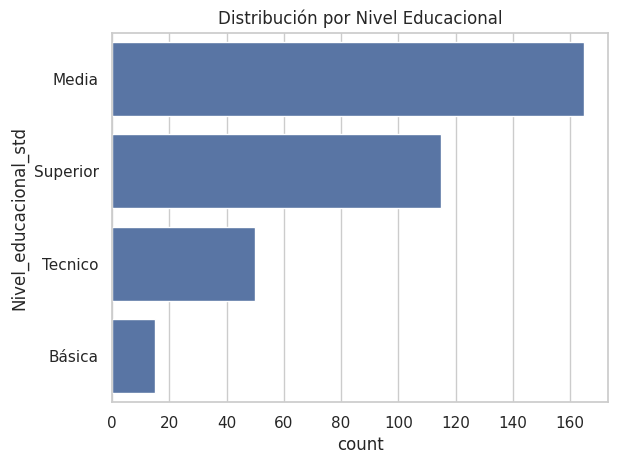

In [11]:
print("\nDistribución Nivel Educacional:")
print(df['Nivel_educacional_std'].value_counts(normalize=True) * 100)
sns.countplot(y='Nivel_educacional_std', data=df, order=df['Nivel_educacional_std'].value_counts().index)
plt.title('Distribución por Nivel Educacional')
plt.show()


Distribución Paridad:
Paridad
M    55.072464
P    44.927536
Name: proportion, dtype: float64


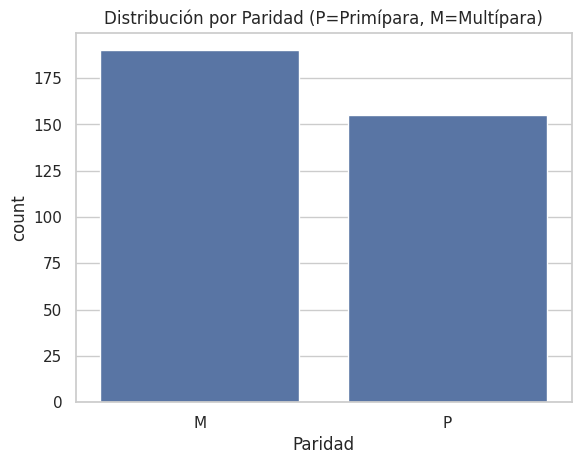

In [12]:
print("\nDistribución Paridad:")
print(df['Paridad'].value_counts(normalize=True) * 100)
sns.countplot(x='Paridad', data=df, order=df['Paridad'].value_counts().index)
plt.title('Distribución por Paridad (P=Primípara, M=Multípara)')
plt.show()


Distribución Tipo de Parto:
Tipo_parto_std
Parto Vaginal    53.333333
Cesárea          45.797101
Forceps           0.869565
Name: proportion, dtype: float64


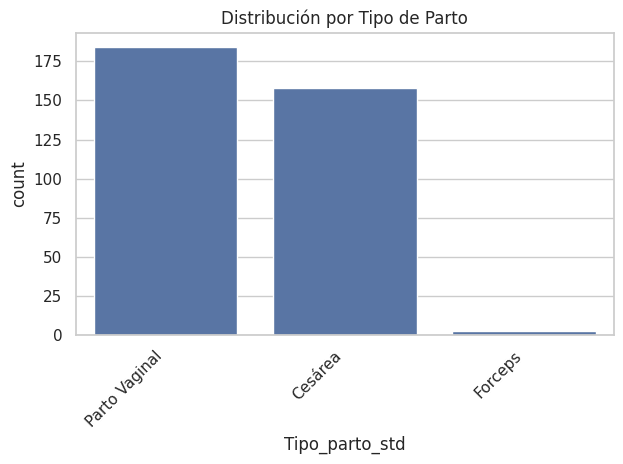

In [13]:
print("\nDistribución Tipo de Parto:")
print(df['Tipo_parto_std'].value_counts(normalize=True) * 100)
sns.countplot(x='Tipo_parto_std', data=df, order=df['Tipo_parto_std'].value_counts().index)
plt.title('Distribución por Tipo de Parto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.2 Distribución de la Edad de las participantes

In [14]:
print("\nEstadísticas Descriptivas - Edad:")
print(df['Edad'].describe())


Estadísticas Descriptivas - Edad:
count    345.000000
mean      28.350725
std        5.753301
min       16.000000
25%       23.000000
50%       28.000000
75%       33.000000
max       43.000000
Name: Edad, dtype: float64


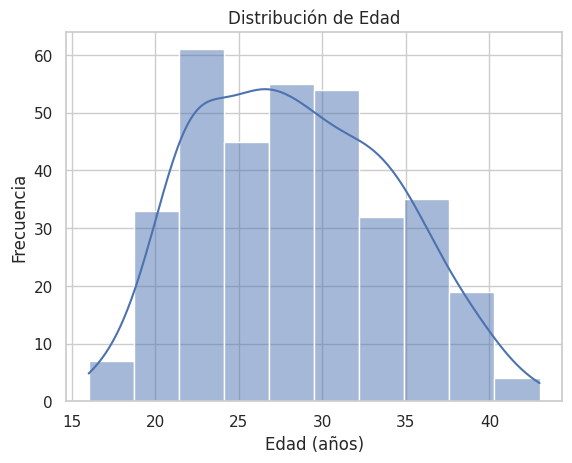

In [15]:
sns.histplot(df['Edad'], kde=True, bins=10)  # kde=True para la curva de densidad, bins=10 segun regla de Sturges
plt.title('Distribución de Edad')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()

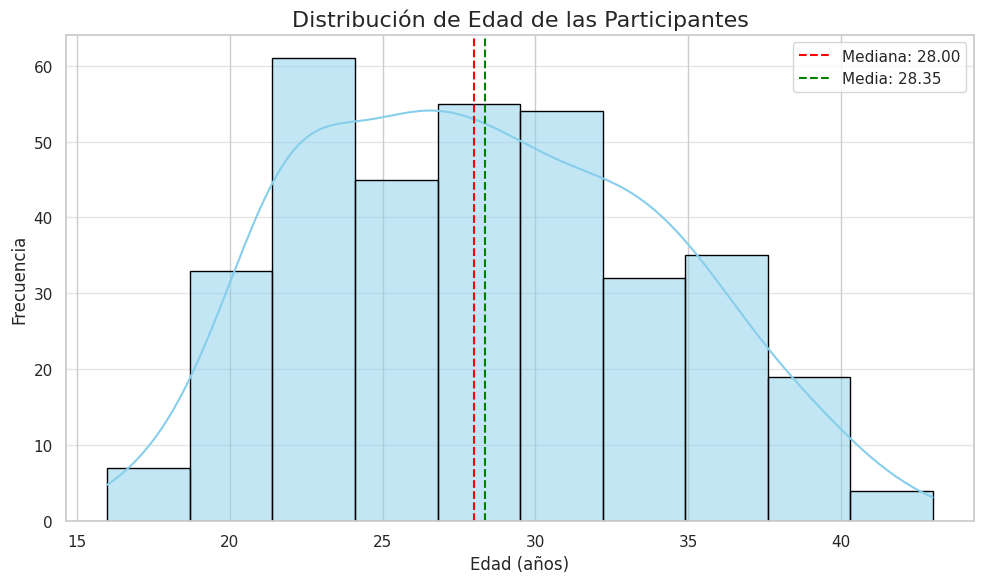

In [16]:
# Distribución de la Edad de las participantes - V2
plt.figure(figsize=(10, 6)) # Ajustar el tamaño de la figura para mejor visualización
sns.histplot(data=df, x='Edad', kde=True, bins=10, color='skyblue', edgecolor='black') # Mayor personalización

# Añadir líneas para medidas centrales
median_age = df['Edad'].median()
mean_age = df['Edad'].mean()

plt.axvline(median_age, color='red', linestyle='dashed', linewidth=1.5, label=f'Mediana: {median_age:.2f}')
plt.axvline(mean_age, color='green', linestyle='dashed', linewidth=1.5, label=f'Media: {mean_age:.2f}')

plt.title('Distribución de Edad de las Participantes', fontsize=16) # Título más descriptivo y tamaño
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend() # Mostrar leyenda para las líneas
plt.grid(axis='y', alpha=0.5) # Añadir una cuadrícula suave en el eje y
plt.tight_layout() # Ajustar el layout para evitar cortes
plt.show()

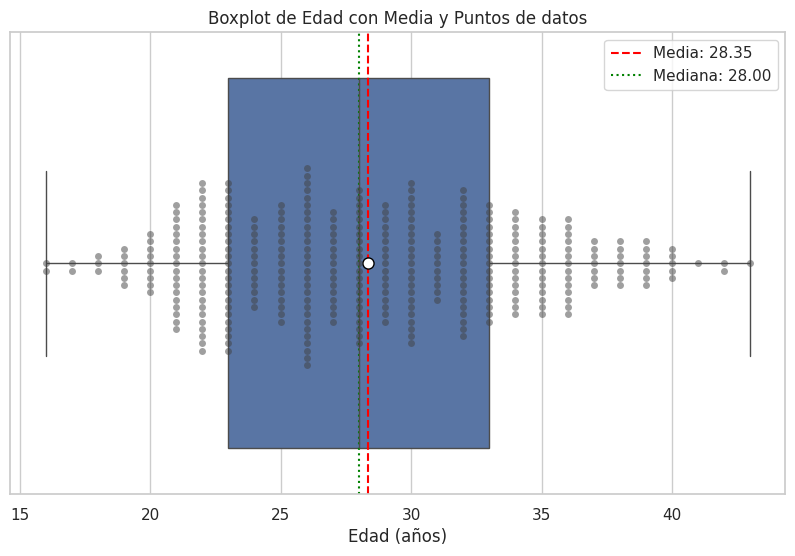

In [17]:
# boxplot con valor de la media media y puntos de datos
def create_advanced_boxplot(data, title, xlabel, ylabel):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=data, showmeans=True, meanprops={"marker":"o",
                                                  "markerfacecolor":"white",
                                                  "markeredgecolor":"black",
                                                  "markersize":"8"})
    sns.swarmplot(x=data, color=".25", alpha=0.5) # Añadir puntos de datos individuales

    mean_val = data.mean()
    median_val = data.median()
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle=':', label=f'Mediana: {median_val:.2f}')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

# Usar la nueva función para la Edad
create_advanced_boxplot(df['Edad'], 'Boxplot de Edad con Media y Puntos de datos', 'Edad (años)', '')

In [18]:
# ## Prueba de Normalidad para la Edad
# **Hipótesis:**
# - H0: La distribución de la edad es normal.
# - H1: La distribución de la edad no es normal.
# **Nivel de significancia (alpha):** 0.05

# Prueba de Shapiro-Wilk
# Esta prueba es adecuada para tamaños de muestra pequeños a moderados (generalmente < 5000).
stat_sw, p_value_sw = stats.shapiro(df['Edad'])
print(f"\nPrueba de Shapiro-Wilk para la Edad:")
print(f"Estadístico de prueba (W): {stat_sw:.4f}")
print(f"Valor p: {p_value_sw:.4f}")

if p_value_sw < 0.05:
    print("Conclusión (Shapiro-Wilk): El valor p es menor que el nivel de significancia (0.05).")
    print("Se rechaza la hipótesis nula (H0). La distribución de la edad NO es normal.")
else:
    print("Conclusión (Shapiro-Wilk): El valor p es mayor o igual que el nivel de significancia (0.05).")
    print("No se puede rechazar la hipótesis nula (H0). Sugiere que la distribución de la edad es normal.")


Prueba de Shapiro-Wilk para la Edad:
Estadístico de prueba (W): 0.9798
Valor p: 0.0001
Conclusión (Shapiro-Wilk): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0). La distribución de la edad NO es normal.


In [19]:
# Prueba de D'Agostino-Pearson (omnibus test)
# Esta prueba es útil para detectar desviaciones de la normalidad (asimetría y curtosis).
stat_dp, p_value_dp = stats.normaltest(df['Edad'])
print(f"\nPrueba de D'Agostino-Pearson para la Edad:")
print(f"Estadístico de prueba (K^2): {stat_dp:.4f}")
print(f"Valor p: {p_value_dp:.4f}")

if p_value_dp < 0.05:
    print("Conclusión (D'Agostino-Pearson): El valor p es menor que el nivel de significancia (0.05).")
    print("Se rechaza la hipótesis nula (H0). La distribución de la edad NO es normal.")
else:
    print("Conclusión (D'Agostino-Pearson): El valor p es mayor o igual que el nivel de significancia (0.05).")
    print("No se puede rechazar la hipótesis nula (H0). Sugiere que la distribución de la edad es normal.")


Prueba de D'Agostino-Pearson para la Edad:
Estadístico de prueba (K^2): 22.4624
Valor p: 0.0000
Conclusión (D'Agostino-Pearson): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0). La distribución de la edad NO es normal.


In [20]:
# Conclusión General sobre la Normalidad de la Edad
print("\n--- Resumen de Normalidad de la Edad ---")
if p_value_sw < 0.05 and p_value_dp < 0.05:
    print("Ambas pruebas (Shapiro-Wilk y D'Agostino-Pearson) indican que la distribución de la edad NO es normal (p < 0.05).")
    print("No se justifica aplicar transformaciones para forzar la normalidad si el objetivo es usar pruebas paramétricas,")
    print("ya que la normalidad es un supuesto del método inferencial, no una propiedad intrínseca de la variable.")
    print("Se recomienda usar métodos estadísticos no paramétricos si los análisis posteriores requieren la normalidad.")
    print("También es importante revisar visualmente los histogramas y boxplots para entender la forma de la distribución.")
elif p_value_sw < 0.05 or p_value_dp < 0.05:
    print("Una o ambas pruebas sugieren que la distribución de la edad podría no ser estrictamente normal.")
    print("Es crucial complementar con la inspección visual de los gráficos (histograma, Q-Q plot si se genera).")
    print("Si la desviación es leve y el tamaño muestral es grande, algunas pruebas paramétricas son robustas a la violación de normalidad.")
    print("Sin embargo, si la desviación es marcada, considere métodos no paramétricos.")
else:
    print("Ambas pruebas sugieren que la distribución de la edad es consistente con una distribución normal (p >= 0.05).")
    print("La inspección visual (histograma, boxplot) apoya esta conclusión.")
    print("Puede considerarse el uso de métodos estadísticos paramétricos que asumen normalidad para esta variable.")


--- Resumen de Normalidad de la Edad ---
Ambas pruebas (Shapiro-Wilk y D'Agostino-Pearson) indican que la distribución de la edad NO es normal (p < 0.05).
No se justifica aplicar transformaciones para forzar la normalidad si el objetivo es usar pruebas paramétricas,
ya que la normalidad es un supuesto del método inferencial, no una propiedad intrínseca de la variable.
Se recomienda usar métodos estadísticos no paramétricos si los análisis posteriores requieren la normalidad.
También es importante revisar visualmente los histogramas y boxplots para entender la forma de la distribución.


In [21]:
# Ajustes Necesarios / Consideraciones
print("\n--- Consideraciones para el Análisis con la Variable Edad ---")
if p_value_sw < 0.05 or p_value_dp < 0.05:
    print("- **Transformaciones (Opcional pero no recomendado para forzar):** Aunque se podrían aplicar transformaciones (ej. logarítmica, raíz cuadrada) para intentar aproximar la normalidad, esto cambia la interpretación de la variable.")
    print("  Generalmente no se transforman variables demográficas a menos que haya una base teórica sólida o un requisito estricto de un modelo específico.")
    print("  Las transformaciones pueden ser útiles si se busca cumplir supuestos para modelos específicos (ej. regresión), pero deben justificarse y la interpretación cambia.")
    print("- **Métodos No Paramétricos:** Si los análisis posteriores (ej. comparar edad entre grupos) requieren una suposición de distribución, se recomiendan pruebas no paramétricas como el test de Mann-Whitney U (para dos grupos) o Kruskal-Wallis (para más de dos grupos).")
    print("- **Evaluación Visual:** Siempre acompañar las pruebas estadísticas con la inspección visual de la distribución (histogramas, Q-Q plots).")
    print("- **Robustez:** Para muestras grandes, muchas pruebas paramétricas son relativamente robustas a violaciones de la normalidad (por el Teorema del Límite Central). Evalúa si tu muestra es suficientemente grande para esto.")
else:
    print("- La variable 'Edad' parece seguir una distribución normal según las pruebas estadísticas y la inspección visual.")
    print("- Puede utilizar métodos estadísticos paramétricos que asumen normalidad si son apropiados para los análisis subsiguientes (ej. T-test, ANOVA, regresión lineal donde la normalidad de los *residuos* es el supuesto clave).")


--- Consideraciones para el Análisis con la Variable Edad ---
- **Transformaciones (Opcional pero no recomendado para forzar):** Aunque se podrían aplicar transformaciones (ej. logarítmica, raíz cuadrada) para intentar aproximar la normalidad, esto cambia la interpretación de la variable.
  Generalmente no se transforman variables demográficas a menos que haya una base teórica sólida o un requisito estricto de un modelo específico.
  Las transformaciones pueden ser útiles si se busca cumplir supuestos para modelos específicos (ej. regresión), pero deben justificarse y la interpretación cambia.
- **Métodos No Paramétricos:** Si los análisis posteriores (ej. comparar edad entre grupos) requieren una suposición de distribución, se recomiendan pruebas no paramétricas como el test de Mann-Whitney U (para dos grupos) o Kruskal-Wallis (para más de dos grupos).
- **Evaluación Visual:** Siempre acompañar las pruebas estadísticas con la inspección visual de la distribución (histogramas, Q-Q plo


Generando Q-Q plot para evaluación visual de la normalidad...


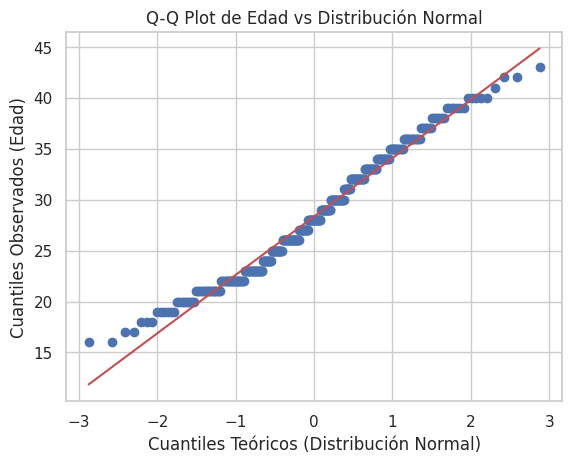

El Q-Q plot ayuda a visualizar cuánto se desvían los puntos observados de la línea recta teórica (que representa la normalidad).


In [22]:
# Opcional: Graficar Q-Q plot para una evaluación visual más rigurosa
print("\nGenerando Q-Q plot para evaluación visual de la normalidad...")
stats.probplot(df['Edad'], dist="norm", plot=plt)
plt.title('Q-Q Plot de Edad vs Distribución Normal')
plt.xlabel('Cuantiles Teóricos (Distribución Normal)')
plt.ylabel('Cuantiles Observados (Edad)')
plt.show()

print("El Q-Q plot ayuda a visualizar cuánto se desvían los puntos observados de la línea recta teórica (que representa la normalidad).")

In [23]:
# Prueba de Kolmogorov-Smirnov (comparación con una distribución normal)
k_s_test = stats.kstest(df['Edad'].dropna(), 'norm', args=(df['Edad'].mean(), df['Edad'].std()))
print("\nPrueba de Kolmogorov-Smirnov para la variable Edad:")
print(f"Estadístico: {k_s_test.statistic}")
print(f"Valor p: {k_s_test.pvalue}")

if k_s_test.pvalue > 0.05:
    print("Conclusión (Kolmogorov-Smirnov): El valor p es mayor o igual que el nivel de significancia (0.05).")
    print("No se puede rechazar la hipótesis nula (H0). Sugiere que la distribución de la edad es normal.")
else:
    print("Conclusión (Kolmogorov-Smirnov): El valor p es menor que el nivel de significancia (0.05).")
    print("Se rechaza la hipótesis nula (H0). La distribución de la edad NO es normal.")


Prueba de Kolmogorov-Smirnov para la variable Edad:
Estadístico: 0.08176706173057918
Valor p: 0.018711908587041148
Conclusión (Kolmogorov-Smirnov): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0). La distribución de la edad NO es normal.


# **4: Análisis Por Ítem (Detallado)**

## 4.1 Distribuciones por pregunta

In [24]:
import matplotlib.pyplot as plt

items_analisis = {}
for i in range(1, 48):
  item_orig = f'Item_{i}'
  items_analisis[item_orig] = item_orig
# Number of items to display per row in the grid
items_per_row = 4

# # Calculate the number of rows needed for the grid
# num_rows = (len(items_analisis) + items_per_row - 1) // items_per_row
#
# # Create the figure and axes for the subplots
# fig, axes = plt.subplots(num_rows, items_per_row, figsize=(20, 5 * num_rows))
#
# # Flatten the axes array for easy iteration
# axes = axes.flatten()
#
# # Iterate over the items and create the plots
# for i, (item_key, col_name) in enumerate(items_analisis.items()):
#     ax = axes[i]
#     sns.countplot(x=df[col_name], order=[1, 2, 3, 4, 5], ax=ax)  # Asegura orden Likert
#     ax.set_title(f'Distribución de Respuestas para {item_key}')
#     ax.set_ylabel('Frecuencia')
#     ax.set_xlabel(item_key)  # Set the x-axis label to the item name
#
# # Hide any unused subplots
# for j in range(i + 1, len(axes)):
#   axes[j].set_axis_off()
#
# plt.tight_layout() # Adjust layout to prevent overlapping
# plt.show()

## 4.2 Resumen estadístico por ítem (media, mediana, desviación estándar)

In [25]:
# Resumen estadístico por ítem (media, mediana, desviación estándar)
item_stats = df[item_cols].describe().T
# display(item_stats.style.set_caption("Estadísticas por Ítem (1-5 Likert)"))


## 4.3 Conteo de respuestas por categoría (1 a 5) para cada ítem

In [26]:
# Conteo de respuestas por categoría (1 a 5) para cada ítem
print("\nDistribución de Respuestas por Ítem (Porcentaje):")
item_response_counts = {}
for col in item_cols:
    # Asegúrate de que las categorías 1-5 existan, si no, se incluirán con 0%
    response_counts = df[col].value_counts(normalize=True).sort_index() * 100
    # Añadir categorías faltantes con 0%
    for i in range(1, 6):
        if i not in response_counts.index:
            response_counts[i] = 0.0
    item_response_counts[col] = response_counts.sort_index() # Asegurar orden 1 a 5

item_response_df = pd.DataFrame(item_response_counts).T
display(item_response_df.style.format("{:.1f}%").set_caption("Distribución % por Ítem"))


Distribución de Respuestas por Ítem (Porcentaje):


,1,2,3,4,5
Item_1,0.0%,0.3%,1.7%,9.0%,89.0%
Item_2,0.9%,0.3%,1.7%,10.1%,87.0%
Item_3,54.8%,19.7%,10.4%,8.4%,6.7%
Item_4,0.6%,1.7%,7.0%,10.4%,80.3%
Item_5,75.4%,14.8%,4.9%,1.7%,3.2%
Item_6,0.6%,0.3%,2.6%,11.0%,85.5%
Item_7,3.5%,2.6%,6.1%,16.2%,71.6%
Item_8,0.3%,0.6%,1.4%,5.8%,91.9%
Item_9,0.6%,0.6%,6.4%,10.4%,82.0%
Item_10,0.6%,0.9%,3.2%,12.8%,82.6%


# 5: Análisis por Dimensiones de estudio

## 5.1 Dimensiones

In [27]:
# Definir los ítems originales pertenecientes a cada dimensión
dimensiones = {
    'Cuidado_relacional_calidad': [1, 2, 6, 9, 10, 11, 14, 15, 20, 28, 39, 44, 47],
    'Cuidado_despersonalizado': [3, 5, 32, 33, 35, 43], # ¡Estos usan las columnas invertidas!
    'Participacion_familiar_continua': [4, 13, 25, 36],
    'Cuidado_oportuno_respetuoso': [7, 16, 17, 19, 21, 30],
    'Ambiente_fisico_confortable': [8, 18, 26, 27, 42],
    'Condiciones_contacto_madre_hijo': [22, 24, 45, 46],
    'Autocuidado_confort': [12, 23, 29, 31, 34, 37, 38, 40, 41]
}

# Crear un mapeo de ítem original a columna de análisis (original o _inv)
# This mapping is not directly used for score calculation here, but keeping it for context
mapa_item_columna = {f'Item_{i}': items_analisis.get(f'Item_{i}') for i in range(1, 48)}

## 5.2 Puntuaciones por dimensión

In [28]:
# Calcular la puntuación media para cada dimensión
for dim_nombre, items_lista in dimensiones.items():
    # Obtener los nombres de las columnas correctas (originales o invertidas)
    cols_dim = [mapa_item_columna.get(f'Item_{i}') for i in items_lista if mapa_item_columna.get(f'Item_{i}') is not None]
    if cols_dim: # Asegurarse de que hay columnas válidas para la dimensión
        df[f'Score_{dim_nombre}'] = df[cols_dim].mean(axis=1)
        print(f"Calculada puntuación media para dimensión: {dim_nombre}")
    else:
         print(f"Advertencia: No se encontraron columnas válidas para la dimensión {dim_nombre}")

# # Ver las nuevas columnas de puntuación
# print("\nDataFrame con puntuaciones de dimensión:")
# print(df[[col for col in df.columns if col.startswith('Score_')]].head())

Calculada puntuación media para dimensión: Cuidado_relacional_calidad
Calculada puntuación media para dimensión: Cuidado_despersonalizado
Calculada puntuación media para dimensión: Participacion_familiar_continua
Calculada puntuación media para dimensión: Cuidado_oportuno_respetuoso
Calculada puntuación media para dimensión: Ambiente_fisico_confortable
Calculada puntuación media para dimensión: Condiciones_contacto_madre_hijo
Calculada puntuación media para dimensión: Autocuidado_confort


In [29]:
dimension_scores = df[[col for col in df.columns if col.startswith('Score_')]]

# Renombrar las columnas para que sean más legibles (eliminar el prefijo 'Score_')
dimension_scores.columns = dimension_scores.columns.str.replace('Score_', '')

# Mostrar las estadísticas descriptivas de las puntuaciones de las dimensiones
print("\nEstadísticas Descriptivas de las Puntuaciones por Dimensión:")
display(dimension_scores.describe().T.style
    .set_caption("Puntuaciones por Dimensión")
    .format("{:.2f}") # Formatear a 2 decimales
    .background_gradient(cmap='Blues') # Añadir gradiente de color
    .set_properties(**{'font-size': '10pt'}) # Ajustar tamaño de fuente
)



Estadísticas Descriptivas de las Puntuaciones por Dimensión:


,count,mean,std,min,25%,50%,75%,max
Cuidado_relacional_calidad,345.00,4.81,0.36,2.62,4.77,5.00,5.00,5.00
Cuidado_despersonalizado,345.00,1.63,0.77,1.00,1.00,1.33,2.00,5.00
Participacion_familiar_continua,345.00,4.74,0.49,2.25,4.75,5.00,5.00,5.00
Cuidado_oportuno_respetuoso,345.00,4.72,0.44,2.50,4.67,5.00,5.00,5.00
Ambiente_fisico_confortable,345.00,4.80,0.36,2.80,4.80,5.00,5.00,5.00
Condiciones_contacto_madre_hijo,345.00,4.63,0.71,1.00,4.50,5.00,5.00,5.00
Autocuidado_confort,345.00,4.25,0.75,1.00,3.89,4.44,4.89,5.00



Boxplots de Puntuaciones por Dimensión:


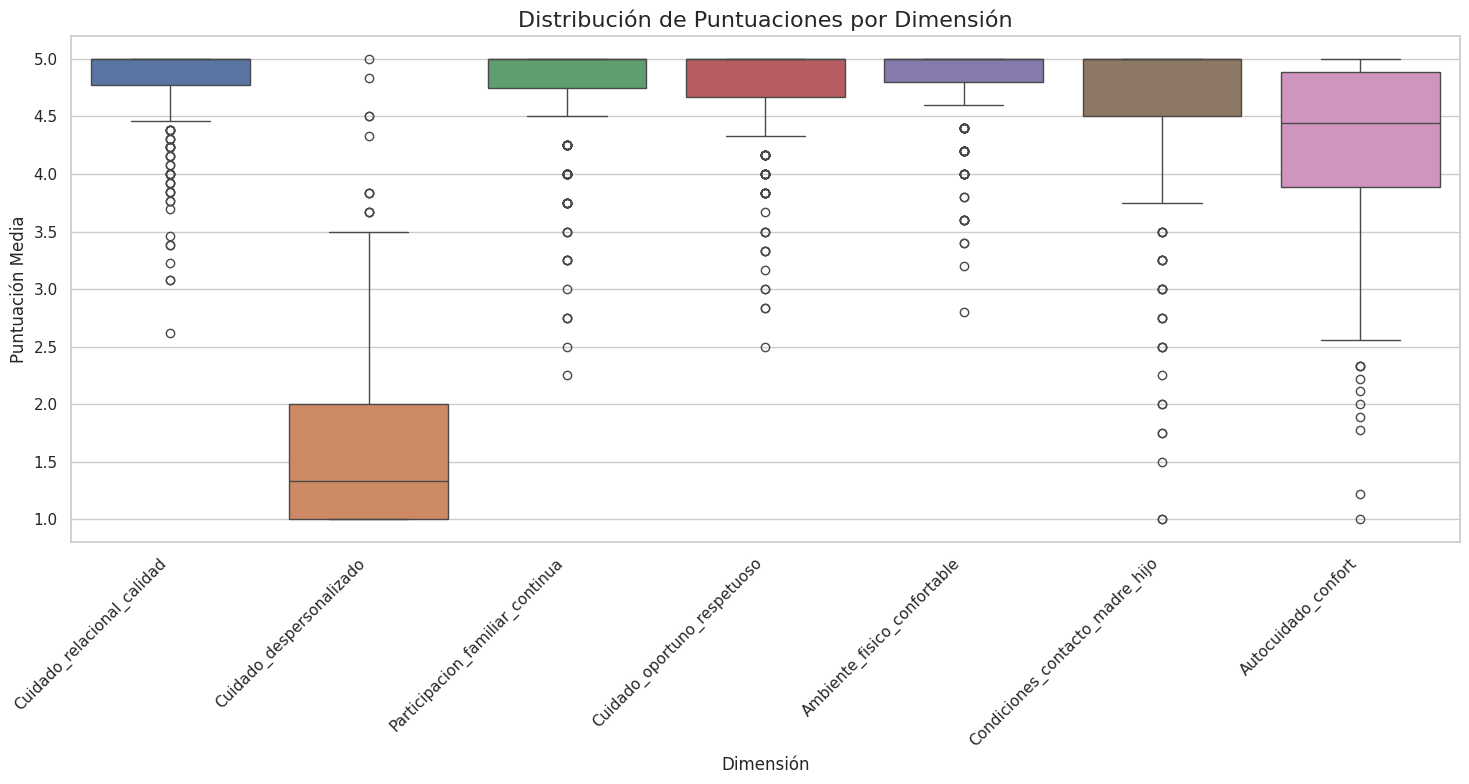

In [30]:
# Visualización de las distribuciones de las puntuaciones por dimensión usando boxplots
print("\nBoxplots de Puntuaciones por Dimensión:")
plt.figure(figsize=(15, 8))
sns.boxplot(data=dimension_scores)
plt.title('Distribución de Puntuaciones por Dimensión', fontsize=16)
plt.ylabel('Puntuación Media', fontsize=12)
plt.xlabel('Dimensión', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

## 5.3 Puntuaciones por dimension / Paridad

In [31]:
# prompt: necesito los calculos anteriores de puntuaciones por dimension (filas) pero separadas por la variable que indica paridad (columnas)

# Calcular las estadísticas descriptivas (media, mediana, std) de las puntuaciones por dimensión, agrupadas por 'Paridad'
dimension_stats_by_paridad = df.groupby('Paridad')[[col for col in df.columns if col.startswith('Score_')]].agg(['mean', 'median', 'std']).T

print("\nEstadísticas Descriptivas de las Puntuaciones por Dimensión, separadas por Paridad:")
display(dimension_stats_by_paridad.style
    .set_caption("Puntuaciones por Dimensión por Paridad (Media, Mediana, Std)")
    .format("{:.2f}")
    .background_gradient(cmap='coolwarm', axis=1) # Añadir gradiente por fila (dimensión/estadístico)
    .set_properties(**{'font-size': '10pt'})
)



Estadísticas Descriptivas de las Puntuaciones por Dimensión, separadas por Paridad:



Boxplots de Puntuaciones por Dimensión, separadas por Paridad:


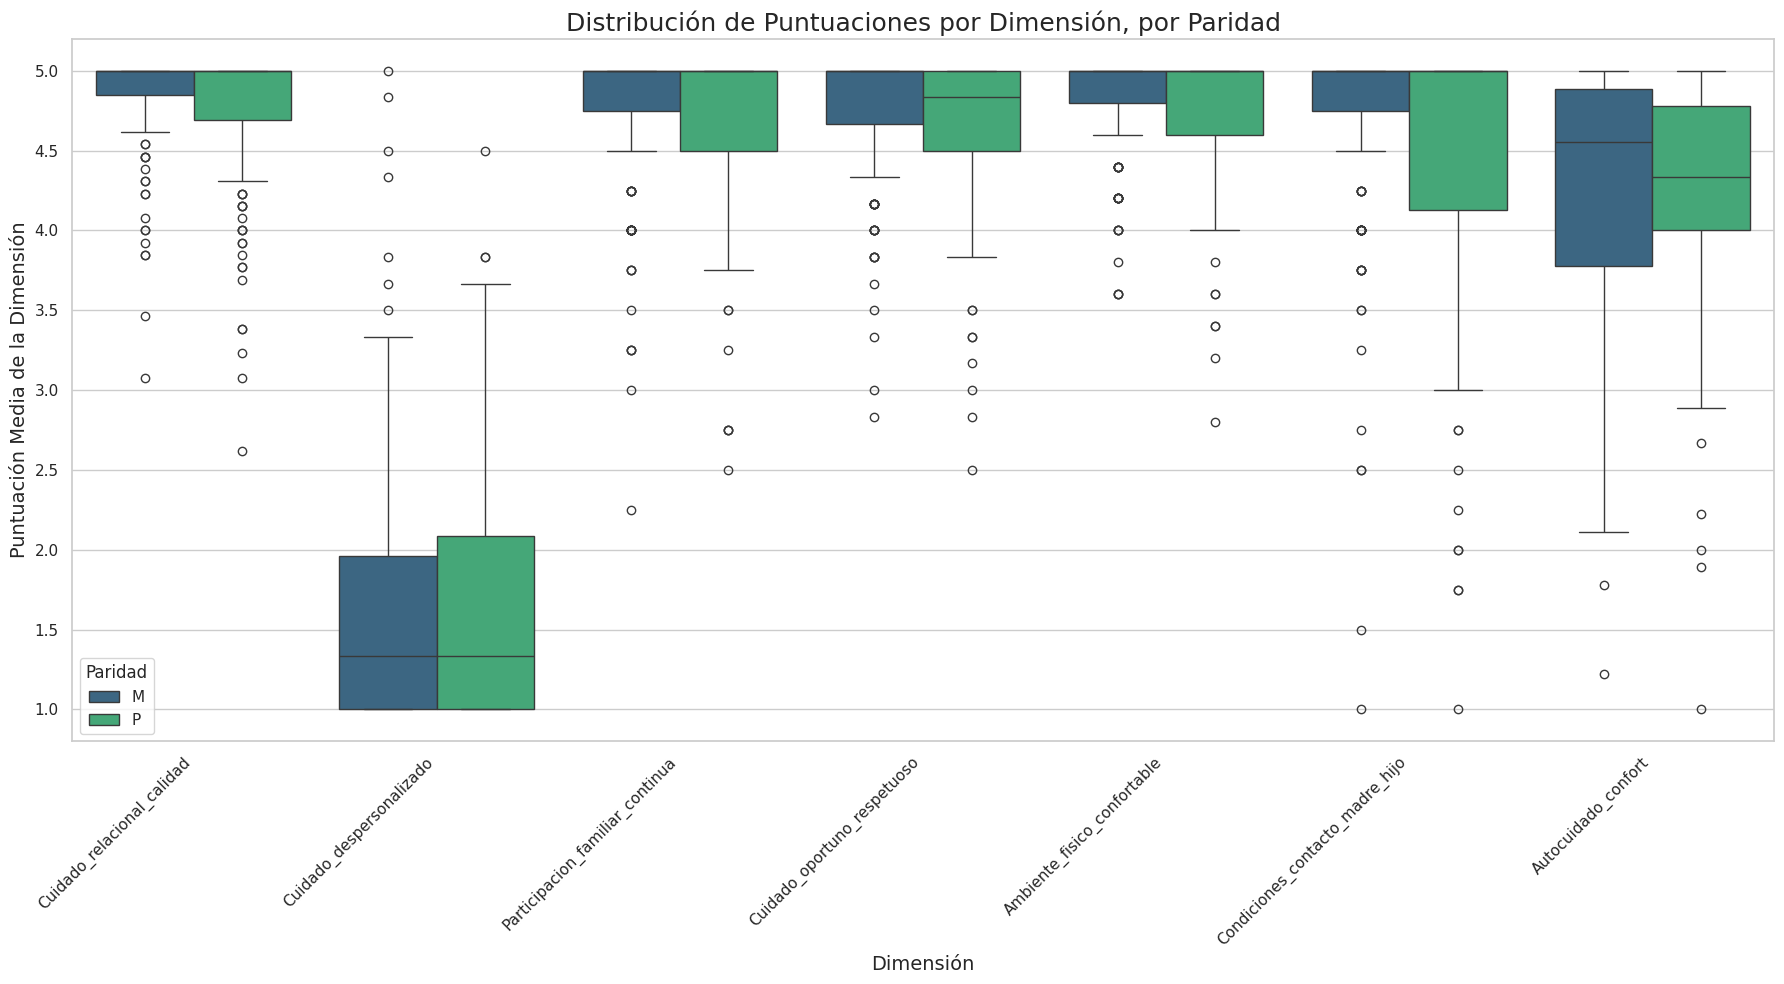

In [32]:
# Reorganizar los datos para la visualización (unpivot o melt)
# Seleccionar solo las columnas de puntuación y Paridad
df_scores_paridad = df[['Paridad'] + [col for col in df.columns if col.startswith('Score_')]]

# Usar melt para transformar el DataFrame a formato largo
df_scores_melted = df_scores_paridad.melt(id_vars='Paridad', var_name='Dimension', value_name='Score')

# Opcional: Renombrar las dimensiones en el melted DataFrame para mejor legibilidad en los gráficos
df_scores_melted['Dimension'] = df_scores_melted['Dimension'].str.replace('Score_', '')

# Visualizar las distribuciones de las puntuaciones por dimensión, separadas por Paridad (usando boxplots)
print("\nBoxplots de Puntuaciones por Dimensión, separadas por Paridad:")
plt.figure(figsize=(18, 10))
sns.boxplot(x='Dimension', y='Score', hue='Paridad', data=df_scores_melted, palette='viridis')
plt.title('Distribución de Puntuaciones por Dimensión, por Paridad', fontsize=18)
plt.ylabel('Puntuación Media de la Dimensión', fontsize=14)
plt.xlabel('Dimensión', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Paridad', loc='lower left')
plt.tight_layout()
plt.show()

## 5.4 Puntuaciones por dimensión / Tipo de Parto

In [33]:
# prompt: necesito los calculos anteriores de puntuaciones por dimension (filas) pero separadas por la variable que indica tipo de parto (columnas)

# Calcular las estadísticas descriptivas (media, mediana, std) de las puntuaciones por dimensión, agrupadas por 'Tipo_parto_std'
dimension_stats_by_parto = df.groupby('Tipo_parto_std')[[col for col in df.columns if col.startswith('Score_')]].agg(['mean', 'median', 'std']).T

print("\nEstadísticas Descriptivas de las Puntuaciones por Dimensión, separadas por Tipo de Parto:")
display(dimension_stats_by_parto.style
    .set_caption("Puntuaciones por Dimensión por Tipo de Parto (Media, Mediana, Std)")
    .format("{:.2f}")
    .background_gradient(cmap='coolwarm', axis=1) # Añadir gradiente por fila (dimensión/estadístico)
    .set_properties(**{'font-size': '10pt'})
)


Estadísticas Descriptivas de las Puntuaciones por Dimensión, separadas por Tipo de Parto:



Boxplots de Puntuaciones por Dimensión, separadas por Tipo de Parto:


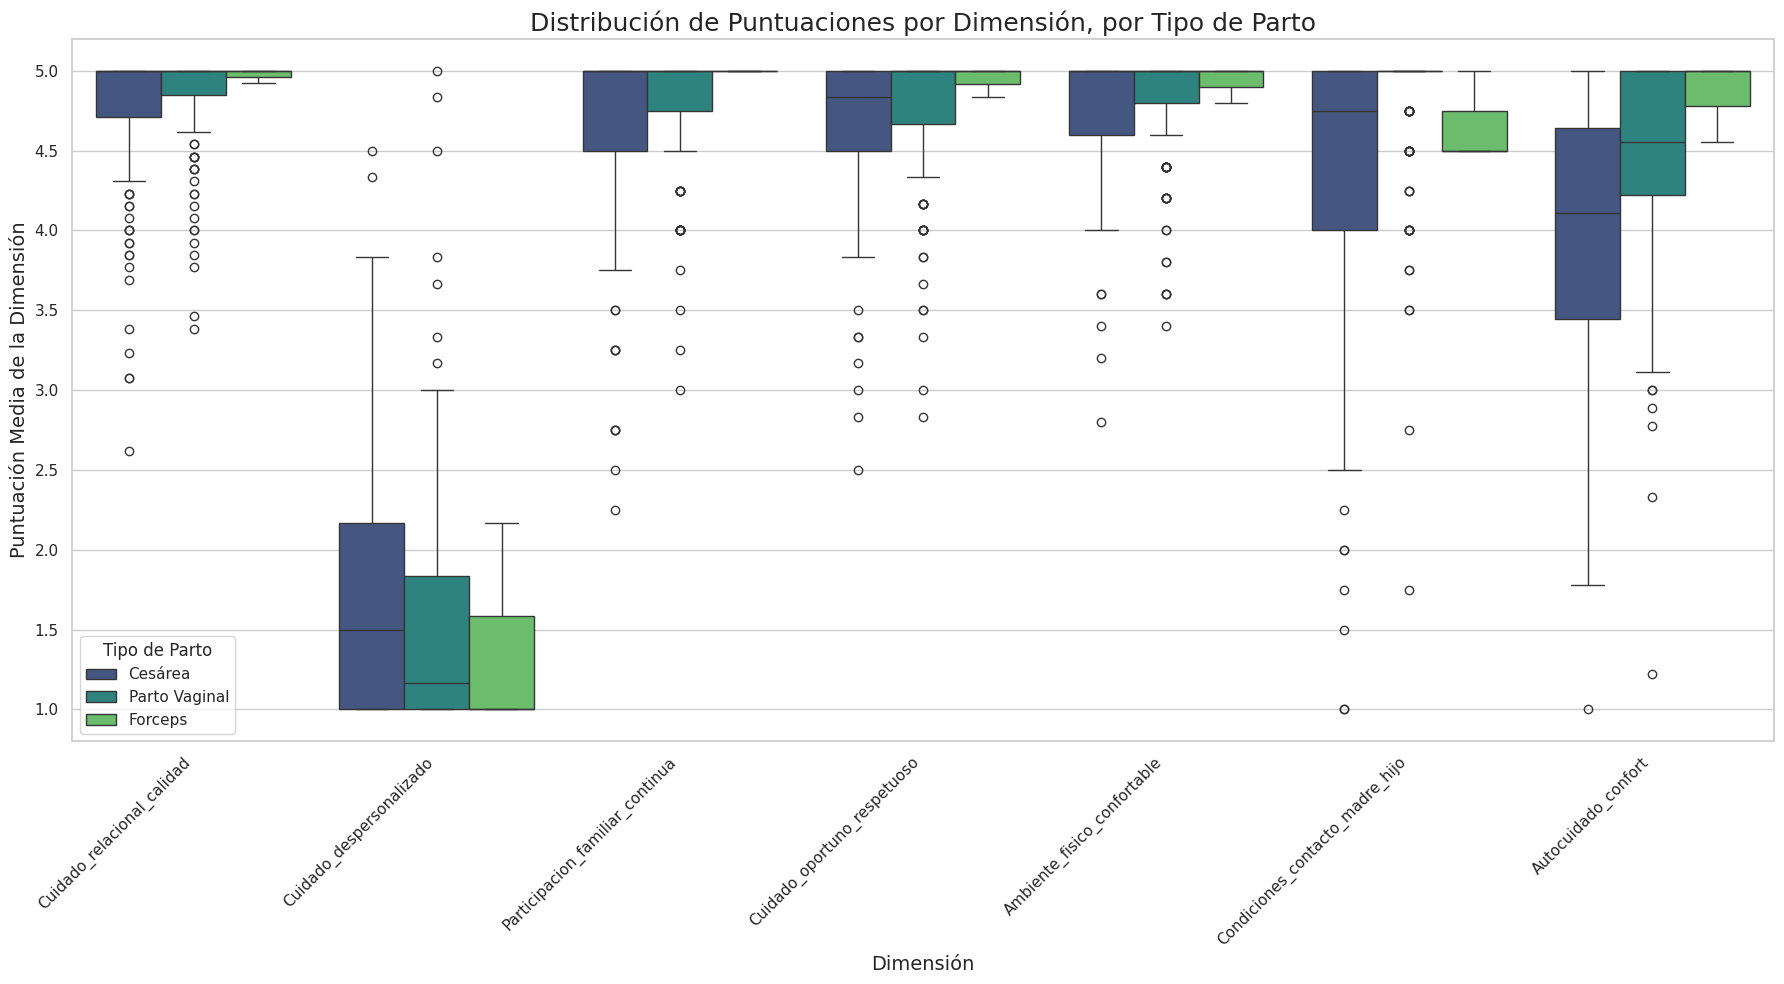

In [34]:
# Reorganizar los datos para la visualización (unpivot o melt)
# Seleccionar solo las columnas de puntuación y Tipo_parto_std
df_scores_parto = df[['Tipo_parto_std'] + [col for col in df.columns if col.startswith('Score_')]]

# Usar melt para transformar el DataFrame a formato largo
df_scores_melted_parto = df_scores_parto.melt(id_vars='Tipo_parto_std', var_name='Dimension', value_name='Score')

# Opcional: Renombrar las dimensiones en el melted DataFrame para mejor legibilidad en los gráficos
df_scores_melted_parto['Dimension'] = df_scores_melted_parto['Dimension'].str.replace('Score_', '')

# Visualizar las distribuciones de las puntuaciones por dimensión, separadas por Tipo de Parto (usando boxplots)
print("\nBoxplots de Puntuaciones por Dimensión, separadas por Tipo de Parto:")
plt.figure(figsize=(18, 10))
sns.boxplot(x='Dimension', y='Score', hue='Tipo_parto_std', data=df_scores_melted_parto, palette='viridis')
plt.title('Distribución de Puntuaciones por Dimensión, por Tipo de Parto', fontsize=18)
plt.ylabel('Puntuación Media de la Dimensión', fontsize=14)
plt.xlabel('Dimensión', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Parto', loc='lower left')
plt.tight_layout()
plt.show()

## 5.5 Puntuaciones por dimensión / Nivel educacional

In [35]:
# Calcular las estadísticas descriptivas (media, mediana, std) de las puntuaciones por dimensión, agrupadas por 'Nivel_educacional_std'
dimension_stats_by_educacion = df.groupby('Nivel_educacional_std')[[col for col in df.columns if col.startswith('Score_')]].agg(['mean', 'median', 'std']).T

print("\nEstadísticas Descriptivas de las Puntuaciones por Dimensión, separadas por Nivel Educacional:")
display(dimension_stats_by_educacion.style
    .set_caption("Puntuaciones por Dimensión por Nivel Educacional (Media, Mediana, Std)")
    .format("{:.2f}")
    .background_gradient(cmap='coolwarm', axis=1) # Añadir gradiente por fila (dimensión/estadístico)
    .set_properties(**{'font-size': '10pt'})
)


Estadísticas Descriptivas de las Puntuaciones por Dimensión, separadas por Nivel Educacional:



Boxplots de Puntuaciones por Dimensión, separadas por Nivel Educacional:


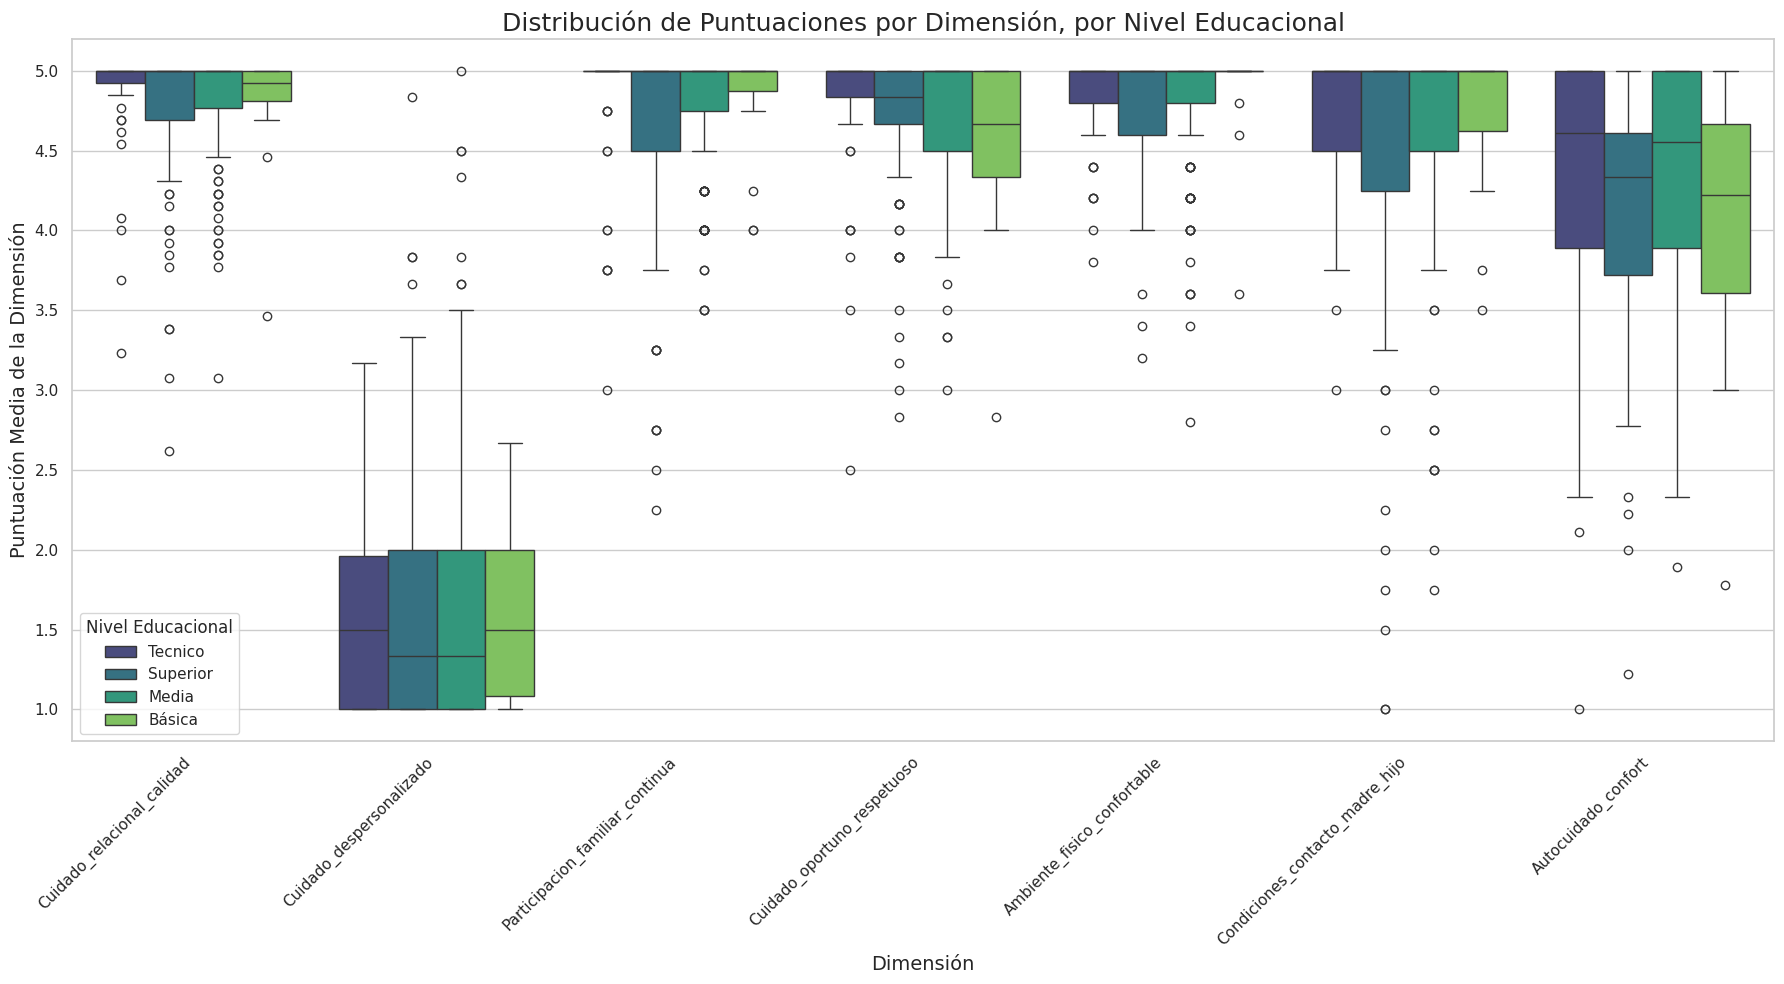

In [36]:
# Reorganizar los datos para la visualización (unpivot o melt)
# Seleccionar solo las columnas de puntuación y Nivel_educacional_std
df_scores_educacion = df[['Nivel_educacional_std'] + [col for col in df.columns if col.startswith('Score_')]]

# Usar melt para transformar el DataFrame a formato largo
df_scores_melted_educacion = df_scores_educacion.melt(id_vars='Nivel_educacional_std', var_name='Dimension', value_name='Score')

# Opcional: Renombrar las dimensiones en el melted DataFrame para mejor legibilidad en los gráficos
df_scores_melted_educacion['Dimension'] = df_scores_melted_educacion['Dimension'].str.replace('Score_', '')

# Visualizar las distribuciones de las puntuaciones por dimensión, separadas por Nivel Educacional (usando boxplots)
print("\nBoxplots de Puntuaciones por Dimensión, separadas por Nivel Educacional:")
plt.figure(figsize=(18, 10))
sns.boxplot(x='Dimension', y='Score', hue='Nivel_educacional_std', data=df_scores_melted_educacion, palette='viridis')
plt.title('Distribución de Puntuaciones por Dimensión, por Nivel Educacional', fontsize=18)
plt.ylabel('Puntuación Media de la Dimensión', fontsize=14)
plt.xlabel('Dimensión', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nivel Educacional', loc='lower left')
plt.tight_layout()
plt.show()

## 5.6 Puntuaciones por dimensión / edad (transformada en categorías)

In [37]:
# ## Puntuaciones por dimensión / Categorías de Edad
# Transformación de la variable 'Edad' en categórica

print("\n--- Categorización de la variable Edad ---")

# Decidir un método de categorización. Dado que la distribución no es estrictamente normal,
# una división basada en cuantiles (percentiles) podría ser más robusta a valores extremos
# que una división por intervalos de igual ancho.

# Opciones:
# 1. Cuantiles (Percentiles): Divide los datos en grupos con aproximadamente el mismo número de participantes.
#    Ej: Cuartiles (4 grupos), Quintiles (5 grupos).
# 2. Intervalos de ancho fijo: Divide el rango de edad en intervalos de igual tamaño.
#    Ej: 20-29, 30-39, 40-49.

# Método elegido: Cuantiles (Quintiles para 5 categorías). Esto crea grupos con ~20% de los datos cada uno.
# Justificación: La distribución de la edad no es normal, y los cuantiles no asumen una forma de distribución particular,
# dividiendo la muestra de forma equitativa según el número de participantes en cada rango.

n_quantiles = 5 # Número de categorías deseadas
labels_quantiles = [f'Q{i+1}' for i in range(n_quantiles)] # Etiquetas para las categorías (Q1, Q2, etc.)

# Usar pd.qcut para crear categorías basadas en cuantiles
# `duplicates='drop'` maneja casos donde los cuantiles son los mismos debido a valores repetidos.
df['Edad_Categoria_Quantil'] = pd.qcut(df['Edad'], q=n_quantiles, labels=labels_quantiles, duplicates='drop')

print(f"\nCategorías de Edad creadas usando {n_quantiles} cuantiles:")
print(df['Edad_Categoria_Quantil'].value_counts().sort_index())

# Mostrar los rangos de edad para cada categoría (opcional, ayuda a interpretar)
quantile_bins = pd.qcut(df['Edad'], q=n_quantiles, duplicates='drop', retbins=True)[1]
print("\nRangos de Edad por Categoría de Cuantil:")
for i in range(len(quantile_bins) - 1):
    lower_bound = quantile_bins[i]
    upper_bound = quantile_bins[i+1]
    label = labels_quantiles[i]
    print(f"Categoría {label}: Edad entre {lower_bound:.2f} y {upper_bound:.2f}")




--- Categorización de la variable Edad ---

Categorías de Edad creadas usando 5 cuantiles:
Edad_Categoria_Quantil
Q1    88
Q2    58
Q3    78
Q4    63
Q5    58
Name: count, dtype: int64

Rangos de Edad por Categoría de Cuantil:
Categoría Q1: Edad entre 16.00 y 23.00
Categoría Q2: Edad entre 23.00 y 26.00
Categoría Q3: Edad entre 26.00 y 30.00
Categoría Q4: Edad entre 30.00 y 34.00
Categoría Q5: Edad entre 34.00 y 43.00


In [38]:
# Calcular las estadísticas descriptivas (media, mediana, std) de las puntuaciones
# por dimensión, agrupadas por la nueva variable 'Edad_Categoria_Quantil'.

dimension_stats_by_edad = df.groupby('Edad_Categoria_Quantil')[[col for col in df.columns if col.startswith('Score_')]].agg(['mean', 'median', 'std']).T

print("\nEstadísticas Descriptivas de las Puntuaciones por Dimensión, separadas por Categoría de Edad (Cuantiles):")
display(dimension_stats_by_edad.style
    .set_caption("Puntuaciones por Dimensión por Categoría de Edad (Media, Mediana, Std)")
    .format("{:.2f}")
    .background_gradient(cmap='coolwarm', axis=1) # Añadir gradiente por fila (dimensión/estadístico)
    .set_properties(**{'font-size': '10pt'})
)


Estadísticas Descriptivas de las Puntuaciones por Dimensión, separadas por Categoría de Edad (Cuantiles):


/tmp/ipykernel_1186/2691665012.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dimension_stats_by_edad = df.groupby('Edad_Categoria_Quantil')[[col for col in df.columns if col.startswith('Score_')]].agg(['mean', 'median', 'std']).T



Boxplots de Puntuaciones por Dimensión, separadas por Categoría de Edad (Cuantiles):


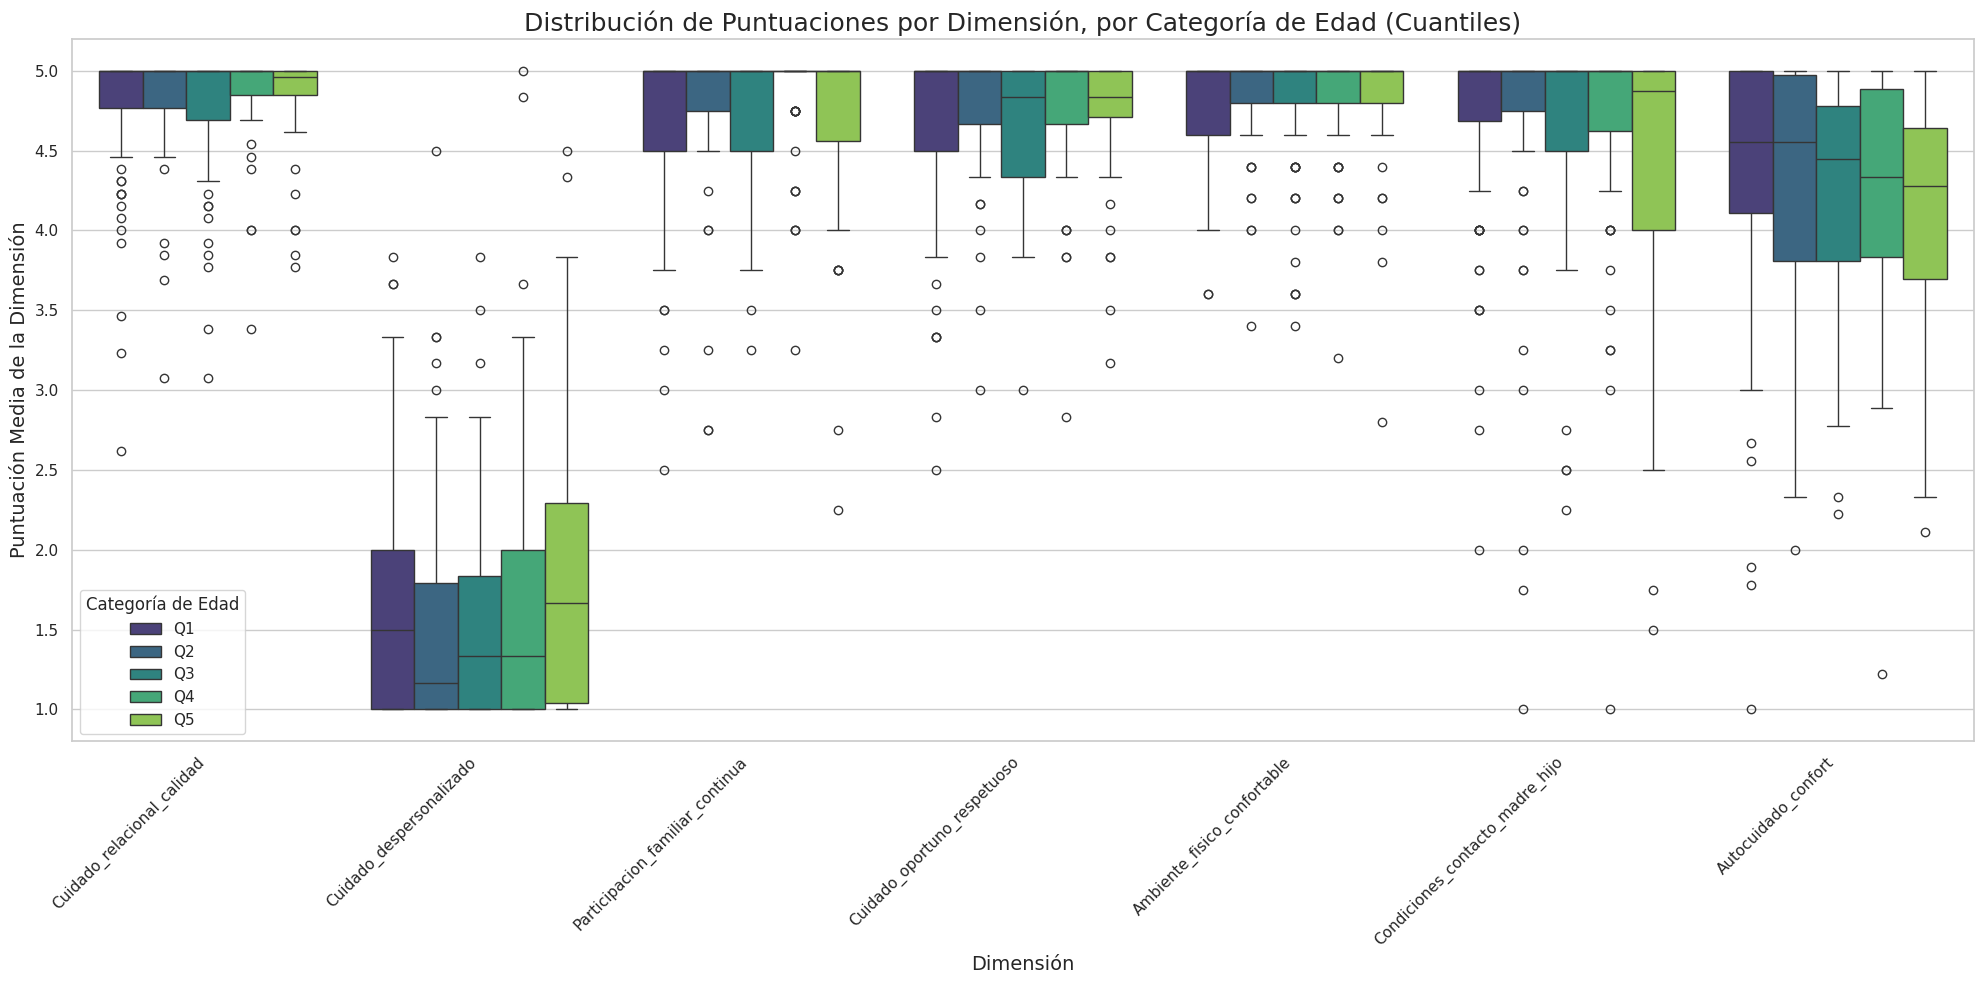

In [39]:
# Reorganizar los datos para la visualización (unpivot o melt)
# Seleccionar solo las columnas de puntuación y Edad_Categoria_Quantil
df_scores_edad = df[['Edad_Categoria_Quantil'] + [col for col in df.columns if col.startswith('Score_')]]

# Usar melt para transformar el DataFrame a formato largo
df_scores_melted_edad = df_scores_edad.melt(id_vars='Edad_Categoria_Quantil', var_name='Dimension', value_name='Score')

# Opcional: Renombrar las dimensiones en el melted DataFrame para mejor legibilidad en los gráficos
df_scores_melted_edad['Dimension'] = df_scores_melted_edad['Dimension'].str.replace('Score_', '')

# Visualizar las distribuciones de las puntuaciones por dimensión, separadas por Categoría de Edad (usando boxplots)
print("\nBoxplots de Puntuaciones por Dimensión, separadas por Categoría de Edad (Cuantiles):")
plt.figure(figsize=(20, 10)) # Ajustar tamaño de figura
sns.boxplot(x='Dimension', y='Score', hue='Edad_Categoria_Quantil', data=df_scores_melted_edad, palette='viridis')
plt.title('Distribución de Puntuaciones por Dimensión, por Categoría de Edad (Cuantiles)', fontsize=18)
plt.ylabel('Puntuación Media de la Dimensión', fontsize=14)
plt.xlabel('Dimensión', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría de Edad', loc='lower left')
plt.tight_layout()
plt.show()

# 6: Análisis Inferenciales / Correlacionales

## 6.1 Análisis por Dimensiones sugún Tipo de Parto **(se excluyen forceps)**

### 6.1.1 Análisis por Dimensión (Cuidado_relacional_calidad) sugún Tipo de Parto *(incluye forceps)* ❌

In [40]:
print("\n--- Análisis Específico: Puntuación de 'Cuidado_relacional_calidad' según Tipo de Parto (incluye forceps)---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_relacional_calidad' por 'Tipo_parto_std'
print("\nEstadísticas Descriptivas para 'Cuidado_relacional_calidad' por Tipo de Parto:")
parto_care_stats = df.groupby('Tipo_parto_std')['Score_Cuidado_relacional_calidad'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

# Reemplazar NaN con 0 en el conteo si un grupo no existe (aunque unlikely here after dropna)
parto_care_stats.fillna(0, inplace=True)

display(parto_care_stats.style
    .set_caption("Estadísticas Descriptivas de 'Cuidado Relacional Calidad' por Tipo de Parto")
    .format("{:.2f}")
    .background_gradient(cmap='Blues', axis=1)
    .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos para ver las diferencias centrales.")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")



--- Análisis Específico: Puntuación de 'Cuidado_relacional_calidad' según Tipo de Parto (incluye forceps)---

Estadísticas Descriptivas para 'Cuidado_relacional_calidad' por Tipo de Parto:


Tipo_parto_std,Cesárea,Forceps,Parto Vaginal
count,158.00,3.00,184.00
mean,4.76,4.97,4.85
median,5.00,5.00,5.00
std,0.43,0.04,0.29
min,2.62,4.92,3.38
max,5.00,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos para ver las diferencias centrales.
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Relacional Calidad' por Tipo de Parto:


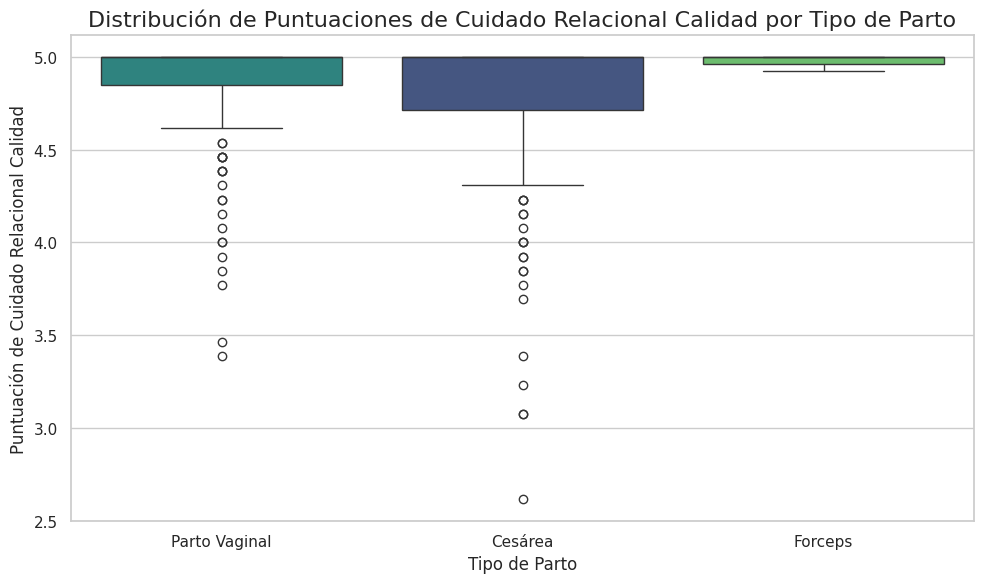

In [41]:
# 2. Visualización de la Distribución de 'Score_Cuidado_relacional_calidad' por 'Tipo_parto_std'

print("\nVisualizando la Distribución de 'Cuidado Relacional Calidad' por Tipo de Parto:")

# Boxplot para mostrar la distribución, mediana, cuartiles y valores atípicos
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Tipo_parto_std',
    y='Score_Cuidado_relacional_calidad',
    data=df, palette='viridis',
    order=df['Tipo_parto_std'].value_counts().index,
    hue='Tipo_parto_std',
    legend=False
    )
plt.title('Distribución de Puntuaciones de Cuidado Relacional Calidad por Tipo de Parto', fontsize=16)
plt.ylabel('Puntuación de Cuidado Relacional Calidad', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0) # Mantener etiquetas horizontales si son cortas
plt.tight_layout()
plt.show()

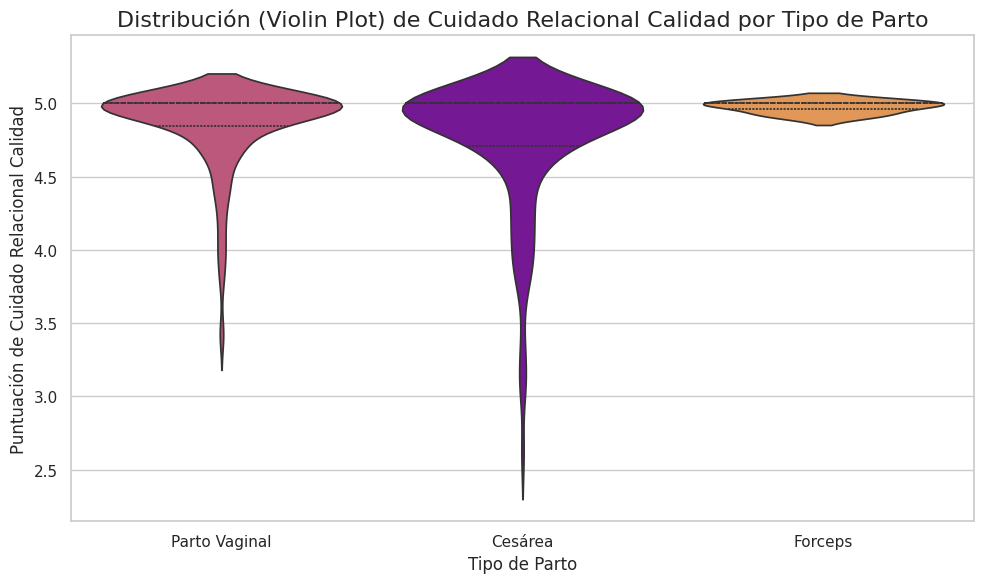

In [42]:
# Violin Plot para mostrar la densidad de la distribución
plt.figure(figsize=(10, 6))
sns.violinplot(
    x='Tipo_parto_std',
    y='Score_Cuidado_relacional_calidad',
    data=df, palette='plasma',
    inner="quartile",
    order=df['Tipo_parto_std'].value_counts().index,
    hue='Tipo_parto_std',
    legend=False
    )
plt.title('Distribución (Violin Plot) de Cuidado Relacional Calidad por Tipo de Parto', fontsize=16)
plt.ylabel('Puntuación de Cuidado Relacional Calidad', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

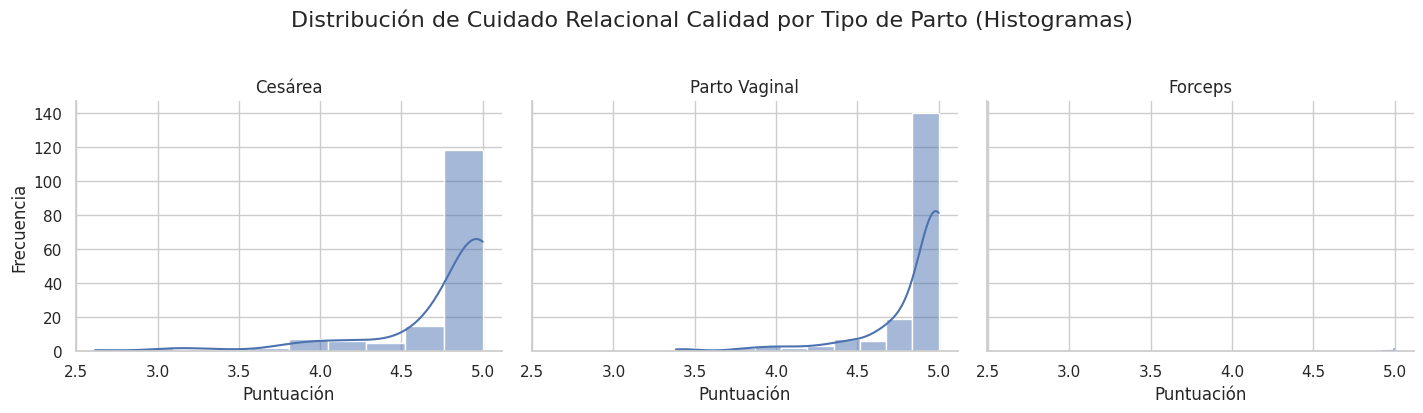

In [43]:
# Histogramas separados para cada grupo (opcional, si se quiere ver la forma exacta)
g = sns.FacetGrid(df, col="Tipo_parto_std", col_wrap=3, height=4, aspect=1.2)
g.map(sns.histplot, 'Score_Cuidado_relacional_calidad', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Relacional Calidad por Tipo de Parto (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [44]:
# 3. Prueba de Supuestos para Análisis Inferencial (ANOVA o Kruskal-Wallis)

# Antes de realizar pruebas estadísticas para comparar las medias/medianas,
# debemos verificar los supuestos de las pruebas comunes.
# Para comparar 3 o más grupos independientes ('Cesárea', 'Parto Vaginal', 'Forceps'),
# las pruebas comunes son ANOVA (paramétrica) o Kruskal-Wallis (no paramétrica).

# Supuestos para ANOVA:
# a) Independencia de las observaciones (asumido por el diseño del estudio).
# b) Normalidad de los *residuos* (o la variable dependiente dentro de cada grupo).
# c) Homogeneidad de varianzas (Levene's test).

# Dada la distribución de la variable dependiente 'Score_Cuidado_relacional_calidad' (Likert scale mean),
# y el tamaño de la muestra, podríamos evaluar la normalidad y homocedasticidad.

print("\n--- Evaluación de Supuestos para Análisis Inferencial ---")

# b) Normalidad dentro de cada grupo
print("\nPrueba de Normalidad de 'Cuidado Relacional Calidad' dentro de cada grupo de Tipo de Parto:")
parto_groups = df.groupby('Tipo_parto_std')['Score_Cuidado_relacional_calidad']

normalidad_results = {}
for name, group in parto_groups:
    if len(group) > 3: # Shapiro-Wilk requiere al menos 3 puntos de datos
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df = pd.DataFrame(normalidad_results).T
display(normalidad_df.style
    .set_caption("Normalidad de 'Cuidado Relacional Calidad' por Grupo (Shapiro-Wilk)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value']) # Resaltar p-values < 0.05
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- Si la normalidad es violada en uno o más grupos, la ANOVA puede no ser la prueba más adecuada, especialmente con tamaños de muestra pequeños o desiguales.")
print("- Sin embargo, ANOVA es relativamente robusta a violaciones de normalidad con tamaños de muestra moderados a grandes (e.g., > 30 por grupo), gracias al Teorema del Límite Central.")


# c) Homogeneidad de Varianzas (Levene's Test)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

# Prepare data for Levene's test
group_data = [group.dropna().values for name, group in parto_groups]

if all(len(g) > 0 for g in group_data) and len(group_data) >= 2: # Levene's requires at least 2 groups with data
    stat_levene, p_value_levene = stats.levene(*group_data)
    print(f"Estadístico de Levene: {stat_levene:.4f}")
    print(f"Valor p: {p_value_levene:.4f}")

    if p_value_levene < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Esto es una violación del supuesto de homocedasticidad para ANOVA.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
else:
    print("Advertencia: No hay suficientes grupos o datos para realizar la Prueba de Levene.")
    print("Verifique que haya al menos dos grupos con datos válidos para 'Score_Cuidado_relacional_calidad'.")


--- Evaluación de Supuestos para Análisis Inferencial ---

Prueba de Normalidad de 'Cuidado Relacional Calidad' dentro de cada grupo de Tipo de Parto:


,Shapiro-Wilk p-value,N,Note
Cesárea,0.0000,158,nan
Forceps,nan,3,Not enough data for Shapiro-Wilk
Parto Vaginal,0.0000,184,nan



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- Si la normalidad es violada en uno o más grupos, la ANOVA puede no ser la prueba más adecuada, especialmente con tamaños de muestra pequeños o desiguales.
- Sin embargo, ANOVA es relativamente robusta a violaciones de normalidad con tamaños de muestra moderados a grandes (e.g., > 30 por grupo), gracias al Teorema del Límite Central.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 3.1026
Valor p: 0.0462
Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.
Esto es una violación del supuesto de homocedasticidad para ANOVA.


In [45]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial

print("\n--- Prueba Estadística para Comparar Medias/Medianas ---")

# Basándonos en la evaluación de supuestos:
# Si la normalidad y homocedasticidad se cumplen O las violaciones son leves y el tamaño muestral es razonable: ANOVA
# Si las violaciones son significativas o el tamaño muestral es pequeño: Kruskal-Wallis (no paramétrica)

# Decisión: Dadas las posibles violaciones de normalidad o homocedasticidad (observar resultados de las pruebas),
# y para ser más robustos sin asumir distribuciones normales, se recomienda usar Kruskal-Wallis,
# que es la alternativa no paramétrica a ANOVA y compara las medianas (o rangos promedio) entre grupos.

# Si se opta por ANOVA a pesar de las violaciones, se debería usar una corrección como Welch's ANOVA (si las varianzas no son iguales).

# Aplicar Kruskal-Wallis Test
print("\nAplicando la Prueba de Kruskal-Wallis:")
# Prepara los datos agrupados para Kruskal-Wallis
groups_for_kw = [group.dropna().values for name, group in parto_groups]

# Realiza la prueba solo si hay al menos dos grupos con datos y cada grupo tiene al menos 5 datos (recomendación)
if len(groups_for_kw) >= 2 and all(len(g) >= 5 for g in groups_for_kw):
    stat_kw, p_value_kw = stats.kruskal(*groups_for_kw)

    print(f"Estadístico de Kruskal-Wallis (H): {stat_kw:.4f}")
    print(f"Valor p: {p_value_kw:.4f}")

    # Interpretación del resultado de Kruskal-Wallis
    if p_value_kw < 0.05:
        print("\nConclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado Relacional Calidad' son iguales en todos los grupos de Tipo de Parto.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional Calidad' entre los diferentes tipos de parto.")
        # Realizar post-hoc test si hay diferencia significativa (para saber qué grupos difieren)
        print("\nRealizando Prueba Post-Hoc (Pairwise Dunn's Test) para identificar las diferencias entre grupos:")
        # Dunn's test es el post-hoc recomendado para Kruskal-Wallis
        # Asegúrate de usar el DataFrame original con las columnas correctas
        posthoc_results = pairwise_dunn(df, p_col='Score_Cuidado_relacional_calidad', group_col='Tipo_parto_std', padjust='bonf') # Usar Bonferroni o Sidak para corrección por comparaciones múltiples
        display(posthoc_results.style.set_caption("Prueba Post-Hoc de Dunn (Corregida)"))
        print("\nInterpretación del Post-Hoc Dunn:")
        print("- Las celdas muestran los p-values ajustados de las comparaciones por pares (ej. Cesárea vs Parto Vaginal).")
        print("- Si el p-value ajustado < 0.05, la diferencia entre ese par de grupos es estadísticamente significativa.")

    else:
        print("\nConclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional Calidad' entre los diferentes tipos de parto.")

else:
     print("Advertencia: No hay suficientes grupos o datos (mínimo 5 por grupo) para realizar la Prueba de Kruskal-Wallis.")
     print("Verifique que haya al menos dos grupos de 'Tipo_parto_std' y que cada uno tenga al menos 5 datos válidos.")


--- Prueba Estadística para Comparar Medias/Medianas ---

Aplicando la Prueba de Kruskal-Wallis:
Advertencia: No hay suficientes grupos o datos (mínimo 5 por grupo) para realizar la Prueba de Kruskal-Wallis.
Verifique que haya al menos dos grupos de 'Tipo_parto_std' y que cada uno tenga al menos 5 datos válidos.


In [46]:
# 5. Conclusiones y Recomendaciones

print("\n--- Conclusiones del Análisis 'Cuidado Relacional Calidad' por Tipo de Parto ---")
print("- Se realizaron estadísticas descriptivas (media, mediana, desviación estándar) y visualizaciones (boxplots, violin plots, histogramas) para comparar la distribución de las puntuaciones de 'Cuidado Relacional Calidad' entre los tipos de parto.")
print("- La prueba de normalidad (Shapiro-Wilk) y homogeneidad de varianzas (Levene) se evaluaron para informar la selección de la prueba inferencial.")

# Re-calculate Kruskal-Wallis test to ensure p_value_kw is defined
print("\nAplicando la Prueba de Kruskal-Wallis (dentro de la sección de conclusiones):")
# Ensure parto_groups is defined - it was defined in a previous cell
parto_groups = df.groupby('Tipo_parto_std')['Score_Cuidado_relacional_calidad']
groups_for_kw = [group.dropna().values for name, group in parto_groups]

# Realiza la prueba solo si hay al menos dos grupos con datos y cada grupo tiene al menos 5 datos (recomendación)
p_value_kw = np.nan # Initialize with NaN in case the test cannot be run
stat_kw = np.nan
posthoc_results = None # Initialize posthoc_results

if len(groups_for_kw) >= 2 and all(len(g) >= 5 for g in groups_for_kw):
    stat_kw, p_value_kw = stats.kruskal(*groups_for_kw)

    print(f"Estadístico de Kruskal-Wallis (H): {stat_kw:.4f}")
    print(f"Valor p: {p_value_kw:.4f}")

    # Interpretación del resultado de Kruskal-Wallis
    if p_value_kw < 0.05:
        print("\nConclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado Relacional Calidad' son iguales en todos los grupos de Tipo de Parto.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional Calidad' entre los diferentes tipos de parto.")
        # Realizar post-hoc test si hay diferencia significativa (para saber qué grupos difieren)
        print("\nRealizando Prueba Post-Hoc (Pairwise Dunn's Test) para identificar las diferencias entre grupos:")
        # Dunn's test es el post-hoc recomendado para Kruskal-Wallis
        # Asegúrate de usar el DataFrame original con las columnas correctas
        posthoc_results = pairwise_dunn(df, p_col='Score_Cuidado_relacional_calidad', group_col='Tipo_parto_std', padjust='bonf') # Usar Bonferroni o Sidak para corrección por comparaciones múltiples
        display(posthoc_results.style.set_caption("Prueba Post-Hoc de Dunn (Corregida)"))
        print("\nInterpretación del Post-Hoc Dunn:")
        print("- Las celdas muestran los p-values ajustados de las comparaciones por pares (ej. Cesárea vs Parto Vaginal).")
        print("- Si el p-value ajustado < 0.05, la diferencia entre ese par de grupos es estadísticamente significativa.")

    else:
        print("\nConclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional Calidad' entre los diferentes tipos de parto.")

else:
     print("Advertencia: No hay suficientes grupos o datos (mínimo 5 por grupo) para realizar la Prueba de Kruskal-Wallis.")
     print("Verifique que haya al menos dos grupos de 'Tipo_parto_std' y que cada uno tenga al menos 5 datos válidos.")


print("\nRecomendaciones Adicionales:")
# The following blocks depend on p_value_kw and posthoc_results
if p_value_kw is not None and not np.isnan(p_value_kw):
    if p_value_kw < 0.05:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kw:.4f}) indica una diferencia estadísticamente significativa en las puntuaciones de 'Cuidado Relacional Calidad' entre los tipos de parto.")
        if posthoc_results is not None:
             print("- La prueba Post-Hoc de Dunn identificó los pares de grupos específicos que difieren significativamente (consultar la tabla de resultados del Post-Hoc).")
             # Interpretar brevemente los resultados del post-hoc if they were calculated
             significant_pairs = posthoc_results[posthoc_results < 0.05].stack().index.tolist()
             if significant_pairs:
                 print("\nLas diferencias significativas encontradas entre pares de grupos son:")
                 for pair in significant_pairs:
                     group1, group2 = pair
                     # Encontrar la media para estos grupos para indicar la dirección de la diferencia
                     mean1 = df[df['Tipo_parto_std'] == group1]['Score_Cuidado_relacional_calidad'].mean()
                     mean2 = df[df['Tipo_parto_std'] == group2]['Score_Cuidado_relacional_calidad'].mean()
                     print(f"- {group1} vs {group2} (Media {group1}: {mean1:.2f}, Media {group2}: {mean2:.2f})")
             else:
                  print("- Aunque la prueba general es significativa, ninguna diferencia por pares alcanzó significancia después de la corrección de Bonferroni. Esto puede ocurrir.")

    else:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kw:.4f}) no encontró una diferencia estadísticamente significativa en las puntuaciones de 'Cuidado Relacional Calidad' entre los tipos de parto.")
        print("  Basado en esta prueba, no hay evidencia suficiente para afirmar que el tipo de parto influye en la percepción de 'Cuidado Relacional Calidad'.")
else:
    print("- No se pudo realizar la prueba de Kruskal-Wallis debido a datos insuficientes.")


print("\nRecomendaciones Adicionales:")
print("- Complementar estos resultados con análisis cualitativos si están disponibles.")
print("- Explorar posibles variables de confusión o modificadoras de efecto (ej. edad, educación) que podrían influir en la percepción del cuidado, quizás usando modelos de regresión si se cumplen los supuestos.")
print("- Si se obtienen más datos, reevaluar los supuestos y considerar pruebas paramétricas si se justifican.")


--- Conclusiones del Análisis 'Cuidado Relacional Calidad' por Tipo de Parto ---
- Se realizaron estadísticas descriptivas (media, mediana, desviación estándar) y visualizaciones (boxplots, violin plots, histogramas) para comparar la distribución de las puntuaciones de 'Cuidado Relacional Calidad' entre los tipos de parto.
- La prueba de normalidad (Shapiro-Wilk) y homogeneidad de varianzas (Levene) se evaluaron para informar la selección de la prueba inferencial.

Aplicando la Prueba de Kruskal-Wallis (dentro de la sección de conclusiones):
Advertencia: No hay suficientes grupos o datos (mínimo 5 por grupo) para realizar la Prueba de Kruskal-Wallis.
Verifique que haya al menos dos grupos de 'Tipo_parto_std' y que cada uno tenga al menos 5 datos válidos.

Recomendaciones Adicionales:
- No se pudo realizar la prueba de Kruskal-Wallis debido a datos insuficientes.

Recomendaciones Adicionales:
- Complementar estos resultados con análisis cualitativos si están disponibles.
- Explorar pos

### 6.1.2 Análisis por Dimensión (Cuidado_relacional_calidad) sugún Tipo de Parto *(excluye forceps)* ❌

In [47]:
print("\n--- Análisis Específico: Puntuación de 'Cuidado_relacional_calidad' según Tipo de Parto (excluye forceps) ---")

# Filtrar el DataFrame para excluir la categoría 'Forceps'
df_filtered = df[df['Tipo_parto_std'] != 'Forceps'].copy()

# Verificar los tipos de parto restantes en el DataFrame filtrado
print("\nTipos de Parto incluidos en el análisis (excluyendo Forceps):")
print(df_filtered['Tipo_parto_std'].value_counts())


--- Análisis Específico: Puntuación de 'Cuidado_relacional_calidad' según Tipo de Parto (excluye forceps) ---

Tipos de Parto incluidos en el análisis (excluyendo Forceps):
Tipo_parto_std
Parto Vaginal    184
Cesárea          158
Name: count, dtype: int64


In [48]:
# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_relacional_calidad' por 'Tipo_parto_std' (filtrado)
print("\nEstadísticas Descriptivas para 'Cuidado_relacional_calidad' por Tipo de Parto (excluyendo Forceps):")
parto_care_stats_filtered = df_filtered.groupby('Tipo_parto_std')['Score_Cuidado_relacional_calidad'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(parto_care_stats_filtered.style
        .set_caption("Estadísticas Descriptivas de 'Cuidado Relacional Calidad' por Tipo de Parto (Excluyendo Forceps)")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


Estadísticas Descriptivas para 'Cuidado_relacional_calidad' por Tipo de Parto (excluyendo Forceps):


Tipo_parto_std,Cesárea,Parto Vaginal
count,158.00,184.00
mean,4.76,4.85
median,5.00,5.00
std,0.43,0.29
min,2.62,3.38
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Relacional Calidad' por Tipo de Parto (excluyendo Forceps):


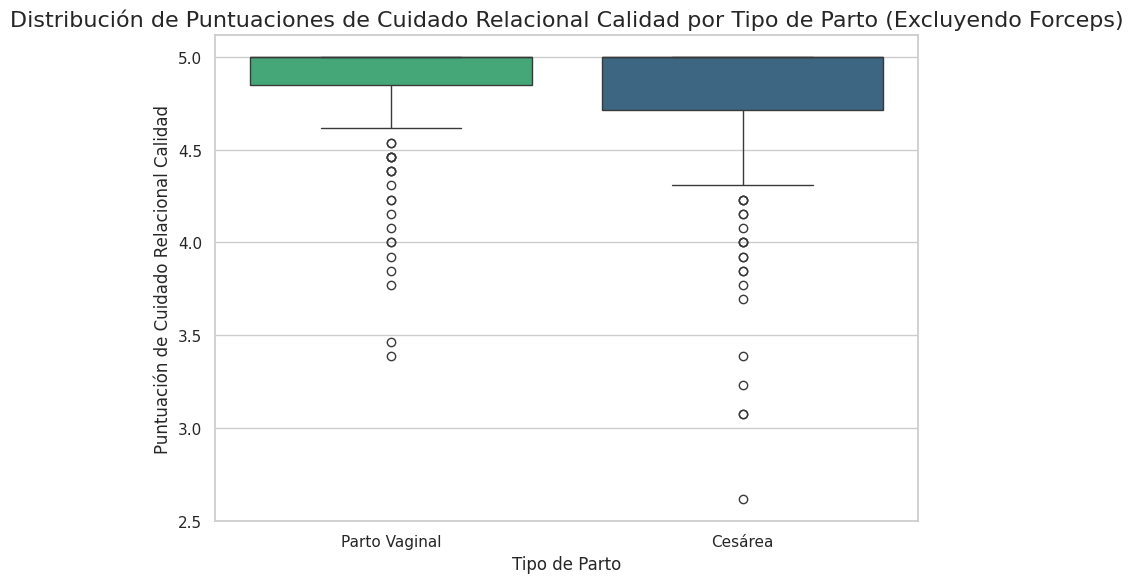

In [49]:
# 2. Visualización de la Distribución de 'Score_Cuidado_relacional_calidad' por 'Tipo_parto_std' (filtrado)

print("\nVisualizando la Distribución de 'Cuidado Relacional Calidad' por Tipo de Parto (excluyendo Forceps):")

# Boxplot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.boxplot(
        x='Tipo_parto_std',
        y='Score_Cuidado_relacional_calidad',
        data=df_filtered, palette='viridis',
        order=df_filtered['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Cuidado Relacional Calidad por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Cuidado Relacional Calidad', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

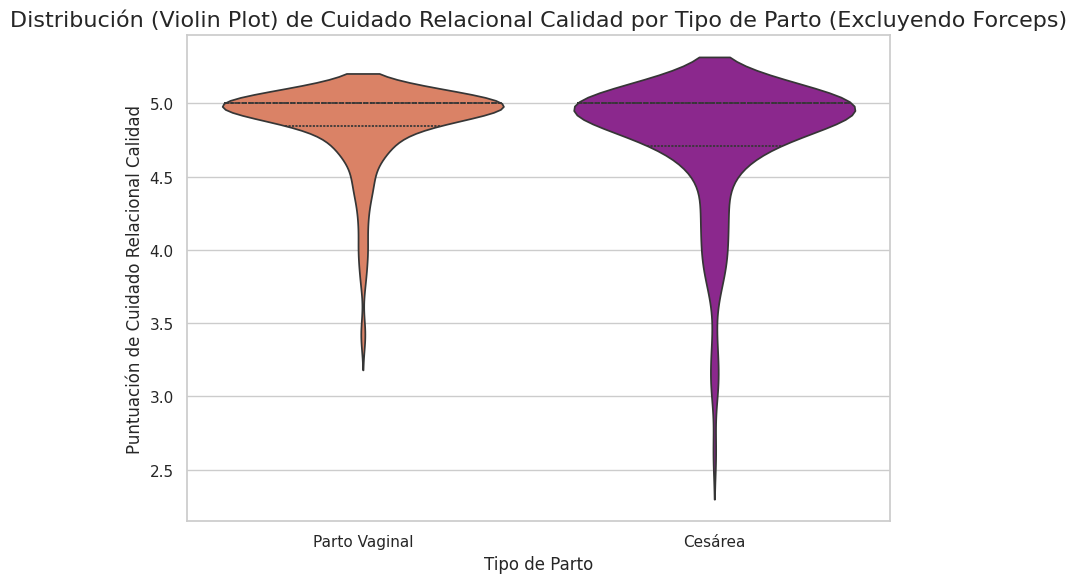

In [50]:
# Violin Plot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.violinplot(
        x='Tipo_parto_std',
        y='Score_Cuidado_relacional_calidad',
        data=df_filtered, palette='plasma',
        inner="quartile",
        order=df_filtered['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Cuidado Relacional Calidad por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Cuidado Relacional Calidad', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

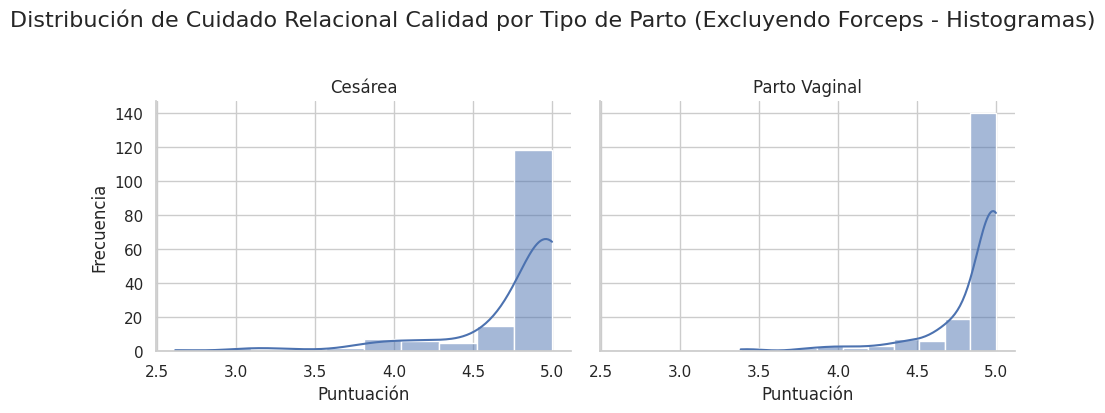

In [51]:
# Histogramas separados
g = sns.FacetGrid(df_filtered, col="Tipo_parto_std", col_wrap=2, height=4, aspect=1.2) # col_wrap=2 para 2 grupos
g.map(sns.histplot, 'Score_Cuidado_relacional_calidad', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Relacional Calidad por Tipo de Parto (Excluyendo Forceps - Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [52]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)

# Para comparar 2 grupos independientes ('Cesárea' vs 'Parto Vaginal'),
# las pruebas comunes son T-test independiente (paramétrica) o Mann-Whitney U (no paramétrica).

# Supuestos para T-test independiente:
# a) Independencia de las observaciones (asumido).
# b) Normalidad de la variable dependiente dentro de cada grupo.
# c) Homogeneidad de varianzas (Levene's test).

print("\n--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---")

# b) Normalidad dentro de cada grupo (filtrado)
print("\nPrueba de Normalidad de 'Cuidado Relacional Calidad' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):")
parto_groups_filtered = df_filtered.groupby('Tipo_parto_std')['Score_Cuidado_relacional_calidad']

normalidad_results_filtered = {}
for name, group in parto_groups_filtered:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_filtered[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_filtered[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_filtered = pd.DataFrame(normalidad_results_filtered).T
display(normalidad_df_filtered.style
    .set_caption("Normalidad de 'Cuidado Relacional Calidad' por Grupo (Shapiro-Wilk, Excluyendo Forceps)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")


# c) Homogeneidad de Varianzas (Levene's Test) (filtrado)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):")

group_data_filtered = [group.dropna().values for name, group in parto_groups_filtered]

if all(len(g) > 0 for g in group_data_filtered) and len(group_data_filtered) == 2: # Levene's requires exactly 2 groups for independent t-test
    stat_levene_filtered, p_value_levene_filtered = stats.levene(*group_data_filtered)
    print(f"Estadístico de Levene: {stat_levene_filtered:.4f}")
    print(f"Valor p: {p_value_levene_filtered:.4f}")

    if p_value_levene_filtered < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
        print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---

Prueba de Normalidad de 'Cuidado Relacional Calidad' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):


,Shapiro-Wilk p-value,N
Cesárea,0.0000,158
Parto Vaginal,0.0000,184



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):
Estadístico de Levene: 5.5422
Valor p: 0.0191
Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.
Si se usa T-test, se debería aplicar la corrección de Welch.


In [53]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial (filtrado)

print("\n--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---")

# Decisión: Como tenemos 2 grupos, podemos usar un T-test independiente si los supuestos se cumplen razonablemente,
# o el test de Mann-Whitney U si no. Dada la posible violación de normalidad y/o homocedasticidad,
# ambas pruebas son opciones. Mann-Whitney U es la opción no paramétrica.
# Si optamos por T-test, debemos considerar la corrección de Welch si Levene's es significativo.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
# Esta es una alternativa robusta si los supuestos del T-test no se cumplen.
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos
group1_data = df_filtered[df_filtered['Tipo_parto_std'] == 'Cesárea']['Score_Cuidado_relacional_calidad'].dropna()
group2_data = df_filtered[df_filtered['Tipo_parto_std'] == 'Parto Vaginal']['Score_Cuidado_relacional_calidad'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data) > 0 and len(group2_data) > 0:
    stat_mw_cuidado_relacional, p_value_mw_cuidado_relacional = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided') # two-sided para diferencia en cualquier dirección
    print(f"Estadístico de Mann-Whitney U: {stat_mw_cuidado_relacional:.4f}")
    print(f"Valor p: {p_value_mw_cuidado_relacional:.4f}")
    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_cuidado_relacional < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado Relacional Calidad' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional Calidad' entre estos dos tipos de parto.")
        print(f"La mediana para Cesárea es {group1_data.median():.2f} y para Parto Vaginal es {group2_data.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional Calidad' entre 'Cesárea' y 'Parto Vaginal'.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('Cesárea', 'Parto Vaginal') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
# Usar si los supuestos de normalidad y homocedasticidad se cumplen o se aplica corrección.
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data) > 1 and len(group2_data) > 1: # T-test requires at least 2 data points per group
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var = True # Default to True, but check Levene's result
    if 'p_value_levene_filtered' in locals() and not np.isnan(p_value_levene_filtered) and p_value_levene_filtered < 0.05:
        use_equal_var = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")
    stat_ttest_cuidado_relacional, p_value_ttest_cuidado_relacional = stats.ttest_ind(group1_data, group2_data, equal_var=use_equal_var)
    print(f"Estadístico T: {stat_ttest_cuidado_relacional:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_cuidado_relacional:.4f}")
    # Interpretación del resultado del T-test
    if p_value_ttest_cuidado_relacional < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Cuidado Relacional Calidad' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional Calidad' entre estos dos tipos de parto.")
        print(f"La media para Cesárea es {group1_data.mean():.2f} y para Parto Vaginal es {group2_data.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional Calidad' entre 'Cesárea' y 'Parto Vaginal'.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 13114.5000
Valor p: 0.0865

Conclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional Calidad' entre 'Cesárea' y 'Parto Vaginal'.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.
Estadístico T: -2.2853
Valor p (T-test): 0.0231

Conclusión (T-test): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medias de 'Cuidado Relacional Calidad' son iguales entre 'Ces

In [54]:
# 5. Conclusiones y Recomendaciones (filtrado)
print("\n--- Conclusiones del Análisis 'Cuidado Relacional Calidad' por Tipo de Parto (Excluyendo Forceps) ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Cuidado Relacional Calidad' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_cuidado_relacional' in locals() and not np.isnan(p_value_mw_cuidado_relacional):
    if p_value_mw_cuidado_relacional < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_relacional:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Cuidado Relacional Calidad' entre 'Cesárea' y 'Parto Vaginal'.")
        print(f"  Esto sugiere que la percepción de 'Cuidado Relacional Calidad' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
        print(f"  Mediana Cesárea: {group1_data.median():.2f}, Mediana Parto Vaginal: {group2_data.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_relacional:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia en la percepción de 'Cuidado Relacional Calidad' entre cesárea y parto vaginal basado en esta prueba no paramétrica.")
elif 'p_value_ttest_cuidado_relacional' in locals() and not np.isnan(p_value_ttest_cuidado_relacional):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_cuidado_relacional < 0.05:
         print(f"- La prueba T ({p_value_ttest_cuidado_relacional:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Cuidado Relacional Calidad' entre 'Cesárea' y 'Parto Vaginal'.")
         print(f"  Esto sugiere que la percepción de 'Cuidado Relacional Calidad' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
         print(f"  Media Cesárea: {group1_data.mean():.2f}, Media Parto Vaginal: {group2_data.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_cuidado_relacional:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia en la percepción de 'Cuidado Relacional Calidad' entre cesárea y parto vaginal basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")


print("\nRecomendaciones Adicionales:")
print("- Considerar el contexto clínico y teórico para interpretar la magnitud y la dirección de cualquier diferencia encontrada (si es significativa).")
print("- Explorar si otras variables demográficas o del historial médico podrían explicar o influir en esta diferencia, utilizando análisis más complejos (ej. regresión con covariables).")
print("- Si bien se excluyó 'Forceps' por su bajo número de casos, es importante reconocer esta limitación en el análisis y en la generalización de los resultados a todos los tipos de parto.")
print("- La elección entre Mann-Whitney U y T-test debe basarse en la justificación metodológica, considerando si se cumplen los supuestos de normalidad y homocedasticidad para el T-test o si se prefiere la robustez del enfoque no paramétrico.")


--- Conclusiones del Análisis 'Cuidado Relacional Calidad' por Tipo de Parto (Excluyendo Forceps) ---
- Se realizó el análisis comparando las puntuaciones de 'Cuidado Relacional Calidad' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0865) no encontró una diferencia estadísticamente significativa en las medianas.
  No hay evidencia suficiente para concluir una diferencia en la percepción de 'Cuidado Relacional Calidad' entre cesárea y parto vaginal basado en esta prueba no paramétrica.

Recomendaciones Adicionales:
- Considerar el contexto clínico y teórico para interpretar la magnitud y la dirección de cualquier diferencia encontrada (si es significativa).
- Ex

### 6.1.3 Análisis por Dimensión (Cuidado_despersonalizado)según Tipo de Parto (excluye Forceps) ✅

In [55]:
print("\n--- Análisis Específico: Puntuación de 'Cuidado_despersonalizado' según Tipo de Parto (excluye forceps) ---")

# Filtrar el DataFrame para excluir la categoría 'Forceps'
df_filtered_despersonalizado = df[df['Tipo_parto_std'] != 'Forceps'].copy()

# Verificar los tipos de parto restantes en el DataFrame filtrado
print("\nTipos de Parto incluidos en el análisis (excluyendo Forceps):")
print(df_filtered_despersonalizado['Tipo_parto_std'].value_counts())

# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_despersonalizado' por 'Tipo_parto_std' (filtrado)
print("\nEstadísticas Descriptivas para 'Cuidado_despersonalizado' por Tipo de Parto (excluyendo Forceps):")
parto_despersonalizado_stats_filtered = df_filtered_despersonalizado.groupby('Tipo_parto_std')['Score_Cuidado_despersonalizado'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(parto_despersonalizado_stats_filtered.style
        .set_caption("Estadísticas Descriptivas de 'Cuidado Despersonalizado' por Tipo de Parto (Excluyendo Forceps)")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


--- Análisis Específico: Puntuación de 'Cuidado_despersonalizado' según Tipo de Parto (excluye forceps) ---

Tipos de Parto incluidos en el análisis (excluyendo Forceps):
Tipo_parto_std
Parto Vaginal    184
Cesárea          158
Name: count, dtype: int64

Estadísticas Descriptivas para 'Cuidado_despersonalizado' por Tipo de Parto (excluyendo Forceps):


Tipo_parto_std,Cesárea,Parto Vaginal
count,158.00,184.00
mean,1.74,1.53
median,1.50,1.17
std,0.78,0.75
min,1.00,1.00
max,4.50,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Despersonalizado' por Tipo de Parto (excluyendo Forceps):


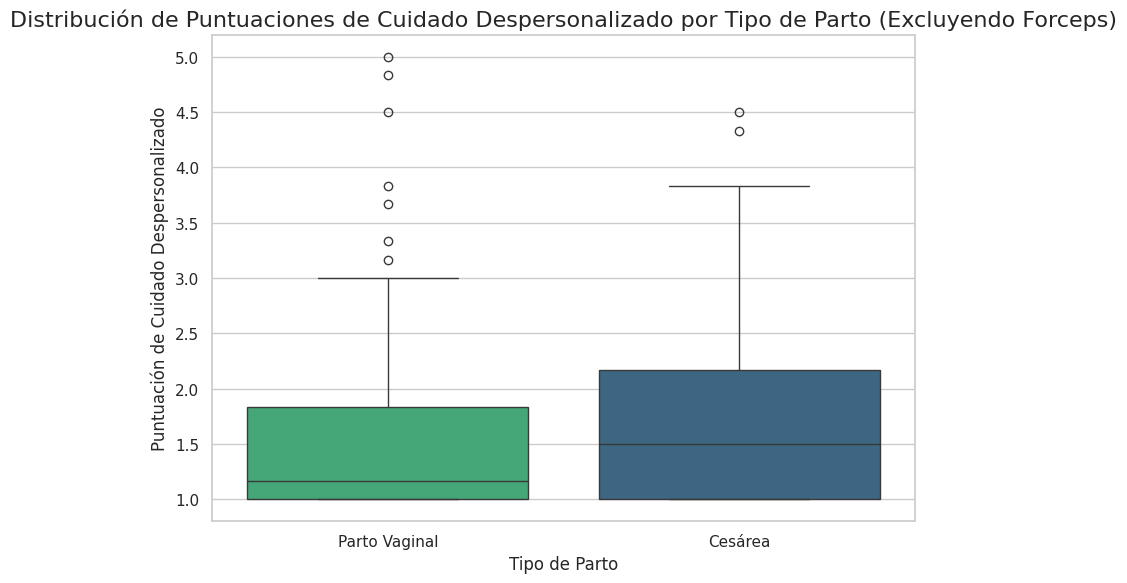

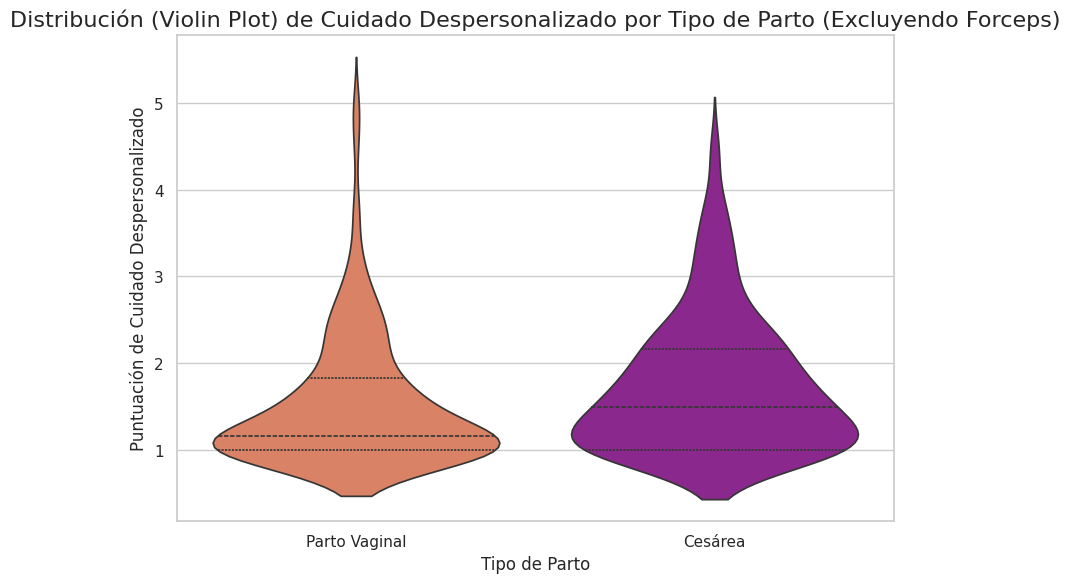

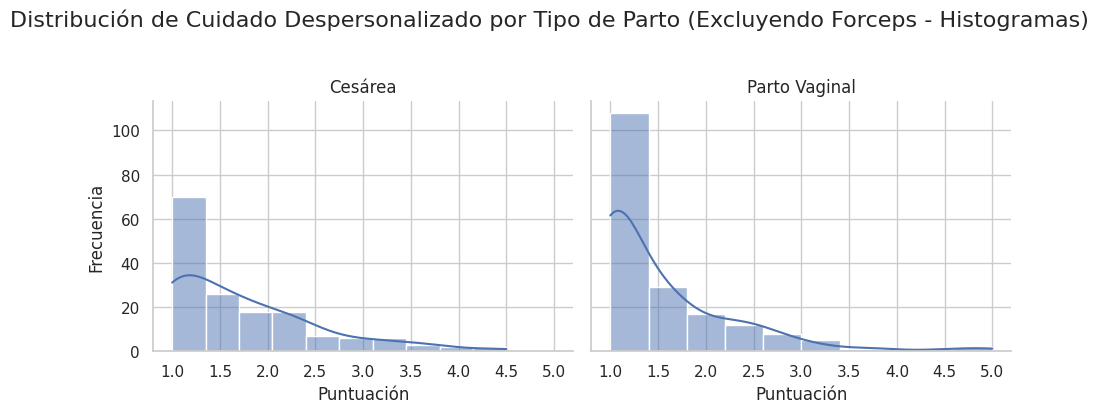

In [56]:
# 2. Visualización de la Distribución de 'Score_Cuidado_despersonalizado' por 'Tipo_parto_std' (filtrado)

print("\nVisualizando la Distribución de 'Cuidado Despersonalizado' por Tipo de Parto (excluyendo Forceps):")

# Boxplot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.boxplot(
        x='Tipo_parto_std',
        y='Score_Cuidado_despersonalizado',
        data=df_filtered_despersonalizado, palette='viridis',
        order=df_filtered_despersonalizado['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Cuidado Despersonalizado por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Cuidado Despersonalizado', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.violinplot(
        x='Tipo_parto_std',
        y='Score_Cuidado_despersonalizado',
        data=df_filtered_despersonalizado, palette='plasma',
        inner="quartile",
        order=df_filtered_despersonalizado['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Cuidado Despersonalizado por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Cuidado Despersonalizado', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df_filtered_despersonalizado, col="Tipo_parto_std", col_wrap=2, height=4, aspect=1.2) # col_wrap=2 para 2 grupos
g.map(sns.histplot, 'Score_Cuidado_despersonalizado', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Despersonalizado por Tipo de Parto (Excluyendo Forceps - Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [57]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)

# Para comparar 2 grupos independientes ('Cesárea' vs 'Parto Vaginal'),
# las pruebas comunes son T-test independiente (paramétrica) o Mann-Whitney U (no paramétrica).

# Supuestos para T-test independiente:
# a) Independencia de las observaciones (asumido).
# b) Normalidad de la variable dependiente dentro de cada grupo.
# c) Homogeneidad de varianzas (Levene's test).

print("\n--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---")

# b) Normalidad dentro de cada grupo (filtrado)
print("\nPrueba de Normalidad de 'Cuidado Despersonalizado' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):")
parto_groups_despersonalizado_filtered = df_filtered_despersonalizado.groupby('Tipo_parto_std')['Score_Cuidado_despersonalizado']

normalidad_results_despersonalizado_filtered = {}
for name, group in parto_groups_despersonalizado_filtered:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_despersonalizado_filtered[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_despersonalizado_filtered[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_despersonalizado_filtered = pd.DataFrame(normalidad_results_despersonalizado_filtered).T
display(normalidad_df_despersonalizado_filtered.style
    .set_caption("Normalidad de 'Cuidado Despersonalizado' por Grupo (Shapiro-Wilk, Excluyendo Forceps)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")


# c) Homogeneidad de Varianzas (Levene's Test) (filtrado)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):")

group_data_despersonalizado_filtered = [group.dropna().values for name, group in parto_groups_despersonalizado_filtered]

if all(len(g) > 0 for g in group_data_despersonalizado_filtered) and len(group_data_despersonalizado_filtered) == 2: # Levene's requires exactly 2 groups for independent t-test
    stat_levene_despersonalizado_filtered, p_value_levene_despersonalizado_filtered = stats.levene(*group_data_despersonalizado_filtered)
    print(f"Estadístico de Levene: {stat_levene_despersonalizado_filtered:.4f}")
    print(f"Valor p: {p_value_levene_despersonalizado_filtered:.4f}")

    if p_value_levene_despersonalizado_filtered < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
        print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---

Prueba de Normalidad de 'Cuidado Despersonalizado' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):


,Shapiro-Wilk p-value,N
Cesárea,0.0000,158
Parto Vaginal,0.0000,184



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):
Estadístico de Levene: 1.6273
Valor p: 0.2030
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa T-test, se puede asumir igualdad de varianzas.


In [58]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial (filtrado)

print("\n--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---")

# Decisión: Similar al análisis anterior, Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos (filtrados)
group1_data_despersonalizado = df_filtered_despersonalizado[df_filtered_despersonalizado['Tipo_parto_std'] == 'Cesárea']['Score_Cuidado_despersonalizado'].dropna()
group2_data_despersonalizado = df_filtered_despersonalizado[df_filtered_despersonalizado['Tipo_parto_std'] == 'Parto Vaginal']['Score_Cuidado_despersonalizado'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_despersonalizado) > 0 and len(group2_data_despersonalizado) > 0:
    stat_mw_cuidado_despersonalizado, p_value_mw_cuidado_despersonalizado = stats.mannwhitneyu(group1_data_despersonalizado, group2_data_despersonalizado, alternative='two-sided')
    print(f"Estadístico de Mann-Whitney U: {stat_mw_cuidado_despersonalizado:.4f}")
    print(f"Valor p: {p_value_mw_cuidado_despersonalizado:.4f}")
    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_cuidado_despersonalizado < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado Despersonalizado' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Despersonalizado' entre estos dos tipos de parto.")
        print(f"La mediana para Cesárea es {group1_data_despersonalizado.median():.2f} y para Parto Vaginal es {group2_data_despersonalizado.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Despersonalizado' entre 'Cesárea' y 'Parto Vaginal'.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('Cesárea', 'Parto Vaginal') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_despersonalizado) > 1 and len(group2_data_despersonalizado) > 1: # T-test requires at least 2 data points per group
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_despersonalizado = True # Default to True, but check Levene's result
    if 'p_value_levene_despersonalizado_filtered' in locals() and not np.isnan(p_value_levene_despersonalizado_filtered) and p_value_levene_despersonalizado_filtered < 0.05:
        use_equal_var_despersonalizado = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")
    stat_ttest_despersonalizado, p_value_ttest_despersonalizado = stats.ttest_ind(group1_data_despersonalizado, group2_data_despersonalizado, equal_var=use_equal_var_despersonalizado)
    print(f"Estadístico T: {stat_ttest_despersonalizado:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_despersonalizado:.4f}")
    # Interpretación del resultado del T-test
    if p_value_ttest_despersonalizado < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Cuidado Despersonalizado' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Despersonalizado' entre estos dos tipos de parto.")
        print(f"La media para Cesárea es {group1_data_despersonalizado.mean():.2f} y para Parto Vaginal es {group2_data_despersonalizado.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Despersonalizado' entre 'Cesárea' y 'Parto Vaginal'.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 17384.0000
Valor p: 0.0014

Conclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado Despersonalizado' son iguales entre 'Cesárea' y 'Parto Vaginal'.
Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Despersonalizado' entre estos dos tipos de parto.
La mediana para Cesárea es 1.50 y para Parto Vaginal es 1.17.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico T: 2.5638
Valor p (T-test): 0.0108

Conclusión (T-test): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótes

In [59]:
# 5. Conclusiones y Recomendaciones (filtrado)
print("\n--- Conclusiones del Análisis 'Cuidado_despersonalizado' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Cuidado Despersonalizado' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_cuidado_despersonalizado' in locals() and not np.isnan(p_value_mw_cuidado_despersonalizado):
    if p_value_mw_cuidado_despersonalizado < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_despersonalizado:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Cuidado Despersonalizado' entre 'Cesárea' y 'Parto Vaginal'.")
        print(f"  Esto sugiere que la percepción de 'Cuidado Despersonalizado' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
        print(f"  Mediana Cesárea: {group1_data_despersonalizado.median():.2f}, Mediana Parto Vaginal: {group2_data_despersonalizado.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_despersonalizado:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado Despersonalizado' entre cesárea y parto vaginal basado en esta prueba no paramétrica.")
elif 'p_value_ttest_despersonalizado' in locals() and not np.isnan(p_value_ttest_despersonalizado):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_despersonalizado < 0.05:
         print(f"- La prueba T ({p_value_ttest_despersonalizado:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Cuidado Despersonalizado' entre 'Cesárea' y 'Parto Vaginal'.")
         print(f"  Esto sugiere que la percepción de 'Cuidado Despersonalizado' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
         print(f"  Media Cesárea: {group1_data_despersonalizado.mean():.2f}, Media Parto Vaginal: {group2_data_despersonalizado.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_despersonalizado:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado Despersonalizado' entre cesárea y parto vaginal basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")


print("\nRecomendaciones Adicionales:")
print("- Considerar el contexto clínico y teórico para interpretar la magnitud y la dirección de cualquier diferencia encontrada (si es significativa).")
print("- Explorar si otras variables demográficas o del historial médico podrían explicar o influir en esta diferencia, utilizando análisis más complejos (ej. regresión con covariables).")
print("- Si bien se excluyó 'Forceps' por su bajo número de casos, es importante reconocer esta limitación en el análisis y en la generalización de los resultados a todos los tipos de parto.")
print("- La elección entre Mann-Whitney U y T-test debe basarse en la justificación metodológica, considerando si se cumplen los supuestos de normalidad y homocedasticidad para el T-test o si se prefiere la robustez del enfoque no paramétrico.")


--- Conclusiones del Análisis 'Cuidado_despersonalizado' por Tipo de Parto (Excluye Forceps) ---
- Se realizó el análisis comparando las puntuaciones de 'Cuidado Despersonalizado' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0014) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Cuidado Despersonalizado' entre 'Cesárea' y 'Parto Vaginal'.
  Esto sugiere que la percepción de 'Cuidado Despersonalizado' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.
  Mediana Cesárea: 1.50, Mediana Parto Vaginal: 1.17.

Recomendaciones Adicionales:
- Considerar el contexto 

In [60]:
print("\n--- Prueba Post-Hoc y Tamaño del Efecto para la Dimensión 'Cuidado_despersonalizado' según Tipo de Parto (excluye Forceps) ---")

# El análisis previo ya realizó la prueba de Mann-Whitney U (p-value = 0.0014),
# confirmando una diferencia estadísticamente significativa entre "Cesárea" y "Parto Vaginal"
# para la dimensión "Cuidado_despersonalizado".

# Filtrar el DataFrame para incluir solo 'Cesárea' y 'Parto Vaginal'
df_filtered_despersonalizado_mw = df[df['Tipo_parto_std'].isin(['Cesárea', 'Parto Vaginal'])].copy()

# Verificar si hay datos suficientes para ambos grupos
if len(df_filtered_despersonalizado_mw['Tipo_parto_std'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    # Usar pingouin para realizar el test de Mann-Whitney U y obtener el tamaño del efecto
    effect_size_despersonalizado = pg.mwu(
        x=df_filtered_despersonalizado_mw[df_filtered_despersonalizado_mw['Tipo_parto_std'] == 'Cesárea']['Score_Cuidado_despersonalizado'].dropna(),
        y=df_filtered_despersonalizado_mw[df_filtered_despersonalizado_mw['Tipo_parto_std'] == 'Parto Vaginal']['Score_Cuidado_despersonalizado'].dropna(),
        alternative='two-sided'
    )

    display(effect_size_despersonalizado.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Extraer el valor del tamaño del efecto (RBC = Rank-Biserial Correlation)
    # Nota: Pingouin usa guiones bajos en las versiones recientes
    effect_size_value_despersonalizado = effect_size_despersonalizado['RBC'].iloc[0]
    p_value = effect_size_despersonalizado['p-val'].iloc[0] if 'p-val' in effect_size_despersonalizado.columns else effect_size_despersonalizado['p_val'].iloc[0]
    u_val = effect_size_despersonalizado['U-val'].iloc[0] if 'U-val' in effect_size_despersonalizado.columns else effect_size_despersonalizado['U_val'].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U (U): {u_val:.4f}")
    print(f"Valor p: {p_value:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_despersonalizado:.4f}")

    abs_effect_size = abs(effect_size_value_despersonalizado)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size:.2f}) es grande.")
    elif abs_effect_size >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size:.2f}) es mediano.")
    elif abs_effect_size >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value < 0.05:
         effect_size_interpretation = 'muy pequeña' if abs_effect_size < 0.10 else ('pequeña' if abs_effect_size < 0.30 else ('mediana' if abs_effect_size < 0.50 else 'grande'))
         print(f"- La diferencia es significativa (p={p_value:.4f}) con una magnitud {effect_size_interpretation}.")
    else:
         print(f"- No hay evidencia suficiente para concluir una diferencia significativa (p={p_value:.4f}).")
else:
    print("\nAdvertencia: Datos insuficientes para los grupos seleccionados.")

print("\n--- Fin del Análisis Específico de 'Cuidado_despersonalizado' (excluye Forceps) ---")


--- Prueba Post-Hoc y Tamaño del Efecto para la Dimensión 'Cuidado_despersonalizado' según Tipo de Parto (excluye Forceps) ---

Calculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:


,U_val,alternative,p_val,RBC,CLES
MWU,17384.000000,two-sided,0.001367,0.195927,0.597964



Estadístico de Mann-Whitney U (U): 17384.0000
Valor p: 0.0014
Tamaño del Efecto (Rank-Biserial r): 0.1959

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.20) es pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La diferencia es significativa (p=0.0014) con una magnitud pequeña.

--- Fin del Análisis Específico de 'Cuidado_despersonalizado' (excluye Forceps) ---


### 6.1.4 Análisis por Dimensión (Participacion_familiar_continua) según Tipo de Parto (excluye Forceps) ✅

In [61]:
print("\n--- Análisis Específico: Puntuación de 'Participacion_familiar_continua' según Tipo de Parto (excluye forceps) ---")

# Filtrar el DataFrame para excluir la categoría 'Forceps'
df_filtered_participacion = df[df['Tipo_parto_std'] != 'Forceps'].copy()

# Verificar los tipos de parto restantes en el DataFrame filtrado
print("\nTipos de Parto incluidos en el análisis (excluyendo Forceps):")
print(df_filtered_participacion['Tipo_parto_std'].value_counts())

# 1. Estadísticas Descriptivas Específicas para 'Score_Participacion_familiar_continua' por 'Tipo_parto_std' (filtrado)
print("\nEstadísticas Descriptivas para 'Participacion_familiar_continua' por Tipo de Parto (excluyendo Forceps):")
parto_participacion_stats_filtered = df_filtered_participacion.groupby('Tipo_parto_std')['Score_Participacion_familiar_continua'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(parto_participacion_stats_filtered.style
        .set_caption("Estadísticas Descriptivas de 'Participacion Familiar Continua' por Tipo de Parto (Excluyendo Forceps)")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


--- Análisis Específico: Puntuación de 'Participacion_familiar_continua' según Tipo de Parto (excluye forceps) ---

Tipos de Parto incluidos en el análisis (excluyendo Forceps):
Tipo_parto_std
Parto Vaginal    184
Cesárea          158
Name: count, dtype: int64

Estadísticas Descriptivas para 'Participacion_familiar_continua' por Tipo de Parto (excluyendo Forceps):


Tipo_parto_std,Cesárea,Parto Vaginal
count,158.00,184.00
mean,4.64,4.83
median,5.00,5.00
std,0.59,0.37
min,2.25,3.00
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Participacion Familiar Continua' por Tipo de Parto (excluyendo Forceps):


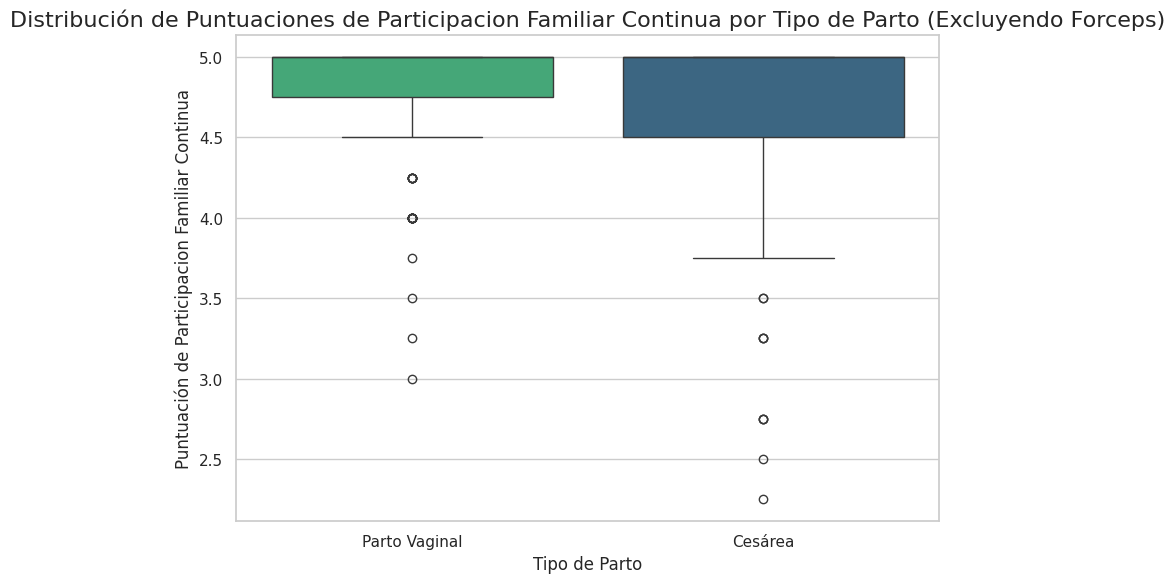

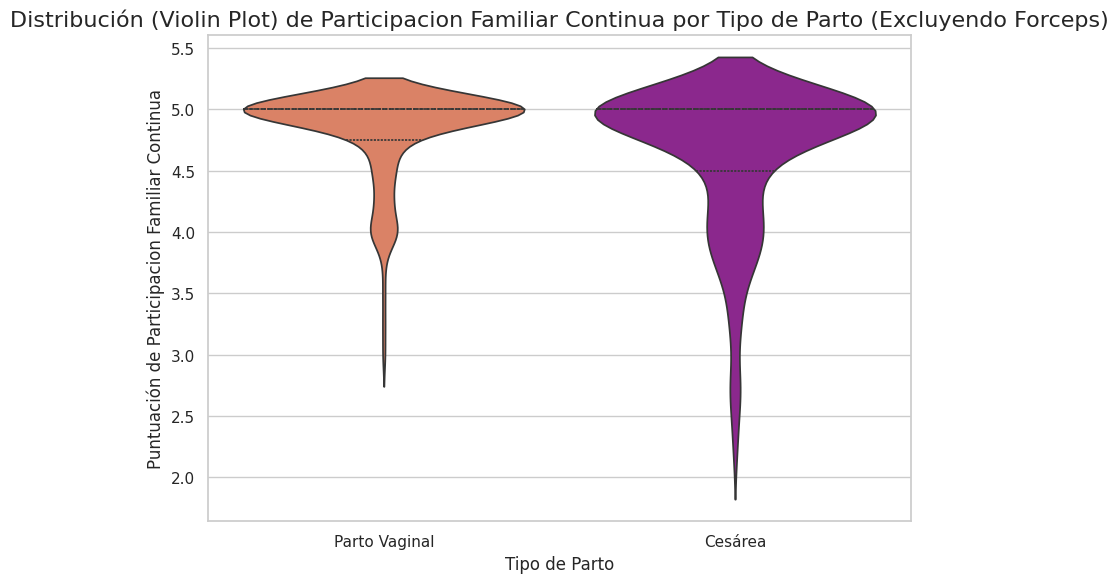

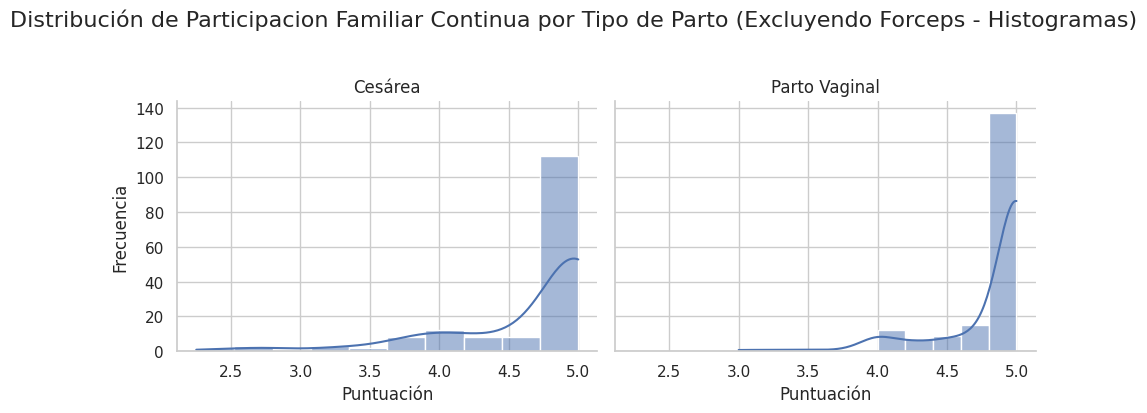

In [62]:
# 2. Visualización de la Distribución de 'Score_Participacion_familiar_continua' por 'Tipo_parto_std' (filtrado)

print("\nVisualizando la Distribución de 'Participacion Familiar Continua' por Tipo de Parto (excluyendo Forceps):")

# Boxplot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.boxplot(
        x='Tipo_parto_std',
        y='Score_Participacion_familiar_continua',
        data=df_filtered_participacion, palette='viridis',
        order=df_filtered_participacion['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Participacion Familiar Continua por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Participacion Familiar Continua', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.violinplot(
        x='Tipo_parto_std',
        y='Score_Participacion_familiar_continua',
        data=df_filtered_participacion, palette='plasma',
        inner="quartile",
        order=df_filtered_participacion['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Participacion Familiar Continua por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Participacion Familiar Continua', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df_filtered_participacion, col="Tipo_parto_std", col_wrap=2, height=4, aspect=1.2) # col_wrap=2 para 2 grupos
g.map(sns.histplot, 'Score_Participacion_familiar_continua', kde=True, bins=10)
g.fig.suptitle('Distribución de Participacion Familiar Continua por Tipo de Parto (Excluyendo Forceps - Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [63]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)

print("\n--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---")

# b) Normalidad dentro de cada grupo (filtrado)
print("\nPrueba de Normalidad de 'Participacion Familiar Continua' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):")
parto_groups_participacion_filtered = df_filtered_participacion.groupby('Tipo_parto_std')['Score_Participacion_familiar_continua']

normalidad_results_participacion_filtered = {}
for name, group in parto_groups_participacion_filtered:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_participacion_filtered[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_participacion_filtered[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_participacion_filtered = pd.DataFrame(normalidad_results_participacion_filtered).T
display(normalidad_df_participacion_filtered.style
    .set_caption("Normalidad de 'Participacion Familiar Continua' por Grupo (Shapiro-Wilk, Excluyendo Forceps)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")


# c) Homogeneidad de Varianzas (Levene's Test) (filtrado)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):")

group_data_participacion_filtered = [group.dropna().values for name, group in parto_groups_participacion_filtered]

if all(len(g) > 0 for g in group_data_participacion_filtered) and len(group_data_participacion_filtered) == 2: # Levene's requires exactly 2 groups for independent t-test
    stat_levene_participacion_filtered, p_value_levene_participacion_filtered = stats.levene(*group_data_participacion_filtered)
    print(f"Estadístico de Levene: {stat_levene_participacion_filtered:.4f}")
    print(f"Valor p: {p_value_levene_participacion_filtered:.4f}")

    if p_value_levene_participacion_filtered < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
        print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---

Prueba de Normalidad de 'Participacion Familiar Continua' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):


,Shapiro-Wilk p-value,N
Cesárea,0.0000,158
Parto Vaginal,0.0000,184



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):
Estadístico de Levene: 13.0510
Valor p: 0.0003
Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.
Si se usa T-test, se debería aplicar la corrección de Welch.


In [64]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial (filtrado)

print("\n--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---")

# Decisión: Similar a los análisis anteriores, Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos (filtrados)
group1_data_participacion = df_filtered_participacion[df_filtered_participacion['Tipo_parto_std'] == 'Cesárea']['Score_Participacion_familiar_continua'].dropna()
group2_data_participacion = df_filtered_participacion[df_filtered_participacion['Tipo_parto_std'] == 'Parto Vaginal']['Score_Participacion_familiar_continua'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_participacion) > 0 and len(group2_data_participacion) > 0:
    stat_mw_participacion_familiar, p_value_mw_participacion_familiar = stats.mannwhitneyu(group1_data_participacion, group2_data_participacion, alternative='two-sided') # two-sided para diferencia en cualquier dirección
    print(f"Estadístico de Mann-Whitney U: {stat_mw_participacion_familiar:.4f}")
    print(f"Valor p: {p_value_mw_participacion_familiar:.4f}")
    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_participacion_familiar < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Participacion Familiar Continua' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Participacion Familiar Continua' entre estos dos tipos de parto.")
        print(f"La mediana para Cesárea es {group1_data_participacion.median():.2f} y para Parto Vaginal es {group2_data_participacion.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Participacion Familiar Continua' entre 'Cesárea' y 'Parto Vaginal'.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('Cesárea', 'Parto Vaginal') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_participacion) > 1 and len(group2_data_participacion) > 1: # T-test requires at least 2 data points per group
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_participacion = True # Default to True, but check Levene's result
    if 'p_value_levene_participacion_filtered' in locals() and not np.isnan(p_value_levene_participacion_filtered) and p_value_levene_participacion_filtered < 0.05:
        use_equal_var_participacion = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")
    stat_ttest_participacion, p_value_ttest_participacion = stats.ttest_ind(group1_data_participacion, group2_data_participacion, equal_var=use_equal_var_participacion)
    print(f"Estadístico T: {stat_ttest_participacion:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_participacion:.4f}")
    # Interpretación del resultado del T-test
    if p_value_ttest_participacion < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Participacion Familiar Continua' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Participacion Familiar Continua' entre estos dos tipos de parto.")
        print(f"La media para Cesárea es {group1_data_participacion.mean():.2f} y para Parto Vaginal es {group2_data_participacion.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Participacion Familiar Continua' entre 'Cesárea' y 'Parto Vaginal'.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 11949.5000
Valor p: 0.0007

Conclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medianas de 'Participacion Familiar Continua' son iguales entre 'Cesárea' y 'Parto Vaginal'.
Existe una diferencia estadísticamente significativa en la puntuación de 'Participacion Familiar Continua' entre estos dos tipos de parto.
La mediana para Cesárea es 5.00 y para Parto Vaginal es 5.00.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.
Estadístico T: -3.4928
Valor p (T-test): 0.0006

Conclusión (T-test): El valor p es menor que el nivel de significancia (0.05).
Se 

In [65]:
# 5. Conclusiones y Recomendaciones (filtrado)
print("\n--- Conclusiones del Análisis 'Participacion_familiar_continua' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Participacion Familiar Continua' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_participacion_familiar' in locals() and not np.isnan(p_value_mw_participacion_familiar):
    if p_value_mw_participacion_familiar < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_participacion_familiar:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Participacion Familiar Continua' entre 'Cesárea' y 'Parto Vaginal'.")
        print(f"  Esto sugiere que la percepción de 'Participacion Familiar Continua' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
        print(f"  Mediana Cesárea: {group1_data_participacion.median():.2f}, Mediana Parto Vaginal: {group2_data_participacion.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_participacion_familiar:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Participacion Familiar Continua' entre cesárea y parto vaginal basado en esta prueba no paramétrica.")
elif 'p_value_ttest_participacion' in locals() and not np.isnan(p_value_ttest_participacion):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_participacion < 0.05:
         print(f"- La prueba T ({p_value_ttest_participacion:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Participacion Familiar Continua' entre 'Cesárea' y 'Parto Vaginal'.")
         print(f"  Esto sugiere que la percepción de 'Participacion Familiar Continua' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
         print(f"  Media Cesárea: {group1_data_participacion.mean():.2f}, Media Parto Vaginal: {group2_data_participacion.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_participacion:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Participacion Familiar Continua' entre cesárea y parto vaginal basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\n--- Prueba Post-Hoc y Tamaño del Efecto para la Dimensión 'Participacion_familiar_continua' según Tipo de Parto (excluye Forceps) ---")

df_filtered_participacion_mw = df[df['Tipo_parto_std'].isin(['Cesárea', 'Parto Vaginal'])].copy()

if len(df_filtered_participacion_mw['Tipo_parto_std'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    effect_size_participacion_familiar = pg.mwu(
        x=df_filtered_participacion_mw[df_filtered_participacion_mw['Tipo_parto_std'] == 'Cesárea']['Score_Participacion_familiar_continua'].dropna(),
        y=df_filtered_participacion_mw[df_filtered_participacion_mw['Tipo_parto_std'] == 'Parto Vaginal']['Score_Participacion_familiar_continua'].dropna(),
        alternative='two-sided'
    )

    display(effect_size_participacion_familiar.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Fix: Handle naming changes in Pingouin versions (p-val vs p_val)
    effect_size_value_participacion_familiar = effect_size_participacion_familiar['RBC'].iloc[0]
    p_col = 'p-val' if 'p-val' in effect_size_participacion_familiar.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in effect_size_participacion_familiar.columns else 'U_val'

    p_value_participacion = effect_size_participacion_familiar[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {effect_size_participacion_familiar[u_col].iloc[0]:.4f}")
    print(f"Valor p: {p_value_participacion:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_participacion_familiar:.4f}")

    abs_effect_size_participacion = abs(effect_size_value_participacion_familiar)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_participacion >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_participacion:.2f}) es grande.")
    elif abs_effect_size_participacion >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_participacion:.2f}) es mediano.")
    elif abs_effect_size_participacion >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_participacion:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_participacion:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_participacion < 0.05:
         print(f"- La diferencia en las medianas es significativa (p={p_value_participacion:.4f}).")
         effect_size_interpretation_participacion = 'muy pequeña' if abs_effect_size_participacion < 0.10 else ('pequeña' if abs_effect_size_participacion < 0.30 else ('mediana' if abs_effect_size_participacion < 0.50 else 'grande'))
         print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_participacion:.2f}) es {effect_size_interpretation_participacion}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_participacion:.4f}) no encontró diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")

print("\n--- Fin del Análisis Específico de 'Participacion_familiar_continua' (excluye Forceps) ---")


--- Conclusiones del Análisis 'Participacion_familiar_continua' por Tipo de Parto (Excluye Forceps) ---
- Se realizó el análisis comparando las puntuaciones de 'Participacion Familiar Continua' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0007) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Participacion Familiar Continua' entre 'Cesárea' y 'Parto Vaginal'.
  Esto sugiere que la percepción de 'Participacion Familiar Continua' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.
  Mediana Cesárea: 5.00, Mediana Parto Vaginal: 5.00.

--- Prueba Post-Hoc y Tama

,U_val,alternative,p_val,RBC,CLES
MWU,11949.500000,two-sided,0.000686,-0.177938,0.411031



Estadístico de Mann-Whitney U: 11949.5000
Valor p: 0.0007
Tamaño del Efecto (Rank-Biserial r): -0.1779

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.18) es pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La diferencia en las medianas es significativa (p=0.0007).
- El tamaño del efecto Rank-Biserial r (0.18) es pequeña.

--- Fin del Análisis Específico de 'Participacion_familiar_continua' (excluye Forceps) ---


### 6.1.5 Análisis por Dimensión (Cuidado_oportuno_respetuoso) según Tipo de Parto (excluye Forceps) ❌

In [66]:
# prompt: necesito todos los analisis del punto 6.3.2 pero aplicados a la dimensión Cuidado_oportuno_respetuoso, no consideres los casos con forceps

print("\n--- Análisis Específico: Puntuación de 'Cuidado_oportuno_respetuoso' según Tipo de Parto (excluye forceps) ---")

# Filtrar el DataFrame para excluir la categoría 'Forceps'
df_filtered_oportuno = df[df['Tipo_parto_std'] != 'Forceps'].copy()

# Verificar los tipos de parto restantes en el DataFrame filtrado
print("\nTipos de Parto incluidos en el análisis (excluyendo Forceps):")
print(df_filtered_oportuno['Tipo_parto_std'].value_counts())


--- Análisis Específico: Puntuación de 'Cuidado_oportuno_respetuoso' según Tipo de Parto (excluye forceps) ---

Tipos de Parto incluidos en el análisis (excluyendo Forceps):
Tipo_parto_std
Parto Vaginal    184
Cesárea          158
Name: count, dtype: int64


In [67]:
# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_oportuno_respetuoso' por 'Tipo_parto_std' (filtrado)
print("\nEstadísticas Descriptivas para 'Cuidado_oportuno_respetuoso' por Tipo de Parto (excluyendo Forceps):")
parto_oportuno_stats_filtered = df_filtered_oportuno.groupby('Tipo_parto_std')['Score_Cuidado_oportuno_respetuoso'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(parto_oportuno_stats_filtered.style
    .set_caption("Estadísticas Descriptivas de 'Cuidado Oportuno Respetuoso' por Tipo de Parto (Excluyendo Forceps)")
    .format("{:.2f}")
    .background_gradient(cmap='Blues', axis=1)
    .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


Estadísticas Descriptivas para 'Cuidado_oportuno_respetuoso' por Tipo de Parto (excluyendo Forceps):


Tipo_parto_std,Cesárea,Parto Vaginal
count,158.00,184.00
mean,4.67,4.75
median,4.83,5.00
std,0.48,0.40
min,2.50,2.83
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Oportuno Respetuoso' por Tipo de Parto (excluyendo Forceps):


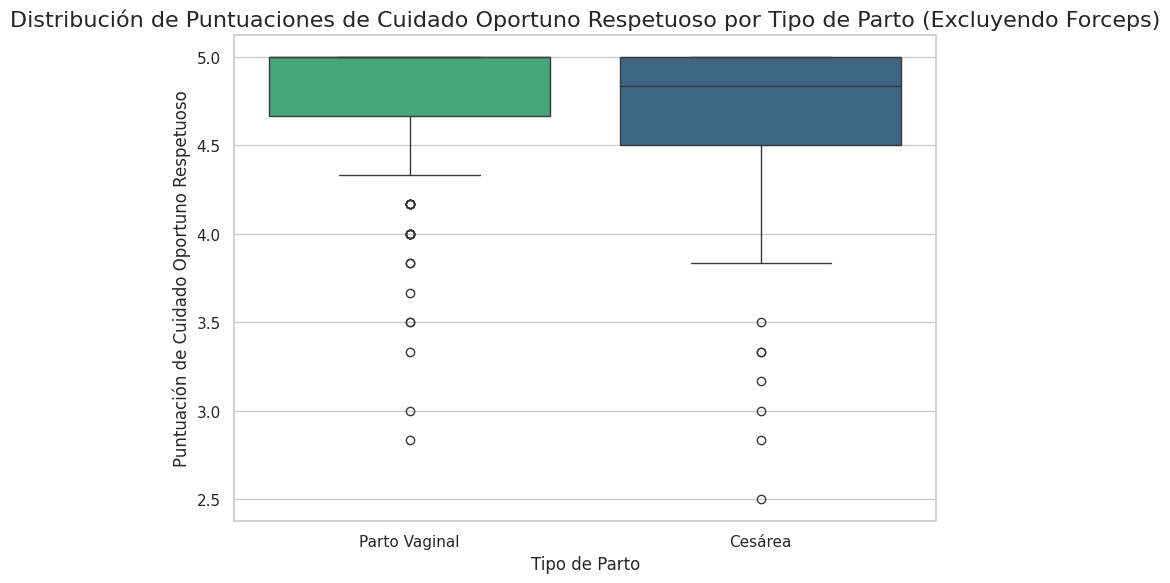

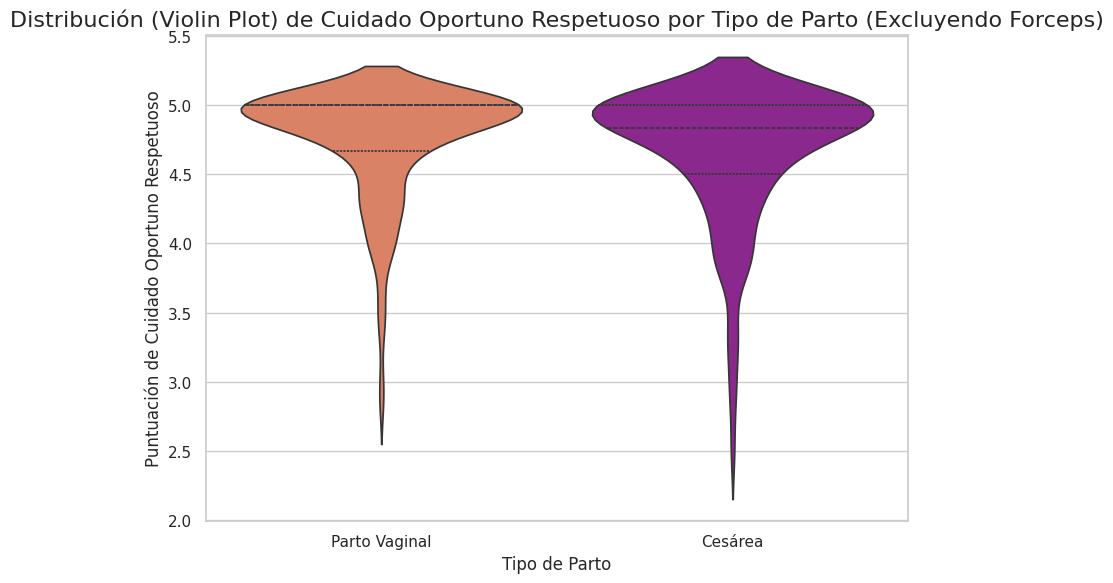

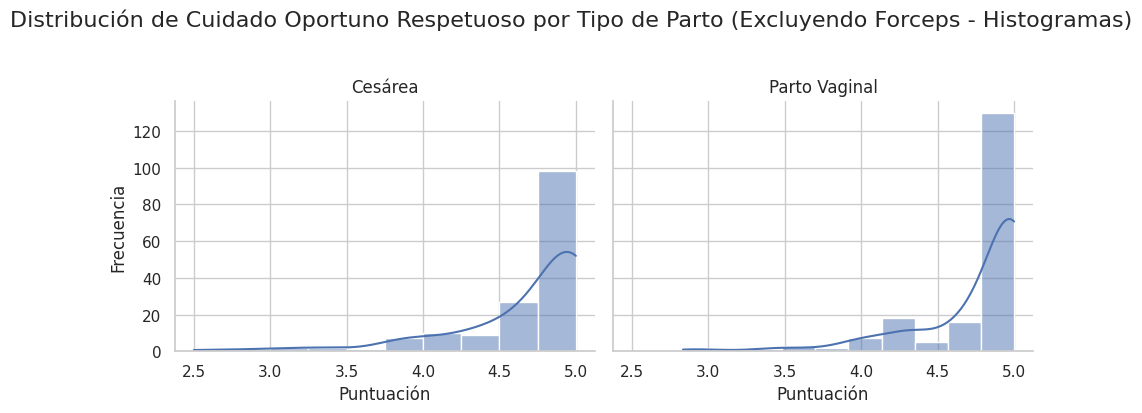

In [68]:
# 2. Visualización de la Distribución de 'Score_Cuidado_oportuno_respetuoso' por 'Tipo_parto_std' (filtrado)
print("\nVisualizando la Distribución de 'Cuidado Oportuno Respetuoso' por Tipo de Parto (excluyendo Forceps):")

# Boxplot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.boxplot(
        x='Tipo_parto_std',
        y='Score_Cuidado_oportuno_respetuoso',
        data=df_filtered_oportuno, palette='viridis',
        order=df_filtered_oportuno['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Cuidado Oportuno Respetuoso por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Cuidado Oportuno Respetuoso', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.violinplot(
        x='Tipo_parto_std',
        y='Score_Cuidado_oportuno_respetuoso',
        data=df_filtered_oportuno, palette='plasma',
        inner="quartile",
        order=df_filtered_oportuno['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Cuidado Oportuno Respetuoso por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Cuidado Oportuno Respetuoso', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df_filtered_oportuno, col="Tipo_parto_std", col_wrap=2, height=4, aspect=1.2) # col_wrap=2 para 2 grupos
g.map(sns.histplot, 'Score_Cuidado_oportuno_respetuoso', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Oportuno Respetuoso por Tipo de Parto (Excluyendo Forceps - Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [69]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---")

# b) Normalidad dentro de cada grupo (filtrado)
print("\nPrueba de Normalidad de 'Cuidado Oportuno Respetuoso' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):")
parto_groups_oportuno_filtered = df_filtered_oportuno.groupby('Tipo_parto_std')['Score_Cuidado_oportuno_respetuoso']

normalidad_results_oportuno_filtered = {}
for name, group in parto_groups_oportuno_filtered:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_oportuno_filtered[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_oportuno_filtered[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_oportuno_filtered = pd.DataFrame(normalidad_results_oportuno_filtered).T
display(normalidad_df_oportuno_filtered.style
    .set_caption("Normalidad de 'Cuidado Oportuno Respetuoso' por Grupo (Shapiro-Wilk, Excluyendo Forceps)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")

# c) Homogeneidad de Varianzas (Levene's Test) (filtrado)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):")

group_data_oportuno_filtered = [group.dropna().values for name, group in parto_groups_oportuno_filtered]

if all(len(g) > 0 for g in group_data_oportuno_filtered) and len(group_data_oportuno_filtered) == 2: # Levene's requires exactly 2 groups for independent t-test
    stat_levene_oportuno_filtered, p_value_levene_oportuno_filtered = stats.levene(*group_data_oportuno_filtered)
    print(f"Estadístico de Levene: {stat_levene_oportuno_filtered:.4f}")
    print(f"Valor p: {p_value_levene_oportuno_filtered:.4f}")

    if p_value_levene_oportuno_filtered < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
        print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---

Prueba de Normalidad de 'Cuidado Oportuno Respetuoso' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):


,Shapiro-Wilk p-value,N
Cesárea,0.0000,158
Parto Vaginal,0.0000,184



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):
Estadístico de Levene: 2.2179
Valor p: 0.1373
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa T-test, se puede asumir igualdad de varianzas.


In [70]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial (filtrado)
print("\n--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos (filtrados)
group1_data_oportuno = df_filtered_oportuno[df_filtered_oportuno['Tipo_parto_std'] == 'Cesárea']['Score_Cuidado_oportuno_respetuoso'].dropna()
group2_data_oportuno = df_filtered_oportuno[df_filtered_oportuno['Tipo_parto_std'] == 'Parto Vaginal']['Score_Cuidado_oportuno_respetuoso'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_oportuno) > 0 and len(group2_data_oportuno) > 0:
    stat_mw_cuidado_oportuno, p_value_mw_cuidado_oportuno = stats.mannwhitneyu(group1_data_oportuno, group2_data_oportuno, alternative='two-sided') # two-sided para diferencia en cualquier dirección
    print(f"Estadístico de Mann-Whitney U: {stat_mw_cuidado_oportuno:.4f}")
    print(f"Valor p: {p_value_mw_cuidado_oportuno:.4f}")
    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_cuidado_oportuno < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado Oportuno Respetuoso' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Oportuno Respetuoso' entre estos dos tipos de parto.")
        print(f"La mediana para Cesárea es {group1_data_oportuno.median():.2f} y para Parto Vaginal es {group2_data_oportuno.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Oportuno Respetuoso' entre 'Cesárea' y 'Parto Vaginal'.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('Cesárea', 'Parto Vaginal') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_oportuno) > 1 and len(group2_data_oportuno) > 1: # T-test requires at least 2 data points per group
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_oportuno = True # Default to True, but check Levene's result
    if 'p_value_levene_oportuno_filtered' in locals() and not np.isnan(p_value_levene_oportuno_filtered) and p_value_levene_oportuno_filtered < 0.05:
        use_equal_var_oportuno = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")
    stat_ttest_oportuno, p_value_ttest_oportuno = stats.ttest_ind(group1_data_oportuno, group2_data_oportuno, equal_var=use_equal_var_oportuno)
    print(f"Estadístico T: {stat_ttest_oportuno:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_oportuno:.4f}")
    # Interpretación del resultado del T-test
    if p_value_ttest_oportuno < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Cuidado Oportuno Respetuoso' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Oportuno Respetuoso' entre estos dos tipos de parto.")
        print(f"La media para Cesárea es {group1_data_oportuno.mean():.2f} y para Parto Vaginal es {group2_data_oportuno.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Oportuno Respetuoso' entre 'Cesárea' y 'Parto Vaginal'.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 12966.5000
Valor p: 0.0648

Conclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Oportuno Respetuoso' entre 'Cesárea' y 'Parto Vaginal'.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico T: -1.7105
Valor p (T-test): 0.0881

Conclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe un

In [71]:
# 5. Conclusiones y Recomendaciones (filtrado)
print("\n--- Conclusiones del Análisis 'Cuidado_oportuno_respetuoso' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Cuidado Oportuno Respetuoso' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_cuidado_oportuno' in locals() and not np.isnan(p_value_mw_cuidado_oportuno):
    if p_value_mw_cuidado_oportuno < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_oportuno:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Cuidado Oportuno Respetuoso' entre 'Cesárea' y 'Parto Vaginal'.")
        print(f"  Esto sugiere que la percepción de 'Cuidado Oportuno Respetuoso' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
        print(f"  Mediana Cesárea: {group1_data_oportuno.median():.2f}, Mediana Parto Vaginal: {group2_data_oportuno.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_oportuno:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado Oportuno Respetuoso' entre cesárea y parto vaginal basado en esta prueba no paramétrica.")
elif 'p_value_ttest_oportuno' in locals() and not np.isnan(p_value_ttest_oportuno):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_oportuno < 0.05:
         print(f"- La prueba T ({p_value_ttest_oportuno:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Cuidado Oportuno Respetuoso' entre 'Cesárea' y 'Parto Vaginal'.")
         print(f"  Esto sugiere que la percepción de 'Cuidado Oportuno Respetuoso' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
         print(f"  Media Cesárea: {group1_data_oportuno.mean():.2f}, Media Parto Vaginal: {group2_data_oportuno.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_oportuno:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado Oportuno Respetuoso' entre cesárea y parto vaginal basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\n--- Prueba Post-Hoc y Tamaño del Efecto para la Dimensión 'Cuidado_oportuno_respetuoso' según Tipo de Parto (excluye Forceps) ---")

df_filtered_oportuno_mw = df[df['Tipo_parto_std'].isin(['Cesárea', 'Parto Vaginal'])].copy()

if len(df_filtered_oportuno_mw['Tipo_parto_std'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    mw_effect_size_oportuno = pg.mwu(
        x=df_filtered_oportuno_mw[df_filtered_oportuno_mw['Tipo_parto_std'] == 'Cesárea']['Score_Cuidado_oportuno_respetuoso'].dropna(),
        y=df_filtered_oportuno_mw[df_filtered_oportuno_mw['Tipo_parto_std'] == 'Parto Vaginal']['Score_Cuidado_oportuno_respetuoso'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_oportuno.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Fix: Handle naming changes in Pingouin versions (p-val vs p_val)
    p_col = 'p-val' if 'p-val' in mw_effect_size_oportuno.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_oportuno.columns else 'U_val'

    effect_size_value_oportuno = mw_effect_size_oportuno['RBC'].iloc[0]
    p_value_oportuno = mw_effect_size_oportuno[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_oportuno[u_col].iloc[0]:.4f}")
    print(f"Valor p: {p_value_oportuno:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_oportuno:.4f}")

    abs_effect_size_oportuno = abs(effect_size_value_oportuno)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_oportuno >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_oportuno:.2f}) es grande.")
    elif abs_effect_size_oportuno >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_oportuno:.2f}) es mediano.")
    elif abs_effect_size_oportuno >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_oportuno:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_oportuno:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_oportuno < 0.05:
         print(f"- La diferencia en las medianas es significativa (p={p_value_oportuno:.4f}).")
         effect_size_interpretation_oportuno = 'muy pequeña' if abs_effect_size_oportuno < 0.10 else ('pequeña' if abs_effect_size_oportuno < 0.30 else ('mediana' if abs_effect_size_oportuno < 0.50 else 'grande'))
         print(f"- El tamaño del efecto sugiere que esta diferencia es de magnitud {effect_size_interpretation_oportuno}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_oportuno:.4f}) no encontró una diferencia significativa.")

else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")

print("\n--- Fin del Análisis Específico de 'Cuidado_oportuno_respetuoso' (excluye Forceps) ---")


--- Conclusiones del Análisis 'Cuidado_oportuno_respetuoso' por Tipo de Parto (Excluye Forceps) ---
- Se realizó el análisis comparando las puntuaciones de 'Cuidado Oportuno Respetuoso' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0648) no encontró una diferencia estadísticamente significativa en las medianas.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado Oportuno Respetuoso' entre cesárea y parto vaginal basado en esta prueba no paramétrica.

--- Prueba Post-Hoc y Tamaño del Efecto para la Dimensión 'Cuidado_oportuno_respetuoso' según Tipo de Parto (excluye Forceps) ---

Calculando el Ta

,U_val,alternative,p_val,RBC,CLES
MWU,12966.500000,two-sided,0.064849,-0.107973,0.446013



Estadístico de Mann-Whitney U: 12966.5000
Valor p: 0.0648
Tamaño del Efecto (Rank-Biserial r): -0.1080

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.11) es pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La prueba de Mann-Whitney U (0.0648) no encontró una diferencia significativa.

--- Fin del Análisis Específico de 'Cuidado_oportuno_respetuoso' (excluye Forceps) ---


In [72]:
# 6. Conclusiones y Recomendaciones Generales para Cuidado_oportuno_respetuoso

print("\n--- Conclusiones Generales del Análisis 'Cuidado_oportuno_respetuoso' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó un análisis exhaustivo de la percepción de 'Cuidado Oportuno Respetuoso' según el tipo de parto, excluyendo los casos de Forceps.")
print("- Se examinaron las estadísticas descriptivas y las distribuciones visualmente para entender las diferencias entre los grupos 'Cesárea' y 'Parto Vaginal'.")
print("- Se evaluaron los supuestos de normalidad y homogeneidad de varianzas para guiar la selección de la prueba inferencial.")

# Based on the previous analysis, re-state the main finding for Cuidado_oportuno_respetuoso
if 'p_value_mw_cuidado_oportuno' in locals() and not np.isnan(p_value_mw_cuidado_oportuno):
    if p_value_mw_cuidado_oportuno < 0.05:
        print(f"\nPrincipal Hallazgo (Prueba Mann-Whitney U, p={p_value_mw_cuidado_oportuno:.4f}):")
        print("  Existe una diferencia estadísticamente significativa en la percepción de 'Cuidado Oportuno Respetuoso' entre mujeres con parto por cesárea y parto vaginal.")
        if 'effect_size_value_oportuno' in locals() and not np.isnan(effect_size_value_oportuno):
            effect_size_interpretation_oportuno = 'muy pequeña' if abs(effect_size_value_oportuno) < 0.10 else ('pequeña' if abs(effect_size_value_oportuno) < 0.30 else ('mediana' if abs(effect_size_value_oportuno) < 0.50 else 'grande'))
            print(f"  El tamaño del efecto Rank-Biserial r ({abs(effect_size_value_oportuno):.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_oportuno}.")
            # Add conclusion about which group had a higher score
            if group1_data_oportuno.median() > group2_data_oportuno.median():
                print(f"  Las mujeres con Cesárea reportaron, en promedio/mediana ({group1_data_oportuno.median():.2f}), una mayor percepción de 'Cuidado Oportuno Respetuoso' que aquellas con Parto Vaginal ({group2_data_oportuno.median():.2f}).")
            else:
                 print(f"  Las mujeres con Parto Vaginal reportaron, en promedio/mediana ({group2_data_oportuno.median():.2f}), una mayor percepción de 'Cuidado Oportuno Respetuoso' que aquellas con Cesárea ({group1_data_oportuno.median():.2f}).")
    else:
        print(f"\nPrincipal Hallazgo (Prueba Mann-Whitney U, p={p_value_mw_cuidado_oportuno:.4f}):")
        print("  No se encontró una diferencia estadísticamente significativa en la percepción de 'Cuidado Oportuno Respetuoso' entre mujeres con parto por cesárea y parto vaginal.")
elif 'p_value_ttest_oportuno' in locals() and not np.isnan(p_value_ttest_oportuno):
    if p_value_ttest_oportuno < 0.05:
        print(f"\nPrincipal Hallazgo (Prueba T, p={p_value_ttest_oportuno:.4f}):")
        print("  Existe una diferencia estadísticamente significativa en la percepción de 'Cuidado Oportuno Respetuoso' entre mujeres con parto por cesárea y parto vaginal.")
        # Add conclusion about which group had a higher score
        if group1_data_oportuno.mean() > group2_data_oportuno.mean():
            print(f"  Las mujeres con Cesárea reportaron, en promedio ({group1_data_oportuno.mean():.2f}), una mayor percepción de 'Cuidado Oportuno Respetuoso' que aquellas con Parto Vaginal ({group2_data_oportuno.mean():.2f}).")
        else:
             print(f"  Las mujeres con Parto Vaginal reportaron, en promedio ({group2_data_oportuno.mean():.2f}), una mayor percepción de 'Cuidado Oportuno Respetuoso' que aquellas con Cesárea ({group1_data_oportuno.mean():.2f}).")
    else:
        print(f"\nPrincipal Hallazgo (Prueba T, p={p_value_ttest_oportuno:.4f}):")
        print("  No se encontró una diferencia estadísticamente significativa en la percepción de 'Cuidado Oportuno Respetuoso' entre mujeres con parto por cesárea y parto vaginal.")
else:
    print("\nNo se pudo determinar el hallazgo principal ya que no se realizó la prueba inferencial.")

print("\nRecomendaciones Adicionales para 'Cuidado Oportuno Respetuoso':")
print("- Si se encontró una diferencia significativa, investigar los factores específicos del proceso de parto que podrían contribuir a estas diferencias en la percepción.")
print("- Realizar análisis más detallados, como la exploración de subgrupos o la inclusión de covariables, para comprender mejor esta relación.")
print("- Considerar la importancia clínica o práctica de la magnitud de la diferencia encontrada, incluso si es estadísticamente significativa.")
print("- Utilizar estos hallazgos para identificar áreas de mejora en la atención materna y ajustar los protocolos o la comunicación con las pacientes según el tipo de parto.")

print("\n--- Fin del Análisis Completo de 'Cuidado_oportuno_respetuoso' (Excluye Forceps) ---")


--- Conclusiones Generales del Análisis 'Cuidado_oportuno_respetuoso' por Tipo de Parto (Excluye Forceps) ---
- Se realizó un análisis exhaustivo de la percepción de 'Cuidado Oportuno Respetuoso' según el tipo de parto, excluyendo los casos de Forceps.
- Se examinaron las estadísticas descriptivas y las distribuciones visualmente para entender las diferencias entre los grupos 'Cesárea' y 'Parto Vaginal'.
- Se evaluaron los supuestos de normalidad y homogeneidad de varianzas para guiar la selección de la prueba inferencial.

Principal Hallazgo (Prueba Mann-Whitney U, p=0.0648):
  No se encontró una diferencia estadísticamente significativa en la percepción de 'Cuidado Oportuno Respetuoso' entre mujeres con parto por cesárea y parto vaginal.

Recomendaciones Adicionales para 'Cuidado Oportuno Respetuoso':
- Si se encontró una diferencia significativa, investigar los factores específicos del proceso de parto que podrían contribuir a estas diferencias en la percepción.
- Realizar análisis

### 6.1.6 Análisis por Dimensión (Ambiente_fisico_confortable) según Tipo de Parto (excluye Forceps) ✅

In [73]:
# prompt: necesito todos los analisis del punto 6.3.2 pero aplicados a la dimensión Ambiente_fisico_comnfortable, no consideres los casos con forceps

print("\n--- Análisis Específico: Puntuación de 'Ambiente_fisico_confortable' según Tipo de Parto (excluye forceps) ---")

# Filtrar el DataFrame para excluir la categoría 'Forceps'
df_filtered_ambiente = df[df['Tipo_parto_std'] != 'Forceps'].copy()

# Verificar los tipos de parto restantes en el DataFrame filtrado
print("\nTipos de Parto incluidos en el análisis (excluyendo Forceps):")
print(df_filtered_ambiente['Tipo_parto_std'].value_counts())


--- Análisis Específico: Puntuación de 'Ambiente_fisico_confortable' según Tipo de Parto (excluye forceps) ---

Tipos de Parto incluidos en el análisis (excluyendo Forceps):
Tipo_parto_std
Parto Vaginal    184
Cesárea          158
Name: count, dtype: int64


In [74]:
# 1. Estadísticas Descriptivas Específicas para 'Score_Ambiente_fisico_confortable' por 'Tipo_parto_std' (filtrado)
print("\nEstadísticas Descriptivas para 'Ambiente_fisico_confortable' por Tipo de Parto (excluyendo Forceps):")
parto_ambiente_stats_filtered = df_filtered_ambiente.groupby('Tipo_parto_std')['Score_Ambiente_fisico_confortable'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(parto_ambiente_stats_filtered.style
        .set_caption("Estadísticas Descriptivas de 'Ambiente Físico Confortable' por Tipo de Parto (Excluyendo Forceps)")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


Estadísticas Descriptivas para 'Ambiente_fisico_confortable' por Tipo de Parto (excluyendo Forceps):


Tipo_parto_std,Cesárea,Parto Vaginal
count,158.00,184.00
mean,4.76,4.83
median,5.00,5.00
std,0.39,0.32
min,2.80,3.40
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Ambiente Físico Confortable' por Tipo de Parto (excluyendo Forceps):


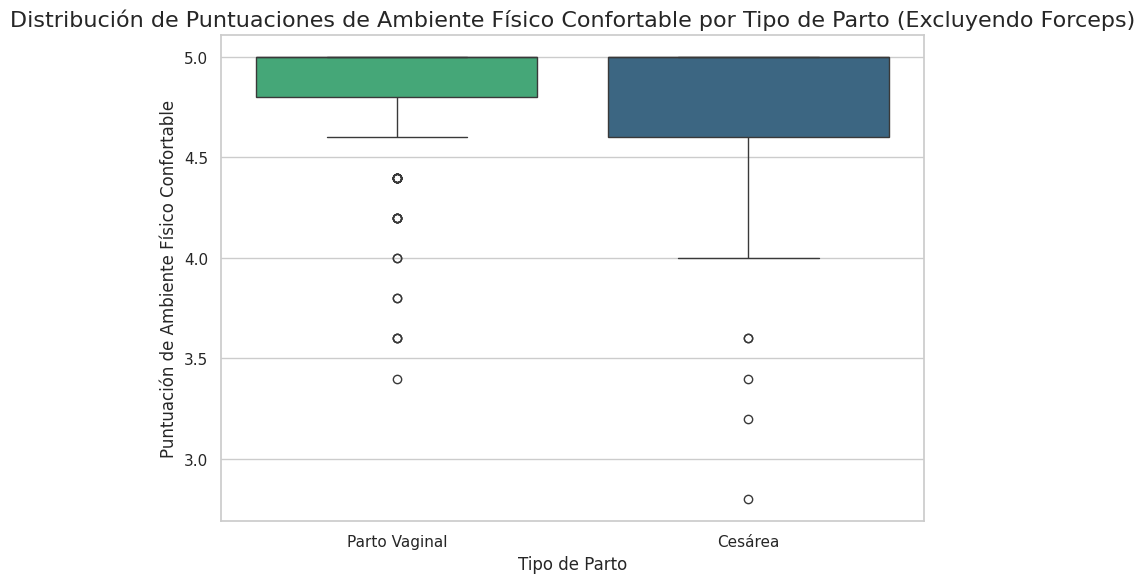

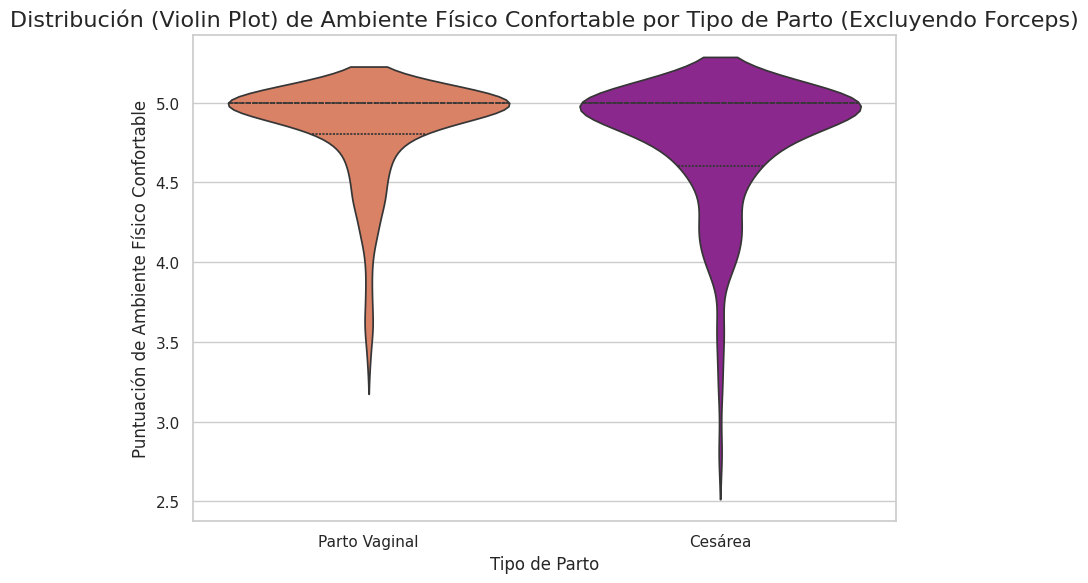

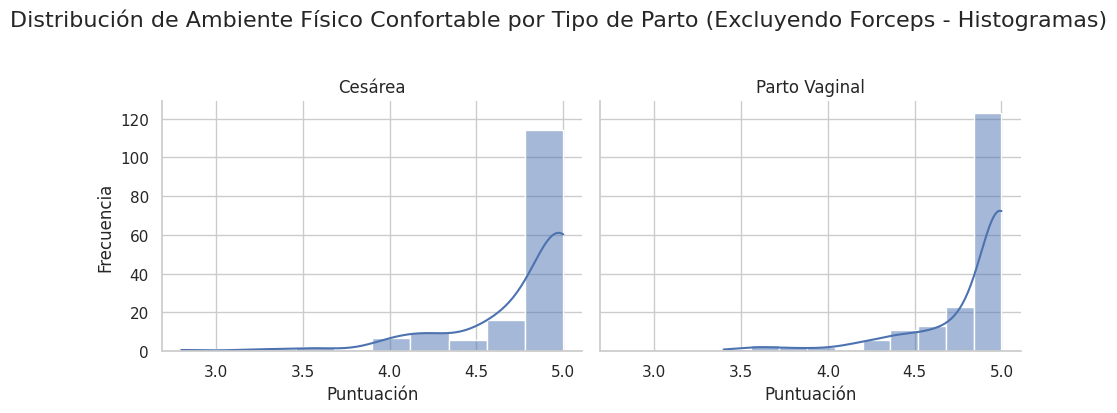

In [75]:
# 2. Visualización de la Distribución de 'Score_Ambiente_fisico_confortable' por 'Tipo_parto_std' (filtrado)

print("\nVisualizando la Distribución de 'Ambiente Físico Confortable' por Tipo de Parto (excluyendo Forceps):")

# Boxplot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.boxplot(
        x='Tipo_parto_std',
        y='Score_Ambiente_fisico_confortable',
        data=df_filtered_ambiente, palette='viridis',
        order=df_filtered_ambiente['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Ambiente Físico Confortable por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Ambiente Físico Confortable', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.violinplot(
        x='Tipo_parto_std',
        y='Score_Ambiente_fisico_confortable',
        data=df_filtered_ambiente, palette='plasma',
        inner="quartile",
        order=df_filtered_ambiente['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Ambiente Físico Confortable por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Ambiente Físico Confortable', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df_filtered_ambiente, col="Tipo_parto_std", col_wrap=2, height=4, aspect=1.2) # col_wrap=2 para 2 grupos
g.map(sns.histplot, 'Score_Ambiente_fisico_confortable', kde=True, bins=10)
g.fig.suptitle('Distribución de Ambiente Físico Confortable por Tipo de Parto (Excluyendo Forceps - Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [76]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)

# Para comparar 2 grupos independientes ('Cesárea' vs 'Parto Vaginal'),
# las pruebas comunes son T-test independiente (paramétrica) o Mann-Whitney U (no paramétrica).

# Supuestos para T-test independiente:
# a) Independencia de las observaciones (asumido).
# b) Normalidad de la variable dependiente dentro de cada grupo.
# c) Homogeneidad de varianzas (Levene's test).

print("\n--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---")

# b) Normalidad dentro de cada grupo (filtrado)
print("\nPrueba de Normalidad de 'Ambiente Físico Confortable' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):")
parto_groups_ambiente_filtered = df_filtered_ambiente.groupby('Tipo_parto_std')['Score_Ambiente_fisico_confortable']

normalidad_results_ambiente_filtered = {}
for name, group in parto_groups_ambiente_filtered:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_ambiente_filtered[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_ambiente_filtered[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_ambiente_filtered = pd.DataFrame(normalidad_results_ambiente_filtered).T
display(normalidad_df_ambiente_filtered.style
    .set_caption("Normalidad de 'Ambiente Físico Confortable' por Grupo (Shapiro-Wilk, Excluyendo Forceps)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")


# c) Homogeneidad de Varianzas (Levene's Test) (filtrado)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):")

group_data_ambiente_filtered = [group.dropna().values for name, group in parto_groups_ambiente_filtered]

if all(len(g) > 0 for g in group_data_ambiente_filtered) and len(group_data_ambiente_filtered) == 2: # Levene's requires exactly 2 groups for independent t-test
    stat_levene_ambiente_filtered, p_value_levene_ambiente_filtered = stats.levene(*group_data_ambiente_filtered)
    print(f"Estadístico de Levene: {stat_levene_ambiente_filtered:.4f}")
    print(f"Valor p: {p_value_levene_ambiente_filtered:.4f}")

    if p_value_levene_ambiente_filtered < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
        print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---

Prueba de Normalidad de 'Ambiente Físico Confortable' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):


,Shapiro-Wilk p-value,N
Cesárea,0.0000,158
Parto Vaginal,0.0000,184



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):
Estadístico de Levene: 3.6417
Valor p: 0.0572
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa T-test, se puede asumir igualdad de varianzas.


In [77]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial (filtrado)

print("\n--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---")

# Decisión: Similar a los análisis anteriores, Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos (filtrados)
group1_data_ambiente = df_filtered_ambiente[df_filtered_ambiente['Tipo_parto_std'] == 'Cesárea']['Score_Ambiente_fisico_confortable'].dropna()
group2_data_ambiente = df_filtered_ambiente[df_filtered_ambiente['Tipo_parto_std'] == 'Parto Vaginal']['Score_Ambiente_fisico_confortable'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_ambiente) > 0 and len(group2_data_ambiente) > 0:
    stat_mw_ambiente, p_value_mw_ambiente = stats.mannwhitneyu(group1_data_ambiente, group2_data_ambiente, alternative='two-sided') # two-sided para diferencia en cualquier dirección
    print(f"Estadístico de Mann-Whitney U: {stat_mw_ambiente:.4f}")
    print(f"Valor p: {p_value_mw_ambiente:.4f}")
    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_ambiente < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Ambiente Físico Confortable' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente Físico Confortable' entre estos dos tipos de parto.")
        print(f"La mediana para Cesárea es {group1_data_ambiente.median():.2f} y para Parto Vaginal es {group2_data_ambiente.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente Físico Confortable' entre 'Cesárea' y 'Parto Vaginal'.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('Cesárea', 'Parto Vaginal') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_ambiente) > 1 and len(group2_data_ambiente) > 1: # T-test requires at least 2 data points per group
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_ambiente = True # Default to True, but check Levene's result
    if 'p_value_levene_ambiente_filtered' in locals() and not np.isnan(p_value_levene_ambiente_filtered) and p_value_levene_ambiente_filtered < 0.05:
        use_equal_var_ambiente = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")
    stat_ttest_ambiente, p_value_ttest_ambiente = stats.ttest_ind(group1_data_ambiente, group2_data_ambiente, equal_var=use_equal_var_ambiente)
    print(f"Estadístico T: {stat_ttest_ambiente:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_ambiente:.4f}")
    # Interpretación del resultado del T-test
    if p_value_ttest_ambiente < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Ambiente Físico Confortable' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente Físico Confortable' entre estos dos tipos de parto.")
        print(f"La media para Cesárea es {group1_data_ambiente.mean():.2f} y para Parto Vaginal es {group2_data_ambiente.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente Físico Confortable' entre 'Cesárea' y 'Parto Vaginal'.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 12852.5000
Valor p: 0.0344

Conclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medianas de 'Ambiente Físico Confortable' son iguales entre 'Cesárea' y 'Parto Vaginal'.
Existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente Físico Confortable' entre estos dos tipos de parto.
La mediana para Cesárea es 5.00 y para Parto Vaginal es 5.00.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico T: -1.9083
Valor p (T-test): 0.0572

Conclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).
No se 

In [78]:
# 5. Conclusiones y Recomendaciones (filtrado)
print("\n--- Conclusiones del Análisis 'Ambiente_fisico_confortable' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Ambiente Físico Confortable' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_ambiente' in locals() and not np.isnan(p_value_mw_ambiente):
    if p_value_mw_ambiente < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_ambiente:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Ambiente Físico Confortable' entre 'Cesárea' y 'Parto Vaginal'.")
        print(f"  Esto sugiere que la percepción de 'Ambiente Físico Confortable' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
        print(f"  Mediana Cesárea: {group1_data_ambiente.median():.2f}, Mediana Parto Vaginal: {group2_data_ambiente.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_ambiente:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Ambiente Físico Confortable' entre cesárea y parto vaginal basado en esta prueba no paramétrica.")
elif 'p_value_ttest_ambiente' in locals() and not np.isnan(p_value_ttest_ambiente):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_ambiente < 0.05:
         print(f"- La prueba T ({p_value_ttest_ambiente:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Ambiente Físico Confortable' entre 'Cesárea' y 'Parto Vaginal'.")
         print(f"  Esto sugiere que la percepción de 'Ambiente Físico Confortable' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
         print(f"  Media Cesárea: {group1_data_ambiente.mean():.2f}, Media Parto Vaginal: {group2_data_ambiente.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_ambiente:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Ambiente Físico Confortable' entre cesárea y parto vaginal basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\n--- Prueba Post-Hoc y Tamaño del Efecto para la Dimensión 'Ambiente_fisico_confortable' según Tipo de Parto (excluye Forceps) ---")

import pingouin as pg

# Filtrar el DataFrame para incluir solo 'Cesárea' y 'Parto Vaginal'
df_filtered_ambiente_mw = df[df['Tipo_parto_std'].isin(['Cesárea', 'Parto Vaginal'])].copy()

# Verificar si hay datos suficientes para ambos grupos
if len(df_filtered_ambiente_mw['Tipo_parto_std'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    # Usar pingouin para realizar el test de Mann-Whitney U y obtener el tamaño del efecto
    mw_effect_size_ambiente = pg.mwu(
        x=df_filtered_ambiente_mw[df_filtered_ambiente_mw['Tipo_parto_std'] == 'Cesárea']['Score_Ambiente_fisico_confortable'].dropna(),
        y=df_filtered_ambiente_mw[df_filtered_ambiente_mw['Tipo_parto_std'] == 'Parto Vaginal']['Score_Ambiente_fisico_confortable'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_ambiente.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Extraer el valor del tamaño del efecto y manejar nombres de columnas según versión de pingouin
    effect_size_value_ambiente = mw_effect_size_ambiente['RBC'].iloc[0]
    p_col = 'p-val' if 'p-val' in mw_effect_size_ambiente.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_ambiente.columns else 'U_val'
    p_value_ambiente = mw_effect_size_ambiente[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_ambiente[u_col].iloc[0]:.4f}")
    print(f"Valor p: {p_value_ambiente:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_ambiente:.4f}")

    abs_effect_size_ambiente = abs(effect_size_value_ambiente)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_ambiente >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_ambiente:.2f}) es grande.")
    elif abs_effect_size_ambiente >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_ambiente:.2f}) es mediano.")
    elif abs_effect_size_ambiente >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_ambiente:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_ambiente:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_ambiente < 0.05:
         print(f"- La diferencia en las medianas es estadísticamente significativa (p={p_value_ambiente:.4f}).")
         effect_size_interpretation_ambiente = 'muy pequeña' if abs_effect_size_ambiente < 0.10 else ('pequeña' if abs_effect_size_ambiente < 0.30 else ('mediana' if abs_effect_size_ambiente < 0.50 else 'grande'))
         print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_ambiente:.2f}) sugiere una magnitud {effect_size_interpretation_ambiente}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_ambiente:.4f}) no encontró una diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")

print("\n--- Fin del Análisis Específico de 'Ambiente_fisico_confortable' (excluye Forceps) ---")


--- Conclusiones del Análisis 'Ambiente_fisico_confortable' por Tipo de Parto (Excluye Forceps) ---
- Se realizó el análisis comparando las puntuaciones de 'Ambiente Físico Confortable' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0344) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Ambiente Físico Confortable' entre 'Cesárea' y 'Parto Vaginal'.
  Esto sugiere que la percepción de 'Ambiente Físico Confortable' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.
  Mediana Cesárea: 5.00, Mediana Parto Vaginal: 5.00.

--- Prueba Post-Hoc y Tamaño del Efecto pa

,U_val,alternative,p_val,RBC,CLES
MWU,12852.500000,two-sided,0.034355,-0.115816,0.442092



Estadístico de Mann-Whitney U: 12852.5000
Valor p: 0.0344
Tamaño del Efecto (Rank-Biserial r): -0.1158

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.12) es pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La diferencia en las medianas es estadísticamente significativa (p=0.0344).
- El tamaño del efecto Rank-Biserial r (0.12) sugiere una magnitud pequeña.

--- Fin del Análisis Específico de 'Ambiente_fisico_confortable' (excluye Forceps) ---


In [79]:
# 6. Conclusiones y Recomendaciones Generales para Ambiente_fisico_confortable

print("\n--- Conclusiones Generales del Análisis 'Ambiente_fisico_confortable' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó un análisis exhaustivo de la percepción de 'Ambiente Físico Confortable' según el tipo de parto, excluyendo los casos de Forceps.")
print("- Se examinaron las estadísticas descriptivas y las distribuciones visualmente para entender las diferencias entre los grupos 'Cesárea' y 'Parto Vaginal'.")
print("- Se evaluaron los supuestos de normalidad y homogeneidad de varianzas para guiar la selección de la prueba inferencial.")

# Based on the previous analysis, re-state the main finding for Ambiente_fisico_confortable
if 'p_value_mw_ambiente' in locals() and not np.isnan(p_value_mw_ambiente):
    if p_value_mw_ambiente < 0.05:
        print(f"\nPrincipal Hallazgo (Prueba Mann-Whitney U, p={p_value_mw_ambiente:.4f}):")
        print("  Existe una diferencia estadísticamente significativa en la percepción de 'Ambiente Físico Confortable' entre mujeres con parto por cesárea y parto vaginal.")
        if 'effect_size_value_ambiente' in locals() and not np.isnan(effect_size_value_ambiente):
            effect_size_interpretation_ambiente = 'muy pequeña' if abs(effect_size_value_ambiente) < 0.10 else ('pequeña' if abs(effect_size_value_ambiente) < 0.30 else ('mediana' if abs(effect_size_value_ambiente) < 0.50 else 'grande'))
            print(f"  El tamaño del efecto Rank-Biserial r ({abs(effect_size_value_ambiente):.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_ambiente}.")
            # Add conclusion about which group had a higher score
            if group1_data_ambiente.median() > group2_data_ambiente.median():
                print(f"  Las mujeres con Cesárea reportaron, en promedio/mediana ({group1_data_ambiente.median():.2f}), una mayor percepción de 'Ambiente Físico Confortable' que aquellas con Parto Vaginal ({group2_data_ambiente.median():.2f}).")
            else:
                 print(f"  Las mujeres con Parto Vaginal reportaron, en promedio/mediana ({group2_data_ambiente.median():.2f}), una mayor percepción de 'Ambiente Físico Confortable' que aquellas con Cesárea ({group1_data_ambiente.median():.2f}).")
    else:
        print(f"\nPrincipal Hallazgo (Prueba Mann-Whitney U, p={p_value_mw_ambiente:.4f}):")
        print("  No se encontró una diferencia estadísticamente significativa en la percepción de 'Ambiente Físico Confortable' entre mujeres con parto por cesárea y parto vaginal.")
elif 'p_value_ttest_ambiente' in locals() and not np.isnan(p_value_ttest_ambiente):
    if p_value_ttest_ambiente < 0.05:
        print(f"\nPrincipal Hallazgo (Prueba T, p={p_value_ttest_ambiente:.4f}):")
        print("  Existe una diferencia estadísticamente significativa en la percepción de 'Ambiente Físico Confortable' entre mujeres con parto por cesárea y parto vaginal.")
        # Add conclusion about which group had a higher score
        if group1_data_ambiente.mean() > group2_data_ambiente.mean():
            print(f"  Las mujeres con Cesárea reportaron, en promedio ({group1_data_ambiente.mean():.2f}), una mayor percepción de 'Ambiente Físico Confortable' que aquellas con Parto Vaginal ({group2_data_ambiente.mean():.2f}).")
        else:
             print(f"  Las mujeres con Parto Vaginal reportaron, en promedio ({group2_data_ambiente.mean():.2f}), una mayor percepción de 'Ambiente Físico Confortable' que aquellas con Cesárea ({group1_data_ambiente.mean():.2f}).")
    else:
        print(f"\nPrincipal Hallazgo (Prueba T, p={p_value_ttest_ambiente:.4f}):")
        print("  No se encontró una diferencia estadísticamente significativa en la percepción de 'Ambiente Físico Confortable' entre mujeres con parto por cesárea y parto vaginal.")
else:
    print("\nNo se pudo determinar el hallazgo principal ya que no se realizó la prueba inferencial.")

print("\nRecomendaciones Adicionales para 'Ambiente Físico Confortable':")
print("- Si se encontró una diferencia significativa, investigar los aspectos específicos del ambiente físico (ej. iluminación, temperatura, ruido) que podrían diferir según el tipo de parto y contribuir a estas percepciones.")
print("- Evaluar si las instalaciones físicas asociadas a la cesárea versus el parto vaginal difieren de manera sistemática en aspectos de confort.")
print("- Realizar análisis más detallados, como la exploración de subgrupos o la inclusión de covariables.")
print("- Utilizar estos hallazgos para identificar áreas de mejora en las instalaciones y el ambiente de atención materna para optimizar el confort percibido por las pacientes.")

print("\n--- Fin del Análisis Completo de 'Ambiente_fisico_confortable' (Excluye Forceps) ---")


--- Conclusiones Generales del Análisis 'Ambiente_fisico_confortable' por Tipo de Parto (Excluye Forceps) ---
- Se realizó un análisis exhaustivo de la percepción de 'Ambiente Físico Confortable' según el tipo de parto, excluyendo los casos de Forceps.
- Se examinaron las estadísticas descriptivas y las distribuciones visualmente para entender las diferencias entre los grupos 'Cesárea' y 'Parto Vaginal'.
- Se evaluaron los supuestos de normalidad y homogeneidad de varianzas para guiar la selección de la prueba inferencial.

Principal Hallazgo (Prueba Mann-Whitney U, p=0.0344):
  Existe una diferencia estadísticamente significativa en la percepción de 'Ambiente Físico Confortable' entre mujeres con parto por cesárea y parto vaginal.
  El tamaño del efecto Rank-Biserial r (0.12) sugiere una magnitud de la diferencia pequeña.
  Las mujeres con Parto Vaginal reportaron, en promedio/mediana (5.00), una mayor percepción de 'Ambiente Físico Confortable' que aquellas con Cesárea (5.00).

Reco

### 6.1.7 Análisis por Dimensión (Condiciones_contacto_madre_hijo) según Tipo de Parto (excluye Forceps)  ✅

In [80]:
# prompt: necesito todos los analisis del punto 6.3.2 pero aplicados a la dimensión Condiciones_contacto_madre_hijo, no consideres los casos con forceps

print("\n--- Análisis Específico: Puntuación de 'Condiciones_contacto_madre_hijo' según Tipo de Parto (excluye forceps) ---")

# Filtrar el DataFrame para excluir la categoría 'Forceps'
df_filtered_contacto = df[df['Tipo_parto_std'] != 'Forceps'].copy()

# Verificar los tipos de parto restantes en el DataFrame filtrado
print("\nTipos de Parto incluidos en el análisis (excluyendo Forceps):")
print(df_filtered_contacto['Tipo_parto_std'].value_counts())


--- Análisis Específico: Puntuación de 'Condiciones_contacto_madre_hijo' según Tipo de Parto (excluye forceps) ---

Tipos de Parto incluidos en el análisis (excluyendo Forceps):
Tipo_parto_std
Parto Vaginal    184
Cesárea          158
Name: count, dtype: int64


In [81]:
# 1. Estadísticas Descriptivas Específicas para 'Score_Condiciones_contacto_madre_hijo' por 'Tipo_parto_std' (filtrado)
print("\nEstadísticas Descriptivas para 'Condiciones_contacto_madre_hijo' por Tipo de Parto (excluyendo Forceps):")
parto_contacto_stats_filtered = df_filtered_contacto.groupby('Tipo_parto_std')['Score_Condiciones_contacto_madre_hijo'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(parto_contacto_stats_filtered.style
        .set_caption("Estadísticas Descriptivas de 'Condiciones contacto madre hijo' por Tipo de Parto (Excluyendo Forceps)")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


Estadísticas Descriptivas para 'Condiciones_contacto_madre_hijo' por Tipo de Parto (excluyendo Forceps):


Tipo_parto_std,Cesárea,Parto Vaginal
count,158.00,184.00
mean,4.37,4.85
median,4.75,5.00
std,0.88,0.41
min,1.00,1.75
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Condiciones contacto madre hijo' por Tipo de Parto (excluyendo Forceps):


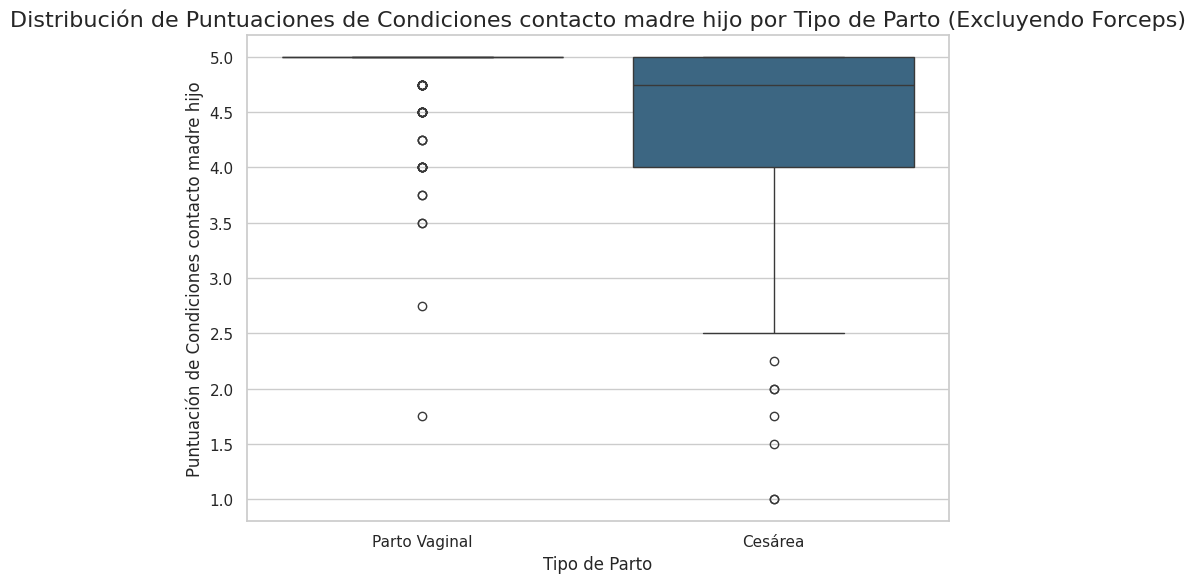

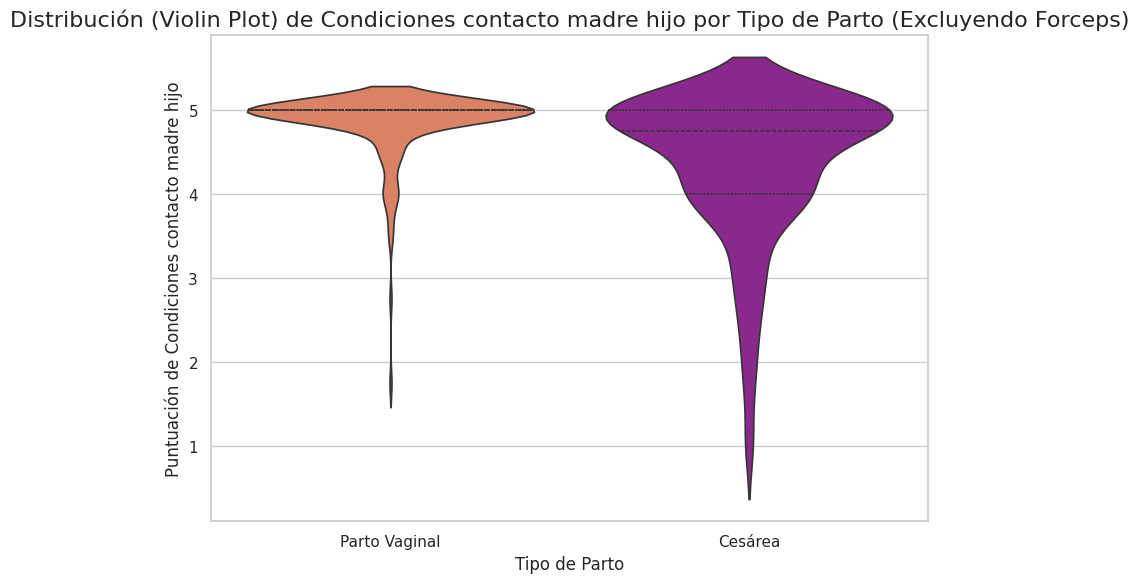

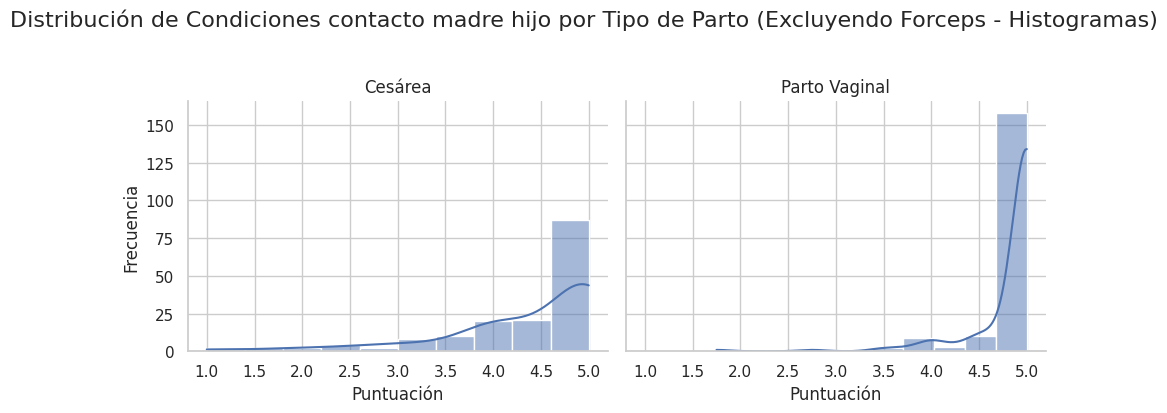

In [82]:
# 2. Visualización de la Distribución de 'Score_Condiciones_contacto_madre_hijo' por 'Tipo_parto_std' (filtrado)
print("\nVisualizando la Distribución de 'Condiciones contacto madre hijo' por Tipo de Parto (excluyendo Forceps):")

# Boxplot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.boxplot(
        x='Tipo_parto_std',
        y='Score_Condiciones_contacto_madre_hijo',
        data=df_filtered_contacto, palette='viridis',
        order=df_filtered_contacto['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Condiciones contacto madre hijo por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Condiciones contacto madre hijo', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.violinplot(
        x='Tipo_parto_std',
        y='Score_Condiciones_contacto_madre_hijo',
        data=df_filtered_contacto, palette='plasma',
        inner="quartile",
        order=df_filtered_contacto['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Condiciones contacto madre hijo por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Condiciones contacto madre hijo', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df_filtered_contacto, col="Tipo_parto_std", col_wrap=2, height=4, aspect=1.2) # col_wrap=2 para 2 grupos
g.map(sns.histplot, 'Score_Condiciones_contacto_madre_hijo', kde=True, bins=10)
g.fig.suptitle('Distribución de Condiciones contacto madre hijo por Tipo de Parto (Excluyendo Forceps - Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [83]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---")

# b) Normalidad dentro de cada grupo (filtrado)
print("\nPrueba de Normalidad de 'Condiciones contacto madre hijo' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):")
parto_groups_contacto_filtered = df_filtered_contacto.groupby('Tipo_parto_std')['Score_Condiciones_contacto_madre_hijo']

normalidad_results_contacto_filtered = {}
for name, group in parto_groups_contacto_filtered:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_contacto_filtered[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_contacto_filtered[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_contacto_filtered = pd.DataFrame(normalidad_results_contacto_filtered).T
display(normalidad_df_contacto_filtered.style
    .set_caption("Normalidad de 'Condiciones contacto madre hijo' por Grupo (Shapiro-Wilk, Excluyendo Forceps)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")

# c) Homogeneidad de Varianzas (Levene's Test) (filtrado)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):")

group_data_contacto_filtered = [group.dropna().values for name, group in parto_groups_contacto_filtered]

if all(len(g) > 0 for g in group_data_contacto_filtered) and len(group_data_contacto_filtered) == 2: # Levene's requires exactly 2 groups for independent t-test
    stat_levene_contacto_filtered, p_value_levene_contacto_filtered = stats.levene(*group_data_contacto_filtered)
    print(f"Estadístico de Levene: {stat_levene_contacto_filtered:.4f}")
    print(f"Valor p: {p_value_levene_contacto_filtered:.4f}")

    if p_value_levene_contacto_filtered < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
        print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---

Prueba de Normalidad de 'Condiciones contacto madre hijo' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):


,Shapiro-Wilk p-value,N
Cesárea,0.0000,158
Parto Vaginal,0.0000,184



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):
Estadístico de Levene: 54.0382
Valor p: 0.0000
Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.
Si se usa T-test, se debería aplicar la corrección de Welch.


In [84]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial (filtrado)
print("\n--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos (filtrados)
group1_data_contacto = df_filtered_contacto[df_filtered_contacto['Tipo_parto_std'] == 'Cesárea']['Score_Condiciones_contacto_madre_hijo'].dropna()
group2_data_contacto = df_filtered_contacto[df_filtered_contacto['Tipo_parto_std'] == 'Parto Vaginal']['Score_Condiciones_contacto_madre_hijo'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_contacto) > 0 and len(group2_data_contacto) > 0:
    stat_mw_contacto, p_value_mw_contacto = stats.mannwhitneyu(group1_data_contacto, group2_data_contacto, alternative='two-sided') # two-sided para diferencia en cualquier dirección
    print(f"Estadístico de Mann-Whitney U: {stat_mw_contacto:.4f}")
    print(f"Valor p: {p_value_mw_contacto:.4f}")
    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_contacto < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Condiciones contacto madre hijo' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones contacto madre hijo' entre estos dos tipos de parto.")
        print(f"La mediana para Cesárea es {group1_data_contacto.median():.2f} y para Parto Vaginal es {group2_data_contacto.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones contacto madre hijo' entre 'Cesárea' y 'Parto Vaginal'.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('Cesárea', 'Parto Vaginal') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_contacto) > 1 and len(group2_data_contacto) > 1: # T-test requires at least 2 data points per group
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_contacto = True # Default to True, but check Levene's result
    if 'p_value_levene_contacto_filtered' in locals() and not np.isnan(p_value_levene_contacto_filtered) and p_value_levene_contacto_filtered < 0.05:
        use_equal_var_contacto = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")
    stat_ttest_contacto, p_value_ttest_contacto = stats.ttest_ind(group1_data_contacto, group2_data_contacto, equal_var=use_equal_var_contacto)
    print(f"Estadístico T: {stat_ttest_contacto:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_contacto:.4f}")
    # Interpretación del resultado del T-test
    if p_value_ttest_contacto < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Condiciones contacto madre hijo' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones contacto madre hijo' entre estos dos tipos de parto.")
        print(f"La media para Cesárea es {group1_data_contacto.mean():.2f} y para Parto Vaginal es {group2_data_contacto.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones contacto madre hijo' entre 'Cesárea' y 'Parto Vaginal'.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 9138.5000
Valor p: 0.0000

Conclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medianas de 'Condiciones contacto madre hijo' son iguales entre 'Cesárea' y 'Parto Vaginal'.
Existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones contacto madre hijo' entre estos dos tipos de parto.
La mediana para Cesárea es 4.75 y para Parto Vaginal es 5.00.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.
Estadístico T: -6.3483
Valor p (T-test): 0.0000

Conclusión (T-test): El valor p es menor que el nivel de significancia (0.05).
Se r

In [85]:
# 5. Conclusiones y Recomendaciones (filtrado)
print("\n--- Conclusiones del Análisis 'Condiciones_contacto_madre_hijo' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Condiciones contacto madre hijo' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_contacto' in locals() and not np.isnan(p_value_mw_contacto):
    if p_value_mw_contacto < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_contacto:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Condiciones contacto madre hijo' entre 'Cesárea' y 'Parto Vaginal'.")
        print(f"  Esto sugiere que la percepción de 'Condiciones contacto madre hijo' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
        print(f"  Mediana Cesárea: {group1_data_contacto.median():.2f}, Mediana Parto Vaginal: {group2_data_contacto.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_contacto:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Condiciones contacto madre hijo' entre cesárea y parto vaginal basado en esta prueba no paramétrica.")
elif 'p_value_ttest_contacto' in locals() and not np.isnan(p_value_ttest_contacto):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_contacto < 0.05:
         print(f"- La prueba T ({p_value_ttest_contacto:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Condiciones contacto madre hijo' entre 'Cesárea' y 'Parto Vaginal'.")
         print(f"  Esto sugiere que la percepción de 'Condiciones contacto madre hijo' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
         print(f"  Media Cesárea: {group1_data_contacto.mean():.2f}, Media Parto Vaginal: {group2_data_contacto.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_contacto:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Condiciones contacto madre hijo' entre cesárea y parto vaginal basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\n--- Prueba Post-Hoc y Tamaño del Efecto para la Dimensión 'Condiciones_contacto_madre_hijo' según Tipo de Parto (excluye Forceps) ---")

df_filtered_contacto_mw = df[df['Tipo_parto_std'].isin(['Cesárea', 'Parto Vaginal'])].copy()

if len(df_filtered_contacto_mw['Tipo_parto_std'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    mw_effect_size_contacto = pg.mwu(
        x=df_filtered_contacto_mw[df_filtered_contacto_mw['Tipo_parto_std'] == 'Cesárea']['Score_Condiciones_contacto_madre_hijo'].dropna(),
        y=df_filtered_contacto_mw[df_filtered_contacto_mw['Tipo_parto_std'] == 'Parto Vaginal']['Score_Condiciones_contacto_madre_hijo'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_contacto.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    p_col = 'p-val' if 'p-val' in mw_effect_size_contacto.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_contacto.columns else 'U_val'

    effect_size_value_contacto = mw_effect_size_contacto['RBC'].iloc[0]
    p_value_contacto = mw_effect_size_contacto[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_contacto[u_col].iloc[0]:.4f}")
    print(f"Valor p: {p_value_contacto:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_contacto:.4f}")

    abs_effect_size_contacto = abs(effect_size_value_contacto)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_contacto >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_contacto:.2f}) es grande.")
    elif abs_effect_size_contacto >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_contacto:.2f}) es mediano.")
    elif abs_effect_size_contacto >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_contacto:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_contacto:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_contacto < 0.05:
         print(f"- La diferencia en las medianas es estadísticamente significativa (p={p_value_contacto:.4f}).")
         effect_size_interpretation_contacto = 'muy pequeña' if abs_effect_size_contacto < 0.10 else ('pequeña' if abs_effect_size_contacto < 0.30 else ('mediana' if abs_effect_size_contacto < 0.50 else 'grande'))
         print(f"- El tamaño del efecto sugiere que esta diferencia es de magnitud {effect_size_interpretation_contacto}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_contacto:.4f}) no encontró una diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")

print("\n--- Fin del Análisis Específico de 'Condiciones_contacto_madre_hijo' (excluye Forceps) ---")


--- Conclusiones del Análisis 'Condiciones_contacto_madre_hijo' por Tipo de Parto (Excluye Forceps) ---
- Se realizó el análisis comparando las puntuaciones de 'Condiciones contacto madre hijo' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0000) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Condiciones contacto madre hijo' entre 'Cesárea' y 'Parto Vaginal'.
  Esto sugiere que la percepción de 'Condiciones contacto madre hijo' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.
  Mediana Cesárea: 4.75, Mediana Parto Vaginal: 5.00.

--- Prueba Post-Hoc y Tama

,U_val,alternative,p_val,RBC,CLES
MWU,9138.500000,two-sided,0.000000,-0.371319,0.314340



Estadístico de Mann-Whitney U: 9138.5000
Valor p: 0.0000
Tamaño del Efecto (Rank-Biserial r): -0.3713

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.37) es mediano.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La diferencia en las medianas es estadísticamente significativa (p=0.0000).
- El tamaño del efecto sugiere que esta diferencia es de magnitud mediana.

--- Fin del Análisis Específico de 'Condiciones_contacto_madre_hijo' (excluye Forceps) ---


In [86]:
# 6. Conclusiones y Recomendaciones Generales para Condiciones_contacto_madre_hijo
print("\n--- Conclusiones Generales del Análisis 'Condiciones_contacto_madre_hijo' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó un análisis exhaustivo de la percepción de 'Condiciones contacto madre hijo' según el tipo de parto, excluyendo los casos de Forceps.")
print("- Se examinaron las estadísticas descriptivas y las distribuciones visualmente para entender las diferencias entre los grupos 'Cesárea' y 'Parto Vaginal'.")
print("- Se evaluaron los supuestos de normalidad y homogeneidad de varianzas para guiar la selección de la prueba inferencial.")

# Based on the previous analysis, re-state the main finding for Condiciones_contacto_madre_hijo
if 'p_value_mw_contacto' in locals() and not np.isnan(p_value_mw_contacto):
    if p_value_mw_contacto < 0.05:
        print(f"\nPrincipal Hallazgo (Prueba Mann-Whitney U, p={p_value_mw_contacto:.4f}):")
        print("  Existe una diferencia estadísticamente significativa en la percepción de 'Condiciones contacto madre hijo' entre mujeres con parto por cesárea y parto vaginal.")
        if 'effect_size_value_contacto' in locals() and not np.isnan(effect_size_value_contacto):
            effect_size_interpretation_contacto = 'muy pequeña' if abs(effect_size_value_contacto) < 0.10 else ('pequeña' if abs(effect_size_value_contacto) < 0.30 else ('mediana' if abs(effect_size_value_contacto) < 0.50 else 'grande'))
            print(f"  El tamaño del efecto Rank-Biserial r ({abs(effect_size_value_contacto):.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_contacto}.")
            # Add conclusion about which group had a higher score
            if group1_data_contacto.median() > group2_data_contacto.median():
                print(f"  Las mujeres con Cesárea reportaron, en promedio/mediana ({group1_data_contacto.median():.2f}), una mayor percepción de 'Condiciones contacto madre hijo' que aquellas con Parto Vaginal ({group2_data_contacto.median():.2f}).")
            else:
                 print(f"  Las mujeres con Parto Vaginal reportaron, en promedio/mediana ({group2_data_contacto.median():.2f}), una mayor percepción de 'Condiciones contacto madre hijo' que aquellas con Cesárea ({group1_data_contacto.median():.2f}).")
    else:
        print(f"\nPrincipal Hallazgo (Prueba Mann-Whitney U, p={p_value_mw_contacto:.4f}):")
        print("  No se encontró una diferencia estadísticamente significativa en la percepción de 'Condiciones contacto madre hijo' entre mujeres con parto por cesárea y parto vaginal.")
elif 'p_value_ttest_contacto' in locals() and not np.isnan(p_value_ttest_contacto):
    if p_value_ttest_contacto < 0.05:
        print(f"\nPrincipal Hallazgo (Prueba T, p={p_value_ttest_contacto:.4f}):")
        print("  Existe una diferencia estadísticamente significativa en la percepción de 'Condiciones contacto madre hijo' entre mujeres con parto por cesárea y parto vaginal.")
        # Add conclusion about which group had a higher score
        if group1_data_contacto.mean() > group2_data_contacto.mean():
            print(f"  Las mujeres con Cesárea reportaron, en promedio ({group1_data_contacto.mean():.2f}), una mayor percepción de 'Condiciones contacto madre hijo' que aquellas con Parto Vaginal ({group2_data_contacto.mean():.2f}).")
        else:
             print(f"  Las mujeres con Parto Vaginal reportaron, en promedio ({group2_data_contacto.mean():.2f}), una mayor percepción de 'Condiciones contacto madre hijo' que aquellas con Cesárea ({group1_data_contacto.mean():.2f}).")
    else:
        print(f"\nPrincipal Hallazgo (Prueba T, p={p_value_ttest_contacto:.4f}):")
        print("  No se encontró una diferencia estadísticamente significativa en la percepción de 'Condiciones contacto madre hijo' entre mujeres con parto por cesárea y parto vaginal.")
else:
    print("\nNo se pudo determinar el hallazgo principal ya que no se realizó la prueba inferencial.")

print("\nRecomendaciones Adicionales para 'Condiciones contacto madre hijo':")
print("- Si se encontró una diferencia significativa, investigar los factores específicos (ej. tiempo para el primer contacto piel con piel, facilidad para amamantar) que podrían diferir según el tipo de parto y contribuir a estas percepciones.")
print("- Evaluar si los protocolos hospitalarios para el contacto madre-hijo inmediato varían entre partos vaginales y cesáreas.")
print("- Realizar análisis más detallados, como la exploración de subgrupos o la inclusión de covariables.")
print("- Utilizar estos hallazgos para identificar áreas de mejora en la atención materna para optimizar las condiciones de contacto temprano entre madre e hijo.")

print("\n--- Fin del Análisis Completo de 'Condiciones_contacto_madre_hijo' (Excluye Forceps) ---")


--- Conclusiones Generales del Análisis 'Condiciones_contacto_madre_hijo' por Tipo de Parto (Excluye Forceps) ---
- Se realizó un análisis exhaustivo de la percepción de 'Condiciones contacto madre hijo' según el tipo de parto, excluyendo los casos de Forceps.
- Se examinaron las estadísticas descriptivas y las distribuciones visualmente para entender las diferencias entre los grupos 'Cesárea' y 'Parto Vaginal'.
- Se evaluaron los supuestos de normalidad y homogeneidad de varianzas para guiar la selección de la prueba inferencial.

Principal Hallazgo (Prueba Mann-Whitney U, p=0.0000):
  Existe una diferencia estadísticamente significativa en la percepción de 'Condiciones contacto madre hijo' entre mujeres con parto por cesárea y parto vaginal.
  El tamaño del efecto Rank-Biserial r (0.37) sugiere una magnitud de la diferencia mediana.
  Las mujeres con Parto Vaginal reportaron, en promedio/mediana (5.00), una mayor percepción de 'Condiciones contacto madre hijo' que aquellas con Cesár

### 6.1.8 Análisis por Dimensión (Autocuidado_confort) según Tipo de Parto (excluye Forceps) ✅

In [87]:
# prompt: necesito todos los analisis del punto 6.3.2 pero aplicados a la dimensión Autocuidado_confort, no consideres los casos con forceps

print("\n--- Análisis Específico: Puntuación de 'Autocuidado_confort' según Tipo de Parto (excluye forceps) ---")

# Filtrar el DataFrame para excluir la categoría 'Forceps'
df_filtered_autocuidado = df[df['Tipo_parto_std'] != 'Forceps'].copy()

# Verificar los tipos de parto restantes en el DataFrame filtrado
print("\nTipos de Parto incluidos en el análisis (excluyendo Forceps):")
print(df_filtered_autocuidado['Tipo_parto_std'].value_counts())


--- Análisis Específico: Puntuación de 'Autocuidado_confort' según Tipo de Parto (excluye forceps) ---

Tipos de Parto incluidos en el análisis (excluyendo Forceps):
Tipo_parto_std
Parto Vaginal    184
Cesárea          158
Name: count, dtype: int64


In [88]:
# 1. Estadísticas Descriptivas Específicas para 'Score_Autocuidado_confort' por 'Tipo_parto_std' (filtrado)
print("\nEstadísticas Descriptivas para 'Autocuidado_confort' por Tipo de Parto (excluyendo Forceps):")
parto_autocuidado_stats_filtered = df_filtered_autocuidado.groupby('Tipo_parto_std')['Score_Autocuidado_confort'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(parto_autocuidado_stats_filtered.style
        .set_caption("Estadísticas Descriptivas de 'Autocuidado_confort' por Tipo de Parto (Excluyendo Forceps)")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


Estadísticas Descriptivas para 'Autocuidado_confort' por Tipo de Parto (excluyendo Forceps):


Tipo_parto_std,Cesárea,Parto Vaginal
count,158.00,184.00
mean,4.01,4.44
median,4.11,4.56
std,0.82,0.62
min,1.00,1.22
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos restantes ('Cesárea', 'Parto Vaginal').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Autocuidado_confort' por Tipo de Parto (excluyendo Forceps):


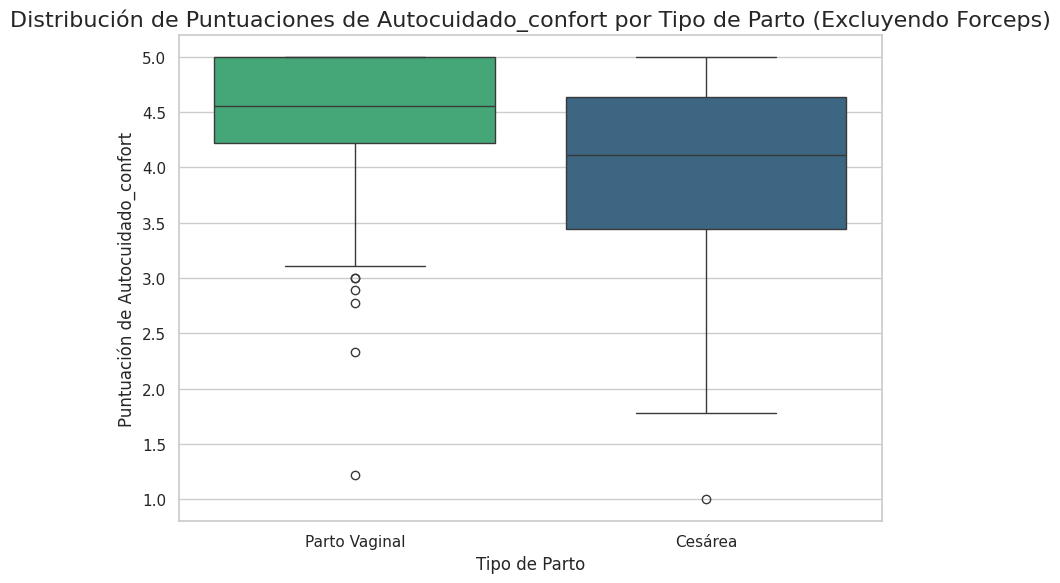

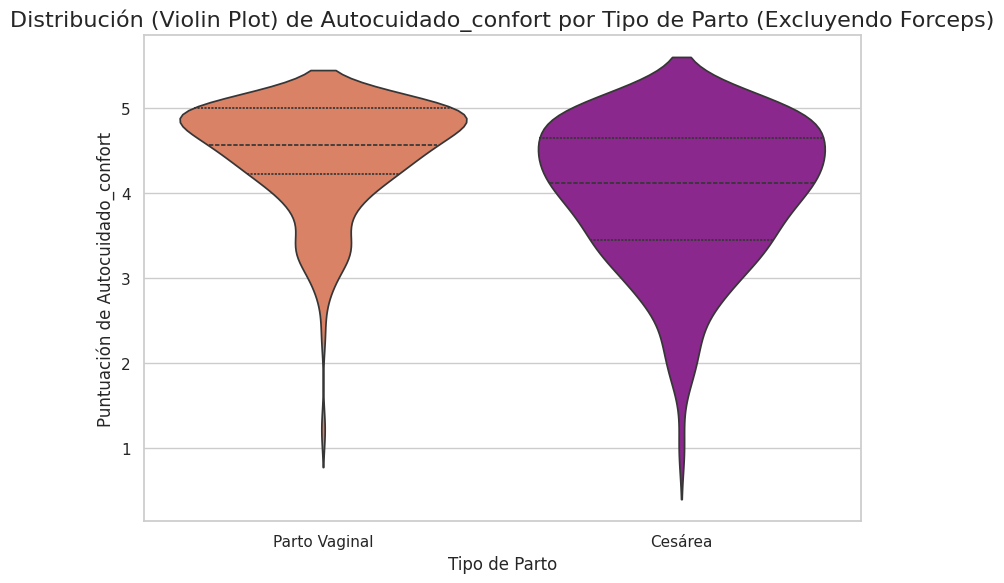

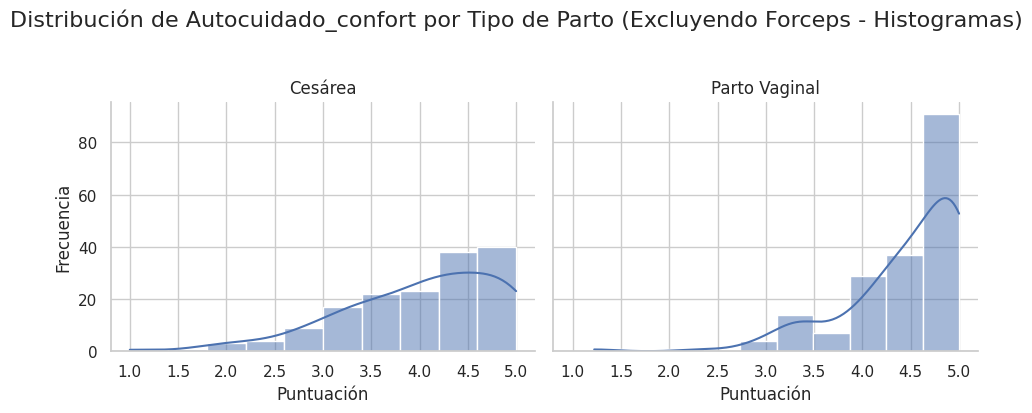

In [89]:
# 2. Visualización de la Distribución de 'Score_Autocuidado_confort' por 'Tipo_parto_std' (filtrado)
print("\nVisualizando la Distribución de 'Autocuidado_confort' por Tipo de Parto (excluyendo Forceps):")

# Boxplot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.boxplot(
        x='Tipo_parto_std',
        y='Score_Autocuidado_confort',
        data=df_filtered_autocuidado, palette='viridis',
        order=df_filtered_autocuidado['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Autocuidado_confort por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Autocuidado_confort', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6)) # Ajustar tamaño para menos grupos
sns.violinplot(
        x='Tipo_parto_std',
        y='Score_Autocuidado_confort',
        data=df_filtered_autocuidado, palette='plasma',
        inner="quartile",
        order=df_filtered_autocuidado['Tipo_parto_std'].value_counts().index,
        hue='Tipo_parto_std',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Autocuidado_confort por Tipo de Parto (Excluyendo Forceps)', fontsize=16)
plt.ylabel('Puntuación de Autocuidado_confort', fontsize=12)
plt.xlabel('Tipo de Parto', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df_filtered_autocuidado, col="Tipo_parto_std", col_wrap=2, height=4, aspect=1.2) # col_wrap=2 para 2 grupos
g.map(sns.histplot, 'Score_Autocuidado_confort', kde=True, bins=10)
g.fig.suptitle('Distribución de Autocuidado_confort por Tipo de Parto (Excluyendo Forceps - Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [90]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---")

# b) Normalidad dentro de cada grupo (filtrado)
print("\nPrueba de Normalidad de 'Autocuidado_confort' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):")
parto_groups_autocuidado_filtered = df_filtered_autocuidado.groupby('Tipo_parto_std')['Score_Autocuidado_confort']

normalidad_results_autocuidado_filtered = {}
for name, group in parto_groups_autocuidado_filtered:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_autocuidado_filtered[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_autocuidado_filtered[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_autocuidado_filtered = pd.DataFrame(normalidad_results_autocuidado_filtered).T
display(normalidad_df_autocuidado_filtered.style
    .set_caption("Normalidad de 'Autocuidado_confort' por Grupo (Shapiro-Wilk, Excluyendo Forceps)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")

# c) Homogeneidad de Varianzas (Levene's Test) (filtrado)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):")

group_data_autocuidado_filtered = [group.dropna().values for name, group in parto_groups_autocuidado_filtered]

if all(len(g) > 0 for g in group_data_autocuidado_filtered) and len(group_data_autocuidado_filtered) == 2: # Levene's requires exactly 2 groups for independent t-test
    stat_levene_autocuidado_filtered, p_value_levene_autocuidado_filtered = stats.levene(*group_data_autocuidado_filtered)
    print(f"Estadístico de Levene: {stat_levene_autocuidado_filtered:.4f}")
    print(f"Valor p: {p_value_levene_autocuidado_filtered:.4f}")

    if p_value_levene_autocuidado_filtered < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
        print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial (Excluyendo Forceps) ---

Prueba de Normalidad de 'Autocuidado_confort' dentro de cada grupo de Tipo de Parto (excluyendo Forceps):


,Shapiro-Wilk p-value,N
Cesárea,0.0000,158
Parto Vaginal,0.0000,184



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test, Excluyendo Forceps):
Estadístico de Levene: 14.5928
Valor p: 0.0002
Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.
Si se usa T-test, se debería aplicar la corrección de Welch.


In [91]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial (filtrado)
print("\n--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos (filtrados)
group1_data_autocuidado = df_filtered_autocuidado[df_filtered_autocuidado['Tipo_parto_std'] == 'Cesárea']['Score_Autocuidado_confort'].dropna()
group2_data_autocuidado = df_filtered_autocuidado[df_filtered_autocuidado['Tipo_parto_std'] == 'Parto Vaginal']['Score_Autocuidado_confort'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_autocuidado) > 0 and len(group2_data_autocuidado) > 0:
    stat_mw_autocuidado, p_value_mw_autocuidado = stats.mannwhitneyu(group1_data_autocuidado, group2_data_autocuidado, alternative='two-sided') # two-sided para diferencia en cualquier dirección
    print(f"Estadístico de Mann-Whitney U: {stat_mw_autocuidado:.4f}")
    print(f"Valor p: {p_value_mw_autocuidado:.4f}")
    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_autocuidado < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Autocuidado_confort' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre estos dos tipos de parto.")
        print(f"La mediana para Cesárea es {group1_data_autocuidado.median():.2f} y para Parto Vaginal es {group2_data_autocuidado.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre 'Cesárea' y 'Parto Vaginal'.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('Cesárea', 'Parto Vaginal') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_autocuidado) > 1 and len(group2_data_autocuidado) > 1: # T-test requires at least 2 data points per group
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_autocuidado = True # Default to True, but check Levene's result
    if 'p_value_levene_autocuidado_filtered' in locals() and not np.isnan(p_value_levene_autocuidado_filtered) and p_value_levene_autocuidado_filtered < 0.05:
        use_equal_var_autocuidado = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")
    stat_ttest_autocuidado, p_value_ttest_autocuidado = stats.ttest_ind(group1_data_autocuidado, group2_data_autocuidado, equal_var=use_equal_var_autocuidado)
    print(f"Estadístico T: {stat_ttest_autocuidado:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_autocuidado:.4f}")
    # Interpretación del resultado del T-test
    if p_value_ttest_autocuidado < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Autocuidado_confort' son iguales entre 'Cesárea' y 'Parto Vaginal'.")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre estos dos tipos de parto.")
        print(f"La media para Cesárea es {group1_data_autocuidado.mean():.2f} y para Parto Vaginal es {group2_data_autocuidado.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre 'Cesárea' y 'Parto Vaginal'.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas (Excluyendo Forceps) ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 9726.5000
Valor p: 0.0000

Conclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medianas de 'Autocuidado_confort' son iguales entre 'Cesárea' y 'Parto Vaginal'.
Existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre estos dos tipos de parto.
La mediana para Cesárea es 4.11 y para Parto Vaginal es 4.56.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.
Estadístico T: -5.3917
Valor p (T-test): 0.0000

Conclusión (T-test): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula

In [92]:
# 5. Conclusiones y Recomendaciones (filtrado)
print("\n--- Conclusiones del Análisis 'Autocuidado_confort' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Autocuidado_confort' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_autocuidado' in locals() and not np.isnan(p_value_mw_autocuidado):
    if p_value_mw_autocuidado < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_autocuidado:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Autocuidado_confort' entre 'Cesárea' y 'Parto Vaginal'.")
        print(f"  Esto sugiere que la percepción de 'Autocuidado_confort' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
        print(f"  Mediana Cesárea: {group1_data_autocuidado.median():.2f}, Mediana Parto Vaginal: {group2_data_autocuidado.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_autocuidado:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre cesárea y parto vaginal basado en esta prueba no paramétrica.")
elif 'p_value_ttest_autocuidado' in locals() and not np.isnan(p_value_ttest_autocuidado):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_autocuidado < 0.05:
         print(f"- La prueba T ({p_value_ttest_autocuidado:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Autocuidado_confort' entre 'Cesárea' y 'Parto Vaginal'.")
         print(f"  Esto sugiere que la percepción de 'Autocuidado_confort' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.")
         print(f"  Media Cesárea: {group1_data_autocuidado.mean():.2f}, Media Parto Vaginal: {group2_data_autocuidado.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_autocuidado:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre cesárea y parto vaginal basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\n--- Prueba Post-Hoc y Tamaño del Efecto para la Dimensión 'Autocuidado_confort' según Tipo de Parto (excluye Forceps) ---")

df_filtered_autocuidado_mw = df[df['Tipo_parto_std'].isin(['Cesárea', 'Parto Vaginal'])].copy()

if len(df_filtered_autocuidado_mw['Tipo_parto_std'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    mw_effect_size_autocuidado = pg.mwu(
        x=df_filtered_autocuidado_mw[df_filtered_autocuidado_mw['Tipo_parto_std'] == 'Cesárea']['Score_Autocuidado_confort'].dropna(),
        y=df_filtered_autocuidado_mw[df_filtered_autocuidado_mw['Tipo_parto_std'] == 'Parto Vaginal']['Score_Autocuidado_confort'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_autocuidado.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Fix: Handle naming changes in Pingouin versions (p-val vs p_val)
    p_col = 'p-val' if 'p-val' in mw_effect_size_autocuidado.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_autocuidado.columns else 'U_val'

    effect_size_value_autocuidado = mw_effect_size_autocuidado['RBC'].iloc[0]
    p_value_autocuidado = mw_effect_size_autocuidado[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_autocuidado[u_col].iloc[0]:.4f}")
    print(f"Valor p: {p_value_autocuidado:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_autocuidado:.4f}")

    abs_effect_size_autocuidado = abs(effect_size_value_autocuidado)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_autocuidado >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_autocuidado:.2f}) es grande.")
    elif abs_effect_size_autocuidado >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_autocuidado:.2f}) es mediano.")
    elif abs_effect_size_autocuidado >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_autocuidado:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_autocuidado:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_autocuidado < 0.05:
         print(f"- La diferencia en las medianas de 'Autocuidado_confort' entre 'Cesárea' y 'Parto Vaginal' es estadísticamente significativa (p={p_value_autocuidado:.4f}).")
         effect_size_interpretation_autocuidado = 'muy pequeña' if abs_effect_size_autocuidado < 0.10 else ('pequeña' if abs_effect_size_autocuidado < 0.30 else ('mediana' if abs_effect_size_autocuidado < 0.50 else 'grande'))
         print(f"- Además, el tamaño del efecto Rank-Biserial r ({abs_effect_size_autocuidado:.2f}) sugiere que esta diferencia es de magnitud {effect_size_interpretation_autocuidado}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_autocuidado:.4f}) no encontró una diferencia estadísticamente significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")

print("\n--- Fin del Análisis Específico de 'Autocuidado_confort' (excluye Forceps) ---")


--- Conclusiones del Análisis 'Autocuidado_confort' por Tipo de Parto (Excluye Forceps) ---
- Se realizó el análisis comparando las puntuaciones de 'Autocuidado_confort' entre 'Cesárea' y 'Parto Vaginal', excluyendo la categoría 'Forceps'.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0000) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Autocuidado_confort' entre 'Cesárea' y 'Parto Vaginal'.
  Esto sugiere que la percepción de 'Autocuidado_confort' difiere significativamente entre mujeres que tuvieron parto por cesárea y aquellas que tuvieron parto vaginal.
  Mediana Cesárea: 4.11, Mediana Parto Vaginal: 4.56.

--- Prueba Post-Hoc y Tamaño del Efecto para la Dimensión 'Autocuidado_con

,U_val,alternative,p_val,RBC,CLES
MWU,9726.500000,two-sided,0.000000,-0.330868,0.334566



Estadístico de Mann-Whitney U: 9726.5000
Valor p: 0.0000
Tamaño del Efecto (Rank-Biserial r): -0.3309

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.33) es mediano.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La diferencia en las medianas de 'Autocuidado_confort' entre 'Cesárea' y 'Parto Vaginal' es estadísticamente significativa (p=0.0000).
- Además, el tamaño del efecto Rank-Biserial r (0.33) sugiere que esta diferencia es de magnitud mediana.

--- Fin del Análisis Específico de 'Autocuidado_confort' (excluye Forceps) ---


In [93]:
# 6. Conclusiones y Recomendaciones Generales para Autocuidado_confort

print("\n--- Conclusiones Generales del Análisis 'Autocuidado_confort' por Tipo de Parto (Excluye Forceps) ---")
print("- Se realizó un análisis exhaustivo de la percepción de 'Autocuidado_confort' según el tipo de parto, excluyendo los casos de Forceps.")
print("- Se examinaron las estadísticas descriptivas y las distribuciones visualmente para entender las diferencias entre los grupos 'Cesárea' y 'Parto Vaginal'.")
print("- Se evaluaron los supuestos de normalidad y homogeneidad de varianzas para guiar la selección de la prueba inferencial.")

# Based on the previous analysis, re-state the main finding for Autocuidado_confort
if 'p_value_mw_autocuidado' in locals() and not np.isnan(p_value_mw_autocuidado):
    if p_value_mw_autocuidado < 0.05:
        print(f"\nPrincipal Hallazgo (Prueba Mann-Whitney U, p={p_value_mw_autocuidado:.4f}):")
        print("  Existe una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre mujeres con parto por cesárea y parto vaginal.")
        if 'effect_size_value_autocuidado' in locals() and not np.isnan(effect_size_value_autocuidado):
            effect_size_interpretation_autocuidado = 'muy pequeña' if abs(effect_size_value_autocuidado) < 0.10 else ('pequeña' if abs(effect_size_value_autocuidado) < 0.30 else ('mediana' if abs(effect_size_value_autocuidado) < 0.50 else 'grande'))
            print(f"  El tamaño del efecto Rank-Biserial r ({abs(effect_size_value_autocuidado):.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_autocuidado}.")
            # Add conclusion about which group had a higher score
            if group1_data_autocuidado.median() > group2_data_autocuidado.median():
                print(f"  Las mujeres con Cesárea reportaron, en promedio/mediana ({group1_data_autocuidado.median():.2f}), una mayor percepción de 'Autocuidado_confort' que aquellas con Parto Vaginal ({group2_data_autocuidado.median():.2f}).")
            else:
                 print(f"  Las mujeres con Parto Vaginal reportaron, en promedio/mediana ({group2_data_autocuidado.median():.2f}), una mayor percepción de 'Autocuidado_confort' que aquellas con Cesárea ({group1_data_autocuidado.median():.2f}).")
    else:
        print(f"\nPrincipal Hallazgo (Prueba Mann-Whitney U, p={p_value_mw_autocuidado:.4f}):")
        print("  No se encontró una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre mujeres con parto por cesárea y parto vaginal.")
elif 'p_value_ttest_autocuidado' in locals() and not np.isnan(p_value_ttest_autocuidado):
    if p_value_ttest_autocuidado < 0.05:
        print(f"\nPrincipal Hallazgo (Prueba T, p={p_value_ttest_autocuidado:.4f}):")
        print("  Existe una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre mujeres con parto por cesárea y parto vaginal.")
        # Add conclusion about which group had a higher score
        if group1_data_autocuidado.mean() > group2_data_autocuidado.mean():
            print(f"  Las mujeres con Cesárea reportaron, en promedio ({group1_data_autocuidado.mean():.2f}), una mayor percepción de 'Autocuidado_confort' que aquellas con Parto Vaginal ({group2_data_autocuidado.mean():.2f}).")
        else:
             print(f"  Las mujeres con Parto Vaginal reportaron, en promedio ({group2_data_autocuidado.mean():.2f}), una mayor percepción de 'Autocuidado_confort' que aquellas con Cesárea ({group1_data_autocuidado.mean():.2f}).")
    else:
        print(f"\nPrincipal Hallazgo (Prueba T, p={p_value_ttest_autocuidado:.4f}):")
        print("  No se encontró una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre mujeres con parto por cesárea y parto vaginal.")
else:
    print("\nNo se pudo determinar el hallazgo principal ya que no se realizó la prueba inferencial.")

print("\nRecomendaciones Adicionales para 'Autocuidado_confort':")
print("- Si se encontró una diferencia significativa, investigar los factores específicos relacionados con el autocuidado y el confort que podrían diferir según el tipo de parto (ej. manejo del dolor postparto, movilidad, apoyo recibido para el cuidado personal).")
print("- Evaluar si las necesidades de autocuidado y confort percibidas son diferentes para mujeres que tuvieron cesárea versus parto vaginal.")
print("- Realizar análisis más detallados, como la exploración de subgrupos o la inclusión de covariables.")
print("- Utilizar estos hallazgos para adaptar las estrategias de educación y apoyo al autocuidado según el tipo de parto, con el objetivo de mejorar el confort postparto.")

print("\n--- Fin del Análisis Completo de 'Autocuidado_confort' (Excluye Forceps) ---")



--- Conclusiones Generales del Análisis 'Autocuidado_confort' por Tipo de Parto (Excluye Forceps) ---
- Se realizó un análisis exhaustivo de la percepción de 'Autocuidado_confort' según el tipo de parto, excluyendo los casos de Forceps.
- Se examinaron las estadísticas descriptivas y las distribuciones visualmente para entender las diferencias entre los grupos 'Cesárea' y 'Parto Vaginal'.
- Se evaluaron los supuestos de normalidad y homogeneidad de varianzas para guiar la selección de la prueba inferencial.

Principal Hallazgo (Prueba Mann-Whitney U, p=0.0000):
  Existe una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre mujeres con parto por cesárea y parto vaginal.
  El tamaño del efecto Rank-Biserial r (0.33) sugiere una magnitud de la diferencia mediana.
  Las mujeres con Parto Vaginal reportaron, en promedio/mediana (4.56), una mayor percepción de 'Autocuidado_confort' que aquellas con Cesárea (4.11).

Recomendaciones Adicionales para 'Au

## 6.2 Resumen Análisis por Dimensiones sugún Tipo de Parto **(se excluyen forceps)**

In [94]:
# Recopilar los resultados de las pruebas y tamaños del efecto
# Asegurarse de que las variables de p-value y effect size existan y no sean NaN

resultados_resumen = []

# Dimensión 6.1.2: Cuidado Relacional
if 'p_value_mw_cuidado_relacional' in locals() and not np.isnan(p_value_mw_cuidado_relacional):
    resultados_resumen.append({
        'Ítem': '6.1.2 Cuidado Relacional de la Calidad',
        'Prueba Estadística': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_relacional,
        'Tamaño del Efecto': abs(effect_size_value_cuidado_relacional) if 'effect_size_value_cuidado_relacional' in locals() and not np.isnan(effect_size_value_cuidado_relacional) else np.nan,
        'Significancia (p < 0.05)': p_value_mw_cuidado_oportuno < 0.05 if not np.isnan(p_value_mw_cuidado_oportuno) else False
    })
elif 'p_value_ttest_cuidado_relacional' in locals() and not np.isnan(p_value_ttest_cuidado_relacional):
     resultados_resumen.append({
        'Ítem': '6.1.2 Cuidado Relacional de la Calidad',
        'Prueba Estadística': 'T-test',
        'Valor p': p_value_ttest_cuidado_relacional,
        'Tamaño del Efecto': np.nan, # Tamaño del efecto para t-test (Cohen's d) no se calculó en el snippet provisto
        'Significancia (p < 0.05)': p_value_ttest_cuidado_relacional < 0.05 if not np.isnan(p_value_ttest_cuidado_relacional) else False
    })


# Dimensión 6.2.2: Cuidado_despersonalizado
if 'p_value_mw_cuidado_despersonalizado' in locals() and not np.isnan(p_value_mw_cuidado_despersonalizado):
    resultados_resumen.append({
        'Ítem': '6.2.2 Cuidado Despersonalizado',
        'Prueba Estadística': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_despersonalizado,
        'Tamaño del Efecto': abs(effect_size_value_despersonalizado) if 'effect_size_value_oportuno' in locals() and not np.isnan(effect_size_value_oportuno) else np.nan,
        'Significancia (p < 0.05)': p_value_mw_cuidado_despersonalizado < 0.05 if not np.isnan(p_value_mw_cuidado_despersonalizado) else False
    })
elif 'p_value_ttest_despersonalizado' in locals() and not np.isnan(p_value_ttest_despersonalizado):
     resultados_resumen.append({
        'Ítem': '6.2.2 Cuidado Despersonalizado',
        'Prueba Estadística': 'T-test',
        'Valor p': p_value_ttest_despersonalizado,
        'Tamaño del Efecto': np.nan, # Tamaño del efecto para t-test (Cohen's d) no se calculó en el snippet provisto
        'Significancia (p < 0.05)': p_value_ttest_despersonalizado < 0.05 if not np.isnan(p_value_ttest_despersonalizado) else False
    })

# Dimensión 6.3.2: Participacion_familiar
if 'p_value_mw_participacion_familiar' in locals() and not np.isnan(p_value_mw_participacion_familiar):
    resultados_resumen.append({
        'Ítem': '6.3.2: Participacion Familiar',
        'Prueba Estadística': 'Mann-Whitney U',
        'Valor p': p_value_mw_participacion_familiar,
        'Tamaño del Efecto': abs(effect_size_value_participacion_familiar) if 'effect_size_value_participacion_familiar' in locals() and not np.isnan(effect_size_value_oportuno) else np.nan,
        'Significancia (p < 0.05)': p_value_mw_participacion_familiar < 0.05 if not np.isnan(p_value_mw_participacion_familiar) else False
    })
elif 'p_value_ttest_participacion' in locals() and not np.isnan(p_value_ttest_participacion):
     resultados_resumen.append({
        'Ítem': '6.3.2: Participacion Familiar',
        'Prueba Estadística': 'T-test',
        'Valor p': p_value_ttest_participacion,
        'Tamaño del Efecto': np.nan, # Tamaño del efecto para t-test (Cohen's d) no se calculó en el snippet provisto
        'Significancia (p < 0.05)': p_value_ttest_participacion < 0.05 if not np.isnan(p_value_ttest_participacion) else False
    })


# Dimensión 6.4.2: Cuidado Oportuno
if 'p_value_mw_cuidado_oportuno' in locals() and not np.isnan(p_value_mw_cuidado_oportuno):
    resultados_resumen.append({
        'Ítem': '6.4.2: Cuidado Oportuno',
        'Prueba Estadística': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_oportuno,
        'Tamaño del Efecto': abs(effect_size_value_oportuno) if 'effect_size_value_oportuno' in locals() and not np.isnan(effect_size_value_oportuno) else np.nan,
        'Significancia (p < 0.05)': p_value_mw_cuidado_oportuno < 0.05 if not np.isnan(p_value_mw_cuidado_oportuno) else False
    })
elif 'p_value_ttest_oportuno' in locals() and not np.isnan(p_value_ttest_oportuno):
     resultados_resumen.append({
        'Ítem': '6.4.2: Cuidado Oportuno',
        'Prueba Estadística': 'T-test',
        'Valor p': p_value_ttest_oportuno,
        'Tamaño del Efecto': np.nan, # Tamaño del efecto para t-test (Cohen's d) no se calculó en el snippet provisto
        'Significancia (p < 0.05)': p_value_ttest_oportuno < 0.05 if not np.isnan(p_value_ttest_oportuno) else False
    })


# Dimensión 6.5.2: Ambiente_fisico_confortable
if 'p_value_mw_ambiente' in locals() and not np.isnan(p_value_mw_ambiente):
    resultados_resumen.append({
        'Ítem': '6.5.2 Ambiente Físico Confortable',
        'Prueba Estadística': 'Mann-Whitney U',
        'Valor p': p_value_mw_ambiente,
        'Tamaño del Efecto': abs(effect_size_value_ambiente) if 'effect_size_value_ambiente' in locals() and not np.isnan(effect_size_value_ambiente) else np.nan,
        'Significancia (p < 0.05)': p_value_mw_ambiente < 0.05 if not np.isnan(p_value_mw_ambiente) else False
    })
elif 'p_value_ttest_ambiente' in locals() and not np.isnan(p_value_ttest_ambiente):
     resultados_resumen.append({
        'Ítem': '6.5.2 Ambiente Físico Confortable',
        'Prueba Estadística': 'T-test',
        'Valor p': p_value_ttest_ambiente,
        'Tamaño del Efecto': np.nan, # Tamaño del efecto para t-test (Cohen's d) no se calculó en el snippet provisto
        'Significancia (p < 0.05)': p_value_ttest_ambiente < 0.05 if not np.isnan(p_value_ttest_ambiente) else False
    })

# Dimensión 6.6.2: Condiciones_contacto_madre_hijo
if 'p_value_mw_contacto' in locals() and not np.isnan(p_value_mw_contacto):
    resultados_resumen.append({
        'Ítem': '6.6.2 Condiciones contacto madre hijo',
        'Prueba Estadística': 'Mann-Whitney U',
        'Valor p': p_value_mw_contacto,
        'Tamaño del Efecto': abs(effect_size_value_contacto) if 'effect_size_value_contacto' in locals() and not np.isnan(effect_size_value_contacto) else np.nan,
        'Significancia (p < 0.05)': p_value_mw_contacto < 0.05 if not np.isnan(p_value_mw_contacto) else False
    })
elif 'p_value_ttest_contacto' in locals() and not np.isnan(p_value_ttest_contacto):
     resultados_resumen.append({
        'Ítem': '6.6.2 Condiciones contacto madre hijo',
        'Prueba Estadística': 'T-test',
        'Valor p': p_value_ttest_contacto,
        'Tamaño del Efecto': np.nan, # Tamaño del efecto para t-test (Cohen's d) no se calculó en el snippet provisto
        'Significancia (p < 0.05)': p_value_ttest_contacto < 0.05 if not np.isnan(p_value_ttest_contacto) else False
    })

# Dimensión 6.7.2: Autocuidado_confort
if 'p_value_mw_autocuidado' in locals() and not np.isnan(p_value_mw_autocuidado):
    resultados_resumen.append({
        'Ítem': '6.7.2 Autocuidado confort',
        'Prueba Estadística': 'Mann-Whitney U',
        'Valor p': p_value_mw_autocuidado,
        'Tamaño del Efecto': abs(effect_size_value_autocuidado) if 'effect_size_value_autocuidado' in locals() and not np.isnan(effect_size_value_autocuidado) else np.nan,
        'Significancia (p < 0.05)': p_value_mw_autocuidado < 0.05 if not np.isnan(p_value_mw_autocuidado) else False
    })
elif 'p_value_ttest_autocuidado' in locals() and not np.isnan(p_value_ttest_autocuidado):
     resultados_resumen.append({
        'Ítem': '6.7.2 Autocuidado confort',
        'Prueba Estadística': 'T-test',
        'Valor p': p_value_ttest_autocuidado,
        'Tamaño del Efecto': np.nan, # Tamaño del efecto para t-test (Cohen's d) no se calculó en el snippet provisto
        'Significancia (p < 0.05)': p_value_ttest_autocuidado < 0.05 if not np.isnan(p_value_ttest_autocuidado) else False
    })

# Crear DataFrame con los resultados
df_resumen = pd.DataFrame(resultados_resumen)

# Reemplazar NaN en 'Tamaño del Efecto' con 0 o algún indicador para ordenar si no se calculó
df_resumen['Tamaño del Efecto'].fillna(0, inplace=True)

# Ordenar por 'Tamaño del Efecto' de mayor a menor
df_resumen_ordenado = df_resumen.sort_values(by='Tamaño del Efecto', ascending=False)

# Formato para la tabla profesional
print("\n--- Resumen de Pruebas Estadísticas y Tamaño del Efecto (Ítem 6, Excluye Forceps) ---")
display(df_resumen_ordenado.style
    .set_caption("Resumen de Resultados por Dimensión (Ítems 6.x.2) - Ordenado por Tamaño del Efecto")
    .format({
        'Valor p': "{:.4f}",
        'Tamaño del Efecto': "{:.4f}",
        'Significancia (p < 0.05)': lambda x: 'Sí' if x else 'No'
        })
    .background_gradient(cmap='RdYlGn_r', subset=['Valor p']) # Rojo para p bajos (significativo), Verde para p altos
    .background_gradient(cmap='Blues', subset=['Tamaño del Efecto']) # Azul para tamaño de efecto
    .set_properties(**{'font-size': '10pt', 'border': '1px solid grey'})
    .hide(axis='index') # Ocultar el índice por defecto
)

print("\nNotas sobre la tabla:")
print("- La columna 'Significancia (p < 0.05)' indica si la diferencia encontrada fue estadísticamente significativa al nivel alfa = 0.05.")
print("- La columna 'Tamaño del Efecto' reporta el valor absoluto del Rank-Biserial r para las pruebas de Mann-Whitney U (u otro, si se realizó T-test pero no se calculó Cohens d, aparece como 0).")
print("- La tabla está ordenada de mayor a menor tamaño del efecto percibido.")
print("- Un tamaño del efecto mayor indica una diferencia más sustancial entre los grupos 'Cesárea' y 'Parto Vaginal'.")
print("- La interpretación del tamaño del efecto (muy pequeño < 0.1, pequeño 0.1-0.3, mediano 0.3-0.5, grande >= 0.5 para Rank-Biserial r) ayuda a entender la relevancia práctica de la diferencia.")



--- Resumen de Pruebas Estadísticas y Tamaño del Efecto (Ítem 6, Excluye Forceps) ---


/tmp/ipykernel_1186/1837726907.py:139: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_resumen['Tamaño del Efecto'].fillna(0, inplace=True)


Ítem,Prueba Estadística,Valor p,Tamaño del Efecto,Significancia (p < 0.05)
6.6.2 Condiciones contacto madre hijo,Mann-Whitney U,0.0000,0.3713,Sí
6.7.2 Autocuidado confort,Mann-Whitney U,0.0000,0.3309,Sí
6.2.2 Cuidado Despersonalizado,Mann-Whitney U,0.0014,0.1959,Sí
6.3.2: Participacion Familiar,Mann-Whitney U,0.0007,0.1779,Sí
6.5.2 Ambiente Físico Confortable,Mann-Whitney U,0.0344,0.1158,Sí
6.4.2: Cuidado Oportuno,Mann-Whitney U,0.0648,0.1080,No
6.1.2 Cuidado Relacional de la Calidad,Mann-Whitney U,0.0865,0.0000,No



Notas sobre la tabla:
- La columna 'Significancia (p < 0.05)' indica si la diferencia encontrada fue estadísticamente significativa al nivel alfa = 0.05.
- La columna 'Tamaño del Efecto' reporta el valor absoluto del Rank-Biserial r para las pruebas de Mann-Whitney U (u otro, si se realizó T-test pero no se calculó Cohens d, aparece como 0).
- La tabla está ordenada de mayor a menor tamaño del efecto percibido.
- Un tamaño del efecto mayor indica una diferencia más sustancial entre los grupos 'Cesárea' y 'Parto Vaginal'.
- La interpretación del tamaño del efecto (muy pequeño < 0.1, pequeño 0.1-0.3, mediano 0.3-0.5, grande >= 0.5 para Rank-Biserial r) ayuda a entender la relevancia práctica de la diferencia.


## 6.3 Análisis por Dimensiones sugún Paridad

### 6.3.1 Análisis por Dimensión (Cuidado_relacional_calidad) sugún Paridad ✅

In [95]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.1.8 pero esta vez con la dimensión Cuidado_relacional_calidad según paridad, entendiendo que paridad es una variable que separa la muestra en 2 (P para primiparas y M para multiparas)

print("\n--- Análisis Específico: Puntuación de 'Cuidado_relacional_calidad' según Paridad ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_relacional_calidad' por 'Paridad'
print("\nEstadísticas Descriptivas para 'Cuidado_relacional_calidad' por Paridad:")
paridad_cuidado_relacional_stats = df.groupby('Paridad')['Score_Cuidado_relacional_calidad'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(paridad_cuidado_relacional_stats.style
        .set_caption("Estadísticas Descriptivas de 'Cuidado Relacional de la Calidad' por Paridad")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos ('P', 'M').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


--- Análisis Específico: Puntuación de 'Cuidado_relacional_calidad' según Paridad ---

Estadísticas Descriptivas para 'Cuidado_relacional_calidad' por Paridad:


Paridad,M,P
count,190.00,155.00
mean,4.86,4.75
median,5.00,5.00
std,0.29,0.44
min,3.08,2.62
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos ('P', 'M').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Relacional de la Calidad' por Paridad:


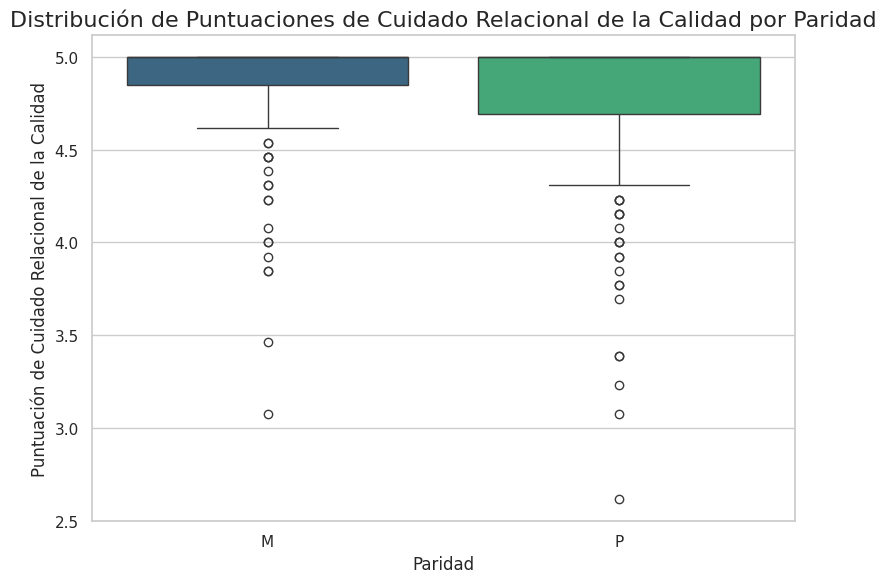

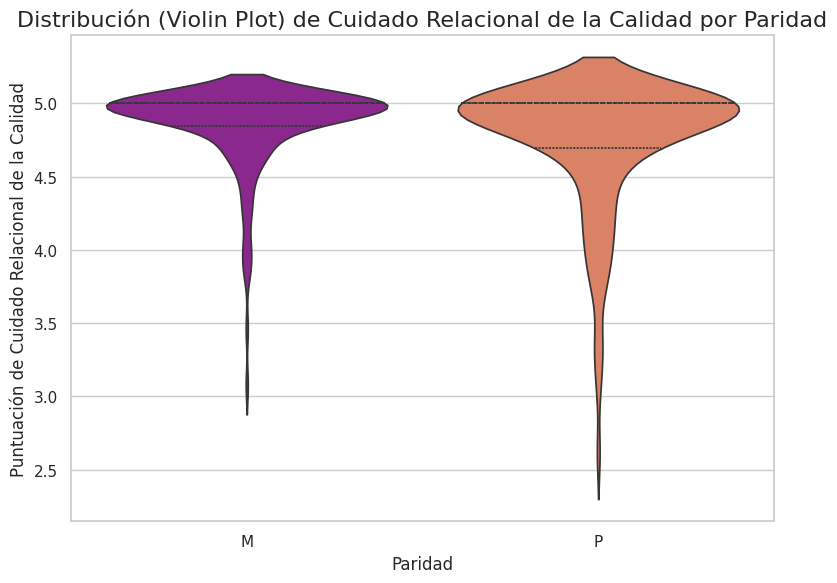

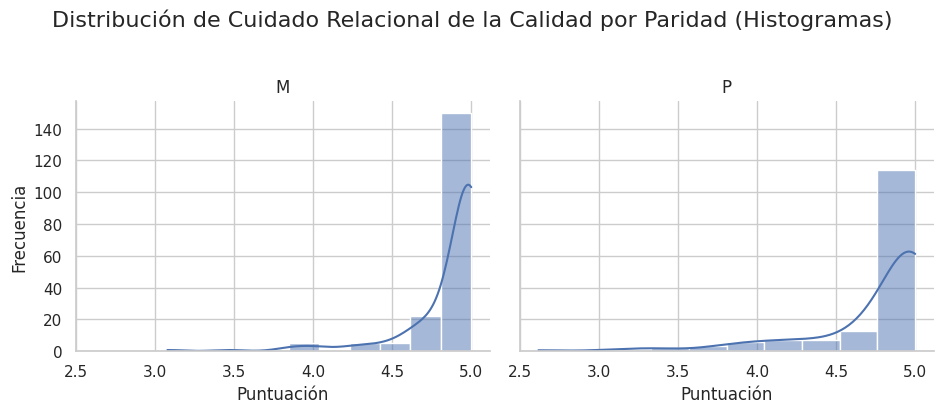

In [96]:
# 2. Visualización de la Distribución de 'Score_Cuidado_relacional_calidad' por 'Paridad'
print("\nVisualizando la Distribución de 'Cuidado Relacional de la Calidad' por Paridad:")

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
        x='Paridad',
        y='Score_Cuidado_relacional_calidad',
        data=df, palette='viridis',
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Cuidado Relacional de la Calidad por Paridad', fontsize=16)
plt.ylabel('Puntuación de Cuidado Relacional de la Calidad', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(
        x='Paridad',
        y='Score_Cuidado_relacional_calidad',
        data=df, palette='plasma',
        inner="quartile",
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Cuidado Relacional de la Calidad por Paridad', fontsize=16)
plt.ylabel('Puntuación de Cuidado Relacional de la Calidad', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df, col="Paridad", col_wrap=2, height=4, aspect=1.2)
g.map(sns.histplot, 'Score_Cuidado_relacional_calidad', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Relacional de la Calidad por Paridad (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [97]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
# Para comparar 2 grupos independientes ('P' vs 'M'),
# las pruebas comunes son T-test independiente (paramétrica) o Mann-Whitney U (no paramétrica).

# Supuestos para T-test independiente:
# a) Independencia de las observaciones (asumido).
# b) Normalidad de la variable dependiente dentro de cada grupo.
# c) Homogeneidad de varianzas (Levene's test).

print("\n--- Evaluación de Supuestos para Análisis Inferencial ---")

# b) Normalidad dentro de cada grupo
print("\nPrueba de Normalidad de 'Cuidado Relacional de la Calidad' dentro de cada grupo de Paridad:")
paridad_groups_cuidado_relacional = df.groupby('Paridad')['Score_Cuidado_relacional_calidad']

normalidad_results_cuidado_relacional = {}
for name, group in paridad_groups_cuidado_relacional:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_cuidado_relacional[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_cuidado_relacional[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_cuidado_relacional = pd.DataFrame(normalidad_results_cuidado_relacional).T
display(normalidad_df_cuidado_relacional.style
    .set_caption("Normalidad de 'Cuidado Relacional de la Calidad' por Grupo (Shapiro-Wilk)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")


# c) Homogeneidad de Varianzas (Levene's Test)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

group_data_cuidado_relacional = [group.dropna().values for name, group in paridad_groups_cuidado_relacional]

if all(len(g) > 0 for g in group_data_cuidado_relacional) and len(group_data_cuidado_relacional) == 2:
    stat_levene_cuidado_relacional, p_value_levene_cuidado_relacional = stats.levene(*group_data_cuidado_relacional)
    print(f"Estadístico de Levene: {stat_levene_cuidado_relacional:.4f}")
    print(f"Valor p: {p_value_levene_cuidado_relacional:.4f}")

    if p_value_levene_cuidado_relacional < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
    print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial ---

Prueba de Normalidad de 'Cuidado Relacional de la Calidad' dentro de cada grupo de Paridad:


,Shapiro-Wilk p-value,N
M,0.0000,190
P,0.0000,155



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 8.4563
Valor p: 0.0039
Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.
Si se usa T-test, se debería aplicar la corrección de Welch.


In [98]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial

print("\n--- Prueba Estadística para Comparar Medias/Medianas ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos
group1_data_paridad_cr = df[df['Paridad'] == 'P']['Score_Cuidado_relacional_calidad'].dropna()
group2_data_paridad_cr = df[df['Paridad'] == 'M']['Score_Cuidado_relacional_calidad'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_paridad_cr) > 0 and len(group2_data_paridad_cr) > 0:
    stat_mw_cuidado_relacional_paridad, p_value_mw_cuidado_relacional_paridad = stats.mannwhitneyu(group1_data_paridad_cr, group2_data_paridad_cr, alternative='two-sided')
    print(f"Estadístico de Mann-Whitney U: {stat_mw_cuidado_relacional_paridad:.4f}")
    print(f"Valor p: {p_value_mw_cuidado_relacional_paridad:.4f}")

    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_cuidado_relacional_paridad < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado Relacional de la Calidad' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional de la Calidad' según la paridad.")
        print(f"La mediana para Primíparas (P) es {group1_data_paridad_cr.median():.2f} y para Multíparas (M) es {group2_data_paridad_cr.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional de la Calidad' entre Primíparas y Multíparas.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('P', 'M') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_paridad_cr) > 1 and len(group2_data_paridad_cr) > 1:
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_cuidado_relacional_paridad = True # Default to True, but check Levene's result
    if 'p_value_levene_cuidado_relacional' in locals() and not np.isnan(p_value_levene_cuidado_relacional) and p_value_levene_cuidado_relacional < 0.05:
        use_equal_var_cuidado_relacional_paridad = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")

    stat_ttest_cuidado_relacional_paridad, p_value_ttest_cuidado_relacional_paridad = stats.ttest_ind(group1_data_paridad_cr, group2_data_paridad_cr, equal_var=use_equal_var_cuidado_relacional_paridad)
    print(f"Estadístico T: {stat_ttest_cuidado_relacional_paridad:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_cuidado_relacional_paridad:.4f}")

    # Interpretación del resultado del T-test
    if p_value_ttest_cuidado_relacional_paridad < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Cuidado Relacional de la Calidad' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional de la Calidad' según la paridad.")
        print(f"La media para Primíparas (P) es {group1_data_paridad_cr.mean():.2f} y para Multíparas (M) es {group2_data_paridad_cr.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional de la Calidad' entre Primíparas y Multíparas.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 12925.0000
Valor p: 0.0316

Conclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado Relacional de la Calidad' son iguales entre Primíparas (P) y Multíparas (M).
Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado Relacional de la Calidad' según la paridad.
La mediana para Primíparas (P) es 5.00 y para Multíparas (M) es 5.00.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.
Estadístico T: -2.7928
Valor p (T-test): 0.0056

Conclusión (T-test): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis 

In [99]:
# 5. Tama1o del Efecto

print("\n--- C1lculo del Tama1o del Efecto ---")

# Verificar si hay datos suficientes para ambos grupos de paridad
if len(df['Paridad'].unique()) == 2:
    print("\nCalculando el Tama1o del Efecto (r) para la Prueba de Mann-Whitney U:")

    # Usar pingouin para realizar el test de Mann-Whitney U y obtener el tama1o del efecto
    mw_effect_size_cuidado_relacional_paridad = pg.mwu(
        x=df[df['Paridad'] == 'P']['Score_Cuidado_relacional_calidad'].dropna(),
        y=df[df['Paridad'] == 'M']['Score_Cuidado_relacional_calidad'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_cuidado_relacional_paridad.style.set_caption("Resultados de Mann-Whitney U con Tama1o del Efecto (Rank-Biserial r) usando Pingouin"))

    # Extraer el valor del tama1o del efecto
    # Fix: Handle naming changes in Pingouin versions (p-val vs p_val)
    effect_size_value_cuidado_relacional_paridad = mw_effect_size_cuidado_relacional_paridad['RBC'].iloc[0]
    p_col = 'p-val' if 'p-val' in mw_effect_size_cuidado_relacional_paridad.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_cuidado_relacional_paridad.columns else 'U_val'

    p_value_cuidado_relacional_paridad_pg = mw_effect_size_cuidado_relacional_paridad[p_col].iloc[0]

    print(f"\nEstad1stico de Mann-Whitney U: {mw_effect_size_cuidado_relacional_paridad[u_col].iloc[0]:.4f}")
    print(f"Valor p (Pingouin): {p_value_cuidado_relacional_paridad_pg:.4f}")
    print(f"Tama1o del Efecto (Rank-Biserial r): {effect_size_value_cuidado_relacional_paridad:.4f}")

    abs_effect_size_cuidado_relacional_paridad = abs(effect_size_value_cuidado_relacional_paridad)

    print("\nInterpretaci1n del Tama1o del Efecto (Rank-Biserial r):")
    if abs_effect_size_cuidado_relacional_paridad >= 0.50:
        print(f"- El tama1o del efecto ({abs_effect_size_cuidado_relacional_paridad:.2f}) es grande.")
    elif abs_effect_size_cuidado_relacional_paridad >= 0.30:
        print(f"- El tama1o del efecto ({abs_effect_size_cuidado_relacional_paridad:.2f}) es mediano.")
    elif abs_effect_size_cuidado_relacional_paridad >= 0.10:
        print(f"- El tama1o del efecto ({abs_effect_size_cuidado_relacional_paridad:.2f}) es peque1o.")
    else:
        print(f"- El tama1o del efecto ({abs_effect_size_cuidado_relacional_paridad:.2f}) es muy peque1o.")

    print("\nConclusi1n combinada (Estad1stica y Tama1o del Efecto):")
    if p_value_cuidado_relacional_paridad_pg < 0.05:
         print(f"- La diferencia es estad1sticamente significativa (p={p_value_cuidado_relacional_paridad_pg:.4f}).")
         effect_size_interpretation = 'muy peque1a' if abs_effect_size_cuidado_relacional_paridad < 0.10 else ('peque1a' if abs_effect_size_cuidado_relacional_paridad < 0.30 else ('mediana' if abs_effect_size_cuidado_relacional_paridad < 0.50 else 'grande'))
         print(f"- El tama1o del efecto sugiere una magnitud {effect_size_interpretation}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_cuidado_relacional_paridad_pg:.4f}) no encontr1 una diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los c1lculos.")


--- C1lculo del Tama1o del Efecto ---

Calculando el Tama1o del Efecto (r) para la Prueba de Mann-Whitney U:


,U_val,alternative,p_val,RBC,CLES
MWU,12925.000000,two-sided,0.031648,-0.122241,0.438879



Estad1stico de Mann-Whitney U: 12925.0000
Valor p (Pingouin): 0.0316
Tama1o del Efecto (Rank-Biserial r): -0.1222

Interpretaci1n del Tama1o del Efecto (Rank-Biserial r):
- El tama1o del efecto (0.12) es peque1o.

Conclusi1n combinada (Estad1stica y Tama1o del Efecto):
- La diferencia es estad1sticamente significativa (p=0.0316).
- El tama1o del efecto sugiere una magnitud peque1a.


In [100]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Cuidado_relacional_calidad' por Paridad ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Cuidado Relacional de la Calidad' entre Primíparas (P) y Multíparas (M).")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test for Parity
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_cuidado_relacional_paridad' in locals() and not np.isnan(p_value_mw_cuidado_relacional_paridad):
    if p_value_mw_cuidado_relacional_paridad < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_relacional_paridad:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Cuidado Relacional de la Calidad' entre Primíparas y Multíparas.")
        print(f"  Esto sugiere que la percepción de 'Cuidado Relacional de la Calidad' difiere significativamente según si la mujer es primeriza o no.")
        print(f"  Mediana Primíparas (P): {group1_data_paridad_cr.median():.2f}, Mediana Multíparas (M): {group2_data_paridad_cr.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_relacional_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado Relacional de la Calidad' entre Primíparas y Multíparas basado en esta prueba no paramétrica.")
elif 'p_value_ttest_cuidado_relacional_paridad' in locals() and not np.isnan(p_value_ttest_cuidado_relacional_paridad):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_cuidado_relacional_paridad < 0.05:
         print(f"- La prueba T ({p_value_ttest_cuidado_relacional_paridad:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Cuidado Relacional de la Calidad' entre Primíparas y Multíparas.")
         print(f"  Esto sugiere que la percepción de 'Cuidado Relacional de la Calidad' difiere significativamente según si la mujer es primeriza o no.")
         print(f"  Media Primíparas (P): {group1_data_paridad_cr.mean():.2f}, Media Multíparas (M): {group2_data_paridad_cr.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_cuidado_relacional_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado Relacional de la Calidad' entre Primíparas y Multíparas basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\nResultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):")
if 'abs_effect_size_cuidado_relacional_paridad' in locals() and not np.isnan(abs_effect_size_cuidado_relacional_paridad):
    effect_size_interpretation_cr_paridad = 'muy pequeña' if abs_effect_size_cuidado_relacional_paridad < 0.10 else ('pequeña' if abs_effect_size_cuidado_relacional_paridad < 0.30 else ('mediana' if abs_effect_size_cuidado_relacional_paridad < 0.50 else 'grande'))
    print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_cuidado_relacional_paridad:.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_cr_paridad}.")
    print("  Considerar la relevancia práctica de esta magnitud junto con la significancia estadística.")
else:
     print("- No se pudo calcular el tamaño del efecto.")


print("\nRecomendaciones Adicionales para 'Cuidado Relacional de la Calidad' por Paridad:")
print("- Si se encontró una diferencia significativa, investigar las expectativas y experiencias específicas de Primíparas versus Multíparas respecto al cuidado relacional.")
print("- Evaluar si la comunicación, el apoyo emocional y la sensación de ser valoradas por el personal de salud difieren sistemáticamente entre estos grupos.")
print("- Considerar si las necesidades de apoyo y cuidado pueden variar en función de la experiencia previa con partos.")
print("- Utilizar estos hallazgos para adaptar las estrategias de comunicación y el enfoque del cuidado relacional según la paridad de la paciente.")


print("\n--- Fin del Análisis de 'Cuidado_relacional_calidad' según Paridad ---")


--- Conclusiones del Análisis 'Cuidado_relacional_calidad' por Paridad ---
- Se realizó el análisis comparando las puntuaciones de 'Cuidado Relacional de la Calidad' entre Primíparas (P) y Multíparas (M).
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0316) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Cuidado Relacional de la Calidad' entre Primíparas y Multíparas.
  Esto sugiere que la percepción de 'Cuidado Relacional de la Calidad' difiere significativamente según si la mujer es primeriza o no.
  Mediana Primíparas (P): 5.00, Mediana Multíparas (M): 5.00.

Resultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):
- El tamaño del efecto Rank-Biserial r (0.12) sugiere una m

### 6.3.2 Análisis por Dimensión (Cuidado_despersonalizado) sugún Paridad ❌

In [101]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.1.8 pero esta vez con la dimensión Cuidado_despersonalizado según paridad, entendiendo que paridad es una variable que separa la muestra en 2 (P para primiparas y M para multiparas)

print("\n--- Análisis Específico: Puntuación de 'Cuidado_despersonalizado' según Paridad ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_despersonalizado' por 'Paridad'
print("\nEstadísticas Descriptivas para 'Cuidado_despersonalizado' por Paridad:")
paridad_despersonalizado_stats = df.groupby('Paridad')['Score_Cuidado_despersonalizado'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(paridad_despersonalizado_stats.style
        .set_caption("Estadísticas Descriptivas de 'Cuidado Despersonalizado' por Paridad")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos ('P', 'M').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


--- Análisis Específico: Puntuación de 'Cuidado_despersonalizado' según Paridad ---

Estadísticas Descriptivas para 'Cuidado_despersonalizado' por Paridad:


Paridad,M,P
count,190.00,155.00
mean,1.60,1.66
median,1.33,1.33
std,0.77,0.76
min,1.00,1.00
max,5.00,4.50



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos ('P', 'M').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Despersonalizado' por Paridad:


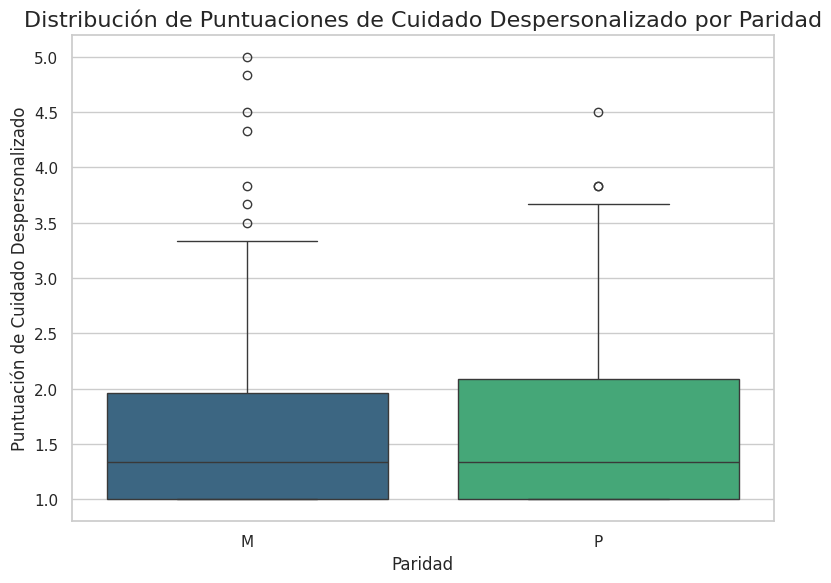

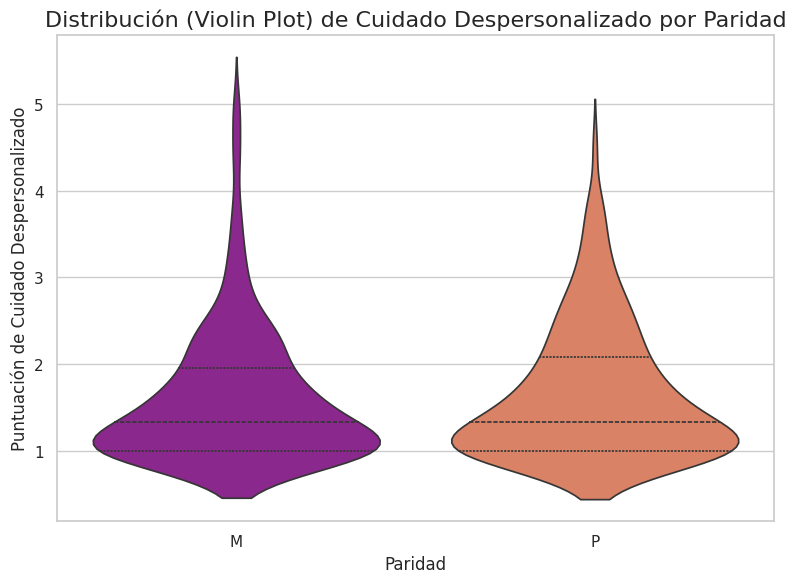

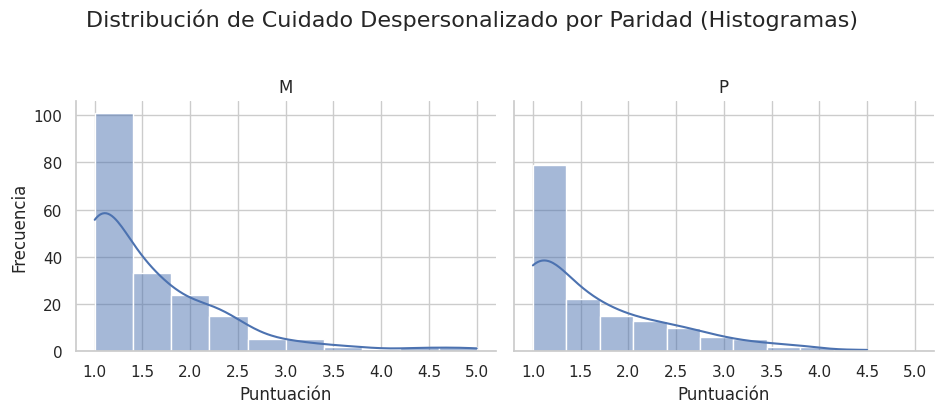

In [102]:
# 2. Visualización de la Distribución de 'Score_Cuidado_despersonalizado' por 'Paridad'
print("\nVisualizando la Distribución de 'Cuidado Despersonalizado' por Paridad:")

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
        x='Paridad',
        y='Score_Cuidado_despersonalizado',
        data=df, palette='viridis',
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Cuidado Despersonalizado por Paridad', fontsize=16)
plt.ylabel('Puntuación de Cuidado Despersonalizado', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(
        x='Paridad',
        y='Score_Cuidado_despersonalizado',
        data=df, palette='plasma',
        inner="quartile",
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Cuidado Despersonalizado por Paridad', fontsize=16)
plt.ylabel('Puntuación de Cuidado Despersonalizado', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df, col="Paridad", col_wrap=2, height=4, aspect=1.2)
g.map(sns.histplot, 'Score_Cuidado_despersonalizado', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Despersonalizado por Paridad (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [103]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
print("\n--- Evaluación de Supuestos para Análisis Inferencial ---")

# b) Normalidad dentro de cada grupo
print("\nPrueba de Normalidad de 'Cuidado_despersonalizado' dentro de cada grupo de Paridad:")
paridad_groups_despersonalizado = df.groupby('Paridad')['Score_Cuidado_despersonalizado']

normalidad_results_despersonalizado = {}
for name, group in paridad_groups_despersonalizado:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_despersonalizado[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_despersonalizado[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_despersonalizado = pd.DataFrame(normalidad_results_despersonalizado).T
display(normalidad_df_despersonalizado.style
    .set_caption("Normalidad de 'Cuidado Despersonalizado' por Grupo (Shapiro-Wilk)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")

# c) Homogeneidad de Varianzas (Levene's Test)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

group_data_despersonalizado = [group.dropna().values for name, group in paridad_groups_despersonalizado]

if all(len(g) > 0 for g in group_data_despersonalizado) and len(group_data_despersonalizado) == 2:
    stat_levene_despersonalizado, p_value_levene_despersonalizado = stats.levene(*group_data_despersonalizado)
    print(f"Estadístico de Levene: {stat_levene_despersonalizado:.4f}")
    print(f"Valor p: {p_value_levene_despersonalizado:.4f}")

    if p_value_levene_despersonalizado < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
    print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial ---

Prueba de Normalidad de 'Cuidado_despersonalizado' dentro de cada grupo de Paridad:


,Shapiro-Wilk p-value,N
M,0.0000,190
P,0.0000,155



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 0.3543
Valor p: 0.5521
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa T-test, se puede asumir igualdad de varianzas.


In [104]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos
group1_data_paridad_cd = df[df['Paridad'] == 'P']['Score_Cuidado_despersonalizado'].dropna()
group2_data_paridad_cd = df[df['Paridad'] == 'M']['Score_Cuidado_despersonalizado'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_paridad_cd) > 0 and len(group2_data_paridad_cd) > 0:
    stat_mw_cuidado_despersonalizado_paridad, p_value_mw_cuidado_despersonalizado_paridad = stats.mannwhitneyu(group1_data_paridad_cd, group2_data_paridad_cd, alternative='two-sided')
    print(f"Estadístico de Mann-Whitney U: {stat_mw_cuidado_despersonalizado_paridad:.4f}")
    print(f"Valor p: {p_value_mw_cuidado_despersonalizado_paridad:.4f}")

    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_cuidado_despersonalizado_paridad < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado_despersonalizado' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_despersonalizado' según la paridad.")
        print(f"La mediana para Primíparas (P) es {group1_data_paridad_cd.median():.2f} y para Multíparas (M) es {group2_data_paridad_cd.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_despersonalizado' entre Primíparas y Multíparas.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('P', 'M') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_paridad_cd) > 1 and len(group2_data_paridad_cd) > 1:
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_cuidado_despersonalizado_paridad = True # Default to True, but check Levene's result
    if 'p_value_levene_despersonalizado' in locals() and not np.isnan(p_value_levene_despersonalizado) and p_value_levene_despersonalizado < 0.05:
        use_equal_var_cuidado_despersonalizado_paridad = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")

    stat_ttest_cuidado_despersonalizado_paridad, p_value_ttest_cuidado_despersonalizado_paridad = stats.ttest_ind(group1_data_paridad_cd, group2_data_paridad_cd, equal_var=use_equal_var_cuidado_despersonalizado_paridad)
    print(f"Estadístico T: {stat_ttest_cuidado_despersonalizado_paridad:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_cuidado_despersonalizado_paridad:.4f}")

    # Interpretación del resultado del T-test
    if p_value_ttest_cuidado_despersonalizado_paridad < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Cuidado_despersonalizado' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Score_Cuidado_despersonalizado' según la paridad.")
        print(f"La media para Primíparas (P) es {group1_data_paridad_cd.mean():.2f} y para Multíparas (M) es {group2_data_paridad_cd.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Score_Cuidado_despersonalizado' entre Primíparas y Multíparas.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 15463.0000
Valor p: 0.4118

Conclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_despersonalizado' entre Primíparas y Multíparas.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico T: 0.7339
Valor p (T-test): 0.4635

Conclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente

In [105]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

# Verificar si hay datos suficientes para ambos grupos de paridad
if len(df['Paridad'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    # Usar pingouin para realizar el test de Mann-Whitney U y obtener el tamaño del efecto
    mw_effect_size_cuidado_despersonalizado_paridad = pg.mwu(
        x=df[df['Paridad'] == 'P']['Score_Cuidado_despersonalizado'].dropna(),
        y=df[df['Paridad'] == 'M']['Score_Cuidado_despersonalizado'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_cuidado_despersonalizado_paridad.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Extraer el valor del tamaño del efecto y manejar nombres de columnas según versión de pingouin
    effect_size_value_cuidado_despersonalizado_paridad = mw_effect_size_cuidado_despersonalizado_paridad['RBC'].iloc[0]
    p_col = 'p-val' if 'p-val' in mw_effect_size_cuidado_despersonalizado_paridad.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_cuidado_despersonalizado_paridad.columns else 'U_val'

    p_value_cuidado_despersonalizado_paridad_pg = mw_effect_size_cuidado_despersonalizado_paridad[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_cuidado_despersonalizado_paridad[u_col].iloc[0]:.4f}")
    print(f"Valor p (Pingouin): {p_value_cuidado_despersonalizado_paridad_pg:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_cuidado_despersonalizado_paridad:.4f}")

    abs_effect_size_cuidado_despersonalizado_paridad = abs(effect_size_value_cuidado_despersonalizado_paridad)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_cuidado_despersonalizado_paridad >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_cuidado_despersonalizado_paridad:.2f}) es grande.")
    elif abs_effect_size_cuidado_despersonalizado_paridad >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_cuidado_despersonalizado_paridad:.2f}) es mediano.")
    elif abs_effect_size_cuidado_despersonalizado_paridad >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_cuidado_despersonalizado_paridad:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_cuidado_despersonalizado_paridad:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_cuidado_despersonalizado_paridad_pg < 0.05:
         print(f"- La diferencia en las medianas es estadísticamente significativa (p={p_value_cuidado_despersonalizado_paridad_pg:.4f}).")
         effect_size_interpretation_cd_paridad = 'muy pequeña' if abs_effect_size_cuidado_despersonalizado_paridad < 0.10 else ('pequeña' if abs_effect_size_cuidado_despersonalizado_paridad < 0.30 else ('mediana' if abs_effect_size_cuidado_despersonalizado_paridad < 0.50 else 'grande'))
         print(f"- El tamaño del efecto sugiere una magnitud {effect_size_interpretation_cd_paridad}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_cuidado_despersonalizado_paridad_pg:.4f}) no encontró una diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:


,U_val,alternative,p_val,RBC,CLES
MWU,15463.000000,two-sided,0.411824,0.050119,0.525059



Estadístico de Mann-Whitney U: 15463.0000
Valor p (Pingouin): 0.4118
Tamaño del Efecto (Rank-Biserial r): 0.0501

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.05) es muy pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La prueba de Mann-Whitney U (0.4118) no encontró una diferencia significativa.


In [106]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Cuidado_despersonalizado' por Paridad ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Cuidado_despersonalizado' entre Primíparas (P) y Multíparas (M).")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test for Parity
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_cuidado_despersonalizado_paridad' in locals() and not np.isnan(p_value_mw_cuidado_despersonalizado_paridad):
    if p_value_mw_cuidado_despersonalizado_paridad < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_despersonalizado_paridad:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Cuidado_despersonalizado' entre Primíparas y Multíparas.")
        print(f"  Esto sugiere que la percepción de 'Cuidado_despersonalizado' difiere significativamente según si la mujer es primeriza o no.")
        print(f"  Mediana Primíparas (P): {group1_data_paridad_cd.median():.2f}, Mediana Multíparas (M): {group2_data_paridad_cd.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_despersonalizado_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_despersonalizado' entre Primíparas y Multíparas basado en esta prueba no paramétrica.")
elif 'p_value_ttest_cuidado_despersonalizado_paridad' in locals() and not np.isnan(p_value_ttest_cuidado_despersonalizado_paridad):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_cuidado_despersonalizado_paridad < 0.05:
         print(f"- La prueba T ({p_value_ttest_cuidado_despersonalizado_paridad:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Cuidado_despersonalizado' entre Primíparas y Multíparas.")
         print(f"  Esto sugiere que la percepción de 'Cuidado_despersonalizado' difiere significativamente según si la mujer es primeriza o no.")
         print(f"  Media Primíparas (P): {group1_data_paridad_cd.mean():.2f}, Media Multíparas (M): {group2_data_paridad_cd.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_cuidado_despersonalizado_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_despersonalizado' entre Primíparas y Multíparas basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\nResultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):")
if 'abs_effect_size_cuidado_despersonalizado_paridad' in locals() and not np.isnan(abs_effect_size_cuidado_despersonalizado_paridad):
    effect_size_interpretation_cd_paridad = 'muy pequeña' if abs_effect_size_cuidado_despersonalizado_paridad < 0.10 else ('pequeña' if abs_effect_size_cuidado_despersonalizado_paridad < 0.30 else ('mediana' if abs_effect_size_cuidado_despersonalizado_paridad < 0.50 else 'grande'))
    print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_cuidado_despersonalizado_paridad:.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_cd_paridad}.")
    print("  Considerar la relevancia práctica de esta magnitud junto con la significancia estadística.")
else:
     print("- No se pudo calcular el tamaño del efecto.")


print("\nRecomendaciones Adicionales para 'Cuidado_despersonalizado' por Paridad:")
print("- Si se encontró una diferencia significativa, investigar si Primíparas o Multíparas tienen experiencias diferentes que contribuyen a sentir el cuidado como más o menos despersonalizado.")
print("- Explorar factores como la necesidad de información, el nivel de ansiedad, o las expectativas basadas en experiencias previas que podrían influir en esta percepción según la paridad.")
print("- Evaluar si las interacciones con el personal de salud son percibidas de manera distinta (ej. sentir que no son tratadas como individuos, falta de empatía) por primíparas vs. multíparas.")
print("- Utilizar estos hallazgos para adaptar la comunicación y el enfoque del cuidado para asegurar que todas las mujeres, independientemente de su paridad, se sientan tratadas con respeto e individualidad.")


print("\n--- Fin del Análisis de 'Cuidado_despersonalizado' según Paridad ---")


--- Conclusiones del Análisis 'Cuidado_despersonalizado' por Paridad ---
- Se realizó el análisis comparando las puntuaciones de 'Cuidado_despersonalizado' entre Primíparas (P) y Multíparas (M).
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.4118) no encontró una diferencia estadísticamente significativa en las medianas.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_despersonalizado' entre Primíparas y Multíparas basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):
- El tamaño del efecto Rank-Biserial r (0.05) sugiere una magnitud de la diferencia muy pequeña.
  Considerar la relevancia práctica de esta mag

### 6.3.3 Análisis por Dimensión (Participacion_familiar_continua) sugún Paridad ✅

In [107]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.1.8 pero esta vez con la dimensión Participacion_familiar_continua según paridad, entendiendo que paridad es una variable que separa la muestra en 2 (P para primiparas y M para multiparas)

print("\n--- Análisis Específico: Puntuación de 'Participacion_familiar_continua' según Paridad ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Participacion_familiar_continua' por 'Paridad'
print("\nEstadísticas Descriptivas para 'Participacion_familiar_continua' por Paridad:")
paridad_participacion_continua_stats = df.groupby('Paridad')['Score_Participacion_familiar_continua'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(paridad_participacion_continua_stats.style
        .set_caption("Estadísticas Descriptivas de 'Participacion Familiar Continua' por Paridad")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos ('P', 'M').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")



--- Análisis Específico: Puntuación de 'Participacion_familiar_continua' según Paridad ---

Estadísticas Descriptivas para 'Participacion_familiar_continua' por Paridad:


Paridad,M,P
count,190.00,155.00
mean,4.79,4.68
median,5.00,5.00
std,0.45,0.53
min,2.25,2.50
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos ('P', 'M').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Participacion Familiar Continua' por Paridad:


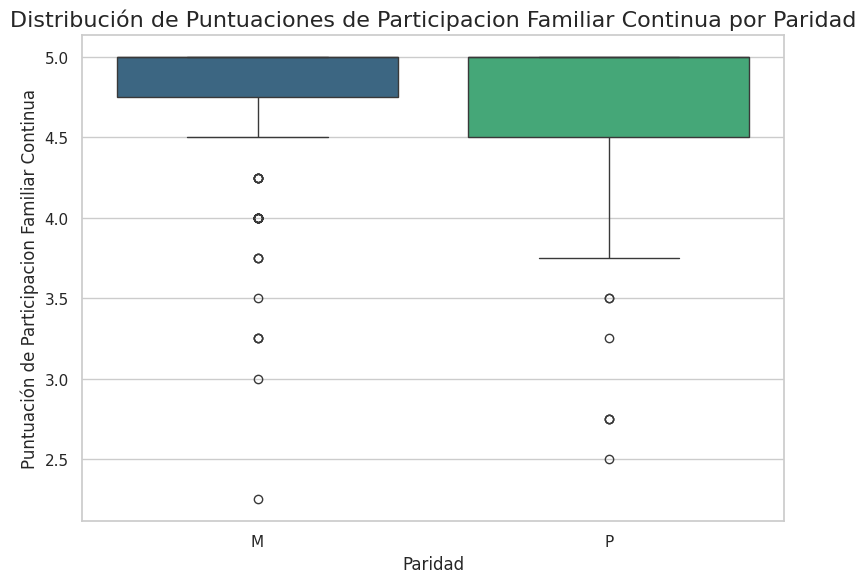

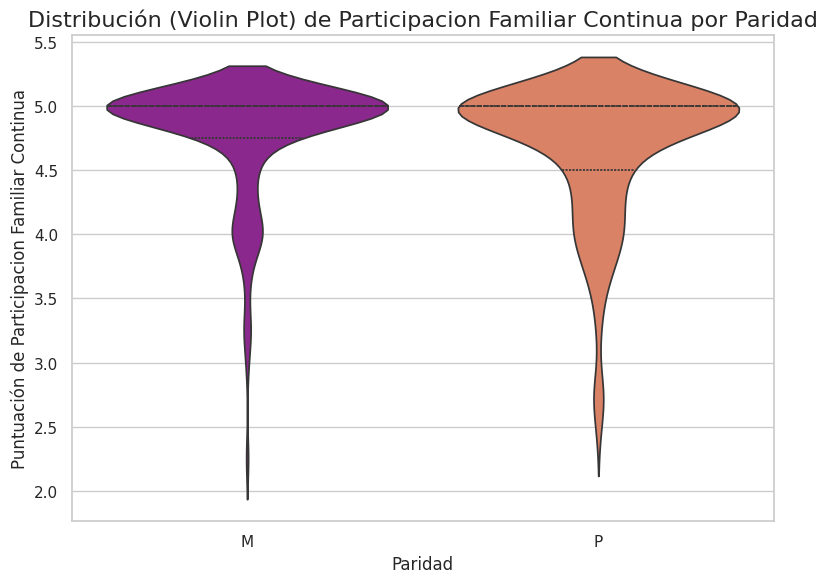

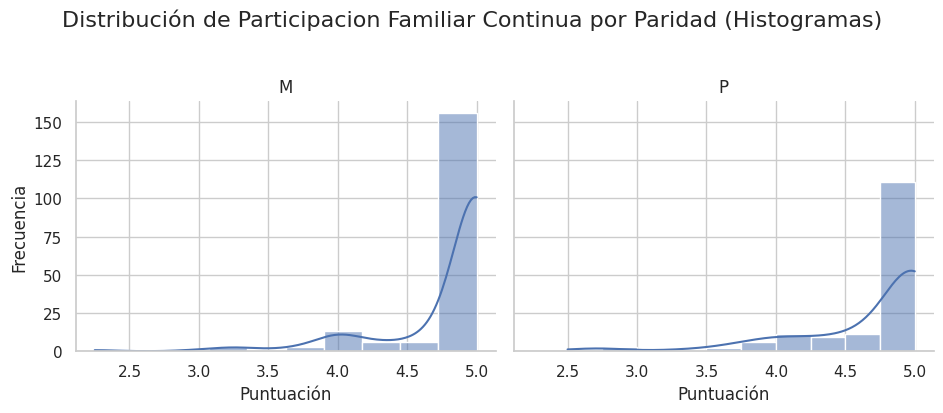

In [108]:
# 2. Visualización de la Distribución de 'Score_Participacion_familiar_continua' por 'Paridad'
print("\nVisualizando la Distribución de 'Participacion Familiar Continua' por Paridad:")

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
        x='Paridad',
        y='Score_Participacion_familiar_continua',
        data=df, palette='viridis',
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Participacion Familiar Continua por Paridad', fontsize=16)
plt.ylabel('Puntuación de Participacion Familiar Continua', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(
        x='Paridad',
        y='Score_Participacion_familiar_continua',
        data=df, palette='plasma',
        inner="quartile",
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Participacion Familiar Continua por Paridad', fontsize=16)
plt.ylabel('Puntuación de Participacion Familiar Continua', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df, col="Paridad", col_wrap=2, height=4, aspect=1.2)
g.map(sns.histplot, 'Score_Participacion_familiar_continua', kde=True, bins=10)
g.fig.suptitle('Distribución de Participacion Familiar Continua por Paridad (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [109]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
print("\n--- Evaluación de Supuestos para Análisis Inferencial ---")

# b) Normalidad dentro de cada grupo
print("\nPrueba de Normalidad de 'Participacion_familiar_continua' dentro de cada grupo de Paridad:")
paridad_groups_participacion_continua = df.groupby('Paridad')['Score_Participacion_familiar_continua']

normalidad_results_participacion_continua = {}
for name, group in paridad_groups_participacion_continua:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_participacion_continua[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_participacion_continua[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_participacion_continua = pd.DataFrame(normalidad_results_participacion_continua).T
display(normalidad_df_participacion_continua.style
    .set_caption("Normalidad de 'Participacion Familiar Continua' por Grupo (Shapiro-Wilk)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")

# c) Homogeneidad de Varianzas (Levene's Test)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

group_data_participacion_continua = [group.dropna().values for name, group in paridad_groups_participacion_continua]

if all(len(g) > 0 for g in group_data_participacion_continua) and len(group_data_participacion_continua) == 2:
    stat_levene_participacion_continua, p_value_levene_participacion_continua = stats.levene(*group_data_participacion_continua)
    print(f"Estadístico de Levene: {stat_levene_participacion_continua:.4f}")
    print(f"Valor p: {p_value_levene_participacion_continua:.4f}")

    if p_value_levene_participacion_continua < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
    print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial ---

Prueba de Normalidad de 'Participacion_familiar_continua' dentro de cada grupo de Paridad:


,Shapiro-Wilk p-value,N
M,0.0000,190
P,0.0000,155



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 4.3954
Valor p: 0.0368
Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.
Si se usa T-test, se debería aplicar la corrección de Welch.


In [110]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos
group1_data_paridad_pf = df[df['Paridad'] == 'P']['Score_Participacion_familiar_continua'].dropna()
group2_data_paridad_pf = df[df['Paridad'] == 'M']['Score_Participacion_familiar_continua'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_paridad_pf) > 0 and len(group2_data_paridad_pf) > 0:
    stat_mw_participacion_familiar_continua_paridad, p_value_mw_participacion_familiar_continua_paridad = stats.mannwhitneyu(group1_data_paridad_pf, group2_data_paridad_pf, alternative='two-sided')
    print(f"Estadístico de Mann-Whitney U: {stat_mw_participacion_familiar_continua_paridad:.4f}")
    print(f"Valor p: {p_value_mw_participacion_familiar_continua_paridad:.4f}")

    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_participacion_familiar_continua_paridad < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Participacion_familiar_continua' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Participacion_familiar_continua' según la paridad.")
        print(f"La mediana para Primíparas (P) es {group1_data_paridad_pf.median():.2f} y para Multíparas (M) es {group2_data_paridad_pf.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Participacion_familiar_continua' entre Primíparas y Multíparas.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('P', 'M') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_paridad_pf) > 1 and len(group2_data_paridad_pf) > 1:
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_participacion_continua_paridad = True # Default to True, but check Levene's result
    if 'p_value_levene_participacion_continua' in locals() and not np.isnan(p_value_levene_participacion_continua) and p_value_levene_participacion_continua < 0.05:
        use_equal_var_participacion_continua_paridad = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")

    stat_ttest_participacion_familiar_continua_paridad, p_value_ttest_participacion_familiar_continua_paridad = stats.ttest_ind(group1_data_paridad_pf, group2_data_paridad_pf, equal_var=use_equal_var_participacion_continua_paridad)
    print(f"Estadístico T: {stat_ttest_participacion_familiar_continua_paridad:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_participacion_familiar_continua_paridad:.4f}")

    # Interpretación del resultado del T-test
    if p_value_ttest_participacion_familiar_continua_paridad < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Participacion_familiar_continua' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Score_Participacion_familiar_continua' según la paridad.")
        print(f"La media para Primíparas (P) es {group1_data_paridad_pf.mean():.2f} y para Multíparas (M) es {group2_data_paridad_pf.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Score_Participacion_familiar_continua' entre Primíparas y Multíparas.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 12638.0000
Valor p: 0.0066

Conclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medianas de 'Participacion_familiar_continua' son iguales entre Primíparas (P) y Multíparas (M).
Existe una diferencia estadísticamente significativa en la puntuación de 'Participacion_familiar_continua' según la paridad.
La mediana para Primíparas (P) es 5.00 y para Multíparas (M) es 5.00.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.
Estadístico T: -2.0638
Valor p (T-test): 0.0399

Conclusión (T-test): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nu

In [111]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

# Verificar si hay datos suficientes para ambos grupos de paridad
if len(df['Paridad'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    # Usar pingouin para realizar el test de Mann-Whitney U y obtener el tamaño del efecto
    mw_effect_size_participacion_continua_paridad = pg.mwu(
        x=df[df['Paridad'] == 'P']['Score_Participacion_familiar_continua'].dropna(),
        y=df[df['Paridad'] == 'M']['Score_Participacion_familiar_continua'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_participacion_continua_paridad.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Extraer el valor del tamaño del efecto y manejar nombres de columnas según versión de pingouin
    effect_size_value_participacion_continua_paridad = mw_effect_size_participacion_continua_paridad['RBC'].iloc[0]
    p_col = 'p-val' if 'p-val' in mw_effect_size_participacion_continua_paridad.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_participacion_continua_paridad.columns else 'U_val'

    p_value_participacion_continua_paridad_pg = mw_effect_size_participacion_continua_paridad[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_participacion_continua_paridad[u_col].iloc[0]:.4f}")
    print(f"Valor p (Pingouin): {p_value_participacion_continua_paridad_pg:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_participacion_continua_paridad:.4f}")

    abs_effect_size_participacion_continua_paridad = abs(effect_size_value_participacion_continua_paridad)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_participacion_continua_paridad >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_participacion_continua_paridad:.2f}) es grande.")
    elif abs_effect_size_participacion_continua_paridad >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_participacion_continua_paridad:.2f}) es mediano.")
    elif abs_effect_size_participacion_continua_paridad >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_participacion_continua_paridad:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_participacion_continua_paridad:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_participacion_continua_paridad_pg < 0.05:
         print(f"- La diferencia en las medianas es estadísticamente significativa (p={p_value_participacion_continua_paridad_pg:.4f}).")
         effect_size_interpretation_pf_paridad = 'muy pequeña' if abs_effect_size_participacion_continua_paridad < 0.10 else ('pequeña' if abs_effect_size_participacion_continua_paridad < 0.30 else ('mediana' if abs_effect_size_participacion_continua_paridad < 0.50 else 'grande'))
         print(f"- El tamaño del efecto sugiere una magnitud {effect_size_interpretation_pf_paridad}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_participacion_continua_paridad_pg:.4f}) no encontró una diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:


,U_val,alternative,p_val,RBC,CLES
MWU,12638.000000,two-sided,0.006580,-0.141732,0.429134



Estadístico de Mann-Whitney U: 12638.0000
Valor p (Pingouin): 0.0066
Tamaño del Efecto (Rank-Biserial r): -0.1417

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.14) es pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La diferencia en las medianas es estadísticamente significativa (p=0.0066).
- El tamaño del efecto sugiere una magnitud pequeña.


In [112]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Participacion_familiar_continua' por Paridad ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Participacion_familiar_continua' entre Primíparas (P) y Multíparas (M).")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test for Parity
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_participacion_familiar_continua_paridad' in locals() and not np.isnan(p_value_mw_participacion_familiar_continua_paridad):
    if p_value_mw_participacion_familiar_continua_paridad < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_participacion_familiar_continua_paridad:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Participacion_familiar_continua' entre Primíparas y Multíparas.")
        print(f"  Esto sugiere que la percepción de 'Participacion_familiar_continua' difiere significativamente según si la mujer es primeriza o no.")
        print(f"  Mediana Primíparas (P): {group1_data_paridad_pf.median():.2f}, Mediana Multíparas (M): {group2_data_paridad_pf.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_participacion_familiar_continua_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Participacion_familiar_continua' entre Primíparas y Multíparas basado en esta prueba no paramétrica.")
elif 'p_value_ttest_participacion_familiar_continua_paridad' in locals() and not np.isnan(p_value_ttest_participacion_familiar_continua_paridad):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_participacion_familiar_continua_paridad < 0.05:
         print(f"- La prueba T ({p_value_ttest_participacion_familiar_continua_paridad:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Participacion_familiar_continua' entre Primíparas y Multíparas.")
         print(f"  Esto sugiere que la percepción de 'Participacion_familiar_continua' difiere significativamente según si la mujer es primeriza o no.")
         print(f"  Media Primíparas (P): {group1_data_paridad_pf.mean():.2f}, Media Multíparas (M): {group2_data_paridad_pf.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_participacion_familiar_continua_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Participacion_familiar_continua' entre Primíparas y Multíparas basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\nResultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):")
if 'abs_effect_size_participacion_continua_paridad' in locals() and not np.isnan(abs_effect_size_participacion_continua_paridad):
    effect_size_interpretation_pf_paridad = 'muy pequeña' if abs_effect_size_participacion_continua_paridad < 0.10 else ('pequeña' if abs_effect_size_participacion_continua_paridad < 0.30 else ('mediana' if abs_effect_size_participacion_continua_paridad < 0.50 else 'grande'))
    print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_participacion_continua_paridad:.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_pf_paridad}.")
    print("  Considerar la relevancia práctica de esta magnitud junto con la significancia estadística.")
else:
     print("- No se pudo calcular el tamaño del efecto.")

print("\nRecomendaciones Adicionales para 'Participacion_familiar_continua' por Paridad:")
print("- Si se encontró una diferencia significativa, investigar si Primíparas o Multíparas tienen expectativas o necesidades diferentes respecto a la participación familiar continua durante el parto y el postparto.")
print("- Evaluar si el apoyo familiar durante el proceso es percibido de manera distinta (ej. la pareja o familiares presentes, su rol y apoyo) por primíparas vs. multíparas.")
print("- Considerar si la experiencia previa influye en la forma en que se percibe y valora la participación familiar.")
print("- Utilizar estos hallazgos para adaptar las estrategias de fomento y apoyo a la participación familiar, asegurando que respondan a las necesidades específicas de las mujeres según su paridad.")

print("\n--- Fin del Análisis de 'Participacion_familiar_continua' según Paridad ---")


--- Conclusiones del Análisis 'Participacion_familiar_continua' por Paridad ---
- Se realizó el análisis comparando las puntuaciones de 'Participacion_familiar_continua' entre Primíparas (P) y Multíparas (M).
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0066) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Participacion_familiar_continua' entre Primíparas y Multíparas.
  Esto sugiere que la percepción de 'Participacion_familiar_continua' difiere significativamente según si la mujer es primeriza o no.
  Mediana Primíparas (P): 5.00, Mediana Multíparas (M): 5.00.

Resultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):
- El tamaño del efecto Rank-Biserial r (0.14) sugiere una

### 6.3.4 Análisis por Dimensión (Cuidado_oportuno_respetuoso) sugún Paridad ❌

In [113]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.1.8 pero esta vez con la dimensión Cuidado_oportuno_respetuoso según paridad, entendiendo que paridad es una variable que separa la muestra en 2 (P para primiparas y M para multiparas)

# ### 6.3.4 Análisis por Dimensión (Cuidado_oportuno_respetuoso) sugún Paridad

print("\n--- Análisis Específico: Puntuación de 'Cuidado_oportuno_respetuoso' según Paridad ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_oportuno_respetuoso' por 'Paridad'
print("\nEstadísticas Descriptivas para 'Cuidado_oportuno_respetuoso' por Paridad:")
paridad_cuidado_oportuno_respetuoso_stats = df.groupby('Paridad')['Score_Cuidado_oportuno_respetuoso'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(paridad_cuidado_oportuno_respetuoso_stats.style
        .set_caption("Estadísticas Descriptivas de 'Cuidado Oportuno Respetuoso' por Paridad")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos ('P', 'M').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")



--- Análisis Específico: Puntuación de 'Cuidado_oportuno_respetuoso' según Paridad ---

Estadísticas Descriptivas para 'Cuidado_oportuno_respetuoso' por Paridad:


Paridad,M,P
count,190.00,155.00
mean,4.75,4.68
median,5.00,4.83
std,0.40,0.49
min,2.83,2.50
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos ('P', 'M').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Oportuno Respetuoso' por Paridad:


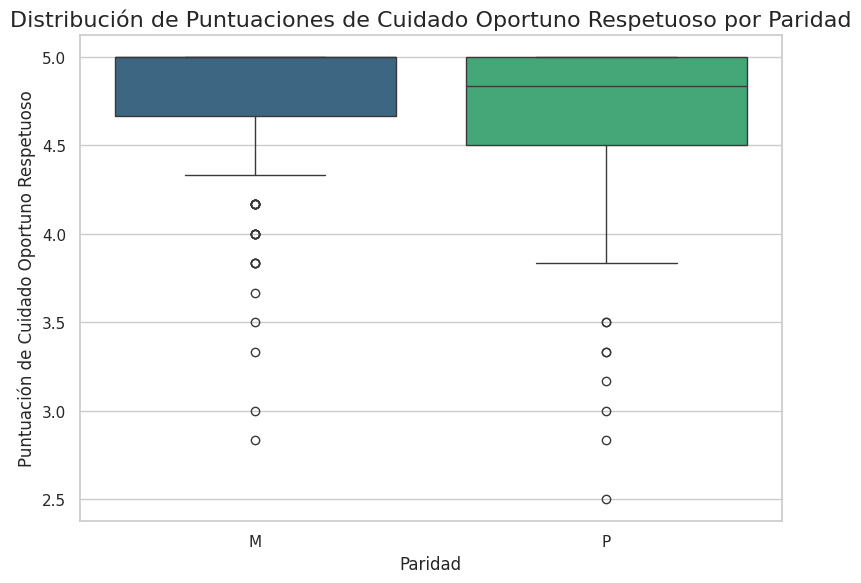

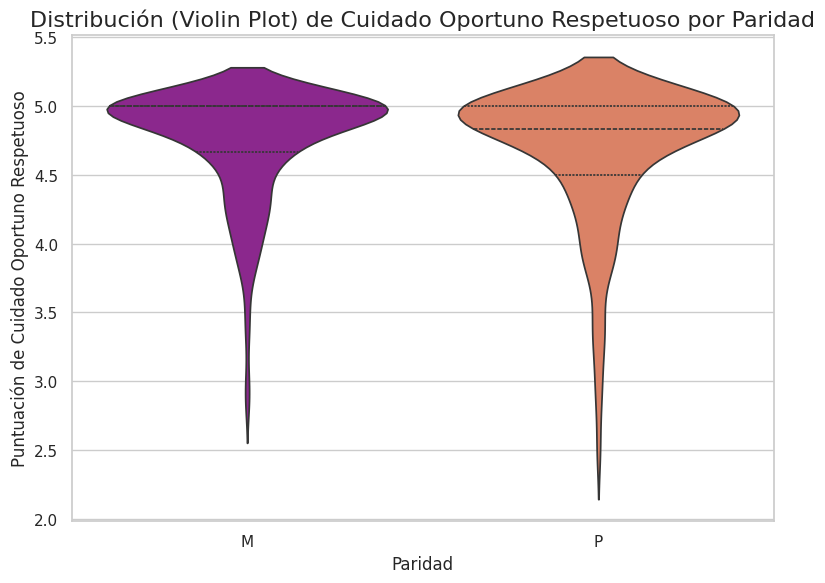

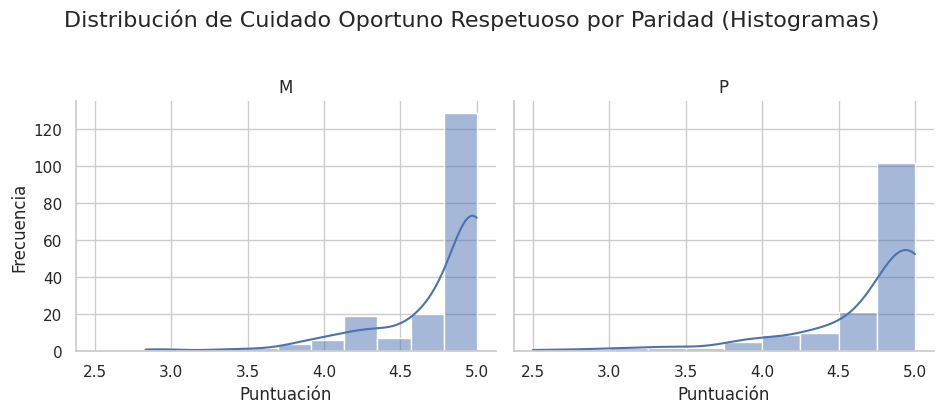

In [114]:
# 2. Visualización de la Distribución de 'Score_Cuidado_oportuno_respetuoso' por 'Paridad'
print("\nVisualizando la Distribución de 'Cuidado Oportuno Respetuoso' por Paridad:")

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
        x='Paridad',
        y='Score_Cuidado_oportuno_respetuoso',
        data=df, palette='viridis',
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Cuidado Oportuno Respetuoso por Paridad', fontsize=16)
plt.ylabel('Puntuación de Cuidado Oportuno Respetuoso', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(
        x='Paridad',
        y='Score_Cuidado_oportuno_respetuoso',
        data=df, palette='plasma',
        inner="quartile",
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Cuidado Oportuno Respetuoso por Paridad', fontsize=16)
plt.ylabel('Puntuación de Cuidado Oportuno Respetuoso', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df, col="Paridad", col_wrap=2, height=4, aspect=1.2)
g.map(sns.histplot, 'Score_Cuidado_oportuno_respetuoso', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Oportuno Respetuoso por Paridad (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [115]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
print("\n--- Evaluación de Supuestos para Análisis Inferencial ---")

# b) Normalidad dentro de cada grupo
print("\nPrueba de Normalidad de 'Cuidado_oportuno_respetuoso' dentro de cada grupo de Paridad:")
paridad_groups_cuidado_oportuno_respetuoso = df.groupby('Paridad')['Score_Cuidado_oportuno_respetuoso']

normalidad_results_cuidado_oportuno_respetuoso = {}
for name, group in paridad_groups_cuidado_oportuno_respetuoso:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_cuidado_oportuno_respetuoso[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_cuidado_oportuno_respetuoso[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_cuidado_oportuno_respetuoso = pd.DataFrame(normalidad_results_cuidado_oportuno_respetuoso).T
display(normalidad_df_cuidado_oportuno_respetuoso.style
    .set_caption("Normalidad de 'Cuidado Oportuno Respetuoso' por Grupo (Shapiro-Wilk)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")

# c) Homogeneidad de Varianzas (Levene's Test)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

group_data_cuidado_oportuno_respetuoso = [group.dropna().values for name, group in paridad_groups_cuidado_oportuno_respetuoso]

if all(len(g) > 0 for g in group_data_cuidado_oportuno_respetuoso) and len(group_data_cuidado_oportuno_respetuoso) == 2:
    stat_levene_cuidado_oportuno_respetuoso, p_value_levene_cuidado_oportuno_respetuoso = stats.levene(*group_data_cuidado_oportuno_respetuoso)
    print(f"Estadístico de Levene: {stat_levene_cuidado_oportuno_respetuoso:.4f}")
    print(f"Valor p: {p_value_levene_cuidado_oportuno_respetuoso:.4f}")

    if p_value_levene_cuidado_oportuno_respetuoso < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
    print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial ---

Prueba de Normalidad de 'Cuidado_oportuno_respetuoso' dentro de cada grupo de Paridad:


,Shapiro-Wilk p-value,N
M,0.0000,190
P,0.0000,155



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 1.4086
Valor p: 0.2361
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa T-test, se puede asumir igualdad de varianzas.


In [116]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos
group1_data_paridad_cor = df[df['Paridad'] == 'P']['Score_Cuidado_oportuno_respetuoso'].dropna()
group2_data_paridad_cor = df[df['Paridad'] == 'M']['Score_Cuidado_oportuno_respetuoso'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_paridad_cor) > 0 and len(group2_data_paridad_cor) > 0:
    stat_mw_cuidado_oportuno_respetuoso_paridad, p_value_mw_cuidado_oportuno_respetuoso_paridad = stats.mannwhitneyu(group1_data_paridad_cor, group2_data_paridad_cor, alternative='two-sided')
    print(f"Estadístico de Mann-Whitney U: {stat_mw_cuidado_oportuno_respetuoso_paridad:.4f}")
    print(f"Valor p: {p_value_mw_cuidado_oportuno_respetuoso_paridad:.4f}")

    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_cuidado_oportuno_respetuoso_paridad < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Cuidado_oportuno_respetuoso' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_oportuno_respetuoso' según la paridad.")
        print(f"La mediana para Primíparas (P) es {group1_data_paridad_cor.median():.2f} y para Multíparas (M) es {group2_data_paridad_cor.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_oportuno_respetuoso' entre Primíparas y Multíparas.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('P', 'M') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_paridad_cor) > 1 and len(group2_data_paridad_cor) > 1:
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_cuidado_oportuno_respetuoso_paridad = True # Default to True, but check Levene's result
    if 'p_value_levene_cuidado_oportuno_respetuoso' in locals() and not np.isnan(p_value_levene_cuidado_oportuno_respetuoso) and p_value_levene_cuidado_oportuno_respetuoso < 0.05:
        use_equal_var_cuidado_oportuno_respetuoso_paridad = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")

    stat_ttest_cuidado_oportuno_respetuoso_paridad, p_value_ttest_cuidado_oportuno_respetuoso_paridad = stats.ttest_ind(group1_data_paridad_cor, group2_data_paridad_cor, equal_var=use_equal_var_cuidado_oportuno_respetuoso_paridad)
    print(f"Estadístico T: {stat_ttest_cuidado_oportuno_respetuoso_paridad:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_cuidado_oportuno_respetuoso_paridad:.4f}")

    # Interpretación del resultado del T-test
    if p_value_ttest_cuidado_oportuno_respetuoso_paridad < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Cuidado_oportuno_respetuoso' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Score_Cuidado_oportuno_respetuoso' según la paridad.")
        print(f"La media para Primíparas (P) es {group1_data_paridad_cor.mean():.2f} y para Multíparas (M) es {group2_data_paridad_cor.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Score_Cuidado_oportuno_respetuoso' entre Primíparas y Multíparas.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 13606.5000
Valor p: 0.1928

Conclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_oportuno_respetuoso' entre Primíparas y Multíparas.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico T: -1.3798
Valor p (T-test): 0.1686

Conclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticam

In [117]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

# Verificar si hay datos suficientes para ambos grupos de paridad
if len(df['Paridad'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    # Usar pingouin para realizar el test de Mann-Whitney U y obtener el tamaño del efecto
    mw_effect_size_cuidado_oportuno_respetuoso_paridad = pg.mwu(
        x=df[df['Paridad'] == 'P']['Score_Cuidado_oportuno_respetuoso'].dropna(),
        y=df[df['Paridad'] == 'M']['Score_Cuidado_oportuno_respetuoso'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_cuidado_oportuno_respetuoso_paridad.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Extraer el valor del tamaño del efecto y manejar nombres de columnas según versión de pingouin
    effect_size_value_cuidado_oportuno_respetuoso_paridad = mw_effect_size_cuidado_oportuno_respetuoso_paridad['RBC'].iloc[0]
    p_col = 'p-val' if 'p-val' in mw_effect_size_cuidado_oportuno_respetuoso_paridad.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_cuidado_oportuno_respetuoso_paridad.columns else 'U_val'

    p_value_cuidado_oportuno_respetuoso_paridad_pg = mw_effect_size_cuidado_oportuno_respetuoso_paridad[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_cuidado_oportuno_respetuoso_paridad[u_col].iloc[0]:.4f}")
    print(f"Valor p (Pingouin): {p_value_cuidado_oportuno_respetuoso_paridad_pg:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_cuidado_oportuno_respetuoso_paridad:.4f}")

    abs_effect_size_cuidado_oportuno_respetuoso_paridad = abs(effect_size_value_cuidado_oportuno_respetuoso_paridad)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_cuidado_oportuno_respetuoso_paridad >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_cuidado_oportuno_respetuoso_paridad:.2f}) es grande.")
    elif abs_effect_size_cuidado_oportuno_respetuoso_paridad >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_cuidado_oportuno_respetuoso_paridad:.2f}) es mediano.")
    elif abs_effect_size_cuidado_oportuno_respetuoso_paridad >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_cuidado_oportuno_respetuoso_paridad:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_cuidado_oportuno_respetuoso_paridad:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_cuidado_oportuno_respetuoso_paridad_pg < 0.05:
         print(f"- La diferencia en las medianas es significativa (p={p_value_cuidado_oportuno_respetuoso_paridad_pg:.4f}).")
         effect_size_interpretation_cor_paridad = 'muy pequeña' if abs_effect_size_cuidado_oportuno_respetuoso_paridad < 0.10 else ('pequeña' if abs_effect_size_cuidado_oportuno_respetuoso_paridad < 0.30 else ('mediana' if abs_effect_size_cuidado_oportuno_respetuoso_paridad < 0.50 else 'grande'))
         print(f"- El tamaño del efecto sugiere una magnitud {effect_size_interpretation_cor_paridad}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_cuidado_oportuno_respetuoso_paridad_pg:.4f}) no encontró una diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:


,U_val,alternative,p_val,RBC,CLES
MWU,13606.500000,two-sided,0.192805,-0.075959,0.462020



Estadístico de Mann-Whitney U: 13606.5000
Valor p (Pingouin): 0.1928
Tamaño del Efecto (Rank-Biserial r): -0.0760

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.08) es muy pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La prueba de Mann-Whitney U (0.1928) no encontró una diferencia significativa.


In [118]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Cuidado_oportuno_respetuoso' por Paridad ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Cuidado_oportuno_respetuoso' entre Primíparas (P) y Multíparas (M).")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test for Parity
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_cuidado_oportuno_respetuoso_paridad' in locals() and not np.isnan(p_value_mw_cuidado_oportuno_respetuoso_paridad):
    if p_value_mw_cuidado_oportuno_respetuoso_paridad < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_oportuno_respetuoso_paridad:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Cuidado_oportuno_respetuoso' entre Primíparas y Multíparas.")
        print(f"  Esto sugiere que la percepción de 'Cuidado_oportuno_respetuoso' difiere significativamente según si la mujer es primeriza o no.")
        print(f"  Mediana Primíparas (P): {group1_data_paridad_cor.median():.2f}, Mediana Multíparas (M): {group2_data_paridad_cor.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_cuidado_oportuno_respetuoso_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_oportuno_respetuoso' entre Primíparas y Multíparas basado en esta prueba no paramétrica.")
elif 'p_value_ttest_cuidado_oportuno_respetuoso_paridad' in locals() and not np.isnan(p_value_ttest_cuidado_oportuno_respetuoso_paridad):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_cuidado_oportuno_respetuoso_paridad < 0.05:
         print(f"- La prueba T ({p_value_ttest_cuidado_oportuno_respetuoso_paridad:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Cuidado_oportuno_respetuoso' entre Primíparas y Multíparas.")
         print(f"  Esto sugiere que la percepción de 'Cuidado_oportuno_respetuoso' difiere significativamente según si la mujer es primeriza o no.")
         print(f"  Media Primíparas (P): {group1_data_paridad_cor.mean():.2f}, Media Multíparas (M): {group2_data_paridad_cor.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_cuidado_oportuno_respetuoso_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_oportuno_respetuoso' entre Primíparas y Multíparas basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\nResultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):")
if 'abs_effect_size_cuidado_oportuno_respetuoso_paridad' in locals() and not np.isnan(abs_effect_size_cuidado_oportuno_respetuoso_paridad):
    effect_size_interpretation_cor_paridad = 'muy pequeña' if abs_effect_size_cuidado_oportuno_respetuoso_paridad < 0.10 else ('pequeña' if abs_effect_size_cuidado_oportuno_respetuoso_paridad < 0.30 else ('mediana' if abs_effect_size_cuidado_oportuno_respetuoso_paridad < 0.50 else 'grande'))
    print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_cuidado_oportuno_respetuoso_paridad:.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_cor_paridad}.")
    print("  Considerar la relevancia práctica de esta magnitud junto con la significancia estadística.")
else:
     print("- No se pudo calcular el tamaño del efecto.")

print("\nRecomendaciones Adicionales para 'Cuidado_oportuno_respetuoso' por Paridad:")
print("- Si se encontró una diferencia significativa, investigar los aspectos específicos del cuidado (puntualidad, información, respeto a decisiones) que difieren entre Primíparas y Multíparas.")
print("- Evaluar si las expectativas sobre el tiempo de espera, la comunicación de información o el respeto a la autonomía varían con la experiencia previa de parto.")
print("- Considerar si las Multíparas, al tener experiencia previa, tienen percepciones diferentes sobre la eficiencia y el respeto en comparación con las Primíparas.")
print("- Utilizar estos hallazgos para adaptar los protocolos de atención y la comunicación para mejorar la percepción de cuidado oportuno y respetuoso para todas las mujeres, considerando sus diferentes niveles de experiencia.")

print("\n--- Fin del Análisis de 'Cuidado_oportuno_respetuoso' según Paridad ---")


--- Conclusiones del Análisis 'Cuidado_oportuno_respetuoso' por Paridad ---
- Se realizó el análisis comparando las puntuaciones de 'Cuidado_oportuno_respetuoso' entre Primíparas (P) y Multíparas (M).
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.1928) no encontró una diferencia estadísticamente significativa en las medianas.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_oportuno_respetuoso' entre Primíparas y Multíparas basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):
- El tamaño del efecto Rank-Biserial r (0.08) sugiere una magnitud de la diferencia muy pequeña.
  Considerar la relevancia práctica de

### 6.3.5 Análisis por Dimensión (Ambiente_fisico_confortable) sugún Paridad ❌

In [119]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.1.8 pero esta vez con la dimensión Ambiente_fisico_confortable según paridad, entendiendo que paridad es una variable que separa la muestra en 2 (P para primiparas y M para multiparas)

# ### 6.3.5 Análisis por Dimensión (Ambiente_fisico_confortable) según Paridad

print("\n--- Análisis Específico: Puntuación de 'Ambiente_fisico_confortable' según Paridad ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Ambiente_fisico_confortable' por 'Paridad'
print("\nEstadísticas Descriptivas para 'Ambiente_fisico_confortable' por Paridad:")
paridad_ambiente_stats = df.groupby('Paridad')['Score_Ambiente_fisico_confortable'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(paridad_ambiente_stats.style
        .set_caption("Estadísticas Descriptivas de 'Ambiente Físico Confortable' por Paridad")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos ('P', 'M').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")



--- Análisis Específico: Puntuación de 'Ambiente_fisico_confortable' según Paridad ---

Estadísticas Descriptivas para 'Ambiente_fisico_confortable' por Paridad:


Paridad,M,P
count,190.00,155.00
mean,4.83,4.75
median,5.00,5.00
std,0.30,0.41
min,3.60,2.80
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos ('P', 'M').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Ambiente Físico Confortable' por Paridad:


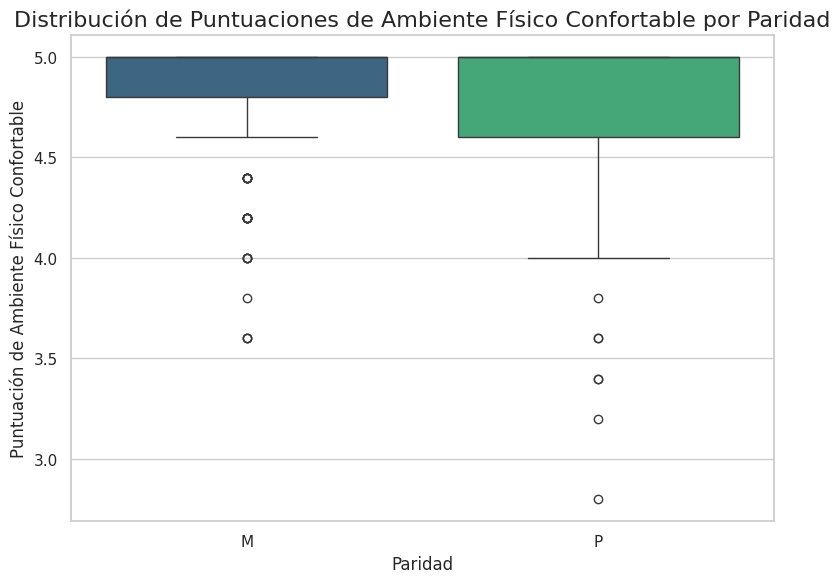

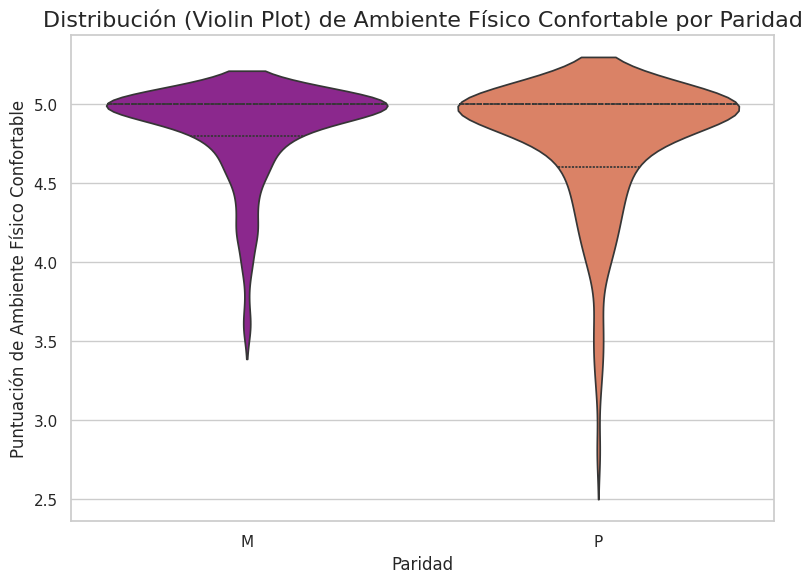

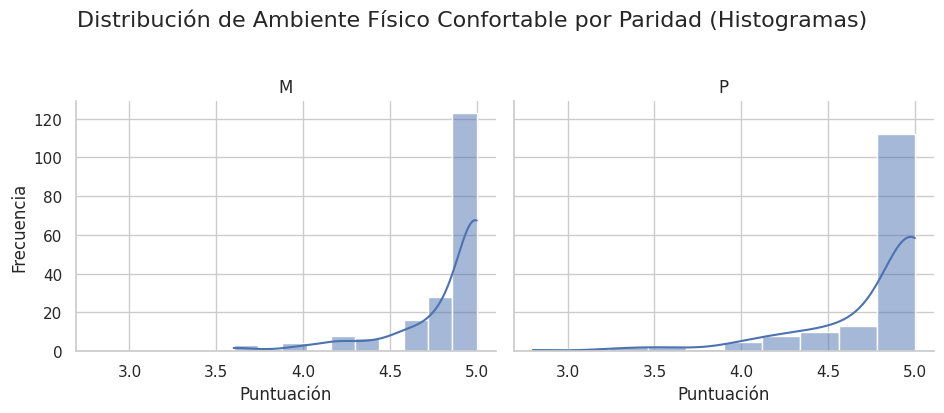

In [120]:
# 2. Visualización de la Distribución de 'Score_Ambiente_fisico_confortable' por 'Paridad'
print("\nVisualizando la Distribución de 'Ambiente Físico Confortable' por Paridad:")

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
        x='Paridad',
        y='Score_Ambiente_fisico_confortable',
        data=df, palette='viridis',
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Ambiente Físico Confortable por Paridad', fontsize=16)
plt.ylabel('Puntuación de Ambiente Físico Confortable', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(
        x='Paridad',
        y='Score_Ambiente_fisico_confortable',
        data=df, palette='plasma',
        inner="quartile",
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Ambiente Físico Confortable por Paridad', fontsize=16)
plt.ylabel('Puntuación de Ambiente Físico Confortable', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df, col="Paridad", col_wrap=2, height=4, aspect=1.2)
g.map(sns.histplot, 'Score_Ambiente_fisico_confortable', kde=True, bins=10)
g.fig.suptitle('Distribución de Ambiente Físico Confortable por Paridad (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [121]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
print("\n--- Evaluación de Supuestos para Análisis Inferencial ---")

# b) Normalidad dentro de cada grupo
print("\nPrueba de Normalidad de 'Ambiente_fisico_confortable' dentro de cada grupo de Paridad:")
paridad_groups_ambiente = df.groupby('Paridad')['Score_Ambiente_fisico_confortable']

normalidad_results_ambiente = {}
for name, group in paridad_groups_ambiente:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_ambiente[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_ambiente[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_ambiente = pd.DataFrame(normalidad_results_ambiente).T
display(normalidad_df_ambiente.style
    .set_caption("Normalidad de 'Ambiente Físico Confortable' por Grupo (Shapiro-Wilk)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")

# c) Homogeneidad de Varianzas (Levene's Test)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

group_data_ambiente = [group.dropna().values for name, group in paridad_groups_ambiente]

if all(len(g) > 0 for g in group_data_ambiente) and len(group_data_ambiente) == 2:
    stat_levene_ambiente, p_value_levene_ambiente = stats.levene(*group_data_ambiente)
    print(f"Estadístico de Levene: {stat_levene_ambiente:.4f}")
    print(f"Valor p: {p_value_levene_ambiente:.4f}")

    if p_value_levene_ambiente < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
    print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial ---

Prueba de Normalidad de 'Ambiente_fisico_confortable' dentro de cada grupo de Paridad:


,Shapiro-Wilk p-value,N
M,0.0000,190
P,0.0000,155



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 4.1386
Valor p: 0.0427
Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.
Si se usa T-test, se debería aplicar la corrección de Welch.


In [122]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos
group1_data_paridad_ambiente = df[df['Paridad'] == 'P']['Score_Ambiente_fisico_confortable'].dropna()
group2_data_paridad_ambiente = df[df['Paridad'] == 'M']['Score_Ambiente_fisico_confortable'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_paridad_ambiente) > 0 and len(group2_data_paridad_ambiente) > 0:
    stat_mw_ambiente_fisico_confortable_paridad, p_value_mw_ambiente_fisico_confortable_paridad = stats.mannwhitneyu(group1_data_paridad_ambiente, group2_data_paridad_ambiente, alternative='two-sided')
    print(f"Estadístico de Mann-Whitney U: {stat_mw_ambiente_fisico_confortable_paridad:.4f}")
    print(f"Valor p: {p_value_mw_ambiente_fisico_confortable_paridad:.4f}")

    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_ambiente_fisico_confortable_paridad < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Ambiente_fisico_confortable' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente_fisico_confortable' según la paridad.")
        print(f"La mediana para Primíparas (P) es {group1_data_paridad_ambiente.median():.2f} y para Multíparas (M) es {group2_data_paridad_ambiente.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente_fisico_confortable' entre Primíparas y Multíparas.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('P', 'M') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_paridad_ambiente) > 1 and len(group2_data_paridad_ambiente) > 1:
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_ambiente_paridad = True # Default to True, but check Levene's result
    if 'p_value_levene_ambiente' in locals() and not np.isnan(p_value_levene_ambiente) and p_value_levene_ambiente < 0.05:
        use_equal_var_ambiente_paridad = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")

    stat_ttest_ambiente_fisico_confortable_paridad, p_value_ttest_ambiente_fisico_confortable_paridad = stats.ttest_ind(group1_data_paridad_ambiente, group2_data_paridad_ambiente, equal_var=use_equal_var_ambiente_paridad)
    print(f"Estadístico T: {stat_ttest_ambiente_fisico_confortable_paridad:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_ambiente_fisico_confortable_paridad:.4f}")

    # Interpretación del resultado del T-test
    if p_value_ttest_ambiente_fisico_confortable_paridad < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Ambiente_fisico_confortable' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Score_Ambiente_fisico_confortable' según la paridad.")
        print(f"La media para Primíparas (P) es {group1_data_paridad_ambiente.mean():.2f} y para Multíparas (M) es {group2_data_paridad_ambiente.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Score_Ambiente_fisico_confortable' entre Primíparas y Multíparas.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 13461.5000
Valor p: 0.1161

Conclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente_fisico_confortable' entre Primíparas y Multíparas.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.
Estadístico T: -1.9742
Valor p (T-test): 0.0494

Conclusión (T-test): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Ambiente_fisico_confortable' son iguales entre Primíparas (P) y Mult

In [123]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

# Verificar si hay datos suficientes para ambos grupos de paridad
if len(df['Paridad'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    # Usar pingouin para realizar el test de Mann-Whitney U y obtener el tamaño del efecto
    mw_effect_size_ambiente_paridad = pg.mwu(
        x=df[df['Paridad'] == 'P']['Score_Ambiente_fisico_confortable'].dropna(),
        y=df[df['Paridad'] == 'M']['Score_Ambiente_fisico_confortable'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_ambiente_paridad.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Extraer el valor del tamaño del efecto y manejar nombres de columnas según versión de pingouin
    effect_size_value_ambiente_paridad = mw_effect_size_ambiente_paridad['RBC'].iloc[0]
    p_col = 'p-val' if 'p-val' in mw_effect_size_ambiente_paridad.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_ambiente_paridad.columns else 'U_val'

    p_value_ambiente_paridad_pg = mw_effect_size_ambiente_paridad[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_ambiente_paridad[u_col].iloc[0]:.4f}")
    print(f"Valor p (Pingouin): {p_value_ambiente_paridad_pg:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_ambiente_paridad:.4f}")

    abs_effect_size_ambiente_paridad = abs(effect_size_value_ambiente_paridad)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_ambiente_paridad >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_ambiente_paridad:.2f}) es grande.")
    elif abs_effect_size_ambiente_paridad >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_ambiente_paridad:.2f}) es mediano.")
    elif abs_effect_size_ambiente_paridad >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_ambiente_paridad:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_ambiente_paridad:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_ambiente_paridad_pg < 0.05:
         print(f"- La diferencia en las medianas es estadísticamente significativa (p={p_value_ambiente_paridad_pg:.4f}).")
         effect_size_interpretation_ambiente_paridad = 'muy pequeña' if abs_effect_size_ambiente_paridad < 0.10 else ('pequeña' if abs_effect_size_ambiente_paridad < 0.30 else ('mediana' if abs_effect_size_ambiente_paridad < 0.50 else 'grande'))
         print(f"- El tamaño del efecto sugiere una magnitud {effect_size_interpretation_ambiente_paridad}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_ambiente_paridad_pg:.4f}) no encontró una diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:


,U_val,alternative,p_val,RBC,CLES
MWU,13461.500000,two-sided,0.116096,-0.085806,0.457097



Estadístico de Mann-Whitney U: 13461.5000
Valor p (Pingouin): 0.1161
Tamaño del Efecto (Rank-Biserial r): -0.0858

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.09) es muy pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La prueba de Mann-Whitney U (0.1161) no encontró una diferencia significativa.


In [124]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Ambiente_fisico_confortable' por Paridad ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Ambiente_fisico_confortable' entre Primíparas (P) y Multíparas (M).")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test for Parity
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_ambiente_fisico_confortable_paridad' in locals() and not np.isnan(p_value_mw_ambiente_fisico_confortable_paridad):
    if p_value_mw_ambiente_fisico_confortable_paridad < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_ambiente_fisico_confortable_paridad:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Ambiente_fisico_confortable' entre Primíparas y Multíparas.")
        print(f"  Esto sugiere que la percepción de 'Ambiente_fisico_confortable' difiere significativamente según si la mujer es primeriza o no.")
        print(f"  Mediana Primíparas (P): {group1_data_paridad_ambiente.median():.2f}, Mediana Multíparas (M): {group2_data_paridad_ambiente.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_ambiente_fisico_confortable_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Ambiente_fisico_confortable' entre Primíparas y Multíparas basado en esta prueba no paramétrica.")
elif 'p_value_ttest_ambiente_fisico_confortable_paridad' in locals() and not np.isnan(p_value_ttest_ambiente_fisico_confortable_paridad):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_ambiente_fisico_confortable_paridad < 0.05:
         print(f"- La prueba T ({p_value_ttest_ambiente_fisico_confortable_paridad:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Ambiente_fisico_confortable' entre Primíparas y Multíparas.")
         print(f"  Esto sugiere que la percepción de 'Ambiente_fisico_confortable' difiere significativamente según si la mujer es primeriza o no.")
         print(f"  Media Primíparas (P): {group1_data_paridad_ambiente.mean():.2f}, Media Multíparas (M): {group2_data_paridad_ambiente.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_ambiente_fisico_confortable_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Ambiente_fisico_confortable' entre Primíparas y Multíparas basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\nResultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):")
if 'abs_effect_size_ambiente_paridad' in locals() and not np.isnan(abs_effect_size_ambiente_paridad):
    effect_size_interpretation_ambiente_paridad = 'muy pequeña' if abs_effect_size_ambiente_paridad < 0.10 else ('pequeña' if abs_effect_size_ambiente_paridad < 0.30 else ('mediana' if abs_effect_size_ambiente_paridad < 0.50 else 'grande'))
    print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_ambiente_paridad:.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_ambiente_paridad}.")
    print("  Considerar la relevancia práctica de esta magnitud junto con la significancia estadística.")
else:
     print("- No se pudo calcular el tamaño del efecto.")

print("\nRecomendaciones Adicionales para 'Ambiente_fisico_confortable' por Paridad:")
print("- Si se encontró una diferencia significativa, investigar si las expectativas o sensibilidades sobre el ambiente físico (privacidad, limpieza, temperatura, ruido) difieren entre Primíparas y Multíparas.")
print("- Evaluar si la experiencia previa (o la falta de ella) influye en cómo se percibe el entorno físico del lugar de parto.")
print("- Considerar si las necesidades de confort y privacidad pueden variar en función de si es el primer parto o un parto subsiguiente.")
print("- Utilizar estos hallazgos para adaptar las condiciones del ambiente físico o la información proporcionada sobre el mismo, buscando mejorar la percepción de confort para todas las mujeres, teniendo en cuenta su paridad.")

print("\n--- Fin del Análisis de 'Ambiente_fisico_confortable' según Paridad ---")


--- Conclusiones del Análisis 'Ambiente_fisico_confortable' por Paridad ---
- Se realizó el análisis comparando las puntuaciones de 'Ambiente_fisico_confortable' entre Primíparas (P) y Multíparas (M).
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.1161) no encontró una diferencia estadísticamente significativa en las medianas.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Ambiente_fisico_confortable' entre Primíparas y Multíparas basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):
- El tamaño del efecto Rank-Biserial r (0.09) sugiere una magnitud de la diferencia muy pequeña.
  Considerar la relevancia práctica de

### 6.3.6 Análisis por Dimensión (Condiciones_contacto_madre_hijo) sugún Paridad ✅

In [125]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.1.8 pero esta vez con la dimensión Condiciones_contacto_madre_hijo según paridad, entendiendo que paridad es una variable que separa la muestra en 2 (P para primiparas y M para multiparas)

print("\n--- Análisis Específico: Puntuación de 'Condiciones_contacto_madre_hijo' según Paridad ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Condiciones_contacto_madre_hijo' por 'Paridad'
print("\nEstadísticas Descriptivas para 'Condiciones_contacto_madre_hijo' por Paridad:")
paridad_contacto_madre_hijo_stats = df.groupby('Paridad')['Score_Condiciones_contacto_madre_hijo'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(paridad_contacto_madre_hijo_stats.style
        .set_caption("Estadísticas Descriptivas de 'Condiciones Contacto Madre Hijo' por Paridad")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos ('P', 'M').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


--- Análisis Específico: Puntuación de 'Condiciones_contacto_madre_hijo' según Paridad ---

Estadísticas Descriptivas para 'Condiciones_contacto_madre_hijo' por Paridad:


Paridad,M,P
count,190.00,155.00
mean,4.74,4.49
median,5.00,5.00
std,0.59,0.81
min,1.00,1.00
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos ('P', 'M').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Condiciones Contacto Madre Hijo' por Paridad:


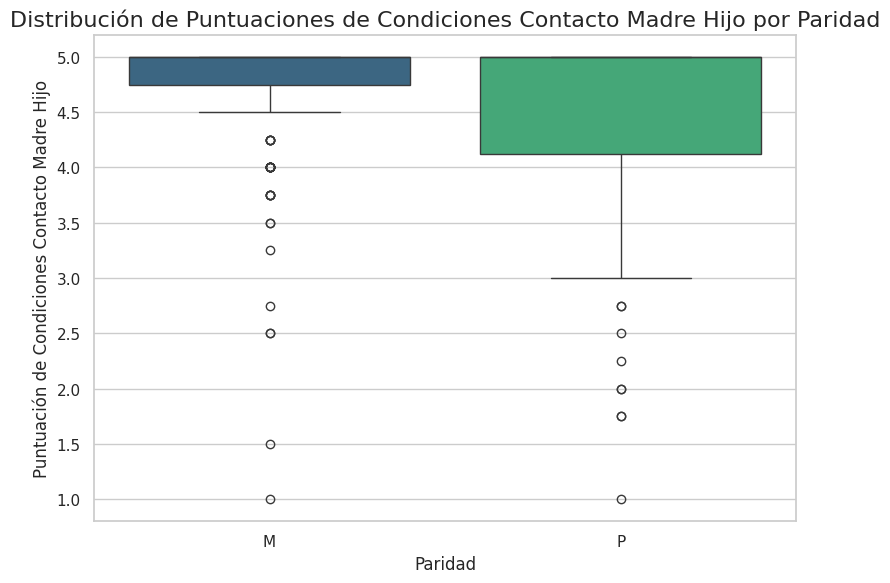

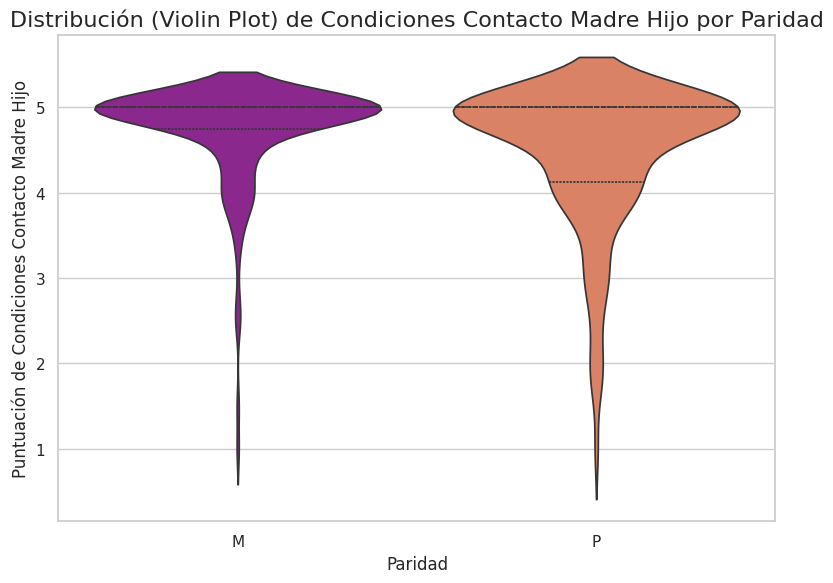

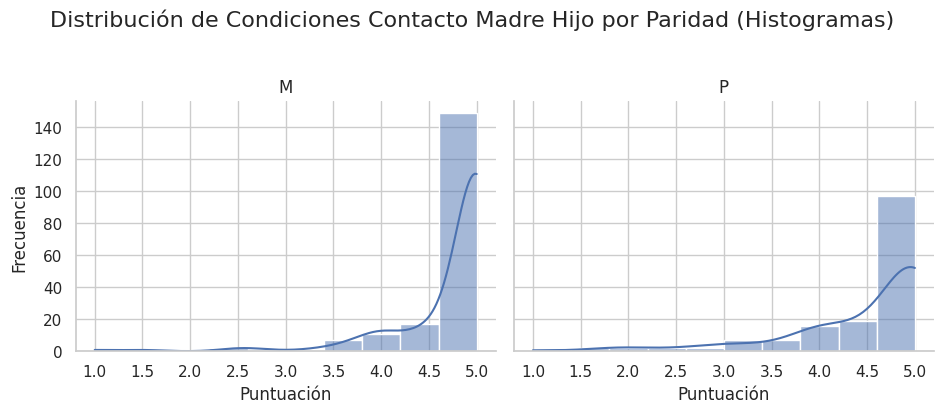

In [126]:
# 2. Visualización de la Distribución de 'Score_Condiciones_contacto_madre_hijo' por 'Paridad'
print("\nVisualizando la Distribución de 'Condiciones Contacto Madre Hijo' por Paridad:")

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
        x='Paridad',
        y='Score_Condiciones_contacto_madre_hijo',
        data=df, palette='viridis',
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Condiciones Contacto Madre Hijo por Paridad', fontsize=16)
plt.ylabel('Puntuación de Condiciones Contacto Madre Hijo', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(
        x='Paridad',
        y='Score_Condiciones_contacto_madre_hijo',
        data=df, palette='plasma',
        inner="quartile",
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Condiciones Contacto Madre Hijo por Paridad', fontsize=16)
plt.ylabel('Puntuación de Condiciones Contacto Madre Hijo', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df, col="Paridad", col_wrap=2, height=4, aspect=1.2)
g.map(sns.histplot, 'Score_Condiciones_contacto_madre_hijo', kde=True, bins=10)
g.fig.suptitle('Distribución de Condiciones Contacto Madre Hijo por Paridad (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [127]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
print("\n--- Evaluación de Supuestos para Análisis Inferencial ---")

# b) Normalidad dentro de cada grupo
print("\nPrueba de Normalidad de 'Condiciones_contacto_madre_hijo' dentro de cada grupo de Paridad:")
paridad_groups_contacto_madre_hijo = df.groupby('Paridad')['Score_Condiciones_contacto_madre_hijo']

normalidad_results_contacto_madre_hijo = {}
for name, group in paridad_groups_contacto_madre_hijo:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_contacto_madre_hijo[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_contacto_madre_hijo[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_contacto_madre_hijo = pd.DataFrame(normalidad_results_contacto_madre_hijo).T
display(normalidad_df_contacto_madre_hijo.style
    .set_caption("Normalidad de 'Condiciones Contacto Madre Hijo' por Grupo (Shapiro-Wilk)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")

# c) Homogeneidad de Varianzas (Levene's Test)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

group_data_contacto_madre_hijo = [group.dropna().values for name, group in paridad_groups_contacto_madre_hijo]

if all(len(g) > 0 for g in group_data_contacto_madre_hijo) and len(group_data_contacto_madre_hijo) == 2:
    stat_levene_contacto_madre_hijo, p_value_levene_contacto_madre_hijo = stats.levene(*group_data_contacto_madre_hijo)
    print(f"Estadístico de Levene: {stat_levene_contacto_madre_hijo:.4f}")
    print(f"Valor p: {p_value_levene_contacto_madre_hijo:.4f}")

    if p_value_levene_contacto_madre_hijo < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
    print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial ---

Prueba de Normalidad de 'Condiciones_contacto_madre_hijo' dentro de cada grupo de Paridad:


,Shapiro-Wilk p-value,N
M,0.0000,190
P,0.0000,155



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 11.3951
Valor p: 0.0008
Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.
Si se usa T-test, se debería aplicar la corrección de Welch.


In [128]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos
group1_data_paridad_cmh = df[df['Paridad'] == 'P']['Score_Condiciones_contacto_madre_hijo'].dropna()
group2_data_paridad_cmh = df[df['Paridad'] == 'M']['Score_Condiciones_contacto_madre_hijo'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_paridad_cmh) > 0 and len(group2_data_paridad_cmh) > 0:
    stat_mw_contacto_madre_hijo_paridad, p_value_mw_contacto_madre_hijo_paridad = stats.mannwhitneyu(group1_data_paridad_cmh, group2_data_paridad_cmh, alternative='two-sided')
    print(f"Estadístico de Mann-Whitney U: {stat_mw_contacto_madre_hijo_paridad:.4f}")
    print(f"Valor p: {p_value_mw_contacto_madre_hijo_paridad:.4f}")

    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_contacto_madre_hijo_paridad < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Condiciones_contacto_madre_hijo' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones_contacto_madre_hijo' según la paridad.")
        print(f"La mediana para Primíparas (P) es {group1_data_paridad_cmh.median():.2f} y para Multíparas (M) es {group2_data_paridad_cmh.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones_contacto_madre_hijo' entre Primíparas y Multíparas.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('P', 'M') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_paridad_cmh) > 1 and len(group2_data_paridad_cmh) > 1:
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_contacto_madre_hijo_paridad = True # Default to True, but check Levene's result
    if 'p_value_levene_contacto_madre_hijo' in locals() and not np.isnan(p_value_levene_contacto_madre_hijo) and p_value_levene_contacto_madre_hijo < 0.05:
        use_equal_var_contacto_madre_hijo_paridad = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")


    stat_ttest_contacto_madre_hijo_paridad, p_value_ttest_contacto_madre_hijo_paridad = stats.ttest_ind(group1_data_paridad_cmh, group2_data_paridad_cmh, equal_var=use_equal_var_contacto_madre_hijo_paridad)
    print(f"Estadístico T: {stat_ttest_contacto_madre_hijo_paridad:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_contacto_madre_hijo_paridad:.4f}")

    # Interpretación del resultado del T-test
    if p_value_ttest_contacto_madre_hijo_paridad < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Condiciones_contacto_madre_hijo' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Score_Condiciones_contacto_madre_hijo' según la paridad.")
        print(f"La media para Primíparas (P) es {group1_data_paridad_cmh.mean():.2f} y para Multíparas (M) es {group2_data_paridad_cmh.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Score_Condiciones_contacto_madre_hijo' entre Primíparas y Multíparas.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 11827.0000
Valor p: 0.0002

Conclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las medianas de 'Condiciones_contacto_madre_hijo' son iguales entre Primíparas (P) y Multíparas (M).
Existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones_contacto_madre_hijo' según la paridad.
La mediana para Primíparas (P) es 5.00 y para Multíparas (M) es 5.00.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.
Estadístico T: -3.2738
Valor p (T-test): 0.0012

Conclusión (T-test): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nu

In [129]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

# Verificar si hay datos suficientes para ambos grupos de paridad
if len(df['Paridad'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    # Usar pingouin para realizar el test de Mann-Whitney U y obtener el tamaño del efecto
    mw_effect_size_contacto_madre_hijo_paridad = pg.mwu(
        x=df[df['Paridad'] == 'P']['Score_Condiciones_contacto_madre_hijo'].dropna(),
        y=df[df['Paridad'] == 'M']['Score_Condiciones_contacto_madre_hijo'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_contacto_madre_hijo_paridad.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Extraer el valor del tamaño del efecto y manejar nombres de columnas según versión de pingouin
    effect_size_value_contacto_madre_hijo_paridad = mw_effect_size_contacto_madre_hijo_paridad['RBC'].iloc[0]
    p_col = 'p-val' if 'p-val' in mw_effect_size_contacto_madre_hijo_paridad.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_contacto_madre_hijo_paridad.columns else 'U_val'

    p_value_contacto_madre_hijo_paridad_pg = mw_effect_size_contacto_madre_hijo_paridad[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_contacto_madre_hijo_paridad[u_col].iloc[0]:.4f}")
    print(f"Valor p (Pingouin): {p_value_contacto_madre_hijo_paridad_pg:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_contacto_madre_hijo_paridad:.4f}")

    abs_effect_size_contacto_madre_hijo_paridad = abs(effect_size_value_contacto_madre_hijo_paridad)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_contacto_madre_hijo_paridad >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_contacto_madre_hijo_paridad:.2f}) es grande.")
    elif abs_effect_size_contacto_madre_hijo_paridad >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_contacto_madre_hijo_paridad:.2f}) es mediano.")
    elif abs_effect_size_contacto_madre_hijo_paridad >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_contacto_madre_hijo_paridad:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_contacto_madre_hijo_paridad:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_contacto_madre_hijo_paridad_pg < 0.05:
         print(f"- La diferencia en las medianas es estadísticamente significativa (p={p_value_contacto_madre_hijo_paridad_pg:.4f}).")
         effect_size_interpretation_cmh_paridad = 'muy pequeña' if abs_effect_size_contacto_madre_hijo_paridad < 0.10 else ('pequeña' if abs_effect_size_contacto_madre_hijo_paridad < 0.30 else ('mediana' if abs_effect_size_contacto_madre_hijo_paridad < 0.50 else 'grande'))
         print(f"- El tamaño del efecto sugiere una magnitud {effect_size_interpretation_cmh_paridad}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_contacto_madre_hijo_paridad_pg:.4f}) no encontró una diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:


,U_val,alternative,p_val,RBC,CLES
MWU,11827.000000,two-sided,0.000247,-0.196808,0.401596



Estadístico de Mann-Whitney U: 11827.0000
Valor p (Pingouin): 0.0002
Tamaño del Efecto (Rank-Biserial r): -0.1968

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.20) es pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La diferencia en las medianas es estadísticamente significativa (p=0.0002).
- El tamaño del efecto sugiere una magnitud pequeña.


In [130]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Condiciones_contacto_madre_hijo' por Paridad ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Condiciones_contacto_madre_hijo' entre Primíparas (P) y Multíparas (M).")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test for Parity
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_contacto_madre_hijo_paridad' in locals() and not np.isnan(p_value_mw_contacto_madre_hijo_paridad):
    if p_value_mw_contacto_madre_hijo_paridad < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_contacto_madre_hijo_paridad:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Condiciones_contacto_madre_hijo' entre Primíparas y Multíparas.")
        print(f"  Esto sugiere que la percepción de 'Condiciones_contacto_madre_hijo' difiere significativamente según si la mujer es primeriza o no.")
        print(f"  Mediana Primíparas (P): {group1_data_paridad_cmh.median():.2f}, Mediana Multíparas (M): {group2_data_paridad_cmh.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_contacto_madre_hijo_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Condiciones_contacto_madre_hijo' entre Primíparas y Multíparas basado en esta prueba no paramétrica.")
elif 'p_value_ttest_contacto_madre_hijo_paridad' in locals() and not np.isnan(p_value_ttest_contacto_madre_hijo_paridad):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_contacto_madre_hijo_paridad < 0.05:
         print(f"- La prueba T ({p_value_ttest_contacto_madre_hijo_paridad:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Condiciones_contacto_madre_hijo' entre Primíparas y Multíparas.")
         print(f"  Esto sugiere que la percepción de 'Condiciones_contacto_madre_hijo' difiere significativamente según si la mujer es primeriza o no.")
         print(f"  Media Primíparas (P): {group1_data_paridad_cmh.mean():.2f}, Media Multíparas (M): {group2_data_paridad_cmh.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_contacto_madre_hijo_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Condiciones_contacto_madre_hijo' entre Primíparas y Multíparas basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\nResultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):")
if 'abs_effect_size_contacto_madre_hijo_paridad' in locals() and not np.isnan(abs_effect_size_contacto_madre_hijo_paridad):
    effect_size_interpretation_cmh_paridad = 'muy pequeña' if abs_effect_size_contacto_madre_hijo_paridad < 0.10 else ('pequeña' if abs_effect_size_contacto_madre_hijo_paridad < 0.30 else ('mediana' if abs_effect_size_contacto_madre_hijo_paridad < 0.50 else 'grande'))
    print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_contacto_madre_hijo_paridad:.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_cmh_paridad}.")
    print("  Considerar la relevancia práctica de esta magnitud junto con la significancia estadística.")
else:
     print("- No se pudo calcular el tamaño del efecto.")

print("\nRecomendaciones Adicionales para 'Condiciones_contacto_madre_hijo' por Paridad:")
print("- Si se encontró una diferencia significativa, investigar los factores específicos que influyen en la percepción de las condiciones para el contacto madre-hijo según la paridad.")
print("- Evaluar si las expectativas sobre el contacto piel con piel o la lactancia inmediata difieren entre primíparas y multíparas.")
print("- Considerar si la experiencia previa influye en la prioridad o facilidad para establecer el contacto temprano.")
print("- Utilizar estos hallazgos para adaptar las prácticas y el apoyo al contacto madre-hijo, asegurando que se satisfagan las necesidades y expectativas de todas las mujeres, independientemente de su paridad.")

print("\n--- Fin del Análisis de 'Condiciones_contacto_madre_hijo' según Paridad ---")


--- Conclusiones del Análisis 'Condiciones_contacto_madre_hijo' por Paridad ---
- Se realizó el análisis comparando las puntuaciones de 'Condiciones_contacto_madre_hijo' entre Primíparas (P) y Multíparas (M).
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.0002) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Condiciones_contacto_madre_hijo' entre Primíparas y Multíparas.
  Esto sugiere que la percepción de 'Condiciones_contacto_madre_hijo' difiere significativamente según si la mujer es primeriza o no.
  Mediana Primíparas (P): 5.00, Mediana Multíparas (M): 5.00.

Resultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):
- El tamaño del efecto Rank-Biserial r (0.20) sugiere una

### 6.3.7 Análisis por Dimensión (Autocuidado_confort) sugún Paridad ❌

In [131]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.1.8 pero esta vez con la dimensión Autocuidado_confort según paridad, entendiendo que paridad es una variable que separa la muestra en 2 (P para primiparas y M para multiparas)

print("\n--- Análisis Específico: Puntuación de 'Autocuidado_confort' según Paridad ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Autocuidado_confort' por 'Paridad'
print("\nEstadísticas Descriptivas para 'Autocuidado_confort' por Paridad:")
paridad_autocuidado_confort_stats = df.groupby('Paridad')['Score_Autocuidado_confort'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(paridad_autocuidado_confort_stats.style
        .set_caption("Estadísticas Descriptivas de 'Autocuidado Confort' por Paridad")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los grupos ('P', 'M').")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


--- Análisis Específico: Puntuación de 'Autocuidado_confort' según Paridad ---

Estadísticas Descriptivas para 'Autocuidado_confort' por Paridad:


Paridad,M,P
count,190.00,155.00
mean,4.22,4.28
median,4.56,4.33
std,0.79,0.70
min,1.22,1.00
max,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los grupos ('P', 'M').
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Autocuidado Confort' por Paridad:


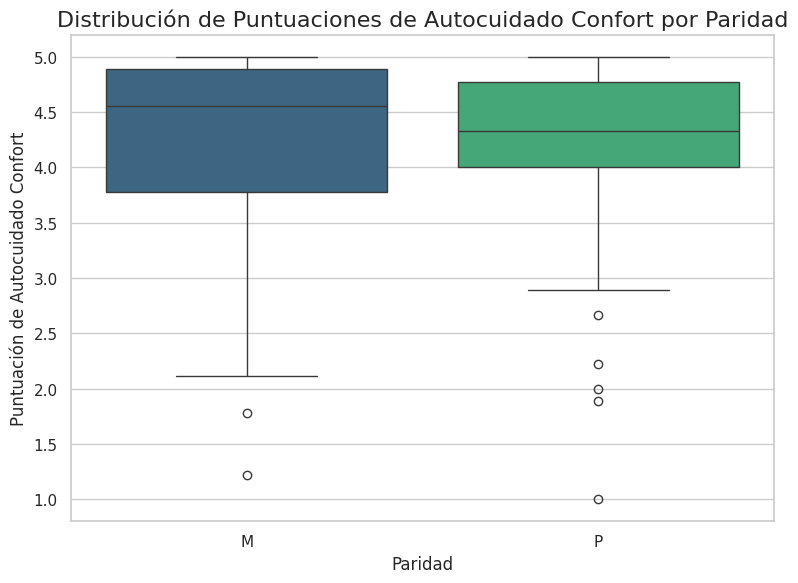

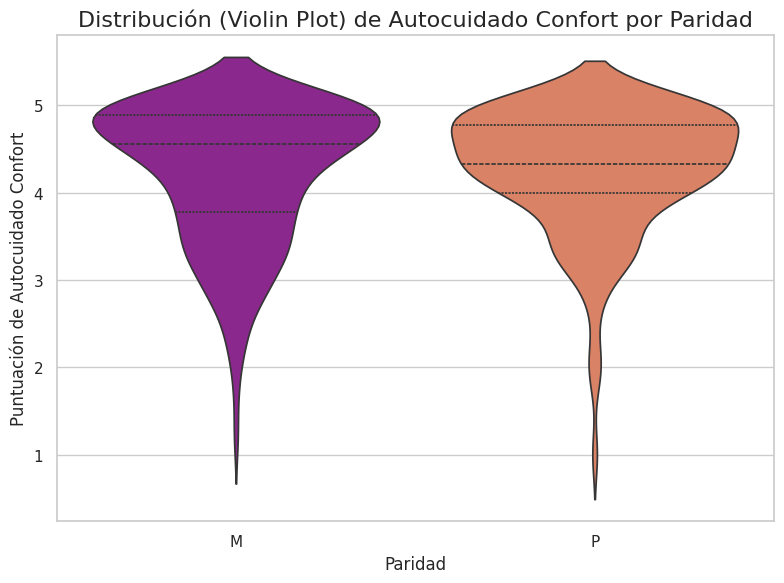

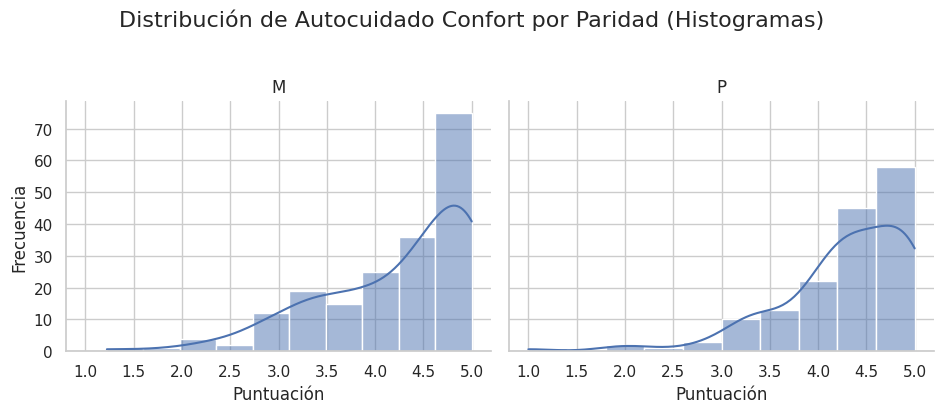

In [132]:
# 2. Visualización de la Distribución de 'Score_Autocuidado_confort' por 'Paridad'
print("\nVisualizando la Distribución de 'Autocuidado Confort' por Paridad:")

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
        x='Paridad',
        y='Score_Autocuidado_confort',
        data=df, palette='viridis',
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
  )
plt.title('Distribución de Puntuaciones de Autocuidado Confort por Paridad', fontsize=16)
plt.ylabel('Puntuación de Autocuidado Confort', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(
        x='Paridad',
        y='Score_Autocuidado_confort',
        data=df, palette='plasma',
        inner="quartile",
        order=df['Paridad'].value_counts().index,
        hue='Paridad',
        legend=False
    )
plt.title('Distribución (Violin Plot) de Autocuidado Confort por Paridad', fontsize=16)
plt.ylabel('Puntuación de Autocuidado Confort', fontsize=12)
plt.xlabel('Paridad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Histogramas separados
g = sns.FacetGrid(df, col="Paridad", col_wrap=2, height=4, aspect=1.2)
g.map(sns.histplot, 'Score_Autocuidado_confort', kde=True, bins=10)
g.fig.suptitle('Distribución de Autocuidado Confort por Paridad (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [133]:
# 3. Prueba de Supuestos para Análisis Inferencial (T-test independiente o Mann-Whitney U)
print("\n--- Evaluación de Supuestos para Análisis Inferencial ---")

# b) Normalidad dentro de cada grupo
print("\nPrueba de Normalidad de 'Autocuidado_confort' dentro de cada grupo de Paridad:")
paridad_groups_autocuidado_confort = df.groupby('Paridad')['Score_Autocuidado_confort']

normalidad_results_autocuidado_confort = {}
for name, group in paridad_groups_autocuidado_confort:
    if len(group) > 3:
        stat_sw, p_value_sw = stats.shapiro(group.dropna())
        normalidad_results_autocuidado_confort[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group.dropna())}
    else:
        normalidad_results_autocuidado_confort[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group.dropna()), 'Note': 'Not enough data for Shapiro-Wilk'}

normalidad_df_autocuidado_confort = pd.DataFrame(normalidad_results_autocuidado_confort).T
display(normalidad_df_autocuidado_confort.style
    .set_caption("Normalidad de 'Autocuidado Confort' por Grupo (Shapiro-Wilk)")
    .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
    .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
)

print("\nInterpretación de la Normalidad:")
print("- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.")
print("- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.")

# c) Homogeneidad de Varianzas (Levene's Test)
print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

group_data_autocuidado_confort = [group.dropna().values for name, group in paridad_groups_autocuidado_confort]

if all(len(g) > 0 for g in group_data_autocuidado_confort) and len(group_data_autocuidado_confort) == 2:
    stat_levene_autocuidado_confort, p_value_levene_autocuidado_confort = stats.levene(*group_data_autocuidado_confort)
    print(f"Estadístico de Levene: {stat_levene_autocuidado_confort:.4f}")
    print(f"Valor p: {p_value_levene_autocuidado_confort:.4f}")

    if p_value_levene_autocuidado_confort < 0.05:
        print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
        print("Si se usa T-test, se debería aplicar la corrección de Welch.")
    else:
        print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
        print("Si se usa T-test, se puede asumir igualdad de varianzas.")
else:
    print("Advertencia: No hay suficientes grupos o datos (se requieren exactamente 2 grupos con datos) para realizar la Prueba de Levene.")


--- Evaluación de Supuestos para Análisis Inferencial ---

Prueba de Normalidad de 'Autocuidado_confort' dentro de cada grupo de Paridad:


,Shapiro-Wilk p-value,N
M,0.0000,190
P,0.0000,155



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para algún grupo, se rechaza la hipótesis de normalidad para ese grupo.
- El T-test es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 3.3828
Valor p: 0.0667
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa T-test, se puede asumir igualdad de varianzas.


In [134]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas ---")

# Decisión: Mann-Whitney U es una opción robusta si los supuestos del T-test no se cumplen.

# Opción 1: Mann-Whitney U Test (No paramétrica - compara medianas/distribuciones)
print("\nAplicando la Prueba de Mann-Whitney U (No Paramétrica):")

# Separar los datos en los dos grupos
group1_data_paridad_ac = df[df['Paridad'] == 'P']['Score_Autocuidado_confort'].dropna()
group2_data_paridad_ac = df[df['Paridad'] == 'M']['Score_Autocuidado_confort'].dropna()

# Realiza la prueba solo si ambos grupos tienen datos
if len(group1_data_paridad_ac) > 0 and len(group2_data_paridad_ac) > 0:
    stat_mw_autocuidado_confort_paridad, p_value_mw_autocuidado_confort_paridad = stats.mannwhitneyu(group1_data_paridad_ac, group2_data_paridad_ac, alternative='two-sided')
    print(f"Estadístico de Mann-Whitney U: {stat_mw_autocuidado_confort_paridad:.4f}")
    print(f"Valor p: {p_value_mw_autocuidado_confort_paridad:.4f}")

    # Interpretación del resultado de Mann-Whitney U
    if p_value_mw_autocuidado_confort_paridad < 0.05:
        print("\nConclusión (Mann-Whitney U): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medianas de 'Autocuidado_confort' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' según la paridad.")
        print(f"La mediana para Primíparas (P) es {group1_data_paridad_ac.median():.2f} y para Multíparas (M) es {group2_data_paridad_ac.median():.2f}.")
    else:
        print("\nConclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre Primíparas y Multíparas.")
else:
    print("Advertencia: No hay suficientes datos en uno o ambos grupos ('P', 'M') para realizar la Prueba de Mann-Whitney U.")

# Opción 2: Independent Samples T-test (Paramétrica - compara medias)
print("\n--- Opcional: Independent Samples T-test (Paramétrica) ---")
print("Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.")
if len(group1_data_paridad_ac) > 1 and len(group2_data_paridad_ac) > 1:
    # Decide si usar equal_var=True o False basado en Levene's test p-value (si fue calculado)
    use_equal_var_autocuidado_confort_paridad = True # Default to True, but check Levene's result
    if 'p_value_levene_autocuidado_confort' in locals() and not np.isnan(p_value_levene_autocuidado_confort) and p_value_levene_autocuidado_confort < 0.05:
        use_equal_var_autocuidado_confort_paridad = False # Use Welch's T-test if variances are not equal
        print("\nUsando T-test de Welch (varianzas no iguales) debido a resultado significativo de Levene's test.")
    else:
         print("\nUsando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).")

    stat_ttest_autocuidado_confort_paridad, p_value_ttest_autocuidado_confort_paridad = stats.ttest_ind(group1_data_paridad_ac, group2_data_paridad_ac, equal_var=use_equal_var_autocuidado_confort_paridad)
    print(f"Estadístico T: {stat_ttest_autocuidado_confort_paridad:.4f}")
    print(f"Valor p (T-test): {p_value_ttest_autocuidado_confort_paridad:.4f}")

    # Interpretación del resultado del T-test
    if p_value_ttest_autocuidado_confort_paridad < 0.05:
        print("\nConclusión (T-test): El valor p es menor que el nivel de significancia (0.05).")
        print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Autocuidado_confort' son iguales entre Primíparas (P) y Multíparas (M).")
        print("Existe una diferencia estadísticamente significativa en la puntuación de 'Score_Autocuidado_confort' según la paridad.")
        print(f"La media para Primíparas (P) es {group1_data_paridad_ac.mean():.2f} y para Multíparas (M) es {group2_data_paridad_ac.mean():.2f}.")
    else:
        print("\nConclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).")
        print("No se puede rechazar la hipótesis nula (H0).")
        print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Score_Autocuidado_confort' entre Primíparas y Multíparas.")
else:
     print("Advertencia: No hay suficientes datos en uno o ambos grupos (mínimo 2 por grupo) para realizar la Prueba T.")


--- Prueba Estadística para Comparar Medias/Medianas ---

Aplicando la Prueba de Mann-Whitney U (No Paramétrica):
Estadístico de Mann-Whitney U: 14681.0000
Valor p: 0.9621

Conclusión (Mann-Whitney U): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre Primíparas y Multíparas.

--- Opcional: Independent Samples T-test (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos o se aplica corrección.

Usando T-test estándar (varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico T: 0.6460
Valor p (T-test): 0.5187

Conclusión (T-test): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente sign

In [135]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

# Verificar si hay datos suficientes para ambos grupos de paridad
if len(df['Paridad'].unique()) == 2:
    print("\nCalculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:")

    # Usar pingouin para realizar el test de Mann-Whitney U y obtener el tamaño del efecto
    mw_effect_size_autocuidado_confort_paridad = pg.mwu(
        x=df[df['Paridad'] == 'P']['Score_Autocuidado_confort'].dropna(),
        y=df[df['Paridad'] == 'M']['Score_Autocuidado_confort'].dropna(),
        alternative='two-sided'
    )

    display(mw_effect_size_autocuidado_confort_paridad.style.set_caption("Resultados de Mann-Whitney U con Tamaño del Efecto (Rank-Biserial r) usando Pingouin"))

    # Extraer el valor del tamaño del efecto y manejar nombres de columnas según versión de pingouin
    effect_size_value_autocuidado_confort_paridad = mw_effect_size_autocuidado_confort_paridad['RBC'].iloc[0]
    p_col = 'p-val' if 'p-val' in mw_effect_size_autocuidado_confort_paridad.columns else 'p_val'
    u_col = 'U-val' if 'U-val' in mw_effect_size_autocuidado_confort_paridad.columns else 'U_val'

    p_value_autocuidado_confort_paridad_pg = mw_effect_size_autocuidado_confort_paridad[p_col].iloc[0]

    print(f"\nEstadístico de Mann-Whitney U: {mw_effect_size_autocuidado_confort_paridad[u_col].iloc[0]:.4f}")
    print(f"Valor p (Pingouin): {p_value_autocuidado_confort_paridad_pg:.4f}")
    print(f"Tamaño del Efecto (Rank-Biserial r): {effect_size_value_autocuidado_confort_paridad:.4f}")

    abs_effect_size_autocuidado_confort_paridad = abs(effect_size_value_autocuidado_confort_paridad)

    print("\nInterpretación del Tamaño del Efecto (Rank-Biserial r):")
    if abs_effect_size_autocuidado_confort_paridad >= 0.50:
        print(f"- El tamaño del efecto ({abs_effect_size_autocuidado_confort_paridad:.2f}) es grande.")
    elif abs_effect_size_autocuidado_confort_paridad >= 0.30:
        print(f"- El tamaño del efecto ({abs_effect_size_autocuidado_confort_paridad:.2f}) es mediano.")
    elif abs_effect_size_autocuidado_confort_paridad >= 0.10:
        print(f"- El tamaño del efecto ({abs_effect_size_autocuidado_confort_paridad:.2f}) es pequeño.")
    else:
        print(f"- El tamaño del efecto ({abs_effect_size_autocuidado_confort_paridad:.2f}) es muy pequeño.")

    print("\nConclusión combinada (Estadística y Tamaño del Efecto):")
    if p_value_autocuidado_confort_paridad_pg < 0.05:
         print(f"- La diferencia en las medianas de 'Autocuidado_confort' es significativa (p={p_value_autocuidado_confort_paridad_pg:.4f}).")
         effect_size_interpretation_ac_paridad = 'muy pequeña' if abs_effect_size_autocuidado_confort_paridad < 0.10 else ('pequeña' if abs_effect_size_autocuidado_confort_paridad < 0.30 else ('mediana' if abs_effect_size_autocuidado_confort_paridad < 0.50 else 'grande'))
         print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_autocuidado_confort_paridad:.2f}) sugiere una magnitud {effect_size_interpretation_ac_paridad}.")
    else:
         print(f"- La prueba de Mann-Whitney U ({p_value_autocuidado_confort_paridad_pg:.4f}) no encontró una diferencia significativa.")
else:
    print("\nAdvertencia: No se pudieron realizar los cálculos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto (r) para la Prueba de Mann-Whitney U:


,U_val,alternative,p_val,RBC,CLES
MWU,14681.000000,two-sided,0.962117,-0.002988,0.498506



Estadístico de Mann-Whitney U: 14681.0000
Valor p (Pingouin): 0.9621
Tamaño del Efecto (Rank-Biserial r): -0.0030

Interpretación del Tamaño del Efecto (Rank-Biserial r):
- El tamaño del efecto (0.00) es muy pequeño.

Conclusión combinada (Estadística y Tamaño del Efecto):
- La prueba de Mann-Whitney U (0.9621) no encontró una diferencia significativa.


In [136]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Autocuidado_confort' por Paridad ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Autocuidado_confort' entre Primíparas (P) y Multíparas (M).")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.")

# Re-evaluate the results of Mann-Whitney U or T-test for Parity
print("\nResultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):")
if 'p_value_mw_autocuidado_confort_paridad' in locals() and not np.isnan(p_value_mw_autocuidado_confort_paridad):
    if p_value_mw_autocuidado_confort_paridad < 0.05:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_autocuidado_confort_paridad:.4f}) indica una diferencia estadísticamente significativa en las medianas de las puntuaciones de 'Autocuidado_confort' entre Primíparas y Multíparas.")
        print(f"  Esto sugiere que la percepción de 'Autocuidado_confort' difiere significativamente según si la mujer es primeriza o no.")
        print(f"  Mediana Primíparas (P): {group1_data_paridad_ac.median():.2f}, Mediana Multíparas (M): {group2_data_paridad_ac.median():.2f}.")
    else:
        print(f"- La prueba de Mann-Whitney U ({p_value_mw_autocuidado_confort_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medianas.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre Primíparas y Multíparas basado en esta prueba no paramétrica.")
elif 'p_value_ttest_autocuidado_confort_paridad' in locals() and not np.isnan(p_value_ttest_autocuidado_confort_paridad):
    print("\nResultados de la Prueba Inferencial (T-test, si se realizó):")
    if p_value_ttest_autocuidado_confort_paridad < 0.05:
         print(f"- La prueba T ({p_value_ttest_autocuidado_confort_paridad:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Autocuidado_confort' entre Primíparas y Multíparas.")
         print(f"  Esto sugiere que la percepción de 'Autocuidado_confort' difiere significativamente según si la mujer es primeriza o no.")
         print(f"  Media Primíparas (P): {group1_data_paridad_ac.mean():.2f}, Media Multíparas (M): {group2_data_paridad_ac.mean():.2f}.")
    else:
        print(f"- La prueba T ({p_value_ttest_autocuidado_confort_paridad:.4f}) no encontró una diferencia estadísticamente significativa en las medias.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre Primíparas y Multíparas basado en esta prueba paramétrica.")
else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes en los grupos.")

print("\nResultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):")
if 'abs_effect_size_autocuidado_confort_paridad' in locals() and not np.isnan(abs_effect_size_autocuidado_confort_paridad):
    effect_size_interpretation_ac_paridad = 'muy pequeña' if abs_effect_size_autocuidado_confort_paridad < 0.10 else ('pequeña' if abs_effect_size_autocuidado_confort_paridad < 0.30 else ('mediana' if abs_effect_size_autocuidado_confort_paridad < 0.50 else 'grande'))
    print(f"- El tamaño del efecto Rank-Biserial r ({abs_effect_size_autocuidado_confort_paridad:.2f}) sugiere una magnitud de la diferencia {effect_size_interpretation_ac_paridad}.")
    print("  Considerar la relevancia práctica de esta magnitud junto con la significancia estadística.")
else:
     print("- No se pudo calcular el tamaño del efecto.")

print("\nRecomendaciones Adicionales para 'Autocuidado_confort' por Paridad:")
print("- Si se encontró una diferencia significativa, investigar si las necesidades o expectativas sobre el autocuidado y el confort durante el parto y postparto difieren entre Primíparas y Multíparas.")
print("- Evaluar si la experiencia previa influye en la forma en que las mujeres perciben y priorizan su propio cuidado y confort.")
print("- Considerar si el personal de salud proporciona información o apoyo diferenciado basado en la paridad que podría influir en la percepción del autocuidado y confort.")
print("- Utilizar estos hallazgos para adaptar las estrategias de educación y apoyo al autocuidado y confort, asegurando que se aborden las necesidades específicas de las mujeres según su paridad.")

print("\n--- Fin del Análisis de 'Autocuidado_confort' según Paridad ---")


--- Conclusiones del Análisis 'Autocuidado_confort' por Paridad ---
- Se realizó el análisis comparando las puntuaciones de 'Autocuidado_confort' entre Primíparas (P) y Multíparas (M).
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial.

Resultados de la Prueba Inferencial (Mann-Whitney U, si se realizó):
- La prueba de Mann-Whitney U (0.9621) no encontró una diferencia estadísticamente significativa en las medianas.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre Primíparas y Multíparas basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Rank-Biserial r, si se calculó):
- El tamaño del efecto Rank-Biserial r (0.00) sugiere una magnitud de la diferencia muy pequeña.
  Considerar la relevancia práctica de esta magnitud junto con

## 6.4 Análisis por Dimensiones según Nivel Educacional

### 6.4.1 Análisis por Dimensión (Cuidado_relacional_calidad) sugún Nivel_educacional ❌

In [137]:
print("\n--- Análisis Específico: Puntuación de 'Cuidado_relacional_calidad' según Nivel_educacional_std ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_relacional_calidad' por 'Nivel_educacional_std'
print("\nEstadísticas Descriptivas para 'Cuidado_relacional_calidad' por Nivel_educacional_std:")
educacion_cuidado_relacional_stats = df.groupby('Nivel_educacional_std')['Score_Cuidado_relacional_calidad'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(educacion_cuidado_relacional_stats.style
        .set_caption("Estadísticas Descriptivas de 'Cuidado Relacional Calidad' por Nivel Educacional")
        .format("{:.2f}")
        .background_gradient(cmap='Blues', axis=1)
        .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los 4 grupos de nivel educacional.")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


--- Análisis Específico: Puntuación de 'Cuidado_relacional_calidad' según Nivel_educacional_std ---

Estadísticas Descriptivas para 'Cuidado_relacional_calidad' por Nivel_educacional_std:


Nivel_educacional_std,Básica,Media,Superior,Tecnico
count,15.00,165.00,115.00,50.00
mean,4.78,4.83,4.77,4.86
median,4.92,5.00,5.00,5.00
std,0.40,0.31,0.43,0.36
min,3.46,3.08,2.62,3.23
max,5.00,5.00,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los 4 grupos de nivel educacional.
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Relacional Calidad' por Nivel Educacional:


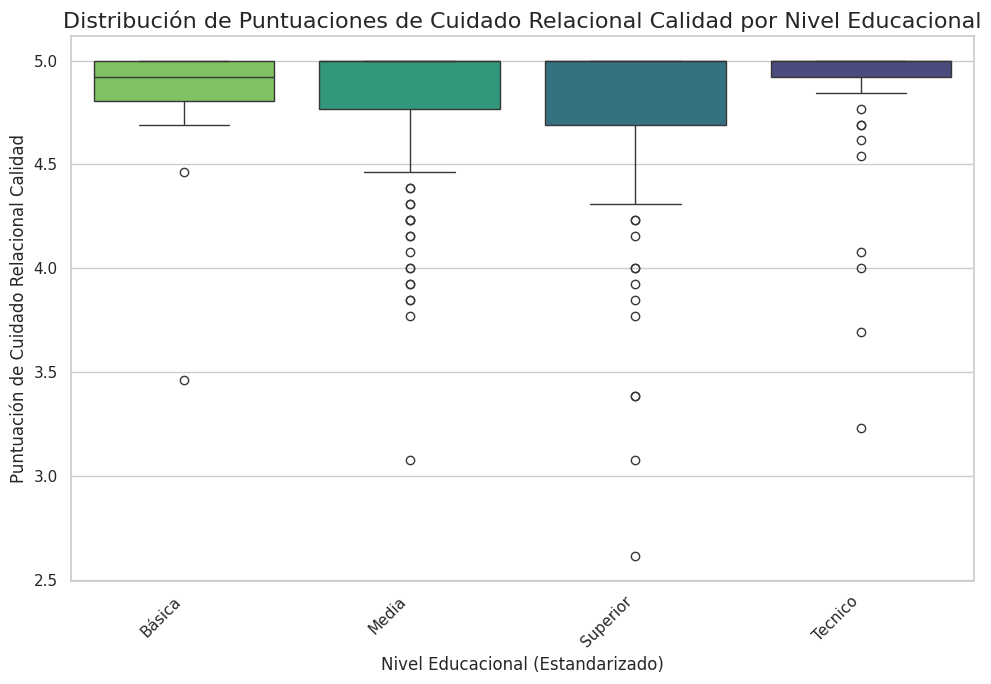

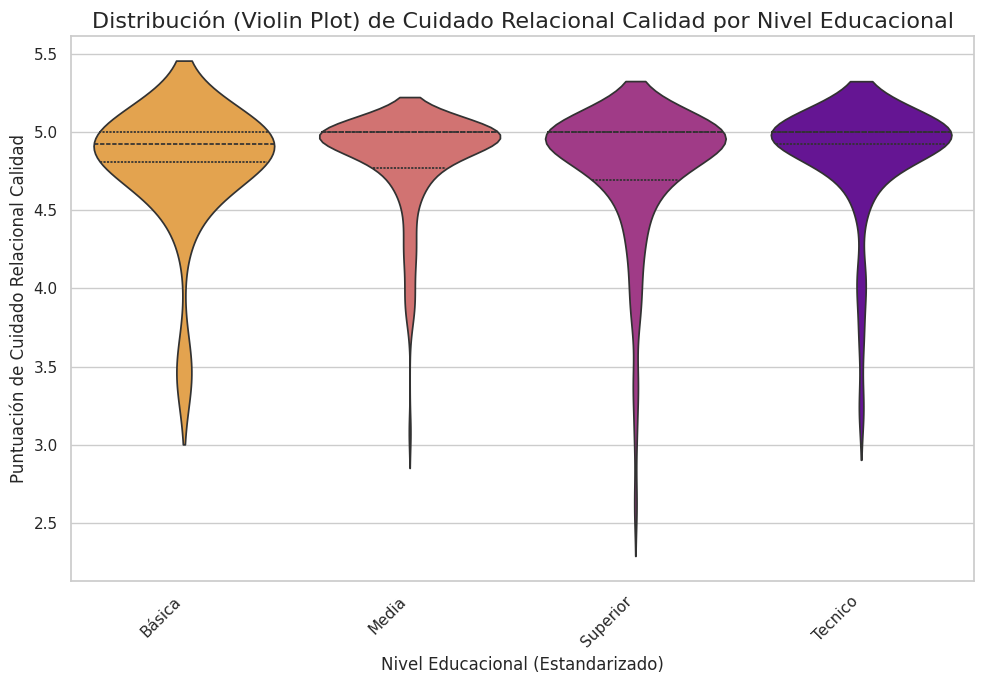

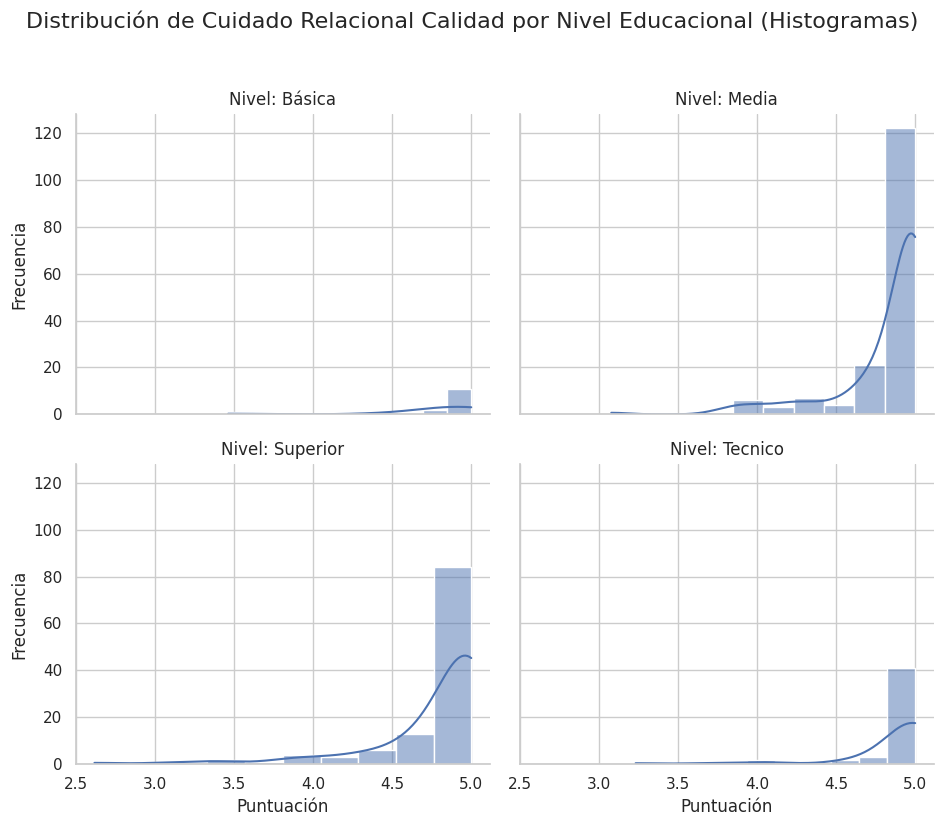

In [138]:
# 2. Visualización de la Distribución de 'Score_Cuidado_relacional_calidad' por 'Nivel_educacional_std'
print("\nVisualizando la Distribución de 'Cuidado Relacional Calidad' por Nivel Educacional:")

# Definir el orden de los grupos si es categórico o estandarizado de forma ordinal
educacion_order = sorted(df['Nivel_educacional_std'].dropna().unique())

# Boxplot
plt.figure(figsize=(10, 7))
sns.boxplot(
    x='Nivel_educacional_std',
    y='Score_Cuidado_relacional_calidad',
    data=df,
    palette='viridis',
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución de Puntuaciones de Cuidado Relacional Calidad por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Cuidado Relacional Calidad', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(10, 7))
sns.violinplot(
    x='Nivel_educacional_std',
    y='Score_Cuidado_relacional_calidad',
    data=df,
    palette='plasma',
    inner="quartile",
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución (Violin Plot) de Cuidado Relacional Calidad por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Cuidado Relacional Calidad', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Histogramas separados para cada nivel educacional
g = sns.FacetGrid(df, col="Nivel_educacional_std", col_wrap=2, height=4, aspect=1.2, col_order=educacion_order) # Usar el orden definido
g.map(sns.histplot, 'Score_Cuidado_relacional_calidad', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Relacional Calidad por Nivel Educacional (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("Nivel: {col_name}")
plt.tight_layout()
plt.show()

In [139]:
# 3. Prueba de Supuestos para Análisis Inferencial (ANOVA o Kruskal-Wallis)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---")

# Identificar los grupos únicos de nivel educacional que tienen datos
educacion_levels = df['Nivel_educacional_std'].dropna().unique()
valid_educacion_levels = [level for level in educacion_levels if len(df[df['Nivel_educacional_std'] == level].dropna(subset=['Score_Cuidado_relacional_calidad'])) > 0]

print(f"Grupos de Nivel Educacional con datos válidos: {valid_educacion_levels}")

if len(valid_educacion_levels) >= 2:
    # b) Normalidad dentro de cada grupo
    print("\nPrueba de Normalidad de 'Cuidado_relacional_calidad' dentro de cada grupo de Nivel Educacional:")
    educacion_groups_cuidado_relacional = df.groupby('Nivel_educacional_std')['Score_Cuidado_relacional_calidad']

    normalidad_results_cuidado_relacional_educacion = {}
    for name, group in educacion_groups_cuidado_relacional:
        group_cleaned = group.dropna()
        if len(group_cleaned) > 3: # Shapiro-Wilk requiere al menos 4 muestras
            stat_sw, p_value_sw = stats.shapiro(group_cleaned)
            normalidad_results_cuidado_relacional_educacion[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group_cleaned)}
        else:
            normalidad_results_cuidado_relacional_educacion[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group_cleaned), 'Note': 'Not enough data for Shapiro-Wilk'}

    normalidad_df_cuidado_relacional_educacion = pd.DataFrame(normalidad_results_cuidado_relacional_educacion).T
    display(normalidad_df_cuidado_relacional_educacion.style
        .set_caption("Normalidad de 'Cuidado Relacional Calidad' por Grupo (Shapiro-Wilk)")
        .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
        .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
    )

    print("\nInterpretación de la Normalidad:")
    print("- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.")
    print("- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.")

    # c) Homogeneidad de Varianzas (Levene's Test)
    print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

    # Preparar los datos por grupo para Levene's test
    group_data_cuidado_relacional_educacion = [df[df['Nivel_educacional_std'] == level]['Score_Cuidado_relacional_calidad'].dropna().values for level in valid_educacion_levels]

    # Levene's Test requiere al menos 2 grupos con datos
    if len(group_data_cuidado_relacional_educacion) >= 2 and all(len(g) > 0 for g in group_data_cuidado_relacional_educacion):
        stat_levene_cuidado_relacional_educacion, p_value_levene_cuidado_relacional_educacion = stats.levene(*group_data_cuidado_relacional_educacion)
        print(f"Estadístico de Levene: {stat_levene_cuidado_relacional_educacion:.4f}")
        print(f"Valor p: {p_value_levene_cuidado_relacional_educacion:.4f}")

        if p_value_levene_cuidado_relacional_educacion < 0.05:
            print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
            print("Si se usa ANOVA, se debería considerar usar ANOVA de Welch.")
        else:
            print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
            print("Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.")
    else:
        print("Advertencia: No hay suficientes grupos o datos (mínimo 2 grupos con datos) para realizar la Prueba de Levene.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---
Grupos de Nivel Educacional con datos válidos: ['Tecnico', 'Superior', 'Media', 'Básica']

Prueba de Normalidad de 'Cuidado_relacional_calidad' dentro de cada grupo de Nivel Educacional:


,Shapiro-Wilk p-value,N
Básica,0.0000,15
Media,0.0000,165
Superior,0.0000,115
Tecnico,0.0000,50



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.
- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 0.9026
Valor p: 0.4400
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.


In [140]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---")

# ANOVA (Análisis de Varianza) es paramétrico y compara medias.
# Kruskal-Wallis es no paramétrico y compara distribuciones (medianas si las distribuciones son similares).
# Kruskal-Wallis es más robusto si los supuestos de ANOVA (normalidad, homogeneidad de varianzas) no se cumplen.

if len(valid_educacion_levels) >= 2:
    # Opción 1: Kruskal-Wallis Test (No paramétrica - compara distribuciones/medianas)
    print("\nAplicando la Prueba de Kruskal-Wallis (No Paramétrica):")

    # Prepara los datos por grupo para Kruskal-Wallis
    kruskal_data_cuidado_relacional_educacion = [df[df['Nivel_educacional_std'] == level]['Score_Cuidado_relacional_calidad'].dropna().values for level in valid_educacion_levels]

    # Realiza la prueba solo si hay datos en al menos 2 grupos
    if len(kruskal_data_cuidado_relacional_educacion) >= 2 and all(len(g) > 0 for g in kruskal_data_cuidado_relacional_educacion):
        stat_kruskal_cuidado_relacional_educacion, p_value_kruskal_cuidado_relacional_educacion = stats.kruskal(*kruskal_data_cuidado_relacional_educacion)
        print(f"Estadístico de Kruskal-Wallis H: {stat_kruskal_cuidado_relacional_educacion:.4f}")
        print(f"Valor p: {p_value_kruskal_cuidado_relacional_educacion:.4f}")

        # Interpretación del resultado de Kruskal-Wallis
        if p_value_kruskal_cuidado_relacional_educacion < 0.05:
            print("\nConclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula (H0) de que las distribuciones (o medianas, si las distribuciones son similares) de 'Cuidado_relacional_calidad' son iguales entre los grupos de Nivel Educacional.")
            print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_relacional_calidad' entre al menos dos grupos de Nivel Educacional.")
            print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

            # Prueba Post-Hoc (Dunn's Test para Kruskal-Wallis)
            print("\nAplicando Prueba Post-Hoc de Dunn (Corrección de Bonferroni) para identificar las diferencias entre pares de grupos:")
            # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
            df_filtered = df[df['Nivel_educacional_std'].isin(valid_educacion_levels)].dropna(subset=['Score_Cuidado_relacional_calidad', 'Nivel_educacional_std'])

            # Verificar que hay suficientes datos después del filtrado
            if not df_filtered.empty:
                # Usar scikit-posthocs para Dunn's test
                dunn_results_cuidado_relacional_educacion = pairwise_dunn(
                    a=df_filtered['Score_Cuidado_relacional_calidad'],
                    g=df_filtered['Nivel_educacional_std'],
                    p_adjust='bonferroni' # O 'sidak', 'fdr_bh', etc. Bonferroni es conservadora.
                )
                display(dunn_results_cuidado_relacional_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Dunn (Corrección de Bonferroni)"))
                print("\nInterpretación de Dunn's Test:")
                print("- Cada celda muestra el p-value ajustado para la comparación entre los grupos en la fila y columna.")
                print("- Un p-value ajustado < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
            else:
                print("Advertencia: No hay suficientes datos para realizar la Prueba Post-Hoc de Dunn después de filtrar por niveles educacionales válidos.")

        else:
            print("\nConclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula (H0).")
            print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_relacional_calidad' entre los grupos de Nivel Educacional.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos para realizar la Prueba de Kruskal-Wallis.")


    # Opción 2: ANOVA (Paramétrica - compara medias)
    print("\n--- Opcional: One-way ANOVA (Paramétrica) ---")
    print("Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.")

    if len(group_data_cuidado_relacional_educacion) >= 2 and all(len(g) > 1 for g in group_data_cuidado_relacional_educacion): # ANOVA requiere al menos 2 datos por grupo
        # Decide si usar ANOVA estándar o Welch basado en Levene's test (si fue calculado)
        use_welch_anova_cuidado_relacional_educacion = False # Default to False
        if 'p_value_levene_cuidado_relacional_educacion' in locals() and not np.isnan(p_value_levene_cuidado_relacional_educacion) and p_value_levene_cuidado_relacional_educacion < 0.05:
            use_welch_anova_cuidado_relacional_educacion = True
            print("\nUsando ANOVA de Welch (no asume varianzas iguales) debido a resultado significativo de Levene's test.")
        else:
            print("\nUsando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).")


        if use_welch_anova_cuidado_relacional_educacion:
            # Usar pingouin para ANOVA de Welch
            try:
                anova_results_cuidado_relacional_educacion = pg.welch_anova(
                    data=df.dropna(subset=['Score_Cuidado_relacional_calidad', 'Nivel_educacional_std']),
                    dv='Score_Cuidado_relacional_calidad',
                    between='Nivel_educacional_std'
                )
                display(anova_results_cuidado_relacional_educacion.style.set_caption("Resultados de ANOVA de Welch usando Pingouin"))
                p_value_anova_cuidado_relacional_educacion = anova_results_cuidado_relacional_educacion['p-unc'].iloc[0] # Pingouin usa 'p-unc' para el p sin corregir
            except Exception as e:
                print(f"Error al realizar ANOVA de Welch con Pingouin: {e}")
                p_value_anova_cuidado_relacional_educacion = np.nan # Marcar como no calculado

        else:
            # Usar scipy para ANOVA estándar
            try:
                stat_anova_cuidado_relacional_educacion, p_value_anova_cuidado_relacional_educacion = stats.f_oneway(*group_data_cuidado_relacional_educacion)
                print(f"Estadístico F (ANOVA): {stat_anova_cuidado_relacional_educacion:.4f}")
                print(f"Valor p (ANOVA): {p_value_anova_cuidado_relacional_educacion:.4f}")
            except Exception as e:
                 print(f"Error al realizar ANOVA estándar con Scipy: {e}")
                 p_value_anova_cuidado_relacional_educacion = np.nan


        # Interpretación del resultado de ANOVA
        if not np.isnan(p_value_anova_cuidado_relacional_educacion):
            if p_value_anova_cuidado_relacional_educacion < 0.05:
                print("\nConclusión (ANOVA): El valor p es menor que el nivel de significancia (0.05).")
                print("Se rechaza la hipótesis nula (H0) de que las medias de 'Cuidado_relacional_calidad' son iguales entre los grupos de Nivel Educacional.")
                print("Existe una diferencia estadísticamente significativa en la puntuación media de 'Cuidado_relacional_calidad' entre al menos dos grupos de Nivel Educacional.")
                print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

                # Prueba Post-Hoc (Tukey HSD para ANOVA estándar, Games-Howell para Welch)
                print("\nAplicando Prueba Post-Hoc:")
                if use_welch_anova_cuidado_relacional_educacion:
                     print("Usando Games-Howell (para ANOVA de Welch) para identificar las diferencias entre pares de grupos:")
                     try:
                         # Usar pingouin para Games-Howell
                         games_howell_results_cuidado_relacional_educacion = pg.pairwise_gameshowell(
                            data=df.dropna(subset=['Score_Cuidado_relacional_calidad', 'Nivel_educacional_std']),
                            dv='Score_Cuidado_relacional_calidad',
                            between='Nivel_educacional_std'
                         )
                         display(games_howell_results_cuidado_relacional_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Games-Howell"))
                         print("\nInterpretación de Games-Howell:")
                         print("- La columna 'p-unc' muestra el p-value sin corregir, y 'p-corr' muestra el p-value ajustado.")
                         print("- Un 'p-corr' < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
                     except Exception as e:
                         print(f"Error al realizar Games-Howell con Pingouin: {e}")

                else:
                    print("Usando Tukey HSD (para ANOVA estándar) para identificar las diferencias entre pares de grupos:")
                    # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
                    df_filtered = df[df['Nivel_educacional_std'].isin(valid_educacion_levels)].dropna(subset=['Score_Cuidado_relacional_calidad', 'Nivel_educacional_std'])

                    # Verificar que hay suficientes datos después del filtrado y que hay variabilidad dentro de los grupos
                    if not df_filtered.empty and df_filtered.groupby('Nivel_educacional_std')['Score_Cuidado_relacional_calidad'].std().min() > 0:
                        try:
                            # Usar statsmodels para Tukey HSD
                            tukey_results_cuidado_relacional_educacion = pairwise_tukeyhsd(
                                endog=df_filtered['Score_Cuidado_relacional_calidad'],
                                groups=df_filtered['Nivel_educacional_std'],
                                alpha=0.05
                            )
                            print(tukey_results_cuidado_relacional_educacion)
                            print("\nInterpretación de Tukey HSD:")
                            print("- 'meandiff' es la diferencia de medias entre los grupos.")
                            print("- 'lower' y 'upper' son los límites del intervalo de confianza del 95% para la diferencia de medias.")
                            print("- 'reject' es True si la diferencia es estadísticamente significativa (p < 0.05), False en caso contrario.")
                        except ValueError as e:
                            print(f"Advertencia: No se pudo realizar Tukey HSD. Error: {e}")
                            print("Esto puede ocurrir si hay grupos con varianza cero (todos los valores son iguales) o si no hay suficientes observaciones en los grupos.")
                        except Exception as e:
                             print(f"Error al realizar Tukey HSD: {e}")
                    else:
                         print("Advertencia: No hay suficientes datos o variabilidad dentro de los grupos para realizar la Prueba Post-Hoc de Tukey HSD.")
            else:
                print("\nConclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).")
                print("No se puede rechazar la hipótesis nula (H0).")
                print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación media de 'Cuidado_relacional_calidad' entre los grupos de Nivel Educacional.")
        else:
             print("ANOVA/Welch ANOVA no pudo ser calculado.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos (mínimo 2 por grupo) para realizar el T-test.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---

Aplicando la Prueba de Kruskal-Wallis (No Paramétrica):
Estadístico de Kruskal-Wallis H: 6.0433
Valor p: 0.1095

Conclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_relacional_calidad' entre los grupos de Nivel Educacional.

--- Opcional: One-way ANOVA (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.

Usando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico F (ANOVA): 0.9160
Valor p (ANOVA): 0.4333

Conclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia sufici

In [141]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

if len(valid_educacion_levels) >= 2:
    print("\nCalculando el Tamaño del Efecto para múltiples grupos:")

    # Para ANOVA, el tamaño del efecto comúnmente usado es eta cuadrado (η²).
    # Para Kruskal-Wallis, se puede usar eta cuadrado basado en H.

    # Calcular eta cuadrado (η²) para ANOVA (si se realizó)
    if 'anova_results_cuidado_relacional_educacion' in locals() and isinstance(anova_results_cuidado_relacional_educacion, pd.DataFrame):
        print("\nCalculando Eta Cuadrado (η²) para ANOVA:")
        try:
            # Pingouin calcula η² (eta-squared) o η²p (partial eta-squared)
            eta_squared_anova_cuidado_relacional_educacion = anova_results_cuidado_relacional_educacion['eta-squared'].iloc[0]
            print(f"Eta Cuadrado (η²) para la prueba general (ANOVA): {eta_squared_anova_cuidado_relacional_educacion:.4f}")

            # Interpretación del tamaño del efecto eta cuadrado (Cohen, 1988)
            print("\nInterpretación del Tamaño del Efecto (Eta Cuadrado η²):")
            if eta_squared_anova_cuidado_relacional_educacion >= 0.14:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_relacional_educacion:.2f}) es grande.")
                print("  El Nivel Educacional explica una proporción sustancial de la variabilidad en la puntuación de 'Cuidado_relacional_calidad'.")
            elif eta_squared_anova_cuidado_relacional_educacion >= 0.06:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_relacional_educacion:.2f}) es mediano.")
                print("  El Nivel Educacional explica una proporción moderada de la variabilidad.")
            elif eta_squared_anova_cuidado_relacional_educacion >= 0.01:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_relacional_educacion:.2f}) es pequeño.")
                print("  El Nivel Educacional explica una pequeña proporción de la variabilidad.")
            else:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_relacional_educacion:.2f}) es muy pequeño.")
                print("  Indica que el Nivel Educacional tiene una influencia mínima en la variabilidad de 'Cuidado_relacional_calidad' en esta muestra.")
        except Exception as e:
             print(f"Error al calcular Eta Cuadrado con Pingouin: {e}")

    # Calcular eta cuadrado basado en H para Kruskal-Wallis (si se realizó)
    if 'stat_kruskal_cuidado_relacional_educacion' in locals() and not np.isnan(stat_kruskal_cuidado_relacional_educacion):
        print("\nCalculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:")
        N_cuidado_relacional_educacion = df['Score_Cuidado_relacional_calidad'].dropna().shape[0]
        # Epsilon squared (preferido para Kruskal-Wallis)
        if N_cuidado_relacional_educacion > 0:
            epsilon_squared_kruskal_cuidado_relacional_educacion = (stat_kruskal_cuidado_relacional_educacion / (N_cuidado_relacional_educacion + 1))
            print(f"Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: {epsilon_squared_kruskal_cuidado_relacional_educacion:.4f}")

            # Interpretación similar a eta cuadrado
            print("\nInterpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):")
            if epsilon_squared_kruskal_cuidado_relacional_educacion >= 0.138: # Aproximaciones para no paramétrico
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_relacional_educacion:.2f}) es grande.")
            elif epsilon_squared_kruskal_cuidado_relacional_educacion >= 0.059:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_relacional_educacion:.2f}) es mediano.")
            elif epsilon_squared_kruskal_cuidado_relacional_educacion >= 0.01:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_relacional_educacion:.2f}) es pequeño.")
            else:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_relacional_educacion:.2f}) es muy pequeño.")

        else:
            print("Advertencia: No hay suficientes datos para calcular el tamaño del efecto (Epsilon Cuadrado).")


    # Tamaño del efecto para comparaciones post-hoc (si se realizaron)
    if 'dunn_results_cuidado_relacional_educacion' in locals() and not dunn_results_cuidado_relacional_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver p-values ajustados arriba).")
         print("Para cada par significativo, la diferencia de medianas o rangos promedio observada en las estadísticas descriptivas da una idea de la dirección y magnitud de la diferencia.")
    elif 'games_howell_results_cuidado_relacional_educacion' in locals() and not games_howell_results_cuidado_relacional_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'diff' y 'p-corr' arriba).")
         print("'diff' muestra la diferencia media entre pares, y 'p-corr' su significancia.")
    elif 'tukey_results_cuidado_relacional_educacion' in locals():
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'meandiff' y 'reject' arriba).")
         print("'meandiff' muestra la diferencia media entre pares, y 'reject' su significancia.")
else:
    print("\nAdvertencia: No se pudieron realizar cálculos de tamaño del efecto ya que no hay suficientes grupos con datos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto para múltiples grupos:

Calculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:
Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: 0.0175

Interpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):
- El tamaño del efecto (0.02) es pequeño.


In [142]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Cuidado_relacional_calidad' según Nivel Educacional ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Cuidado_relacional_calidad' entre los 4 grupos de Nivel Educacional Estandarizado.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).")

print("\nResultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):")

# Priorizar la interpretación basada en Kruskal-Wallis si se hizo y es significativo
if 'p_value_kruskal_cuidado_relacional_educacion' in locals() and not np.isnan(p_value_kruskal_cuidado_relacional_educacion):
    if p_value_kruskal_cuidado_relacional_educacion < 0.05:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_cuidado_relacional_educacion:.4f}) indica una diferencia estadísticamente significativa en las distribuciones (medianas) de las puntuaciones de 'Cuidado_relacional_calidad' entre los grupos de Nivel Educacional.")
        print("- Esto sugiere que la percepción de la calidad del cuidado relacional difiere significativamente según el nivel educativo.")
        print("- Las pruebas post-hoc de Dunn identifican específicamente qué pares de grupos muestran diferencias significativas.")
        if 'dunn_results_cuidado_relacional_educacion' in locals() and not dunn_results_cuidado_relacional_educacion.empty:
            print("  Revisar la tabla de resultados de Dunn para ver las comparaciones significativas.")
        else:
            print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_cuidado_relacional_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_relacional_calidad' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.")

# Si Kruskal-Wallis no fue significativo o no se hizo, considerar la interpretación de ANOVA si se hizo
elif 'p_value_anova_cuidado_relacional_educacion' in locals() and not np.isnan(p_value_anova_cuidado_relacional_educacion):
    if p_value_anova_cuidado_relacional_educacion < 0.05:
         print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_cuidado_relacional_educacion:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Cuidado_relacional_calidad' entre los grupos de Nivel Educacional.")
         print("- Esto sugiere que la percepción de la calidad del cuidado relacional difiere significativamente según el nivel educativo.")
         print("- Las pruebas post-hoc (Tukey HSD o Games-Howell) identifican específicamente qué pares de grupos muestran diferencias significativas.")
         if 'tukey_results_cuidado_relacional_educacion' in locals():
            print("  Revisar la tabla de resultados de Tukey HSD para ver las comparaciones significativas.")
         elif 'games_howell_results_cuidado_relacional_educacion' in locals() and not games_howell_results_cuidado_relacional_educacion.empty:
             print("  Revisar la tabla de resultados de Games-Howell para ver las comparaciones significativas.")
         else:
             print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_cuidado_relacional_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_relacional_calidad' entre los grupos de Nivel Educacional basado en esta prueba paramétrica.")

else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes o problemas en los cálculos.")


print("\nResultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):")
if 'eta_squared_anova_cuidado_relacional_educacion' in locals() and not np.isnan(eta_squared_anova_cuidado_relacional_educacion):
    effect_size_interpretation_eta = 'muy pequeña' if eta_squared_anova_cuidado_relacional_educacion < 0.01 else ('pequeña' if eta_squared_anova_cuidado_relacional_educacion < 0.06 else ('mediana' if eta_squared_anova_cuidado_relacional_educacion < 0.14 else 'grande'))
    print(f"- El tamaño del efecto (Eta Cuadrado η²) para ANOVA fue de {eta_squared_anova_cuidado_relacional_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_eta}.")
elif 'epsilon_squared_kruskal_cuidado_relacional_educacion' in locals() and not np.isnan(epsilon_squared_kruskal_cuidado_relacional_educacion):
    effect_size_interpretation_epsilon = 'muy pequeña' if epsilon_squared_kruskal_cuidado_relacional_educacion < 0.01 else ('pequeña' if epsilon_squared_kruskal_cuidado_relacional_educacion < 0.059 else ('mediana' if epsilon_squared_kruskal_cuidado_relacional_educacion < 0.138 else 'grande'))
    print(f"- El tamaño del efecto (Epsilon Cuadrado ε²) para Kruskal-Wallis fue de {epsilon_squared_kruskal_cuidado_relacional_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_epsilon}.")
else:
     print("- No se pudo calcular el tamaño del efecto global.")

print("\nRecomendaciones Adicionales para 'Cuidado_relacional_calidad' por Nivel Educacional:")
print("- Si se encontraron diferencias significativas, explorar las razones detrás de estas diferencias. ¿Las mujeres con diferentes niveles educativos tienen expectativas distintas sobre la comunicación, el respeto o el apoyo emocional del personal de salud?")
print("- Considerar si el personal de salud se comunica de manera diferente o percibe de manera distinta a las mujeres según su nivel educativo, lo que podría influir en la calidad de la interacción.")
print("- Evaluar si las herramientas de comunicación o la información proporcionada son igualmente efectivas y comprensibles para todos los niveles educativos.")
print("- Utilizar estos hallazgos para desarrollar estrategias de capacitación para el personal de salud que promuevan una comunicación y un cuidado relacional cultural y educacionalmente sensibles, asegurando una experiencia positiva para todas las mujeres, independientemente de su nivel educativo.")
print("- Adaptar los materiales informativos y los métodos de comunicación para que sean accesibles y relevantes para mujeres con diferentes antecedentes educativos.")


print("\n--- Fin del Análisis de 'Cuidado_relacional_calidad' según Nivel_educacional_std ---")


--- Conclusiones del Análisis 'Cuidado_relacional_calidad' según Nivel Educacional ---
- Se realizó el análisis comparando las puntuaciones de 'Cuidado_relacional_calidad' entre los 4 grupos de Nivel Educacional Estandarizado.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).

Resultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):
- La prueba de Kruskal-Wallis (0.1095) no encontró una diferencia estadísticamente significativa.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_relacional_calidad' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):
- El tamaño del efecto (Epsilon Cuadrado ε²) par

### 6.4.2 Análisis por Dimensión (Cuidado_despersonalizado) sugún Nivel_educacional ❌

In [143]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.4.1 pero esta vez con la dimensión Cuidado_despersonalizado según Nivel_educacional_std, entendiendo y siendo muy cuidadoso que Nivel_educacional_std es una variable que separa la muestra en 4

print("\n--- Análisis Específico: Puntuación de 'Cuidado_despersonalizado' según Nivel_educacional_std ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_despersonalizado' por 'Nivel_educacional_std'
print("\nEstadísticas Descriptivas para 'Cuidado_despersonalizado' por Nivel_educacional_std:")
educacion_cuidado_despersonalizado_stats = df.groupby('Nivel_educacional_std')['Score_Cuidado_despersonalizado'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(educacion_cuidado_despersonalizado_stats.style
    .set_caption("Estadísticas Descriptivas de 'Cuidado Despersonalizado' por Nivel Educacional")
    .format("{:.2f}")
    .background_gradient(cmap='Blues', axis=1)
    .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los 4 grupos de nivel educacional.")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")



--- Análisis Específico: Puntuación de 'Cuidado_despersonalizado' según Nivel_educacional_std ---

Estadísticas Descriptivas para 'Cuidado_despersonalizado' por Nivel_educacional_std:


Nivel_educacional_std,Básica,Media,Superior,Tecnico
count,15.00,165.00,115.00,50.00
mean,1.61,1.65,1.63,1.56
median,1.50,1.33,1.33,1.50
std,0.59,0.82,0.78,0.58
min,1.00,1.00,1.00,1.00
max,2.67,5.00,4.83,3.17



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los 4 grupos de nivel educacional.
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Despersonalizado' por Nivel Educacional:


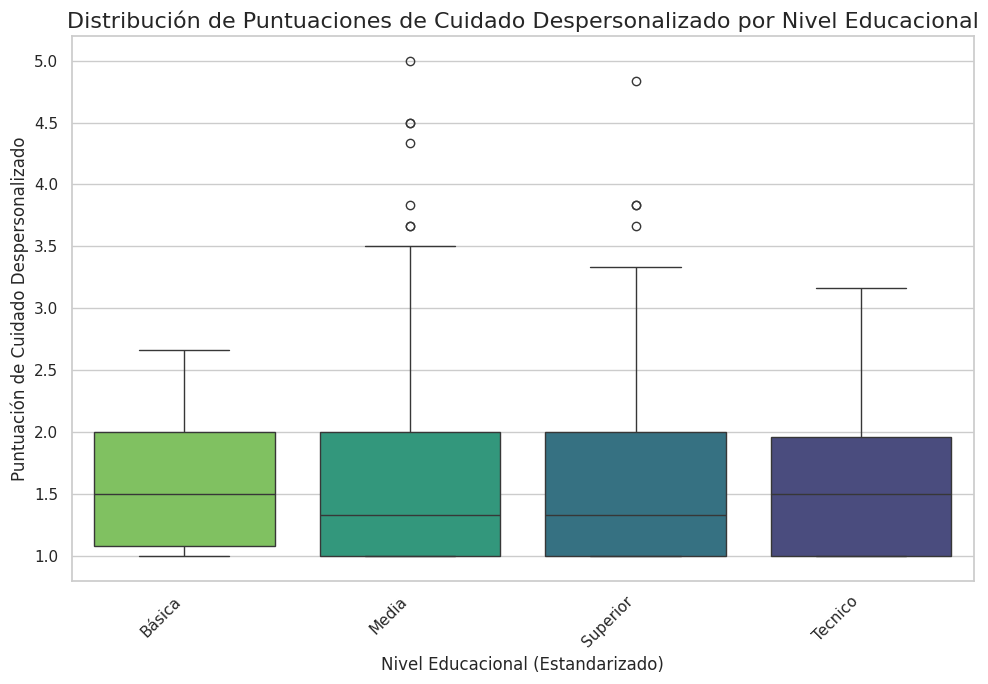

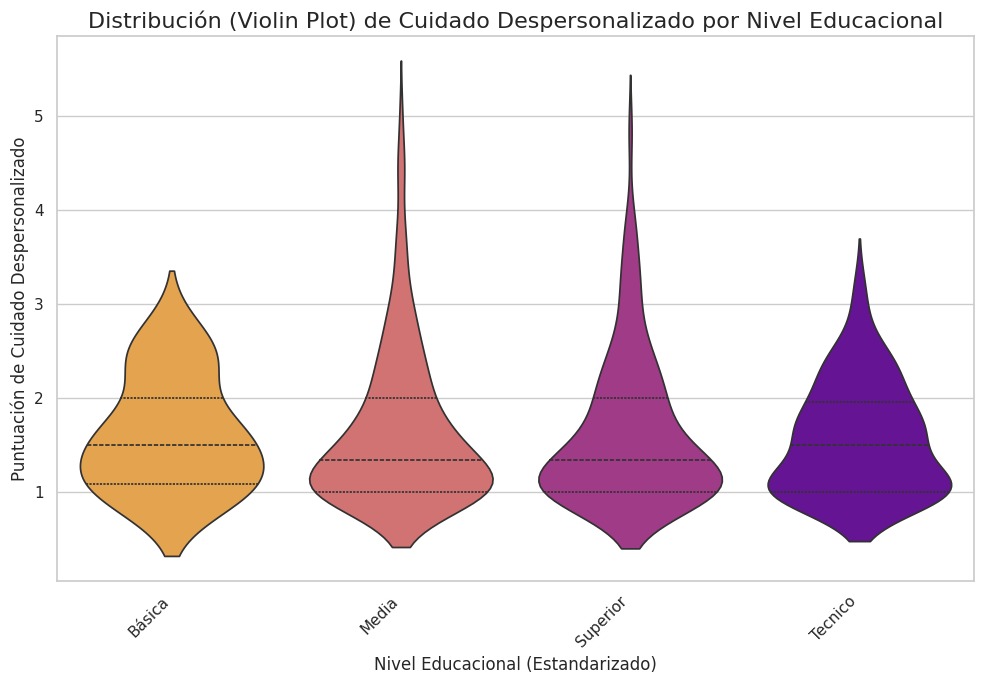

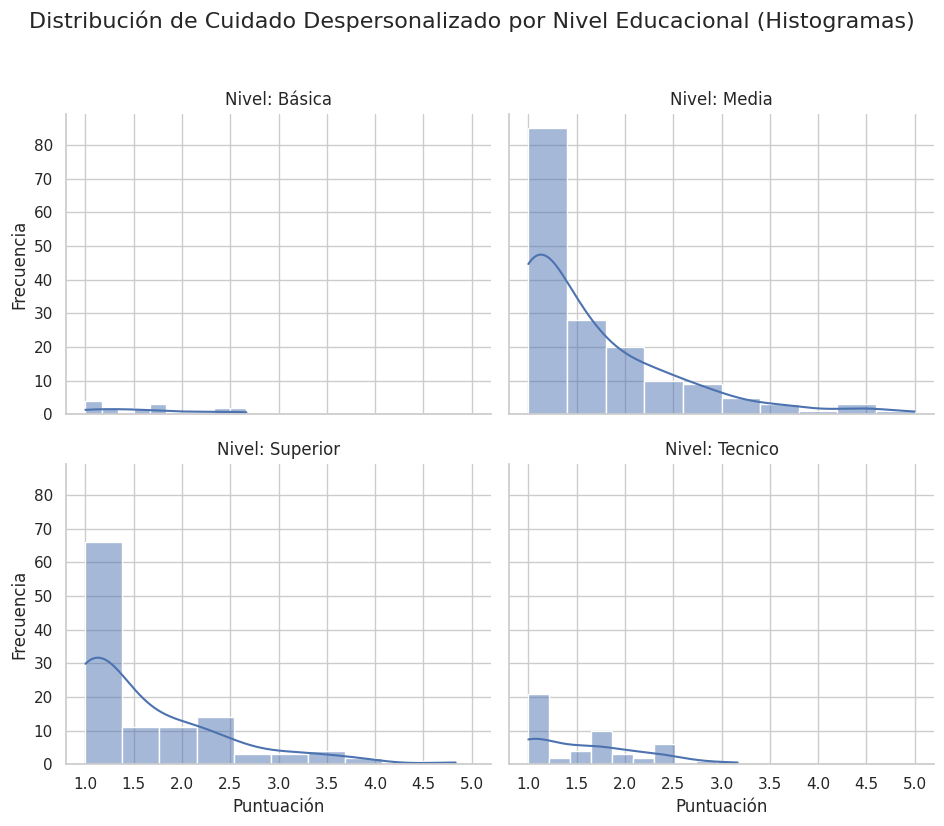

In [144]:
# 2. Visualización de la Distribución de 'Score_Cuidado_despersonalizado' por 'Nivel_educacional_std'
print("\nVisualizando la Distribución de 'Cuidado Despersonalizado' por Nivel Educacional:")

# Definir el orden de los grupos si es categórico o estandarizado de forma ordinal
educacion_order = sorted(df['Nivel_educacional_std'].dropna().unique())

# Boxplot
plt.figure(figsize=(10, 7))
sns.boxplot(
    x='Nivel_educacional_std',
    y='Score_Cuidado_despersonalizado',
    data=df,
    palette='viridis',
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución de Puntuaciones de Cuidado Despersonalizado por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Cuidado Despersonalizado', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(10, 7))
sns.violinplot(
    x='Nivel_educacional_std',
    y='Score_Cuidado_despersonalizado',
    data=df,
    palette='plasma',
    inner="quartile",
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución (Violin Plot) de Cuidado Despersonalizado por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Cuidado Despersonalizado', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Histogramas separados para cada nivel educacional
g = sns.FacetGrid(df, col="Nivel_educacional_std", col_wrap=2, height=4, aspect=1.2, col_order=educacion_order) # Usar el orden definido
g.map(sns.histplot, 'Score_Cuidado_despersonalizado', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Despersonalizado por Nivel Educacional (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("Nivel: {col_name}")
plt.tight_layout()
plt.show()

In [145]:
# 3. Prueba de Supuestos para Análisis Inferencial (ANOVA o Kruskal-Wallis)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---")

# Identificar los grupos únicos de nivel educacional que tienen datos para la dimensión actual
educacion_levels_cuidado_despersonalizado = df['Nivel_educacional_std'].dropna().unique()
valid_educacion_levels_cuidado_despersonalizado = [
    level for level in educacion_levels_cuidado_despersonalizado
    if len(df[df['Nivel_educacional_std'] == level].dropna(subset=['Score_Cuidado_despersonalizado'])) > 0
]

print(f"Grupos de Nivel Educacional con datos válidos para 'Cuidado_despersonalizado': {valid_educacion_levels_cuidado_despersonalizado}")

if len(valid_educacion_levels_cuidado_despersonalizado) >= 2:
    # b) Normalidad dentro de cada grupo
    print("\nPrueba de Normalidad de 'Score_Cuidado_despersonalizado' dentro de cada grupo de Nivel Educacional:")
    educacion_groups_cuidado_despersonalizado = df.groupby('Nivel_educacional_std')['Score_Cuidado_despersonalizado']

    normalidad_results_cuidado_despersonalizado_educacion = {}
    for name, group in educacion_groups_cuidado_despersonalizado:
        group_cleaned = group.dropna()
        if len(group_cleaned) > 3: # Shapiro-Wilk requiere al menos 4 muestras
            stat_sw, p_value_sw = stats.shapiro(group_cleaned)
            normalidad_results_cuidado_despersonalizado_educacion[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group_cleaned)}
        else:
            normalidad_results_cuidado_despersonalizado_educacion[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group_cleaned), 'Note': 'Not enough data for Shapiro-Wilk'}

    normalidad_df_cuidado_despersonalizado_educacion = pd.DataFrame(normalidad_results_cuidado_despersonalizado_educacion).T
    display(normalidad_df_cuidado_despersonalizado_educacion.style
        .set_caption("Normalidad de 'Cuidado Despersonalizado' por Grupo (Shapiro-Wilk)")
        .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
        .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
    )

    print("\nInterpretación de la Normalidad:")
    print("- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.")
    print("- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.")

    # c) Homogeneidad de Varianzas (Levene's Test)
    print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

    # Preparar los datos por grupo para Levene's test
    group_data_cuidado_despersonalizado_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Cuidado_despersonalizado'].dropna().values
        for level in valid_educacion_levels_cuidado_despersonalizado
    ]

    # Levene's Test requiere al menos 2 grupos con datos
    if len(group_data_cuidado_despersonalizado_educacion) >= 2 and all(len(g) > 0 for g in group_data_cuidado_despersonalizado_educacion):
        stat_levene_cuidado_despersonalizado_educacion, p_value_levene_cuidado_despersonalizado_educacion = stats.levene(*group_data_cuidado_despersonalizado_educacion)
        print(f"Estadístico de Levene: {stat_levene_cuidado_despersonalizado_educacion:.4f}")
        print(f"Valor p: {p_value_levene_cuidado_despersonalizado_educacion:.4f}")

        if p_value_levene_cuidado_despersonalizado_educacion < 0.05:
            print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
            print("Si se usa ANOVA, se debería considerar usar ANOVA de Welch.")
        else:
            print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
            print("Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.")
    else:
        print("Advertencia: No hay suficientes grupos o datos (mínimo 2 grupos con datos) para realizar la Prueba de Levene.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---
Grupos de Nivel Educacional con datos válidos para 'Cuidado_despersonalizado': ['Tecnico', 'Superior', 'Media', 'Básica']

Prueba de Normalidad de 'Score_Cuidado_despersonalizado' dentro de cada grupo de Nivel Educacional:


,Shapiro-Wilk p-value,N
Básica,0.0316,15
Media,0.0000,165
Superior,0.0000,115
Tecnico,0.0000,50



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.
- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 0.4952
Valor p: 0.6859
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.


In [146]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---")

# ANOVA (Análisis de Varianza) es paramétrico y compara medias.
# Kruskal-Wallis es no paramétrico y compara distribuciones (medianas si las distribuciones son similares).
# Kruskal-Wallis es más robusto si los supuestos de ANOVA (normalidad, homogeneidad de varianzas) no se cumplen.

if len(valid_educacion_levels_cuidado_despersonalizado) >= 2:
    # Opción 1: Kruskal-Wallis Test (No paramétrica - compara distribuciones/medianas)
    print("\nAplicando la Prueba de Kruskal-Wallis (No Paramétrica):")

    # Prepara los datos por grupo para Kruskal-Wallis
    kruskal_data_cuidado_despersonalizado_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Cuidado_despersonalizado'].dropna().values
        for level in valid_educacion_levels_cuidado_despersonalizado
    ]

    # Realiza la prueba solo si hay datos en al menos 2 grupos
    if len(kruskal_data_cuidado_despersonalizado_educacion) >= 2 and all(len(g) > 0 for g in kruskal_data_cuidado_despersonalizado_educacion):
        stat_kruskal_cuidado_despersonalizado_educacion, p_value_kruskal_cuidado_despersonalizado_educacion = stats.kruskal(*kruskal_data_cuidado_despersonalizado_educacion)
        print(f"Estadístico de Kruskal-Wallis H: {stat_kruskal_cuidado_despersonalizado_educacion:.4f}")
        print(f"Valor p: {p_value_kruskal_cuidado_despersonalizado_educacion:.4f}")

        # Interpretación del resultado de Kruskal-Wallis
        if p_value_kruskal_cuidado_despersonalizado_educacion < 0.05:
            print("\nConclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula (H0) de que las distribuciones (o medianas, si las distribuciones son similares) de 'Cuidado_despersonalizado' son iguales entre los grupos de Nivel Educacional.")
            print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_despersonalizado' entre al menos dos grupos de Nivel Educacional.")
            print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

            # Prueba Post-Hoc (Dunn's Test para Kruskal-Wallis)
            print("\nAplicando Prueba Post-Hoc de Dunn (Corrección de Bonferroni) para identificar las diferencias entre pares de grupos:")
            # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
            df_filtered_cd_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_cuidado_despersonalizado)].dropna(subset=['Score_Cuidado_despersonalizado', 'Nivel_educacional_std'])

            # Verificar que hay suficientes datos después del filtrado
            if not df_filtered_cd_edu.empty:
                # Usar scikit-posthocs para Dunn's test
                dunn_results_cuidado_despersonalizado_educacion = pairwise_dunn(
                    a=df_filtered_cd_edu['Score_Cuidado_despersonalizado'],
                    g=df_filtered_cd_edu['Nivel_educacional_std'],
                    p_adjust='bonferroni' # O 'sidak', 'fdr_bh', etc. Bonferroni es conservadora.
                )
                display(dunn_results_cuidado_despersonalizado_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Dunn (Corrección de Bonferroni)"))
                print("\nInterpretación de Dunn's Test:")
                print("- Cada celda muestra el p-value ajustado para la comparación entre los grupos en la fila y columna.")
                print("- Un p-value ajustado < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
            else:
                print("Advertencia: No hay suficientes datos para realizar la Prueba Post-Hoc de Dunn después de filtrar por niveles educacionales válidos.")

        else:
            print("\nConclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula (H0).")
            print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_despersonalizado' entre los grupos de Nivel Educacional.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos para realizar la Prueba de Kruskal-Wallis.")


    # Opción 2: ANOVA (Paramétrica - compara medias)
    print("\n--- Opcional: One-way ANOVA (Paramétrica) ---")
    print("Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.")

    if len(group_data_cuidado_despersonalizado_educacion) >= 2 and all(len(g) > 1 for g in group_data_cuidado_despersonalizado_educacion): # ANOVA requiere al menos 2 datos por grupo
        # Decide si usar ANOVA estándar o Welch basado en Levene's test (si fue calculado)
        use_welch_anova_cuidado_despersonalizado_educacion = False # Default to False
        if 'p_value_levene_cuidado_despersonalizado_educacion' in locals() and not np.isnan(p_value_levene_cuidado_despersonalizado_educacion) and p_value_levene_cuidado_despersonalizado_educacion < 0.05:
            use_welch_anova_cuidado_despersonalizado_educacion = True
            print("\nUsando ANOVA de Welch (no asume varianzas iguales) debido a resultado significativo de Levene's test.")
        else:
            print("\nUsando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).")


        if use_welch_anova_cuidado_despersonalizado_educacion:
            # Usar pingouin para ANOVA de Welch
            try:
                anova_results_cuidado_despersonalizado_educacion = pg.welch_anova(
                    data=df.dropna(subset=['Score_Cuidado_despersonalizado', 'Nivel_educacional_std']),
                    dv='Score_Cuidado_despersonalizado',
                    between='Nivel_educacional_std'
                )
                display(anova_results_cuidado_despersonalizado_educacion.style.set_caption("Resultados de ANOVA de Welch usando Pingouin"))
                p_value_anova_cuidado_despersonalizado_educacion = anova_results_cuidado_despersonalizado_educacion['p-unc'].iloc[0] # Pingouin usa 'p-unc' para el p sin corregir
            except Exception as e:
                print(f"Error al realizar ANOVA de Welch con Pingouin: {e}")
                p_value_anova_cuidado_despersonalizado_educacion = np.nan # Marcar como no calculado

        else:
            # Usar scipy para ANOVA estándar
            try:
                stat_anova_cuidado_despersonalizado_educacion, p_value_anova_cuidado_despersonalizado_educacion = stats.f_oneway(*group_data_cuidado_despersonalizado_educacion)
                print(f"Estadístico F (ANOVA): {stat_anova_cuidado_despersonalizado_educacion:.4f}")
                print(f"Valor p (ANOVA): {p_value_anova_cuidado_despersonalizado_educacion:.4f}")
            except Exception as e:
                 print(f"Error al realizar ANOVA estándar con Scipy: {e}")
                 p_value_anova_cuidado_despersonalizado_educacion = np.nan


        # Interpretación del resultado de ANOVA
        if not np.isnan(p_value_anova_cuidado_despersonalizado_educacion):
            if p_value_anova_cuidado_despersonalizado_educacion < 0.05:
                print("\nConclusión (ANOVA): El valor p es menor que el nivel de significancia (0.05).")
                print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Cuidado_despersonalizado' son iguales entre los grupos de Nivel Educacional.")
                print("Existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Cuidado_despersonalizado' entre al menos dos grupos de Nivel Educacional.")
                print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

                # Prueba Post-Hoc (Tukey HSD para ANOVA estándar, Games-Howell para Welch)
                print("\nAplicando Prueba Post-Hoc:")
                if use_welch_anova_cuidado_despersonalizado_educacion:
                     print("Usando Games-Howell (para ANOVA de Welch) para identificar las diferencias entre pares de grupos:")
                     try:
                         # Usar pingouin para Games-Howell
                         games_howell_results_cuidado_despersonalizado_educacion = pg.pairwise_gameshowell(
                            data=df.dropna(subset=['Score_Cuidado_despersonalizado', 'Nivel_educacional_std']),
                            dv='Score_Cuidado_despersonalizado',
                            between='Nivel_educacional_std'
                         )
                         display(games_howell_results_cuidado_despersonalizado_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Games-Howell"))
                         print("\nInterpretación de Games-Howell:")
                         print("- La columna 'p-unc' muestra el p-value sin corregir, y 'p-corr' muestra el p-value ajustado.")
                         print("- Un 'p-corr' < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
                     except Exception as e:
                         print(f"Error al realizar Games-Howell con Pingouin: {e}")

                else:
                    print("Usando Tukey HSD (para ANOVA estándar) para identificar las diferencias entre pares de grupos:")
                    # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
                    df_filtered_cd_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_cuidado_despersonalizado)].dropna(subset=['Score_Cuidado_despersonalizado', 'Nivel_educacional_std'])

                    # Verificar que hay suficientes datos después del filtrado y que hay variabilidad dentro de los grupos
                    if not df_filtered_cd_edu.empty and df_filtered_cd_edu.groupby('Nivel_educacional_std')['Score_Cuidado_despersonalizado'].std().min() > 0:
                        try:
                            # Usar statsmodels para Tukey HSD
                            tukey_results_cuidado_despersonalizado_educacion = pairwise_tukeyhsd(
                                endog=df_filtered_cd_edu['Score_Cuidado_despersonalizado'],
                                groups=df_filtered_cd_edu['Nivel_educacional_std'],
                                alpha=0.05
                            )
                            print(tukey_results_cuidado_despersonalizado_educacion)
                            print("\nInterpretación de Tukey HSD:")
                            print("- 'meandiff' es la diferencia de medias entre los grupos.")
                            print("- 'lower' y 'upper' son los límites del intervalo de confianza del 95% para la diferencia de medias.")
                            print("- 'reject' es True si la diferencia es estadísticamente significativa (p < 0.05), False en caso contrario.")
                        except ValueError as e:
                            print(f"Advertencia: No se pudo realizar Tukey HSD. Error: {e}")
                            print("Esto puede ocurrir si hay grupos con varianza cero (todos los valores son iguales) o si no hay suficientes observaciones en los grupos.")
                        except Exception as e:
                             print(f"Error al realizar Tukey HSD: {e}")
                    else:
                         print("Advertencia: No hay suficientes datos o variabilidad dentro de los grupos para realizar la Prueba Post-Hoc de Tukey HSD.")
            else:
                print("\nConclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).")
                print("No se puede rechazar la hipótesis nula (H0).")
                print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Cuidado_despersonalizado' entre los grupos de Nivel Educacional.")
        else:
             print("ANOVA/Welch ANOVA no pudo ser calculado.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos (mínimo 2 por grupo) para realizar el T-test.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---

Aplicando la Prueba de Kruskal-Wallis (No Paramétrica):
Estadístico de Kruskal-Wallis H: 0.2859
Valor p: 0.9627

Conclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_despersonalizado' entre los grupos de Nivel Educacional.

--- Opcional: One-way ANOVA (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.

Usando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico F (ANOVA): 0.1803
Valor p (ANOVA): 0.9097

Conclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficien

In [147]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

if len(valid_educacion_levels_cuidado_despersonalizado) >= 2:
    print("\nCalculando el Tamaño del Efecto para múltiples grupos:")

    # Para ANOVA, el tamaño del efecto comúnmente usado es eta cuadrado (η²).
    # Para Kruskal-Wallis, se puede usar eta cuadrado basado en H.

    # Calcular eta cuadrado (η²) para ANOVA (si se realizó)
    if 'anova_results_cuidado_despersonalizado_educacion' in locals() and isinstance(anova_results_cuidado_despersonalizado_educacion, pd.DataFrame):
        print("\nCalculando Eta Cuadrado (η²) para ANOVA:")
        try:
            # Pingouin calcula η² (eta-squared) o η²p (partial eta-squared)
            eta_squared_anova_cuidado_despersonalizado_educacion = anova_results_cuidado_despersonalizado_educacion['eta-squared'].iloc[0]
            print(f"Eta Cuadrado (η²) para la prueba general (ANOVA): {eta_squared_anova_cuidado_despersonalizado_educacion:.4f}")

            # Interpretación del tamaño del efecto eta cuadrado (Cohen, 1988)
            print("\nInterpretación del Tamaño del Efecto (Eta Cuadrado η²):")
            if eta_squared_anova_cuidado_despersonalizado_educacion >= 0.14:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_despersonalizado_educacion:.2f}) es grande.")
                print("  El Nivel Educacional explica una proporción sustancial de la variabilidad en la puntuación de 'Cuidado_despersonalizado'.")
            elif eta_squared_anova_cuidado_despersonalizado_educacion >= 0.06:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_despersonalizado_educacion:.2f}) es mediano.")
                print("  El Nivel Educacional explica una proporción moderada de la variabilidad.")
            elif eta_squared_anova_cuidado_despersonalizado_educacion >= 0.01:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_despersonalizado_educacion:.2f}) es pequeño.")
                print("  El Nivel Educacional explica una pequeña proporción de la variabilidad.")
            else:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_despersonalizado_educacion:.2f}) es muy pequeño.")
                print("  Indica que el Nivel Educacional tiene una influencia mínima en la variabilidad de 'Cuidado_despersonalizado' en esta muestra.")
        except Exception as e:
             print(f"Error al calcular Eta Cuadrado con Pingouin: {e}")

    # Calcular eta cuadrado basado en H para Kruskal-Wallis (si se realizó)
    if 'stat_kruskal_cuidado_despersonalizado_educacion' in locals() and not np.isnan(stat_kruskal_cuidado_despersonalizado_educacion):
        print("\nCalculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:")
        N_cuidado_despersonalizado_educacion = df['Score_Cuidado_despersonalizado'].dropna().shape[0]
        # Epsilon squared (preferido para Kruskal-Wallis)
        if N_cuidado_despersonalizado_educacion > 0:
            epsilon_squared_kruskal_cuidado_despersonalizado_educacion = (stat_kruskal_cuidado_despersonalizado_educacion / (N_cuidado_despersonalizado_educacion + 1))
            print(f"Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: {epsilon_squared_kruskal_cuidado_despersonalizado_educacion:.4f}")

            # Interpretación similar a eta cuadrado
            print("\nInterpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):")
            if epsilon_squared_kruskal_cuidado_despersonalizado_educacion >= 0.138: # Aproximaciones para no paramétrico
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_despersonalizado_educacion:.2f}) es grande.")
            elif epsilon_squared_kruskal_cuidado_despersonalizado_educacion >= 0.059:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_despersonalizado_educacion:.2f}) es mediano.")
            elif epsilon_squared_kruskal_cuidado_despersonalizado_educacion >= 0.01:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_despersonalizado_educacion:.2f}) es pequeño.")
            else:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_despersonalizado_educacion:.2f}) es muy pequeño.")

        else:
            print("Advertencia: No hay suficientes datos para calcular el tamaño del efecto (Epsilon Cuadrado).")


    # Tamaño del efecto para comparaciones post-hoc (si se realizaron)
    if 'dunn_results_cuidado_despersonalizado_educacion' in locals() and not dunn_results_cuidado_despersonalizado_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver p-values ajustados arriba).")
         print("Para cada par significativo, la diferencia de medianas o rangos promedio observada en las estadísticas descriptivas da una idea de la dirección y magnitud de la diferencia.")
    elif 'games_howell_results_cuidado_despersonalizado_educacion' in locals() and not games_howell_results_cuidado_despersonalizado_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'diff' y 'p-corr' arriba).")
         print("'diff' muestra la diferencia media entre pares, y 'p-corr' su significancia.")
    elif 'tukey_results_cuidado_despersonalizado_educacion' in locals():
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'meandiff' y 'reject' arriba).")
         print("'meandiff' muestra la diferencia media entre pares, y 'reject' su significancia.")
else:
    print("\nAdvertencia: No se pudieron realizar cálculos de tamaño del efecto ya que no hay suficientes grupos con datos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto para múltiples grupos:

Calculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:
Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: 0.0008

Interpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):
- El tamaño del efecto (0.00) es muy pequeño.


In [148]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Cuidado_despersonalizado' según Nivel Educacional ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Cuidado_despersonalizado' entre los 4 grupos de Nivel Educacional Estandarizado.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).")

print("\nResultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):")

# Priorizar la interpretación basada en Kruskal-Wallis si se hizo y es significativo
if 'p_value_kruskal_cuidado_despersonalizado_educacion' in locals() and not np.isnan(p_value_kruskal_cuidado_despersonalizado_educacion):
    if p_value_kruskal_cuidado_despersonalizado_educacion < 0.05:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_cuidado_despersonalizado_educacion:.4f}) indica una diferencia estadísticamente significativa en las distribuciones (medianas) de las puntuaciones de 'Cuidado_despersonalizado' entre los grupos de Nivel Educacional.")
        print("- Esto sugiere que la percepción del cuidado despersonalizado difiere significativamente según el nivel educativo.")
        print("- Las pruebas post-hoc de Dunn identifican específicamente qué pares de grupos muestran diferencias significativas.")
        if 'dunn_results_cuidado_despersonalizado_educacion' in locals() and not dunn_results_cuidado_despersonalizado_educacion.empty:
            print("  Revisar la tabla de resultados de Dunn para ver las comparaciones significativas.")
        else:
            print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_cuidado_despersonalizado_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_despersonalizado' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.")

# Si Kruskal-Wallis no fue significativo o no se hizo, considerar la interpretación de ANOVA si se hizo
elif 'p_value_anova_cuidado_despersonalizado_educacion' in locals() and not np.isnan(p_value_anova_cuidado_despersonalizado_educacion):
    if p_value_anova_cuidado_despersonalizado_educacion < 0.05:
         print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_cuidado_despersonalizado_educacion:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Cuidado_despersonalizado' entre los grupos de Nivel Educacional.")
         print("- Esto sugiere que la percepción del cuidado despersonalizado difiere significativamente según el nivel educativo.")
         print("- Las pruebas post-hoc (Tukey HSD o Games-Howell) identifican específicamente qué pares de grupos muestran diferencias significativas.")
         if 'tukey_results_cuidado_despersonalizado_educacion' in locals():
            print("  Revisar la tabla de resultados de Tukey HSD para ver las comparaciones significativas.")
         elif 'games_howell_results_cuidado_despersonalizado_educacion' in locals() and not games_howell_results_cuidado_despersonalizado_educacion.empty:
             print("  Revisar la tabla de resultados de Games-Howell para ver las comparaciones significativas.")
         else:
             print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_cuidado_despersonalizado_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_despersonalizado' entre los grupos de Nivel Educacional basado en esta prueba paramétrica.")

else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes o problemas en los cálculos.")


print("\nResultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):")
if 'eta_squared_anova_cuidado_despersonalizado_educacion' in locals() and not np.isnan(eta_squared_anova_cuidado_despersonalizado_educacion):
    effect_size_interpretation_eta_cd = 'muy pequeña' if eta_squared_anova_cuidado_despersonalizado_educacion < 0.01 else ('pequeña' if eta_squared_anova_cuidado_despersonalizado_educacion < 0.06 else ('mediana' if eta_squared_anova_cuidado_despersonalizado_educacion < 0.14 else 'grande'))
    print(f"- El tamaño del efecto (Eta Cuadrado η²) para ANOVA fue de {eta_squared_anova_cuidado_despersonalizado_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_eta_cd}.")
elif 'epsilon_squared_kruskal_cuidado_despersonalizado_educacion' in locals() and not np.isnan(epsilon_squared_kruskal_cuidado_despersonalizado_educacion):
    effect_size_interpretation_epsilon_cd = 'muy pequeña' if epsilon_squared_kruskal_cuidado_despersonalizado_educacion < 0.01 else ('pequeña' if epsilon_squared_kruskal_cuidado_despersonalizado_educacion < 0.059 else ('mediana' if epsilon_squared_kruskal_cuidado_despersonalizado_educacion < 0.138 else 'grande'))
    print(f"- El tamaño del efecto (Epsilon Cuadrado ε²) para Kruskal-Wallis fue de {epsilon_squared_kruskal_cuidado_despersonalizado_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_epsilon_cd}.")
else:
     print("- No se pudo calcular el tamaño del efecto global.")

print("\nRecomendaciones Adicionales para 'Cuidado_despersonalizado' por Nivel Educacional:")
print("- Si se encontraron diferencias significativas, investigar si las mujeres con diferentes niveles educativos perciben o experimentan el cuidado de manera más o menos 'despersonalizada'.")
print("- Explorar si factores como la comunicación, la participación en decisiones, o el trato individualizado varían en función del nivel educativo percibido por el personal de salud.")
print("- Evaluar si hay sesgos inconscientes en el personal de salud al interactuar con mujeres de diferentes niveles educativos.")
print("- Utilizar estos hallazgos para implementar capacitaciones que fomenten un cuidado más centrado en la persona, independientemente del nivel educativo, enfatizando la comunicación respetuosa y la consideración de las necesidades individuales.")


print("\n--- Fin del Análisis de 'Cuidado_despersonalizado' según Nivel_educacional_std ---")


--- Conclusiones del Análisis 'Cuidado_despersonalizado' según Nivel Educacional ---
- Se realizó el análisis comparando las puntuaciones de 'Cuidado_despersonalizado' entre los 4 grupos de Nivel Educacional Estandarizado.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).

Resultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):
- La prueba de Kruskal-Wallis (0.9627) no encontró una diferencia estadísticamente significativa.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_despersonalizado' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):
- El tamaño del efecto (Epsilon Cuadrado ε²) para Krus

### 6.4.3 Análisis por Dimensión (Participacion_familiar_continua) sugún Nivel_educacional ❌

In [149]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.4.2 pero esta vez con la dimensión Participacion_familiar_continua según Nivel_educacional_std, entendiendo y siendo muy cuidadoso que Nivel_educacional_std es una variable que separa la muestra en 4

print("\n--- Análisis Específico: Puntuación de 'Participacion_familiar_continua' según Nivel_educacional_std ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Participacion_familiar_continua' por 'Nivel_educacional_std'
print("\nEstadísticas Descriptivas para 'Participacion_familiar_continua' por Nivel_educacional_std:")
educacion_participacion_familiar_stats = df.groupby('Nivel_educacional_std')['Score_Participacion_familiar_continua'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(educacion_participacion_familiar_stats.style
    .set_caption("Estadísticas Descriptivas de 'Participación Familiar Continua' por Nivel Educacional")
    .format("{:.2f}")
    .background_gradient(cmap='Blues', axis=1)
    .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los 4 grupos de nivel educacional.")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")



--- Análisis Específico: Puntuación de 'Participacion_familiar_continua' según Nivel_educacional_std ---

Estadísticas Descriptivas para 'Participacion_familiar_continua' por Nivel_educacional_std:


Nivel_educacional_std,Básica,Media,Superior,Tecnico
count,15.00,165.00,115.00,50.00
mean,4.80,4.78,4.64,4.81
median,5.00,5.00,5.00,5.00
std,0.38,0.37,0.63,0.44
min,4.00,3.50,2.25,3.00
max,5.00,5.00,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los 4 grupos de nivel educacional.
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Participacion Familiar Continua' por Nivel Educacional:


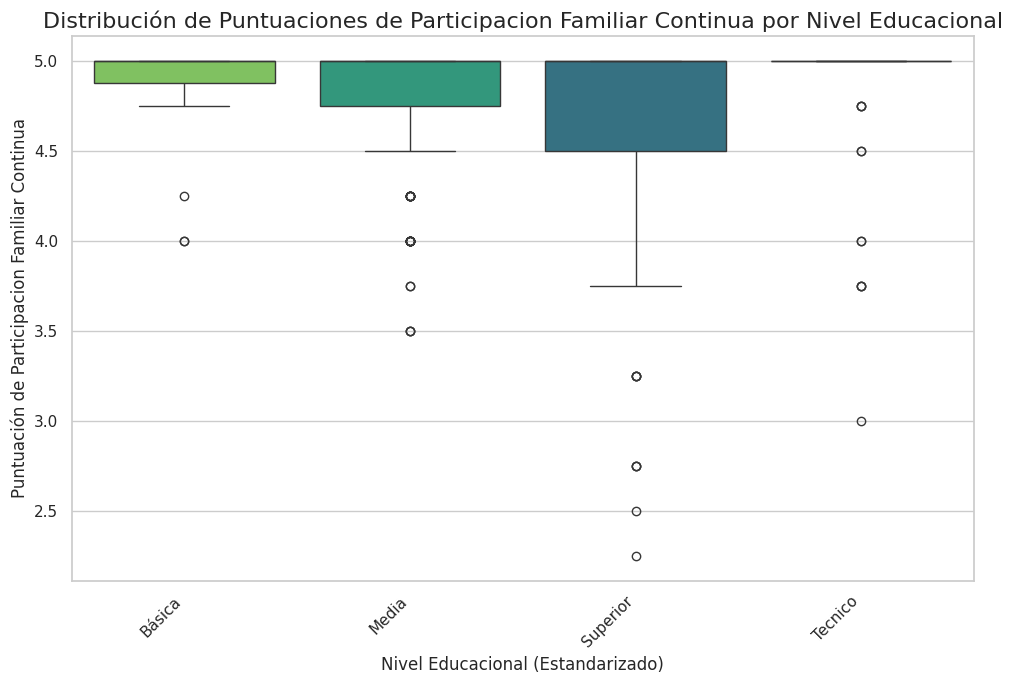

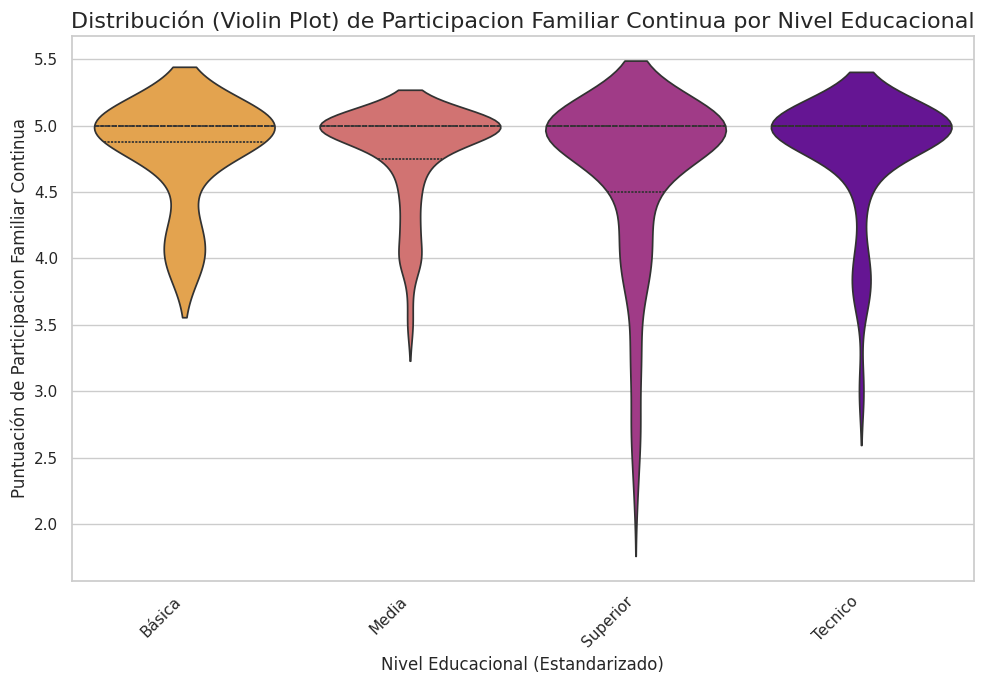

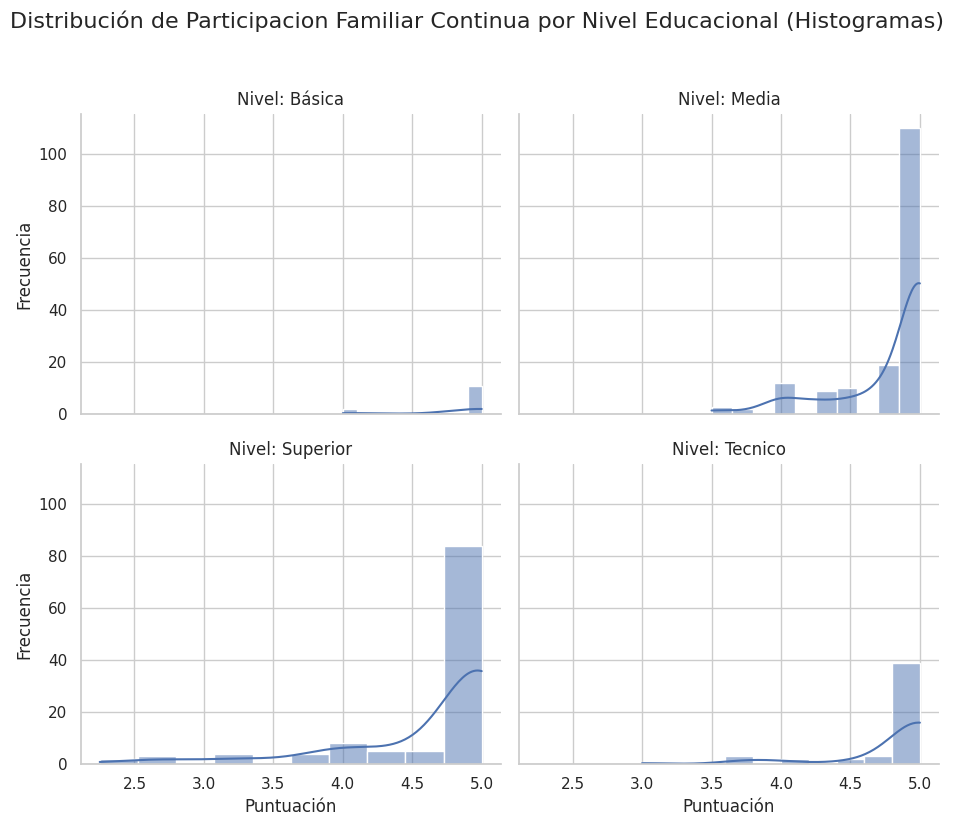

In [150]:
# 2. Visualización de la Distribución de 'Score_Participacion_familiar_continua' por 'Nivel_educacional_std'
print("\nVisualizando la Distribución de 'Participacion Familiar Continua' por Nivel Educacional:")

# Definir el orden de los grupos si es categórico o estandarizado de forma ordinal
# Asegurarse de que el orden es correcto para Nivel_educacional_std
educacion_order = sorted(df['Nivel_educacional_std'].dropna().unique())

# Boxplot
plt.figure(figsize=(10, 7))
sns.boxplot(
    x='Nivel_educacional_std',
    y='Score_Participacion_familiar_continua',
    data=df,
    palette='viridis',
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución de Puntuaciones de Participacion Familiar Continua por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Participacion Familiar Continua', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(10, 7))
sns.violinplot(
    x='Nivel_educacional_std',
    y='Score_Participacion_familiar_continua',
    data=df,
    palette='plasma',
    inner="quartile",
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución (Violin Plot) de Participacion Familiar Continua por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Participacion Familiar Continua', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Histogramas separados para cada nivel educacional
g = sns.FacetGrid(df, col="Nivel_educacional_std", col_wrap=2, height=4, aspect=1.2, col_order=educacion_order) # Usar el orden definido
g.map(sns.histplot, 'Score_Participacion_familiar_continua', kde=True, bins=10)
g.fig.suptitle('Distribución de Participacion Familiar Continua por Nivel Educacional (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("Nivel: {col_name}")
plt.tight_layout()
plt.show()

In [151]:
# 3. Prueba de Supuestos para Análisis Inferencial (ANOVA o Kruskal-Wallis)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---")

# Identificar los grupos únicos de nivel educacional que tienen datos para la dimensión actual
educacion_levels_participacion_familiar = df['Nivel_educacional_std'].dropna().unique()
valid_educacion_levels_participacion_familiar = [
    level for level in educacion_levels_participacion_familiar
    if len(df[df['Nivel_educacional_std'] == level].dropna(subset=['Score_Participacion_familiar_continua'])) > 0
]

print(f"Grupos de Nivel Educacional con datos válidos para 'Participacion_familiar_continua': {valid_educacion_levels_participacion_familiar}")

if len(valid_educacion_levels_participacion_familiar) >= 2:
    # b) Normalidad dentro de cada grupo
    print("\nPrueba de Normalidad de 'Score_Participacion_familiar_continua' dentro de cada grupo de Nivel Educacional:")
    educacion_groups_participacion_familiar = df.groupby('Nivel_educacional_std')['Score_Participacion_familiar_continua']

    normalidad_results_participacion_familiar_educacion = {}
    for name, group in educacion_groups_participacion_familiar:
        group_cleaned = group.dropna()
        if len(group_cleaned) > 3: # Shapiro-Wilk requiere al menos 4 muestras
            stat_sw, p_value_sw = stats.shapiro(group_cleaned)
            normalidad_results_participacion_familiar_educacion[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group_cleaned)}
        else:
            normalidad_results_participacion_familiar_educacion[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group_cleaned), 'Note': 'Not enough data for Shapiro-Wilk'}

    normalidad_df_participacion_familiar_educacion = pd.DataFrame(normalidad_results_participacion_familiar_educacion).T
    display(normalidad_df_participacion_familiar_educacion.style
        .set_caption("Normalidad de 'Participación Familiar Continua' por Grupo (Shapiro-Wilk)")
        .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
        .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
    )

    print("\nInterpretación de la Normalidad:")
    print("- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.")
    print("- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.")

    # c) Homogeneidad de Varianzas (Levene's Test)
    print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

    # Preparar los datos por grupo para Levene's test
    group_data_participacion_familiar_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Participacion_familiar_continua'].dropna().values
        for level in valid_educacion_levels_participacion_familiar
    ]

    # Levene's Test requiere al menos 2 grupos con datos
    if len(group_data_participacion_familiar_educacion) >= 2 and all(len(g) > 0 for g in group_data_participacion_familiar_educacion):
        stat_levene_participacion_familiar_educacion, p_value_levene_participacion_familiar_educacion = stats.levene(*group_data_participacion_familiar_educacion)
        print(f"Estadístico de Levene: {stat_levene_participacion_familiar_educacion:.4f}")
        print(f"Valor p: {p_value_levene_participacion_familiar_educacion:.4f}")

        if p_value_levene_participacion_familiar_educacion < 0.05:
            print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
            print("Si se usa ANOVA, se debería considerar usar ANOVA de Welch.")
        else:
            print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
            print("Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.")
    else:
        print("Advertencia: No hay suficientes grupos o datos (mínimo 2 grupos con datos) para realizar la Prueba de Levene.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---
Grupos de Nivel Educacional con datos válidos para 'Participacion_familiar_continua': ['Tecnico', 'Superior', 'Media', 'Básica']

Prueba de Normalidad de 'Score_Participacion_familiar_continua' dentro de cada grupo de Nivel Educacional:


,Shapiro-Wilk p-value,N
Básica,0.0000,15
Media,0.0000,165
Superior,0.0000,115
Tecnico,0.0000,50



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.
- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 2.4841
Valor p: 0.0606
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.


In [152]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianaspresentación entre 4 Grupos ---")

# ANOVA (Análisis de Varianza) es paramétrico y compara medias.
# Kruskal-Wallis es no paramétrico y compara distribuciones (medianas si las distribuciones son similares).
# Kruskal-Wallis es más robusto si los supuestos de ANOVA (normalidad, homogeneidad de varianzas) no se cumplen.

if len(valid_educacion_levels_participacion_familiar) >= 2:
    # Opción 1: Kruskal-Wallis Test (No paramétrica - compara distribuciones/medianas)
    print("\nAplicando la Prueba de Kruskal-Wallis (No Paramétrica):")

    # Prepara los datos por grupo para Kruskal-Wallis
    kruskal_data_participacion_familiar_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Participacion_familiar_continua'].dropna().values
        for level in valid_educacion_levels_participacion_familiar
    ]

    # Realiza la prueba solo si hay datos en al menos 2 grupos
    if len(kruskal_data_participacion_familiar_educacion) >= 2 and all(len(g) > 0 for g in kruskal_data_participacion_familiar_educacion):
        stat_kruskal_participacion_familiar_educacion, p_value_kruskal_participacion_familiar_educacion = stats.kruskal(*kruskal_data_participacion_familiar_educacion)
        print(f"Estadístico de Kruskal-Wallis H: {stat_kruskal_participacion_familiar_educacion:.4f}")
        print(f"Valor p: {p_value_kruskal_participacion_familiar_educacion:.4f}")

        # Interpretación del resultado de Kruskal-Wallis
        if p_value_kruskal_participacion_familiar_educacion < 0.05:
            print("\nConclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula (H0) de que las distribuciones (o medianas, si las distribuciones son similares) de 'Participacion_familiar_continua' son iguales entre los grupos de Nivel Educacional.")
            print("Existe una diferencia estadísticamente significativa en la puntuación de 'Participacion_familiar_continua' entre al menos dos grupos de Nivel Educacional.")
            print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

            # Prueba Post-Hoc (Dunn's Test para Kruskal-Wallis)
            print("\nAplicando Prueba Post-Hoc de Dunn (Corrección de Bonferroni) para identificar las diferencias entre pares de grupos:")
            # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
            df_filtered_pf_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_participacion_familiar)].dropna(subset=['Score_Participacion_familiar_continua', 'Nivel_educacional_std'])

            # Verificar que hay suficientes datos después del filtrado
            if not df_filtered_pf_edu.empty:
                # Usar scikit-posthocs para Dunn's test
                dunn_results_participacion_familiar_educacion = pairwise_dunn(
                    a=df_filtered_pf_edu['Score_Participacion_familiar_continua'],
                    g=df_filtered_pf_edu['Nivel_educacional_std'],
                    p_adjust='bonferroni' # O 'sidak', 'fdr_bh', etc. Bonferroni es conservadora.
                )
                display(dunn_results_participacion_familiar_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Dunn (Corrección de Bonferroni)"))
                print("\nInterpretación de Dunn's Test:")
                print("- Cada celda muestra el p-value ajustado para la comparación entre los grupos en la fila y columna.")
                print("- Un p-value ajustado < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
            else:
                print("Advertencia: No hay suficientes datos para realizar la Prueba Post-Hoc de Dunn después de filtrar por niveles educacionales válidos.")

        else:
            print("\nConclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula (H0).")
            print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Participacion_familiar_continua' entre los grupos de Nivel Educacional.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos para realizar la Prueba de Kruskal-Wallis.")


    # Opción 2: ANOVA (Paramétrica - compara medias)
    print("\n--- Opcional: One-way ANOVA (Paramétrica) ---")
    print("Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.")

    if len(group_data_participacion_familiar_educacion) >= 2 and all(len(g) > 1 for g in group_data_participacion_familiar_educacion): # ANOVA requiere al menos 2 datos por grupo
        # Decide si usar ANOVA estándar o Welch basado en Levene's test (si fue calculado)
        use_welch_anova_participacion_familiar_educacion = False # Default to False
        if 'p_value_levene_participacion_familiar_educacion' in locals() and not np.isnan(p_value_levene_participacion_familiar_educacion) and p_value_levene_participacion_familiar_educacion < 0.05:
            use_welch_anova_participacion_familiar_educacion = True
            print("\nUsando ANOVA de Welch (no asume varianzas iguales) debido a resultado significativo de Levene's test.")
        else:
            print("\nUsando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).")


        if use_welch_anova_participacion_familiar_educacion:
            # Usar pingouin para ANOVA de Welch
            try:
                anova_results_participacion_familiar_educacion = pg.welch_anova(
                    data=df.dropna(subset=['Score_Participacion_familiar_continua', 'Nivel_educacional_std']),
                    dv='Score_Participacion_familiar_continua',
                    between='Nivel_educacional_std'
                )
                display(anova_results_participacion_familiar_educacion.style.set_caption("Resultados de ANOVA de Welch usando Pingouin"))
                p_value_anova_participacion_familiar_educacion = anova_results_participacion_familiar_educacion['p-unc'].iloc[0] # Pingouin usa 'p-unc' para el p sin corregir
            except Exception as e:
                print(f"Error al realizar ANOVA de Welch con Pingouin: {e}")
                p_value_anova_participacion_familiar_educacion = np.nan # Marcar como no calculado

        else:
            # Usar scipy para ANOVA estándar
            try:
                stat_anova_participacion_familiar_educacion, p_value_anova_participacion_familiar_educacion = stats.f_oneway(*group_data_participacion_familiar_educacion)
                print(f"Estadístico F (ANOVA): {stat_anova_participacion_familiar_educacion:.4f}")
                print(f"Valor p (ANOVA): {p_value_anova_participacion_familiar_educacion:.4f}")
            except Exception as e:
                 print(f"Error al realizar ANOVA estándar con Scipy: {e}")
                 p_value_anova_participacion_familiar_educacion = np.nan


        # Interpretación del resultado de ANOVA
        if not np.isnan(p_value_anova_participacion_familiar_educacion):
            if p_value_anova_participacion_familiar_educacion < 0.05:
                print("\nConclusión (ANOVA): El valor p es menor que el nivel de significancia (0.05).")
                print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Participacion_familiar_continua' son iguales entre los grupos de Nivel Educacional.")
                print("Existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Participacion_familiar_continua' entre al menos dos grupos de Nivel Educacional.")
                print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

                # Prueba Post-Hoc (Tukey HSD para ANOVA estándar, Games-Howell para Welch)
                print("\nAplicando Prueba Post-Hoc:")
                if use_welch_anova_participacion_familiar_educacion:
                     print("Usando Games-Howell (para ANOVA de Welch) para identificar las diferencias entre pares de grupos:")
                     try:
                         # Usar pingouin para Games-Howell
                         games_howell_results_participacion_familiar_educacion = pg.pairwise_gameshowell(
                            data=df.dropna(subset=['Score_Participacion_familiar_continua', 'Nivel_educacional_std']),
                            dv='Score_Participacion_familiar_continua',
                            between='Nivel_educacional_std'
                         )
                         display(games_howell_results_participacion_familiar_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Games-Howell"))
                         print("\nInterpretación de Games-Howell:")
                         print("- La columna 'p-unc' muestra el p-value sin corregir, y 'p-corr' muestra el p-value ajustado.")
                         print("- Un 'p-corr' < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
                     except Exception as e:
                         print(f"Error al realizar Games-Howell con Pingouin: {e}")

                else:
                    print("Usando Tukey HSD (para ANOVA estándar) para identificar las diferencias entre pares de grupos:")
                    # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
                    df_filtered_pf_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_participacion_familiar)].dropna(subset=['Score_Participacion_familiar_continua', 'Nivel_educacional_std'])

                    # Verificar que hay suficientes datos después del filtrado y que hay variabilidad dentro de los grupos
                    # Tukey requiere al menos 2 datos por grupo con varianza > 0
                    if not df_filtered_pf_edu.empty and df_filtered_pf_edu.groupby('Nivel_educacional_std')['Score_Participacion_familiar_continua'].std().min() > 0:
                        try:
                            # Usar statsmodels para Tukey HSD
                            tukey_results_participacion_familiar_educacion = pairwise_tukeyhsd(
                                endog=df_filtered_pf_edu['Score_Participacion_familiar_continua'],
                                groups=df_filtered_pf_edu['Nivel_educacional_std'],
                                alpha=0.05
                            )
                            print(tukey_results_participacion_familiar_educacion)
                            print("\nInterpretación de Tukey HSD:")
                            print("- 'meandiff' es la diferencia de medias entre los grupos.")
                            print("- 'lower' y 'upper' son los límites del intervalo de confianza del 95% para la diferencia de medias.")
                            print("- 'reject' es True si la diferencia es estadísticamente significativa (p < 0.05), False en caso contrario.")
                        except ValueError as e:
                            print(f"Advertencia: No se pudo realizar Tukey HSD. Error: {e}")
                            print("Esto puede ocurrir si hay grupos con varianza cero (todos los valores son iguales) o si no hay suficientes observaciones en los grupos.")
                        except Exception as e:
                             print(f"Error al realizar Tukey HSD: {e}")
                    else:
                         print("Advertencia: No hay suficientes datos o variabilidad dentro de los grupos para realizar la Prueba Post-Hoc de Tukey HSD.")
            else:
                print("\nConclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).")
                print("No se puede rechazar la hipótesis nula (H0).")
                print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Participacion_familiar_continua' entre los grupos de Nivel Educacional.")
        else:
             print("ANOVA/Welch ANOVA no pudo ser calculado.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos (mínimo 2 por grupo) para realizar el T-test.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Prueba Estadística para Comparar Medias/Medianaspresentación entre 4 Grupos ---

Aplicando la Prueba de Kruskal-Wallis (No Paramétrica):
Estadístico de Kruskal-Wallis H: 4.1949
Valor p: 0.2412

Conclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Participacion_familiar_continua' entre los grupos de Nivel Educacional.

--- Opcional: One-way ANOVA (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.

Usando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico F (ANOVA): 2.4841
Valor p (ANOVA): 0.0606

Conclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay

In [153]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

if len(valid_educacion_levels_participacion_familiar) >= 2:
    print("\nCalculando el Tamaño del Efecto para múltiples grupos:")

    # Para ANOVA, el tamaño del efecto comúnmente usado es eta cuadrado (η²).
    # Para Kruskal-Wallis, se puede usar eta cuadrado basado en H.

    # Calcular eta cuadrado (η²) para ANOVA (si se realizó)
    if 'anova_results_participacion_familiar_educacion' in locals() and isinstance(anova_results_participacion_familiar_educacion, pd.DataFrame):
        print("\nCalculando Eta Cuadrado (η²) para ANOVA:")
        try:
            # Pingouin calcula η² (eta-squared) o η²p (partial eta-squared)
            eta_squared_anova_participacion_familiar_educacion = anova_results_participacion_familiar_educacion['eta-squared'].iloc[0]
            print(f"Eta Cuadrado (η²) para la prueba general (ANOVA): {eta_squared_anova_participacion_familiar_educacion:.4f}")

            # Interpretación del tamaño del efecto eta cuadrado (Cohen, 1988)
            print("\nInterpretación del Tamaño del Efecto (Eta Cuadrado η²):")
            if eta_squared_anova_participacion_familiar_educacion >= 0.14:
                print(f"- El tamaño del efecto ({eta_squared_anova_participacion_familiar_educacion:.2f}) es grande.")
                print("  El Nivel Educacional explica una proporción sustancial de la variabilidad en la puntuación de 'Participacion_familiar_continua'.")
            elif eta_squared_anova_participacion_familiar_educacion >= 0.06:
                print(f"- El tamaño del efecto ({eta_squared_anova_participacion_familiar_educacion:.2f}) es mediano.")
                print("  El Nivel Educacional explica una proporción moderada de la variabilidad.")
            elif eta_squared_anova_participacion_familiar_educacion >= 0.01:
                print(f"- El tamaño del efecto ({eta_squared_anova_participacion_familiar_educacion:.2f}) es pequeño.")
                print("  El Nivel Educacional explica una pequeña proporción de la variabilidad.")
            else:
                print(f"- El tamaño del efecto ({eta_squared_anova_participacion_familiar_educacion:.2f}) es muy pequeño.")
                print("  Indica que el Nivel Educacional tiene una influencia mínima en la variabilidad de 'Participacion_familiar_continua' en esta muestra.")
        except Exception as e:
             print(f"Error al calcular Eta Cuadrado con Pingouin: {e}")

    # Calcular eta cuadrado basado en H para Kruskal-Wallis (si se realizó)
    if 'stat_kruskal_participacion_familiar_educacion' in locals() and not np.isnan(stat_kruskal_participacion_familiar_educacion):
        print("\nCalculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:")
        N_participacion_familiar_educacion = df['Score_Participacion_familiar_continua'].dropna().shape[0]
        # Epsilon squared (preferido para Kruskal-Wallis)
        if N_participacion_familiar_educacion > 0:
            epsilon_squared_kruskal_participacion_familiar_educacion = (stat_kruskal_participacion_familiar_educacion / (N_participacion_familiar_educacion + 1))
            print(f"Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: {epsilon_squared_kruskal_participacion_familiar_educacion:.4f}")

            # Interpretación similar a eta cuadrado
            print("\nInterpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):")
            if epsilon_squared_kruskal_participacion_familiar_educacion >= 0.138: # Aproximaciones para no paramétrico
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_participacion_familiar_educacion:.2f}) es grande.")
            elif epsilon_squared_kruskal_participacion_familiar_educacion >= 0.059:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_participacion_familiar_educacion:.2f}) es mediano.")
            elif epsilon_squared_kruskal_participacion_familiar_educacion >= 0.01:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_participacion_familiar_educacion:.2f}) es pequeño.")
            else:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_participacion_familiar_educacion:.2f}) es muy pequeño.")

        else:
            print("Advertencia: No hay suficientes datos para calcular el tamaño del efecto (Epsilon Cuadrado).")


    # Tamaño del efecto para comparaciones post-hoc (si se realizaron)
    if 'dunn_results_participacion_familiar_educacion' in locals() and not dunn_results_participacion_familiar_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver p-values ajustados arriba).")
         print("Para cada par significativo, la diferencia de medianas o rangos promedio observada en las estadísticas descriptivas da una idea de la dirección y magnitud de la diferencia.")
    elif 'games_howell_results_participacion_familiar_educacion' in locals() and isinstance(games_howell_results_participacion_familiar_educacion, pd.DataFrame) and not games_howell_results_participacion_familiar_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'diff' y 'p-corr' arriba).")
         print("'diff' muestra la diferencia media entre pares, y 'p-corr' su significancia.")
    elif 'tukey_results_participacion_familiar_educacion' in locals() and tukey_results_participacion_familiar_educacion is not None:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'meandiff' y 'reject' arriba).")
         print("'meandiff' muestra la diferencia media entre pares, y 'reject' su significancia.")
else:
    print("\nAdvertencia: No se pudieron realizar cálculos de tamaño del efecto ya que no hay suficientes grupos con datos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto para múltiples grupos:

Calculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:
Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: 0.0121

Interpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):
- El tamaño del efecto (0.01) es pequeño.


In [154]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Participacion_familiar_continua' según Nivel Educacional ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Participacion_familiar_continua' entre los 4 grupos de Nivel Educacional Estandarizado.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).")

print("\nResultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):")

# Priorizar la interpretación basada en Kruskal-Wallis si se hizo y es significativo
if 'p_value_kruskal_participacion_familiar_educacion' in locals() and not np.isnan(p_value_kruskal_participacion_familiar_educacion):
    if p_value_kruskal_participacion_familiar_educacion < 0.05:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_participacion_familiar_educacion:.4f}) indica una diferencia estadísticamente significativa en las distribuciones (medianas) de las puntuaciones de 'Participacion_familiar_continua' entre los grupos de Nivel Educacional.")
        print("- Esto sugiere que la percepción de la participación familiar continua difiere significativamente según el nivel educativo.")
        print("- Las pruebas post-hoc de Dunn identifican específicamente qué pares de grupos muestran diferencias significativas.")
        if 'dunn_results_participacion_familiar_educacion' in locals() and not dunn_results_participacion_familiar_educacion.empty:
            print("  Revisar la tabla de resultados de Dunn para ver las comparaciones significativas.")
        else:
            print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_participacion_familiar_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Participacion_familiar_continua' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.")

# Si Kruskal-Wallis no fue significativo o no se hizo, considerar la interpretación de ANOVA si se hizo
elif 'p_value_anova_participacion_familiar_educacion' in locals() and not np.isnan(p_value_anova_participacion_familiar_educacion):
    if p_value_anova_participacion_familiar_educacion < 0.05:
         print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_participacion_familiar_educacion:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Participacion_familiar_continua' entre los grupos de Nivel Educacional.")
         print("- Esto sugiere que la percepción de la participación familiar continua difiere significativamente según el nivel educativo.")
         print("- Las pruebas post-hoc (Tukey HSD o Games-Howell) identifican específicamente qué pares de grupos muestran diferencias significativas.")
         if 'tukey_results_participacion_familiar_educacion' in locals() and tukey_results_participacion_familiar_educacion is not None:
            print("  Revisar la tabla de resultados de Tukey HSD para ver las comparaciones significativas.")
         elif 'games_howell_results_participacion_familiar_educacion' in locals() and isinstance(games_howell_results_participacion_familiar_educacion, pd.DataFrame) and not games_howell_results_participacion_familiar_educacion.empty:
             print("  Revisar la tabla de resultados de Games-Howell para ver las comparaciones significativas.")
         else:
             print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_participacion_familiar_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Participacion_familiar_continua' entre los grupos de Nivel Educacional basado en esta prueba paramétrica.")

else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes o problemas en los cálculos.")


print("\nResultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):")
if 'eta_squared_anova_participacion_familiar_educacion' in locals() and not np.isnan(eta_squared_anova_participacion_familiar_educacion):
    effect_size_interpretation_eta_pf = 'muy pequeña' if eta_squared_anova_participacion_familiar_educacion < 0.01 else ('pequeña' if eta_squared_anova_participacion_familiar_educacion < 0.06 else ('mediana' if eta_squared_anova_participacion_familiar_educacion < 0.14 else 'grande'))
    print(f"- El tamaño del efecto (Eta Cuadrado η²) para ANOVA fue de {eta_squared_anova_participacion_familiar_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_eta_pf}.")
elif 'epsilon_squared_kruskal_participacion_familiar_educacion' in locals() and not np.isnan(epsilon_squared_kruskal_participacion_familiar_educacion):
    effect_size_interpretation_epsilon_pf = 'muy pequeña' if epsilon_squared_kruskal_participacion_familiar_educacion < 0.01 else ('pequeña' if epsilon_squared_kruskal_participacion_familiar_educacion < 0.059 else ('mediana' if epsilon_squared_kruskal_participacion_familiar_educacion < 0.138 else 'grande'))
    print(f"- El tamaño del efecto (Epsilon Cuadrado ε²) para Kruskal-Wallis fue de {epsilon_squared_kruskal_participacion_familiar_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_epsilon_pf}.")
else:
     print("- No se pudo calcular el tamaño del efecto global.")

print("\nRecomendaciones Adicionales para 'Participacion_familiar_continua' por Nivel Educacional:")
print("- Si se encontraron diferencias significativas, investigar cómo el nivel educativo influye en las expectativas o experiencias de las mujeres respecto a la participación de sus familiares durante el parto y postparto.")
print("- Evaluar si las políticas o prácticas del centro de salud facilitan o dificultan la participación familiar de manera equitativa para mujeres de diferentes niveles educativos.")
print("- Considerar si la comunicación sobre las políticas de visitas o acompañamiento es clara y accesible para todos los grupos.")
print("- Utilizar estos hallazgos para promover entornos hospitalarios que fomenten la participación familiar de manera inclusiva y respetuosa, adaptando la información y el apoyo a las necesidades de mujeres y familias con diversos antecedentes educativos.")

print("\n--- Fin del Análisis de 'Participacion_familiar_continua' según Nivel_educacional_std ---")


--- Conclusiones del Análisis 'Participacion_familiar_continua' según Nivel Educacional ---
- Se realizó el análisis comparando las puntuaciones de 'Participacion_familiar_continua' entre los 4 grupos de Nivel Educacional Estandarizado.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).

Resultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):
- La prueba de Kruskal-Wallis (0.2412) no encontró una diferencia estadísticamente significativa.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Participacion_familiar_continua' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):
- El tamaño del efecto (Epsilon C

### 6.4.4 Análisis por Dimensión (Cuidado_oportuno_respetuoso) sugún Nivel_educacional ❌

In [155]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.4.3 pero esta vez con la dimensión Cuidado_oportuno_respetuoso según Nivel_educacional_std, entendiendo y siendo muy cuidadoso que Nivel_educacional_std es una variable que separa la muestra en 4

print("\n--- Análisis Específico: Puntuación de 'Cuidado_oportuno_respetuoso' según Nivel_educacional_std ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Cuidado_oportuno_respetuoso' por 'Nivel_educacional_std'
print("\nEstadísticas Descriptivas para 'Cuidado_oportuno_respetuoso' por Nivel_educacional_std:")
educacion_cuidado_oportuno_respetuoso_stats = df.groupby('Nivel_educacional_std')['Score_Cuidado_oportuno_respetuoso'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(educacion_cuidado_oportuno_respetuoso_stats.style
    .set_caption("Estadísticas Descriptivas de 'Cuidado Oportuno Respetuoso' por Nivel Educacional")
    .format("{:.2f}")
    .background_gradient(cmap='Blues', axis=1)
    .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los 4 grupos de nivel educacional.")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")



--- Análisis Específico: Puntuación de 'Cuidado_oportuno_respetuoso' según Nivel_educacional_std ---

Estadísticas Descriptivas para 'Cuidado_oportuno_respetuoso' por Nivel_educacional_std:


Nivel_educacional_std,Básica,Media,Superior,Tecnico
count,15.00,165.00,115.00,50.00
mean,4.57,4.73,4.69,4.77
median,4.67,5.00,4.83,5.00
std,0.59,0.40,0.46,0.48
min,2.83,3.00,2.83,2.50
max,5.00,5.00,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los 4 grupos de nivel educacional.
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Cuidado Oportuno Respetuoso' por Nivel Educacional:


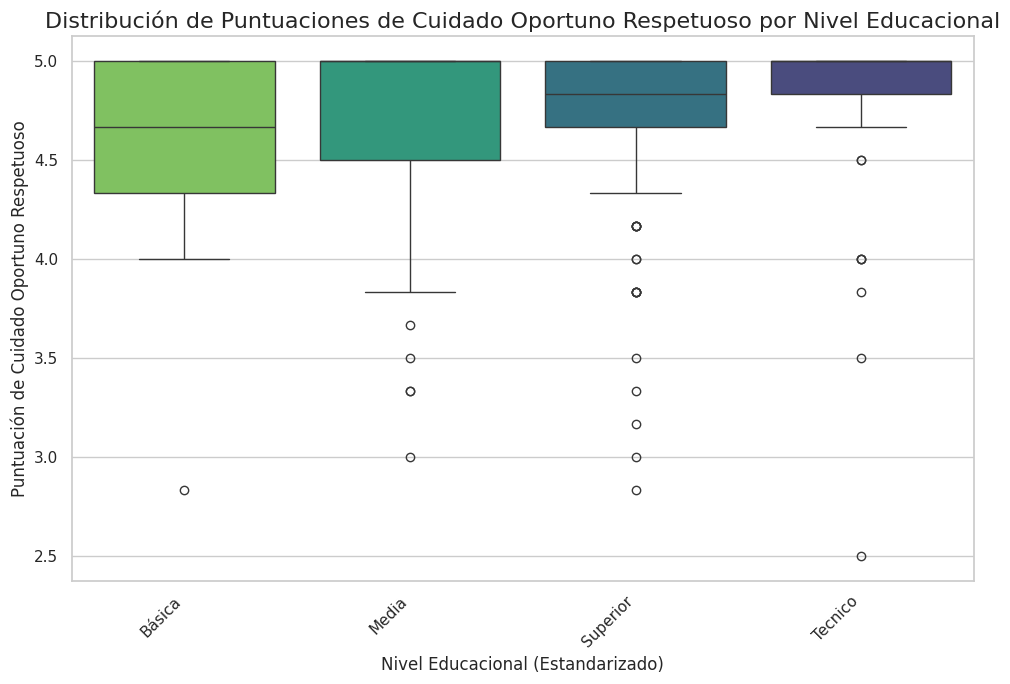

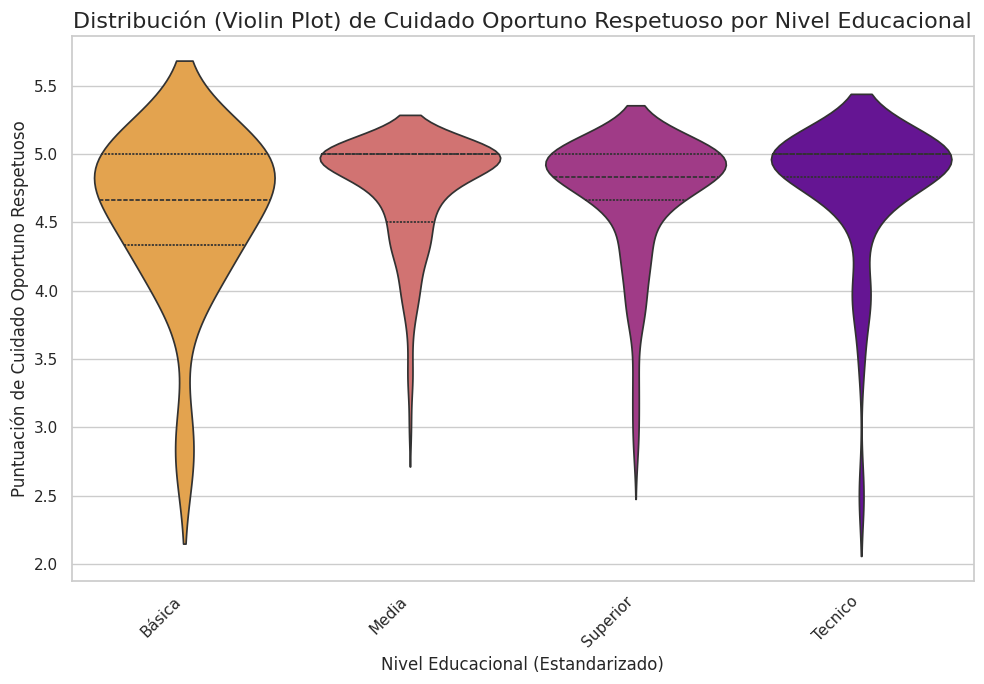

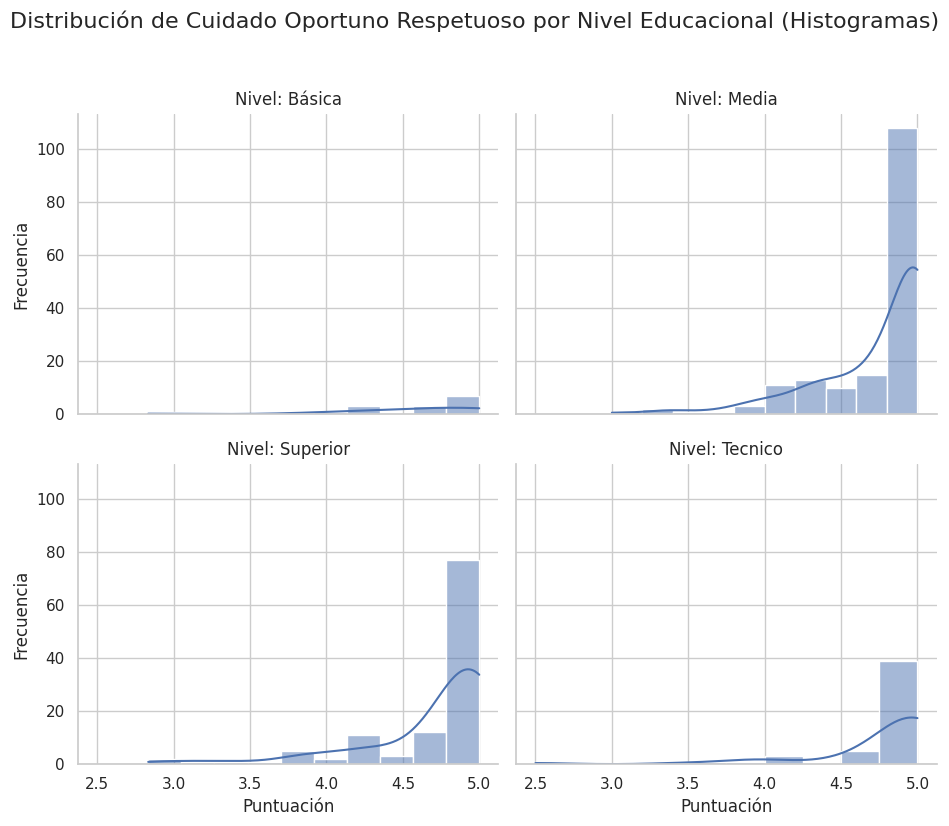

In [156]:
# 2. Visualización de la Distribución de 'Score_Cuidado_oportuno_respetuoso' por 'Nivel_educacional_std'
print("\nVisualizando la Distribución de 'Cuidado Oportuno Respetuoso' por Nivel Educacional:")

# Definir el orden de los grupos si es categórico o estandarizado de forma ordinal
# Asegurarse de que el orden es correcto para Nivel_educacional_std
educacion_order = sorted(df['Nivel_educacional_std'].dropna().unique())

# Boxplot
plt.figure(figsize=(10, 7))
sns.boxplot(
    x='Nivel_educacional_std',
    y='Score_Cuidado_oportuno_respetuoso',
    data=df,
    palette='viridis',
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución de Puntuaciones de Cuidado Oportuno Respetuoso por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Cuidado Oportuno Respetuoso', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(10, 7))
sns.violinplot(
    x='Nivel_educacional_std',
    y='Score_Cuidado_oportuno_respetuoso',
    data=df,
    palette='plasma',
    inner="quartile",
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución (Violin Plot) de Cuidado Oportuno Respetuoso por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Cuidado Oportuno Respetuoso', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Histogramas separados para cada nivel educacional
g = sns.FacetGrid(df, col="Nivel_educacional_std", col_wrap=2, height=4, aspect=1.2, col_order=educacion_order) # Usar el orden definido
g.map(sns.histplot, 'Score_Cuidado_oportuno_respetuoso', kde=True, bins=10)
g.fig.suptitle('Distribución de Cuidado Oportuno Respetuoso por Nivel Educacional (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("Nivel: {col_name}")
plt.tight_layout()
plt.show()

In [157]:
# 3. Prueba de Supuestos para Análisis Inferencial (ANOVA o Kruskal-Wallis)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---")

# Identificar los grupos únicos de nivel educacional que tienen datos para la dimensión actual
educacion_levels_cuidado_oportuno_respetuoso = df['Nivel_educacional_std'].dropna().unique()
valid_educacion_levels_cuidado_oportuno_respetuoso = [
    level for level in educacion_levels_cuidado_oportuno_respetuoso
    if len(df[df['Nivel_educacional_std'] == level].dropna(subset=['Score_Cuidado_oportuno_respetuoso'])) > 0
]

print(f"Grupos de Nivel Educacional con datos válidos para 'Cuidado_oportuno_respetuoso': {valid_educacion_levels_cuidado_oportuno_respetuoso}")

if len(valid_educacion_levels_cuidado_oportuno_respetuoso) >= 2:
    # b) Normalidad dentro de cada grupo
    print("\nPrueba de Normalidad de 'Score_Cuidado_oportuno_respetuoso' dentro de cada grupo de Nivel Educacional:")
    educacion_groups_cuidado_oportuno_respetuoso = df.groupby('Nivel_educacional_std')['Score_Cuidado_oportuno_respetuoso']

    normalidad_results_cuidado_oportuno_respetuoso_educacion = {}
    for name, group in educacion_groups_cuidado_oportuno_respetuoso:
        group_cleaned = group.dropna()
        if len(group_cleaned) > 3: # Shapiro-Wilk requiere al menos 4 muestras
            stat_sw, p_value_sw = stats.shapiro(group_cleaned)
            normalidad_results_cuidado_oportuno_respetuoso_educacion[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group_cleaned)}
        else:
            normalidad_results_cuidado_oportuno_respetuoso_educacion[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group_cleaned), 'Note': 'Not enough data for Shapiro-Wilk'}

    normalidad_df_cuidado_oportuno_respetuoso_educacion = pd.DataFrame(normalidad_results_cuidado_oportuno_respetuoso_educacion).T
    display(normalidad_df_cuidado_oportuno_respetuoso_educacion.style
        .set_caption("Normalidad de 'Cuidado Oportuno Respetuoso' por Grupo (Shapiro-Wilk)")
        .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
        .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
    )

    print("\nInterpretación de la Normalidad:")
    print("- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.")
    print("- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.")

    # c) Homogeneidad de Varianzas (Levene's Test)
    print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

    # Preparar los datos por grupo para Levene's test
    group_data_cuidado_oportuno_respetuoso_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Cuidado_oportuno_respetuoso'].dropna().values
        for level in valid_educacion_levels_cuidado_oportuno_respetuoso
    ]

    # Levene's Test requiere al menos 2 grupos con datos
    if len(group_data_cuidado_oportuno_respetuoso_educacion) >= 2 and all(len(g) > 0 for g in group_data_cuidado_oportuno_respetuoso_educacion):
        stat_levene_cuidado_oportuno_respetuoso_educacion, p_value_levene_cuidado_oportuno_respetuoso_educacion = stats.levene(*group_data_cuidado_oportuno_respetuoso_educacion)
        print(f"Estadístico de Levene: {stat_levene_cuidado_oportuno_respetuoso_educacion:.4f}")
        print(f"Valor p: {p_value_levene_cuidado_oportuno_respetuoso_educacion:.4f}")

        if p_value_levene_cuidado_oportuno_respetuoso_educacion < 0.05:
            print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
            print("Si se usa ANOVA, se debería considerar usar ANOVA de Welch.")
        else:
            print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
            print("Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.")
    else:
        print("Advertencia: No hay suficientes grupos o datos (mínimo 2 grupos con datos) para realizar la Prueba de Levene.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---
Grupos de Nivel Educacional con datos válidos para 'Cuidado_oportuno_respetuoso': ['Tecnico', 'Superior', 'Media', 'Básica']

Prueba de Normalidad de 'Score_Cuidado_oportuno_respetuoso' dentro de cada grupo de Nivel Educacional:


,Shapiro-Wilk p-value,N
Básica,0.0010,15
Media,0.0000,165
Superior,0.0000,115
Tecnico,0.0000,50



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.
- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 0.6512
Valor p: 0.5827
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.


In [158]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---")

# ANOVA (Análisis de Varianza) es paramétrico y compara medias.
# Kruskal-Wallis es no paramétrico y compara distribuciones (medianas si las distribuciones son similares).
# Kruskal-Wallis es más robusto si los supuestos de ANOVA (normalidad, homogeneidad de varianzas) no se cumplen.

if len(valid_educacion_levels_cuidado_oportuno_respetuoso) >= 2:
    # Opción 1: Kruskal-Wallis Test (No paramétrica - compara distribuciones/medianas)
    print("\nAplicando la Prueba de Kruskal-Wallis (No Paramétrica):")

    # Prepara los datos por grupo para Kruskal-Wallis
    kruskal_data_cuidado_oportuno_respetuoso_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Cuidado_oportuno_respetuoso'].dropna().values
        for level in valid_educacion_levels_cuidado_oportuno_respetuoso
    ]

    # Realiza la prueba solo si hay datos en al menos 2 grupos
    if len(kruskal_data_cuidado_oportuno_respetuoso_educacion) >= 2 and all(len(g) > 0 for g in kruskal_data_cuidado_oportuno_respetuoso_educacion):
        stat_kruskal_cuidado_oportuno_respetuoso_educacion, p_value_kruskal_cuidado_oportuno_respetuoso_educacion = stats.kruskal(*kruskal_data_cuidado_oportuno_respetuoso_educacion)
        print(f"Estadístico de Kruskal-Wallis H: {stat_kruskal_cuidado_oportuno_respetuoso_educacion:.4f}")
        print(f"Valor p: {p_value_kruskal_cuidado_oportuno_respetuoso_educacion:.4f}")

        # Interpretación del resultado de Kruskal-Wallis
        if p_value_kruskal_cuidado_oportuno_respetuoso_educacion < 0.05:
            print("\nConclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula (H0) de que las distribuciones (o medianas, si las distribuciones son similares) de 'Cuidado_oportuno_respetuoso' son iguales entre los grupos de Nivel Educacional.")
            print("Existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_oportuno_respetuoso' entre al menos dos grupos de Nivel Educacional.")
            print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

            # Prueba Post-Hoc (Dunn's Test para Kruskal-Wallis)
            print("\nAplicando Prueba Post-Hoc de Dunn (Corrección de Bonferroni) para identificar las diferencias entre pares de grupos:")
            # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
            df_filtered_cor_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_cuidado_oportuno_respetuoso)].dropna(subset=['Score_Cuidado_oportuno_respetuoso', 'Nivel_educacional_std'])

            # Verificar que hay suficientes datos después del filtrado
            if not df_filtered_cor_edu.empty:
                # Usar scikit-posthocs para Dunn's test
                dunn_results_cuidado_oportuno_respetuoso_educacion = pairwise_dunn(
                    a=df_filtered_cor_edu['Score_Cuidado_oportuno_respetuoso'],
                    g=df_filtered_cor_edu['Nivel_educacional_std'],
                    p_adjust='bonferroni' # O 'sidak', 'fdr_bh', etc. Bonferroni es conservadora.
                )
                display(dunn_results_cuidado_oportuno_respetuoso_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Dunn (Corrección de Bonferroni)"))
                print("\nInterpretación de Dunn's Test:")
                print("- Cada celda muestra el p-value ajustado para la comparación entre los grupos en la fila y columna.")
                print("- Un p-value ajustado < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
            else:
                print("Advertencia: No hay suficientes datos para realizar la Prueba Post-Hoc de Dunn después de filtrar por niveles educacionales válidos.")

        else:
            print("\nConclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula (H0).")
            print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_oportuno_respetuoso' entre los grupos de Nivel Educacional.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos para realizar la Prueba de Kruskal-Wallis.")


    # Opción 2: ANOVA (Paramétrica - compara medias)
    print("\n--- Opcional: One-way ANOVA (Paramétrica) ---")
    print("Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.")

    if len(group_data_cuidado_oportuno_respetuoso_educacion) >= 2 and all(len(g) > 1 for g in group_data_cuidado_oportuno_respetuoso_educacion): # ANOVA requiere al menos 2 datos por grupo
        # Decide si usar ANOVA estándar o Welch basado en Levene's test (si fue calculado)
        use_welch_anova_cuidado_oportuno_respetuoso_educacion = False # Default to False
        if 'p_value_levene_cuidado_oportuno_respetuoso_educacion' in locals() and not np.isnan(p_value_levene_cuidado_oportuno_respetuoso_educacion) and p_value_levene_cuidado_oportuno_respetuoso_educacion < 0.05:
            use_welch_anova_cuidado_oportuno_respetuoso_educacion = True
            print("\nUsando ANOVA de Welch (no asume varianzas iguales) debido a resultado significativo de Levene's test.")
        else:
            print("\nUsando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).")


        if use_welch_anova_cuidado_oportuno_respetuoso_educacion:
            # Usar pingouin para ANOVA de Welch
            try:
                anova_results_cuidado_oportuno_respetuoso_educacion = pg.welch_anova(
                    data=df.dropna(subset=['Score_Cuidado_oportuno_respetuoso', 'Nivel_educacional_std']),
                    dv='Score_Cuidado_oportuno_respetuoso',
                    between='Nivel_educacional_std'
                )
                display(anova_results_cuidado_oportuno_respetuoso_educacion.style.set_caption("Resultados de ANOVA de Welch usando Pingouin"))
                p_value_anova_cuidado_oportuno_respetuoso_educacion = anova_results_cuidado_oportuno_respetuoso_educacion['p-unc'].iloc[0] # Pingouin usa 'p-unc' para el p sin corregir
            except Exception as e:
                print(f"Error al realizar ANOVA de Welch con Pingouin: {e}")
                p_value_anova_cuidado_oportuno_respetuoso_educacion = np.nan # Marcar como no calculado

        else:
            # Usar scipy para ANOVA estándar
            try:
                stat_anova_cuidado_oportuno_respetuoso_educacion, p_value_anova_cuidado_oportuno_respetuoso_educacion = stats.f_oneway(*group_data_cuidado_oportuno_respetuoso_educacion)
                print(f"Estadístico F (ANOVA): {stat_anova_cuidado_oportuno_respetuoso_educacion:.4f}")
                print(f"Valor p (ANOVA): {p_value_anova_cuidado_oportuno_respetuoso_educacion:.4f}")
            except Exception as e:
                 print(f"Error al realizar ANOVA estándar con Scipy: {e}")
                 p_value_anova_cuidado_oportuno_respetuoso_educacion = np.nan


        # Interpretación del resultado de ANOVA
        if not np.isnan(p_value_anova_cuidado_oportuno_respetuoso_educacion):
            if p_value_anova_cuidado_oportuno_respetuoso_educacion < 0.05:
                print("\nConclusión (ANOVA): El valor p es menor que el nivel de significancia (0.05).")
                print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Cuidado_oportuno_respetuoso' son iguales entre los grupos de Nivel Educacional.")
                print("Existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Cuidado_oportuno_respetuoso' entre al menos dos grupos de Nivel Educacional.")
                print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

                # Prueba Post-Hoc (Tukey HSD para ANOVA estándar, Games-Howell para Welch)
                print("\nAplicando Prueba Post-Hoc:")
                if use_welch_anova_cuidado_oportuno_respetuoso_educacion:
                     print("Usando Games-Howell (para ANOVA de Welch) para identificar las diferencias entre pares de grupos:")
                     try:
                         # Usar pingouin para Games-Howell
                         games_howell_results_cuidado_oportuno_respetuoso_educacion = pg.pairwise_gameshowell(
                            data=df.dropna(subset=['Score_Cuidado_oportuno_respetuoso', 'Nivel_educacional_std']),
                            dv='Score_Cuidado_oportuno_respetuoso',
                            between='Nivel_educacional_std'
                         )
                         display(games_howell_results_cuidado_oportuno_respetuoso_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Games-Howell"))
                         print("\nInterpretación de Games-Howell:")
                         print("- La columna 'p-unc' muestra el p-value sin corregir, y 'p-corr' muestra el p-value ajustado.")
                         print("- Un 'p-corr' < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
                     except Exception as e:
                         print(f"Error al realizar Games-Howell con Pingouin: {e}")

                else:
                    print("Usando Tukey HSD (para ANOVA estándar) para identificar las diferencias entre pares de grupos:")
                    # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
                    df_filtered_cor_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_cuidado_oportuno_respetuoso)].dropna(subset=['Score_Cuidado_oportuno_respetuoso', 'Nivel_educacional_std'])

                    # Verificar que hay suficientes datos después del filtrado y que hay variabilidad dentro de los grupos
                    if not df_filtered_cor_edu.empty and df_filtered_cor_edu.groupby('Nivel_educacional_std')['Score_Cuidado_oportuno_respetuoso'].std().min() > 0:
                        try:
                            # Usar statsmodels para Tukey HSD
                            tukey_results_cuidado_oportuno_respetuoso_educacion = pairwise_tukeyhsd(
                                endog=df_filtered_cor_edu['Score_Cuidado_oportuno_respetuoso'],
                                groups=df_filtered_cor_edu['Nivel_educacional_std'],
                                alpha=0.05
                            )
                            print(tukey_results_cuidado_oportuno_respetuoso_educacion)
                            print("\nInterpretación de Tukey HSD:")
                            print("- 'meandiff' es la diferencia de medias entre los grupos.")
                            print("- 'lower' y 'upper' son los límites del intervalo de confianza del 95% para la diferencia de medias.")
                            print("- 'reject' es True si la diferencia es estadísticamente significativa (p < 0.05), False en caso contrario.")
                        except ValueError as e:
                            print(f"Advertencia: No se pudo realizar Tukey HSD. Error: {e}")
                            print("Esto puede ocurrir si hay grupos con varianza cero (todos los valores son iguales) o si no hay suficientes observaciones en los grupos.")
                        except Exception as e:
                             print(f"Error al realizar Tukey HSD: {e}")
                    else:
                         print("Advertencia: No hay suficientes datos o variabilidad dentro de los grupos para realizar la Prueba Post-Hoc de Tukey HSD.")
            else:
                print("\nConclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).")
                print("No se puede rechazar la hipótesis nula (H0).")
                print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Cuidado_oportuno_respetuoso' entre los grupos de Nivel Educacional.")
        else:
             print("ANOVA/Welch ANOVA no pudo ser calculado.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos (mínimo 2 por grupo) para realizar el T-test.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---

Aplicando la Prueba de Kruskal-Wallis (No Paramétrica):
Estadístico de Kruskal-Wallis H: 5.6470
Valor p: 0.1301

Conclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Cuidado_oportuno_respetuoso' entre los grupos de Nivel Educacional.

--- Opcional: One-way ANOVA (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.

Usando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico F (ANOVA): 1.0169
Valor p (ANOVA): 0.3853

Conclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia sufic

In [159]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

if len(valid_educacion_levels_cuidado_oportuno_respetuoso) >= 2:
    print("\nCalculando el Tamaño del Efecto para múltiples grupos:")

    # Para ANOVA, el tamaño del efecto comúnmente usado es eta cuadrado (η²).
    # Para Kruskal-Wallis, se puede usar eta cuadrado basado en H.

    # Calcular eta cuadrado (η²) para ANOVA (si se realizó)
    if 'anova_results_cuidado_oportuno_respetuoso_educacion' in locals() and isinstance(anova_results_cuidado_oportuno_respetuoso_educacion, pd.DataFrame):
        print("\nCalculando Eta Cuadrado (η²) para ANOVA:")
        try:
            # Pingouin calcula η² (eta-squared) o η²p (partial eta-squared)
            eta_squared_anova_cuidado_oportuno_respetuoso_educacion = anova_results_cuidado_oportuno_respetuoso_educacion['eta-squared'].iloc[0]
            print(f"Eta Cuadrado (η²) para la prueba general (ANOVA): {eta_squared_anova_cuidado_oportuno_respetuoso_educacion:.4f}")

            # Interpretación del tamaño del efecto eta cuadrado (Cohen, 1988)
            print("\nInterpretación del Tamaño del Efecto (Eta Cuadrado η²):")
            if eta_squared_anova_cuidado_oportuno_respetuoso_educacion >= 0.14:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_oportuno_respetuoso_educacion:.2f}) es grande.")
                print("  El Nivel Educacional explica una proporción sustancial de la variabilidad en la puntuación de 'Cuidado_oportuno_respetuoso'.")
            elif eta_squared_anova_cuidado_oportuno_respetuoso_educacion >= 0.06:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_oportuno_respetuoso_educacion:.2f}) es mediano.")
                print("  El Nivel Educacional explica una proporción moderada de la variabilidad.")
            elif eta_squared_anova_cuidado_oportuno_respetuoso_educacion >= 0.01:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_oportuno_respetuoso_educacion:.2f}) es pequeño.")
                print("  El Nivel Educacional explica una pequeña proporción de la variabilidad.")
            else:
                print(f"- El tamaño del efecto ({eta_squared_anova_cuidado_oportuno_respetuoso_educacion:.2f}) es muy pequeño.")
                print("  Indica que el Nivel Educacional tiene una influencia mínima en la variabilidad de 'Cuidado_oportuno_respetuoso' en esta muestra.")
        except Exception as e:
             print(f"Error al calcular Eta Cuadrado con Pingouin: {e}")

    # Calcular eta cuadrado basado en H para Kruskal-Wallis (si se realizó)
    if 'stat_kruskal_cuidado_oportuno_respetuoso_educacion' in locals() and not np.isnan(stat_kruskal_cuidado_oportuno_respetuoso_educacion):
        print("\nCalculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:")
        N_cuidado_oportuno_respetuoso_educacion = df['Score_Cuidado_oportuno_respetuoso'].dropna().shape[0]
        # Epsilon squared (preferido para Kruskal-Wallis)
        if N_cuidado_oportuno_respetuoso_educacion > 0:
            epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion = (stat_kruskal_cuidado_oportuno_respetuoso_educacion / (N_cuidado_oportuno_respetuoso_educacion + 1))
            print(f"Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: {epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion:.4f}")

            # Interpretación similar a eta cuadrado
            print("\nInterpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):")
            if epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion >= 0.138: # Aproximaciones para no paramétrico
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion:.2f}) es grande.")
            elif epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion >= 0.059:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion:.2f}) es mediano.")
            elif epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion >= 0.01:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion:.2f}) es pequeño.")
            else:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion:.2f}) es muy pequeño.")

        else:
            print("Advertencia: No hay suficientes datos para calcular el tamaño del efecto (Epsilon Cuadrado).")


    # Tamaño del efecto para comparaciones post-hoc (si se realizaron)
    if 'dunn_results_cuidado_oportuno_respetuoso_educacion' in locals() and not dunn_results_cuidado_oportuno_respetuoso_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver p-values ajustados arriba).")
         print("Para cada par significativo, la diferencia de medianas o rangos promedio observada en las estadísticas descriptivas da una idea de la dirección y magnitud de la diferencia.")
    elif 'games_howell_results_cuidado_oportuno_respetuoso_educacion' in locals() and isinstance(games_howell_results_cuidado_oportuno_respetuoso_educacion, pd.DataFrame) and not games_howell_results_cuidado_oportuno_respetuoso_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'diff' y 'p-corr' arriba).")
         print("'diff' muestra la diferencia media entre pares, y 'p-corr' su significancia.")
    elif 'tukey_results_cuidado_oportuno_respetuoso_educacion' in locals() and tukey_results_cuidado_oportuno_respetuoso_educacion is not None:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'meandiff' y 'reject' arriba).")
         print("'meandiff' muestra la diferencia media entre pares, y 'reject' su significancia.")
else:
    print("\nAdvertencia: No se pudieron realizar cálculos de tamaño del efecto ya que no hay suficientes grupos con datos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto para múltiples grupos:

Calculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:
Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: 0.0163

Interpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):
- El tamaño del efecto (0.02) es pequeño.


In [160]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Cuidado_oportuno_respetuoso' según Nivel Educacional ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Cuidado_oportuno_respetuoso' entre los 4 grupos de Nivel Educacional Estandarizado.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).")

print("\nResultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):")

# Priorizar la interpretación basada en Kruskal-Wallis si se hizo y es significativo
if 'p_value_kruskal_cuidado_oportuno_respetuoso_educacion' in locals() and not np.isnan(p_value_kruskal_cuidado_oportuno_respetuoso_educacion):
    if p_value_kruskal_cuidado_oportuno_respetuoso_educacion < 0.05:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_cuidado_oportuno_respetuoso_educacion:.4f}) indica una diferencia estadísticamente significativa en las distribuciones (medianas) de las puntuaciones de 'Cuidado_oportuno_respetuoso' entre los grupos de Nivel Educacional.")
        print("- Esto sugiere que la percepción del cuidado oportuno y respetuoso difiere significativamente según el nivel educativo.")
        print("- Las pruebas post-hoc de Dunn identifican específicamente qué pares de grupos muestran diferencias significativas.")
        if 'dunn_results_cuidado_oportuno_respetuoso_educacion' in locals() and not dunn_results_cuidado_oportuno_respetuoso_educacion.empty:
            print("  Revisar la tabla de resultados de Dunn para ver las comparaciones significativas.")
        else:
            print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_cuidado_oportuno_respetuoso_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_oportuno_respetuoso' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.")

# Si Kruskal-Wallis no fue significativo o no se hizo, considerar la interpretación de ANOVA si se hizo
elif 'p_value_anova_cuidado_oportuno_respetuoso_educacion' in locals() and not np.isnan(p_value_anova_cuidado_oportuno_respetuoso_educacion):
    if p_value_anova_cuidado_oportuno_respetuoso_educacion < 0.05:
         print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_cuidado_oportuno_respetuoso_educacion:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Cuidado_oportuno_respetuoso' entre los grupos de Nivel Educacional.")
         print("- Esto sugiere que la percepción del cuidado oportuno y respetuoso difiere significativamente según el nivel educativo.")
         print("- Las pruebas post-hoc (Tukey HSD o Games-Howell) identifican específicamente qué pares de grupos muestran diferencias significativas.")
         if 'tukey_results_cuidado_oportuno_respetuoso_educacion' in locals() and tukey_results_cuidado_oportuno_respetuoso_educacion is not None:
            print("  Revisar la tabla de resultados de Tukey HSD para ver las comparaciones significativas.")
         elif 'games_howell_results_cuidado_oportuno_respetuoso_educacion' in locals() and isinstance(games_howell_results_cuidado_oportuno_respetuoso_educacion, pd.DataFrame) and not games_howell_results_cuidado_oportuno_respetuoso_educacion.empty:
             print("  Revisar la tabla de resultados de Games-Howell para ver las comparaciones significativas.")
         else:
             print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_cuidado_oportuno_respetuoso_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_oportuno_respetuoso' entre los grupos de Nivel Educacional basado en esta prueba paramétrica.")

else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes o problemas en los cálculos.")


print("\nResultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):")
if 'eta_squared_anova_cuidado_oportuno_respetuoso_educacion' in locals() and not np.isnan(eta_squared_anova_cuidado_oportuno_respetuoso_educacion):
    effect_size_interpretation_eta_cor = 'muy pequeña' if eta_squared_anova_cuidado_oportuno_respetuoso_educacion < 0.01 else ('pequeña' if eta_squared_anova_cuidado_oportuno_respetuoso_educacion < 0.06 else ('mediana' if eta_squared_anova_cuidado_oportuno_respetuoso_educacion < 0.14 else 'grande'))
    print(f"- El tamaño del efecto (Eta Cuadrado η²) para ANOVA fue de {eta_squared_anova_cuidado_oportuno_respetuoso_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_eta_cor}.")
elif 'epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion' in locals() and not np.isnan(epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion):
    effect_size_interpretation_epsilon_cor = 'muy pequeña' if epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion < 0.01 else ('pequeña' if epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion < 0.059 else ('mediana' if epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion < 0.138 else 'grande'))
    print(f"- El tamaño del efecto (Epsilon Cuadrado ε²) para Kruskal-Wallis fue de {epsilon_squared_kruskal_cuidado_oportuno_respetuoso_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_epsilon_cor}.")
else:
     print("- No se pudo calcular el tamaño del efecto global.")

print("\nRecomendaciones Adicionales para 'Cuidado_oportuno_respetuoso' por Nivel Educacional:")
print("- Si se encontraron diferencias significativas, investigar cómo el nivel educativo de las mujeres puede influir en su percepción del tiempo de espera, la claridad de la información proporcionada, o el trato recibido por parte del personal de salud.")
print("- Evaluar si existen barreras de comunicación o diferencias en el acceso a la información que afecten desproporcionadamente a mujeres con ciertos niveles educativos.")
print("- Considerar la necesidad de adaptar la comunicación y los procesos para asegurar que todas las mujeres se sientan atendidas de manera oportuna y reciban un trato respetuoso, independientemente de su nivel educativo.")
print("- Implementar estrategias de capacitación para el personal de salud que promuevan la comunicación efectiva y el trato respetuoso con pacientes de diversos antecedentes educativos, asegurando que la atención sea sensible a las diferencias culturales y sociales.")


print("\n--- Fin del Análisis de 'Cuidado_oportuno_respetuoso' según Nivel_educacional_std ---")


--- Conclusiones del Análisis 'Cuidado_oportuno_respetuoso' según Nivel Educacional ---
- Se realizó el análisis comparando las puntuaciones de 'Cuidado_oportuno_respetuoso' entre los 4 grupos de Nivel Educacional Estandarizado.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).

Resultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):
- La prueba de Kruskal-Wallis (0.1301) no encontró una diferencia estadísticamente significativa.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Cuidado_oportuno_respetuoso' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):
- El tamaño del efecto (Epsilon Cuadrado ε²) 

### 6.4.5 Análisis por Dimensión (Ambiente_fisico_confortable) sugún Nivel_educacional ❌

In [161]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.4.4 pero esta vez con la dimensión Ambiente_fisico_confortable según Nivel_educacional_std, entendiendo y siendo muy cuidadoso que Nivel_educacional_std es una variable que separa la muestra en 4

print("\n--- Análisis Específico: Puntuación de 'Ambiente_fisico_confortable' según Nivel_educacional_std ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Ambiente_fisico_confortable' por 'Nivel_educacional_std'
print("\nEstadísticas Descriptivas para 'Ambiente_fisico_confortable' por Nivel_educacional_std:")
educacion_ambiente_fisico_stats = df.groupby('Nivel_educacional_std')['Score_Ambiente_fisico_confortable'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(educacion_ambiente_fisico_stats.style
    .set_caption("Estadísticas Descriptivas de 'Ambiente Físico Confortable' por Nivel Educacional")
    .format("{:.2f}")
    .background_gradient(cmap='Blues', axis=1)
    .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los 4 grupos de nivel educacional.")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


--- Análisis Específico: Puntuación de 'Ambiente_fisico_confortable' según Nivel_educacional_std ---

Estadísticas Descriptivas para 'Ambiente_fisico_confortable' por Nivel_educacional_std:


Nivel_educacional_std,Básica,Media,Superior,Tecnico
count,15.00,165.00,115.00,50.00
mean,4.87,4.79,4.79,4.84
median,5.00,5.00,5.00,5.00
std,0.37,0.37,0.35,0.31
min,3.60,2.80,3.20,3.80
max,5.00,5.00,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los 4 grupos de nivel educacional.
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Ambiente Físico Confortable' por Nivel Educacional:


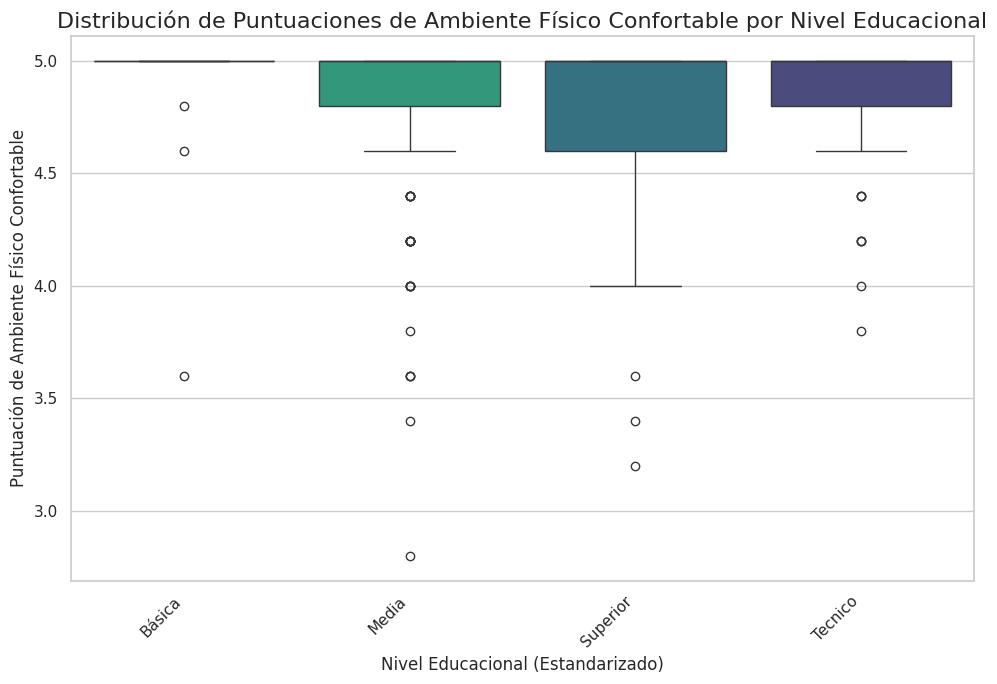

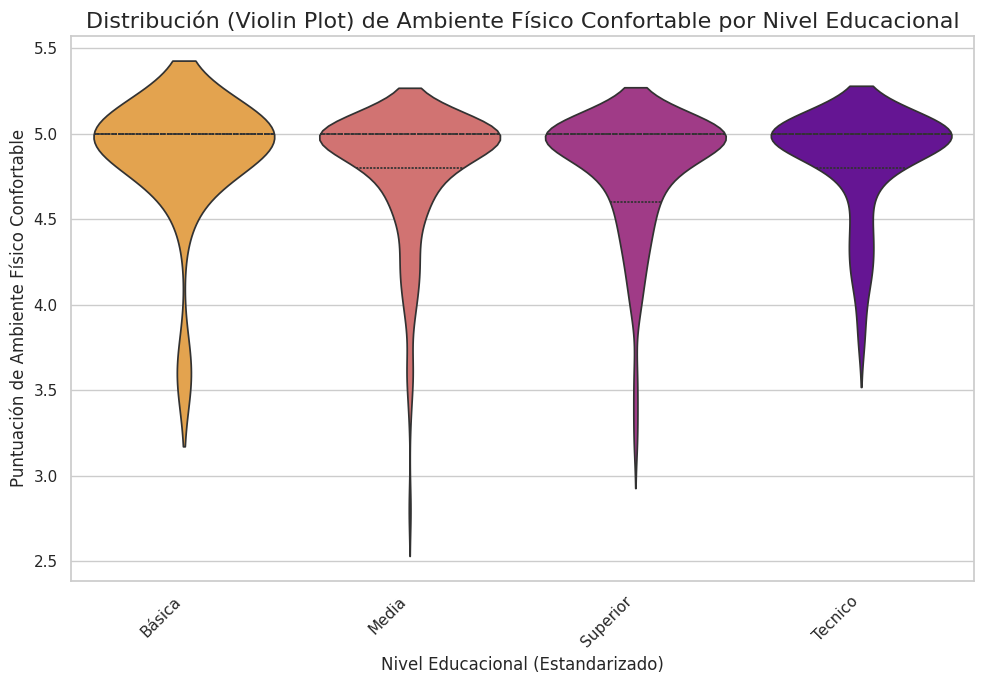

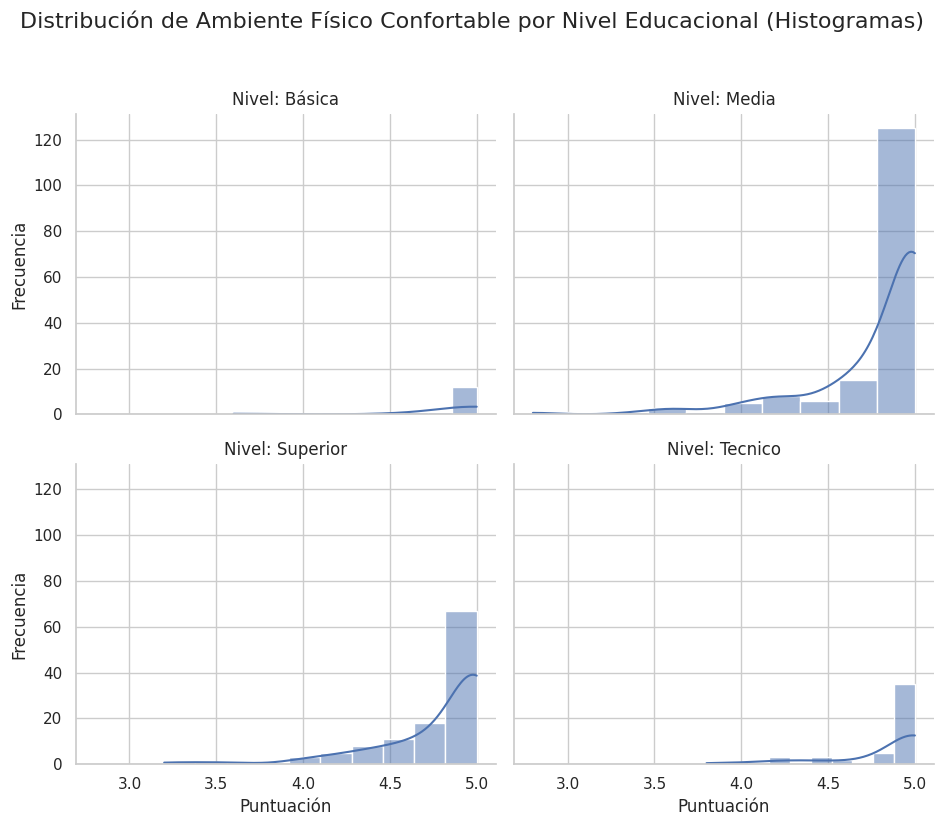

In [162]:
# 2. Visualización de la Distribución de 'Score_Ambiente_fisico_confortable' por 'Nivel_educacional_std'
print("\nVisualizando la Distribución de 'Ambiente Físico Confortable' por Nivel Educacional:")

# Definir el orden de los grupos si es categórico o estandarizado de forma ordinal
# Asegurarse de que el orden es correcto para Nivel_educacional_std
educacion_order = sorted(df['Nivel_educacional_std'].dropna().unique())

# Boxplot
plt.figure(figsize=(10, 7))
sns.boxplot(
    x='Nivel_educacional_std',
    y='Score_Ambiente_fisico_confortable',
    data=df,
    palette='viridis',
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución de Puntuaciones de Ambiente Físico Confortable por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Ambiente Físico Confortable', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(10, 7))
sns.violinplot(
    x='Nivel_educacional_std',
    y='Score_Ambiente_fisico_confortable',
    data=df,
    palette='plasma',
    inner="quartile",
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución (Violin Plot) de Ambiente Físico Confortable por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Ambiente Físico Confortable', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Histogramas separados para cada nivel educacional
g = sns.FacetGrid(df, col="Nivel_educacional_std", col_wrap=2, height=4, aspect=1.2, col_order=educacion_order) # Usar el orden definido
g.map(sns.histplot, 'Score_Ambiente_fisico_confortable', kde=True, bins=10)
g.fig.suptitle('Distribución de Ambiente Físico Confortable por Nivel Educacional (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("Nivel: {col_name}")
plt.tight_layout()
plt.show()

In [163]:
# 3. Prueba de Supuestos para Análisis Inferencial (ANOVA o Kruskal-Wallis)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---")

# Identificar los grupos únicos de nivel educacional que tienen datos para la dimensión actual
educacion_levels_ambiente_fisico = df['Nivel_educacional_std'].dropna().unique()
valid_educacion_levels_ambiente_fisico = [
    level for level in educacion_levels_ambiente_fisico
    if len(df[df['Nivel_educacional_std'] == level].dropna(subset=['Score_Ambiente_fisico_confortable'])) > 0
]

print(f"Grupos de Nivel Educacional con datos válidos para 'Ambiente_fisico_confortable': {valid_educacion_levels_ambiente_fisico}")

if len(valid_educacion_levels_ambiente_fisico) >= 2:
    # b) Normalidad dentro de cada grupo
    print("\nPrueba de Normalidad de 'Score_Ambiente_fisico_confortable' dentro de cada grupo de Nivel Educacional:")
    educacion_groups_ambiente_fisico = df.groupby('Nivel_educacional_std')['Score_Ambiente_fisico_confortable']

    normalidad_results_ambiente_fisico_educacion = {}
    for name, group in educacion_groups_ambiente_fisico:
        group_cleaned = group.dropna()
        if len(group_cleaned) > 3: # Shapiro-Wilk requiere al menos 4 muestras
            stat_sw, p_value_sw = stats.shapiro(group_cleaned)
            normalidad_results_ambiente_fisico_educacion[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group_cleaned)}
        else:
            normalidad_results_ambiente_fisico_educacion[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group_cleaned), 'Note': 'Not enough data for Shapiro-Wilk'}

    normalidad_df_ambiente_fisico_educacion = pd.DataFrame(normalidad_results_ambiente_fisico_educacion).T
    display(normalidad_df_ambiente_fisico_educacion.style
        .set_caption("Normalidad de 'Ambiente Físico Confortable' por Grupo (Shapiro-Wilk)")
        .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
        .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
    )

    print("\nInterpretación de la Normalidad:")
    print("- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.")
    print("- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.")

    # c) Homogeneidad de Varianzas (Levene's Test)
    print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

    # Preparar los datos por grupo para Levene's test
    group_data_ambiente_fisico_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Ambiente_fisico_confortable'].dropna().values
        for level in valid_educacion_levels_ambiente_fisico
    ]

    # Levene's Test requiere al menos 2 grupos con datos
    if len(group_data_ambiente_fisico_educacion) >= 2 and all(len(g) > 0 for g in group_data_ambiente_fisico_educacion):
        stat_levene_ambiente_fisico_educacion, p_value_levene_ambiente_fisico_educacion = stats.levene(*group_data_ambiente_fisico_educacion)
        print(f"Estadístico de Levene: {stat_levene_ambiente_fisico_educacion:.4f}")
        print(f"Valor p: {p_value_levene_ambiente_fisico_educacion:.4f}")

        if p_value_levene_ambiente_fisico_educacion < 0.05:
            print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
            print("Si se usa ANOVA, se debería considerar usar ANOVA de Welch.")
        else:
            print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
            print("Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.")
    else:
        print("Advertencia: No hay suficientes grupos o datos (mínimo 2 grupos con datos) para realizar la Prueba de Levene.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---
Grupos de Nivel Educacional con datos válidos para 'Ambiente_fisico_confortable': ['Tecnico', 'Superior', 'Media', 'Básica']

Prueba de Normalidad de 'Score_Ambiente_fisico_confortable' dentro de cada grupo de Nivel Educacional:


,Shapiro-Wilk p-value,N
Básica,0.0000,15
Media,0.0000,165
Superior,0.0000,115
Tecnico,0.0000,50



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.
- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 0.4830
Valor p: 0.6943
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.


In [164]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---")

# ANOVA (Análisis de Varianza) es paramétrico y compara medias.
# Kruskal-Wallis es no paramétrico y compara distribuciones (medianas si las distribuciones son similares).
# Kruskal-Wallis es más robusto si los supuestos de ANOVA (normalidad, homogeneidad de varianzas) no se cumplen.

if len(valid_educacion_levels_ambiente_fisico) >= 2:
    # Opción 1: Kruskal-Wallis Test (No paramétrica - compara distribuciones/medianas)
    print("\nAplicando la Prueba de Kruskal-Wallis (No Paramétrica):")

    # Prepara los datos por grupo para Kruskal-Wallis
    kruskal_data_ambiente_fisico_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Ambiente_fisico_confortable'].dropna().values
        for level in valid_educacion_levels_ambiente_fisico
    ]

    # Realiza la prueba solo si hay datos en al menos 2 grupos
    if len(kruskal_data_ambiente_fisico_educacion) >= 2 and all(len(g) > 0 for g in kruskal_data_ambiente_fisico_educacion):
        stat_kruskal_ambiente_fisico_educacion, p_value_kruskal_ambiente_fisico_educacion = stats.kruskal(*kruskal_data_ambiente_fisico_educacion)
        print(f"Estadístico de Kruskal-Wallis H: {stat_kruskal_ambiente_fisico_educacion:.4f}")
        print(f"Valor p: {p_value_kruskal_ambiente_fisico_educacion:.4f}")

        # Interpretación del resultado de Kruskal-Wallis
        if p_value_kruskal_ambiente_fisico_educacion < 0.05:
            print("\nConclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula (H0) de que las distribuciones (o medianas, si las distribuciones son similares) de 'Ambiente_fisico_confortable' son iguales entre los grupos de Nivel Educacional.")
            print("Existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente_fisico_confortable' entre al menos dos grupos de Nivel Educacional.")
            print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

            # Prueba Post-Hoc (Dunn's Test para Kruskal-Wallis)
            print("\nAplicando Prueba Post-Hoc de Dunn (Corrección de Bonferroni) para identificar las diferencias entre pares de grupos:")
            # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
            df_filtered_af_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_ambiente_fisico)].dropna(subset=['Score_Ambiente_fisico_confortable', 'Nivel_educacional_std'])

            # Verificar que hay suficientes datos después del filtrado
            if not df_filtered_af_edu.empty:
                # Usar scikit-posthocs para Dunn's test
                dunn_results_ambiente_fisico_educacion = pairwise_dunn(
                    a=df_filtered_af_edu['Score_Ambiente_fisico_confortable'],
                    g=df_filtered_af_edu['Nivel_educacional_std'],
                    p_adjust='bonferroni' # O 'sidak', 'fdr_bh', etc. Bonferroni es conservadora.
                )
                display(dunn_results_ambiente_fisico_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Dunn (Corrección de Bonferroni)"))
                print("\nInterpretación de Dunn's Test:")
                print("- Cada celda muestra el p-value ajustado para la comparación entre los grupos en la fila y columna.")
                print("- Un p-value ajustado < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
            else:
                print("Advertencia: No hay suficientes datos para realizar la Prueba Post-Hoc de Dunn después de filtrar por niveles educacionales válidos.")

        else:
            print("\nConclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula (H0).")
            print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente_fisico_confortable' entre los grupos de Nivel Educacional.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos para realizar la Prueba de Kruskal-Wallis.")


    # Opción 2: ANOVA (Paramétrica - compara medias)
    print("\n--- Opcional: One-way ANOVA (Paramétrica) ---")
    print("Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.")

    if len(group_data_ambiente_fisico_educacion) >= 2 and all(len(g) > 1 for g in group_data_ambiente_fisico_educacion): # ANOVA requiere al menos 2 datos por grupo
        # Decide si usar ANOVA estándar o Welch basado en Levene's test (si fue calculado)
        use_welch_anova_ambiente_fisico_educacion = False # Default to False
        if 'p_value_levene_ambiente_fisico_educacion' in locals() and not np.isnan(p_value_levene_ambiente_fisico_educacion) and p_value_levene_ambiente_fisico_educacion < 0.05:
            use_welch_anova_ambiente_fisico_educacion = True
            print("\nUsando ANOVA de Welch (no asume varianzas iguales) debido a resultado significativo de Levene's test.")
        else:
            print("\nUsando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).")


        if use_welch_anova_ambiente_fisico_educacion:
            # Usar pingouin para ANOVA de Welch
            try:
                anova_results_ambiente_fisico_educacion = pg.welch_anova(
                    data=df.dropna(subset=['Score_Ambiente_fisico_confortable', 'Nivel_educacional_std']),
                    dv='Score_Ambiente_fisico_confortable',
                    between='Nivel_educacional_std'
                )
                display(anova_results_ambiente_fisico_educacion.style.set_caption("Resultados de ANOVA de Welch usando Pingouin"))
                p_value_anova_ambiente_fisico_educacion = anova_results_ambiente_fisico_educacion['p-unc'].iloc[0] # Pingouin usa 'p-unc' para el p sin corregir
            except Exception as e:
                print(f"Error al realizar ANOVA de Welch con Pingouin: {e}")
                p_value_anova_ambiente_fisico_educacion = np.nan # Marcar como no calculado

        else:
            # Usar scipy para ANOVA estándar
            try:
                stat_anova_ambiente_fisico_educacion, p_value_anova_ambiente_fisico_educacion = stats.f_oneway(*group_data_ambiente_fisico_educacion)
                print(f"Estadístico F (ANOVA): {stat_anova_ambiente_fisico_educacion:.4f}")
                print(f"Valor p (ANOVA): {p_value_anova_ambiente_fisico_educacion:.4f}")
            except Exception as e:
                 print(f"Error al realizar ANOVA estándar con Scipy: {e}")
                 p_value_anova_ambiente_fisico_educacion = np.nan


        # Interpretación del resultado de ANOVA
        if not np.isnan(p_value_anova_ambiente_fisico_educacion):
            if p_value_anova_ambiente_fisico_educacion < 0.05:
                print("\nConclusión (ANOVA): El valor p es menor que el nivel de significancia (0.05).")
                print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Ambiente_fisico_confortable' son iguales entre los grupos de Nivel Educacional.")
                print("Existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Ambiente_fisico_confortable' entre al menos dos grupos de Nivel Educacional.")
                print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

                # Prueba Post-Hoc (Tukey HSD para ANOVA estándar, Games-Howell para Welch)
                print("\nAplicando Prueba Post-Hoc:")
                if use_welch_anova_ambiente_fisico_educacion:
                     print("Usando Games-Howell (para ANOVA de Welch) para identificar las diferencias entre pares de grupos:")
                     try:
                         # Usar pingouin para Games-Howell
                         games_howell_results_ambiente_fisico_educacion = pg.pairwise_gameshowell(
                            data=df.dropna(subset=['Score_Ambiente_fisico_confortable', 'Nivel_educacional_std']),
                            dv='Score_Ambiente_fisico_confortable',
                            between='Nivel_educacional_std'
                         )
                         display(games_howell_results_ambiente_fisico_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Games-Howell"))
                         print("\nInterpretación de Games-Howell:")
                         print("- La columna 'p-unc' muestra el p-value sin corregir, y 'p-corr' muestra el p-value ajustado.")
                         print("- Un 'p-corr' < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
                     except Exception as e:
                         print(f"Error al realizar Games-Howell con Pingouin: {e}")

                else:
                    print("Usando Tukey HSD (para ANOVA estándar) para identificar las diferencias entre pares de grupos:")
                    # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
                    df_filtered_af_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_ambiente_fisico)].dropna(subset=['Score_Ambiente_fisico_confortable', 'Nivel_educacional_std'])

                    # Verificar que hay suficientes datos después del filtrado y que hay variabilidad dentro de los grupos
                    # Tukey requiere al menos 2 datos por grupo con varianza > 0
                    if not df_filtered_af_edu.empty and df_filtered_af_edu.groupby('Nivel_educacional_std')['Score_Ambiente_fisico_confortable'].std().min() > 0:
                        try:
                            # Usar statsmodels para Tukey HSD
                            tukey_results_ambiente_fisico_educacion = pairwise_tukeyhsd(
                                endog=df_filtered_af_edu['Score_Ambiente_fisico_confortable'],
                                groups=df_filtered_af_edu['Nivel_educacional_std'],
                                alpha=0.05
                            )
                            print(tukey_results_ambiente_fisico_educacion)
                            print("\nInterpretación de Tukey HSD:")
                            print("- 'meandiff' es la diferencia de medias entre los grupos.")
                            print("- 'lower' y 'upper' son los límites del intervalo de confianza del 95% para la diferencia de medias.")
                            print("- 'reject' es True si la diferencia es estadísticamente significativa (p < 0.05), False en caso contrario.")
                        except ValueError as e:
                            print(f"Advertencia: No se pudo realizar Tukey HSD. Error: {e}")
                            print("Esto puede ocurrir si hay grupos con varianza cero (todos los valores son iguales) o si no hay suficientes observaciones en los grupos.")
                        except Exception as e:
                             print(f"Error al realizar Tukey HSD: {e}")
                    else:
                         print("Advertencia: No hay suficientes datos o variabilidad dentro de los grupos para realizar la Prueba Post-Hoc de Tukey HSD.")
            else:
                print("\nConclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).")
                print("No se puede rechazar la hipótesis nula (H0).")
                print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación media de 'Ambiente_fisico_confortable' entre los grupos de Nivel Educacional.")
        else:
             print("ANOVA/Welch ANOVA no pudo ser calculado.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos (mínimo 2 por grupo) para realizar el T-test.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---

Aplicando la Prueba de Kruskal-Wallis (No Paramétrica):
Estadístico de Kruskal-Wallis H: 3.5255
Valor p: 0.3175

Conclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Ambiente_fisico_confortable' entre los grupos de Nivel Educacional.

--- Opcional: One-way ANOVA (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.

Usando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico F (ANOVA): 0.4830
Valor p (ANOVA): 0.6943

Conclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia sufic

In [165]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

if len(valid_educacion_levels_ambiente_fisico) >= 2:
    print("\nCalculando el Tamaño del Efecto para múltiples grupos:")

    # Para ANOVA, el tamaño del efecto comúnmente usado es eta cuadrado (η²).
    # Para Kruskal-Wallis, se puede usar eta cuadrado basado en H.

    # Calcular eta cuadrado (η²) para ANOVA (si se realizó)
    if 'anova_results_ambiente_fisico_educacion' in locals() and isinstance(anova_results_ambiente_fisico_educacion, pd.DataFrame):
        print("\nCalculando Eta Cuadrado (η²) para ANOVA:")
        try:
            # Pingouin calcula η² (eta-squared) o η²p (partial eta-squared)
            eta_squared_anova_ambiente_fisico_educacion = anova_results_ambiente_fisico_educacion['eta-squared'].iloc[0]
            print(f"Eta Cuadrado (η²) para la prueba general (ANOVA): {eta_squared_anova_ambiente_fisico_educacion:.4f}")

            # Interpretación del tamaño del efecto eta cuadrado (Cohen, 1988)
            print("\nInterpretación del Tamaño del Efecto (Eta Cuadrado η²):")
            if eta_squared_anova_ambiente_fisico_educacion >= 0.14:
                print(f"- El tamaño del efecto ({eta_squared_anova_ambiente_fisico_educacion:.2f}) es grande.")
                print("  El Nivel Educacional explica una proporción sustancial de la variabilidad en la puntuación de 'Ambiente_fisico_confortable'.")
            elif eta_squared_anova_ambiente_fisico_educacion >= 0.06:
                print(f"- El tamaño del efecto ({eta_squared_anova_ambiente_fisico_educacion:.2f}) es mediano.")
                print("  El Nivel Educacional explica una proporción moderada de la variabilidad.")
            elif eta_squared_anova_ambiente_fisico_educacion >= 0.01:
                print(f"- El tamaño del efecto ({eta_squared_anova_ambiente_fisico_educacion:.2f}) es pequeño.")
                print("  El Nivel Educacional explica una pequeña proporción de la variabilidad.")
            else:
                print(f"- El tamaño del efecto ({eta_squared_anova_ambiente_fisico_educacion:.2f}) es muy pequeño.")
                print("  Indica que el Nivel Educacional tiene una influencia mínima en la variabilidad de 'Ambiente_fisico_confortable' en esta muestra.")
        except Exception as e:
             print(f"Error al calcular Eta Cuadrado con Pingouin: {e}")

    # Calcular eta cuadrado basado en H para Kruskal-Wallis (si se realizó)
    if 'stat_kruskal_ambiente_fisico_educacion' in locals() and not np.isnan(stat_kruskal_ambiente_fisico_educacion):
        print("\nCalculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:")
        N_ambiente_fisico_educacion = df['Score_Ambiente_fisico_confortable'].dropna().shape[0]
        # Epsilon squared (preferido para Kruskal-Wallis)
        if N_ambiente_fisico_educacion > 0:
            epsilon_squared_kruskal_ambiente_fisico_educacion = (stat_kruskal_ambiente_fisico_educacion / (N_ambiente_fisico_educacion + 1))
            print(f"Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: {epsilon_squared_kruskal_ambiente_fisico_educacion:.4f}")

            # Interpretación similar a eta cuadrado
            print("\nInterpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):")
            if epsilon_squared_kruskal_ambiente_fisico_educacion >= 0.138: # Aproximaciones para no paramétrico
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_ambiente_fisico_educacion:.2f}) es grande.")
            elif epsilon_squared_kruskal_ambiente_fisico_educacion >= 0.059:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_ambiente_fisico_educacion:.2f}) es mediano.")
            elif epsilon_squared_kruskal_ambiente_fisico_educacion >= 0.01:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_ambiente_fisico_educacion:.2f}) es pequeño.")
            else:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_ambiente_fisico_educacion:.2f}) es muy pequeño.")

        else:
            print("Advertencia: No hay suficientes datos para calcular el tamaño del efecto (Epsilon Cuadrado).")


    # Tamaño del efecto para comparaciones post-hoc (si se realizaron)
    if 'dunn_results_ambiente_fisico_educacion' in locals() and not dunn_results_ambiente_fisico_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver p-values ajustados arriba).")
         print("Para cada par significativo, la diferencia de medianas o rangos promedio observada en las estadísticas descriptivas da una idea de la dirección y magnitud de la diferencia.")
    elif 'games_howell_results_ambiente_fisico_educacion' in locals() and isinstance(games_howell_results_ambiente_fisico_educacion, pd.DataFrame) and not games_howell_results_ambiente_fisico_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'diff' y 'p-corr' arriba).")
         print("'diff' muestra la diferencia media entre pares, y 'p-corr' su significancia.")
    elif 'tukey_results_ambiente_fisico_educacion' in locals() and tukey_results_ambiente_fisico_educacion is not None:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'meandiff' y 'reject' arriba).")
         print("'meandiff' muestra la diferencia media entre pares, y 'reject' su significancia.")
else:
    print("\nAdvertencia: No se pudieron realizar cálculos de tamaño del efecto ya que no hay suficientes grupos con datos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto para múltiples grupos:

Calculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:
Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: 0.0102

Interpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):
- El tamaño del efecto (0.01) es pequeño.


In [166]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Ambiente_fisico_confortable' según Nivel Educacional ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Ambiente_fisico_confortable' entre los 4 grupos de Nivel Educacional Estandarizado.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).")

print("\nResultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):")

# Priorizar la interpretación basada en Kruskal-Wallis si se hizo y es significativo
if 'p_value_kruskal_ambiente_fisico_educacion' in locals() and not np.isnan(p_value_kruskal_ambiente_fisico_educacion):
    if p_value_kruskal_ambiente_fisico_educacion < 0.05:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_ambiente_fisico_educacion:.4f}) indica una diferencia estadísticamente significativa en las distribuciones (medianas) de las puntuaciones de 'Ambiente_fisico_confortable' entre los grupos de Nivel Educacional.")
        print("- Esto sugiere que la percepción del ambiente físico confortable difiere significativamente según el nivel educativo.")
        print("- Las pruebas post-hoc de Dunn identifican específicamente qué pares de grupos muestran diferencias significativas.")
        if 'dunn_results_ambiente_fisico_educacion' in locals() and not dunn_results_ambiente_fisico_educacion.empty:
            print("  Revisar la tabla de resultados de Dunn para ver las comparaciones significativas.")
        else:
            print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_ambiente_fisico_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Ambiente_fisico_confortable' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.")

# Si Kruskal-Wallis no fue significativo o no se hizo, considerar la interpretación de ANOVA si se hizo
elif 'p_value_anova_ambiente_fisico_educacion' in locals() and not np.isnan(p_value_anova_ambiente_fisico_educacion):
    if p_value_anova_ambiente_fisico_educacion < 0.05:
         print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_ambiente_fisico_educacion:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Ambiente_fisico_confortable' entre los grupos de Nivel Educacional.")
         print("- Esto sugiere que la percepción del ambiente físico confortable difiere significativamente según el nivel educativo.")
         print("- Las pruebas post-hoc (Tukey HSD o Games-Howell) identifican específicamente qué pares de grupos muestran diferencias significativas.")
         if 'tukey_results_ambiente_fisico_educacion' in locals() and tukey_results_ambiente_fisico_educacion is not None:
            print("  Revisar la tabla de resultados de Tukey HSD para ver las comparaciones significativas.")
         elif 'games_howell_results_ambiente_fisico_educacion' in locals() and isinstance(games_howell_results_ambiente_fisico_educacion, pd.DataFrame) and not games_howell_results_ambiente_fisico_educacion.empty:
             print("  Revisar la tabla de resultados de Games-Howell para ver las comparaciones significativas.")
         else:
             print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_ambiente_fisico_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Ambiente_fisico_confortable' entre los grupos de Nivel Educacional basado en esta prueba paramétrica.")

else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes o problemas en los cálculos.")


print("\nResultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):")
if 'eta_squared_anova_ambiente_fisico_educacion' in locals() and not np.isnan(eta_squared_anova_ambiente_fisico_educacion):
    effect_size_interpretation_eta_af = 'muy pequeña' if eta_squared_anova_ambiente_fisico_educacion < 0.01 else ('pequeña' if eta_squared_anova_ambiente_fisico_educacion < 0.06 else ('mediana' if eta_squared_anova_ambiente_fisico_educacion < 0.14 else 'grande'))
    print(f"- El tamaño del efecto (Eta Cuadrado η²) para ANOVA fue de {eta_squared_anova_ambiente_fisico_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_eta_af}.")
elif 'epsilon_squared_kruskal_ambiente_fisico_educacion' in locals() and not np.isnan(epsilon_squared_kruskal_ambiente_fisico_educacion):
    effect_size_interpretation_epsilon_af = 'muy pequeña' if epsilon_squared_kruskal_ambiente_fisico_educacion < 0.01 else ('pequeña' if epsilon_squared_kruskal_ambiente_fisico_educacion < 0.059 else ('mediana' if epsilon_squared_kruskal_ambiente_fisico_educacion < 0.138 else 'grande'))
    print(f"- El tamaño del efecto (Epsilon Cuadrado ε²) para Kruskal-Wallis fue de {epsilon_squared_kruskal_ambiente_fisico_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_epsilon_af}.")
else:
     print("- No se pudo calcular el tamaño del efecto global.")

print("\nRecomendaciones Adicionales para 'Ambiente_fisico_confortable' por Nivel Educacional:")
print("- Si se encontraron diferencias significativas, investigar si las expectativas sobre el ambiente físico (limpieza, privacidad, ruido, iluminación, etc.) varían según el nivel educativo.")
print("- Evaluar si el diseño o mantenimiento de las instalaciones impacta de manera diferencial la experiencia de las mujeres con distintos niveles educativos.")
print("- Considerar si la información sobre las instalaciones disponibles o las comodidades se comunica de manera efectiva a todos los grupos.")
print("- Utilizar estos hallazgos para identificar áreas de mejora en las instalaciones físicas o en la comunicación sobre ellas, buscando crear un ambiente más confortable y percibido positivamente por mujeres de todos los niveles educativos.")


print("\n--- Fin del Análisis de 'Ambiente_fisico_confortable' según Nivel_educacional_std ---")


--- Conclusiones del Análisis 'Ambiente_fisico_confortable' según Nivel Educacional ---
- Se realizó el análisis comparando las puntuaciones de 'Ambiente_fisico_confortable' entre los 4 grupos de Nivel Educacional Estandarizado.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).

Resultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):
- La prueba de Kruskal-Wallis (0.3175) no encontró una diferencia estadísticamente significativa.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Ambiente_fisico_confortable' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):
- El tamaño del efecto (Epsilon Cuadrado ε²) 

### 6.4.6 Análisis por Dimensión (Condiciones_contacto_madre_hijo) sugún Nivel_educacional ❌

In [167]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.4.5 pero esta vez con la dimensión Condiciones_contacto_madre_hijo según Nivel_educacional_std, entendiendo y siendo muy cuidadoso que Nivel_educacional_std es una variable que separa la muestra en 4

print("\n--- Análisis Específico: Puntuación de 'Condiciones_contacto_madre_hijo' según Nivel_educacional_std ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Condiciones_contacto_madre_hijo' por 'Nivel_educacional_std'
print("\nEstadísticas Descriptivas para 'Condiciones_contacto_madre_hijo' por Nivel_educacional_std:")
educacion_contacto_stats = df.groupby('Nivel_educacional_std')['Score_Condiciones_contacto_madre_hijo'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(educacion_contacto_stats.style
    .set_caption("Estadísticas Descriptivas de 'Condiciones Contacto Madre-Hijo' por Nivel Educacional")
    .format("{:.2f}")
    .background_gradient(cmap='Blues', axis=1)
    .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los 4 grupos de nivel educacional.")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")



--- Análisis Específico: Puntuación de 'Condiciones_contacto_madre_hijo' según Nivel_educacional_std ---

Estadísticas Descriptivas para 'Condiciones_contacto_madre_hijo' por Nivel_educacional_std:


Nivel_educacional_std,Básica,Media,Superior,Tecnico
count,15.00,165.00,115.00,50.00
mean,4.68,4.67,4.52,4.71
median,5.00,5.00,5.00,5.00
std,0.49,0.64,0.88,0.48
min,3.50,1.75,1.00,3.00
max,5.00,5.00,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los 4 grupos de nivel educacional.
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Condiciones Contacto Madre-Hijo' por Nivel Educacional:


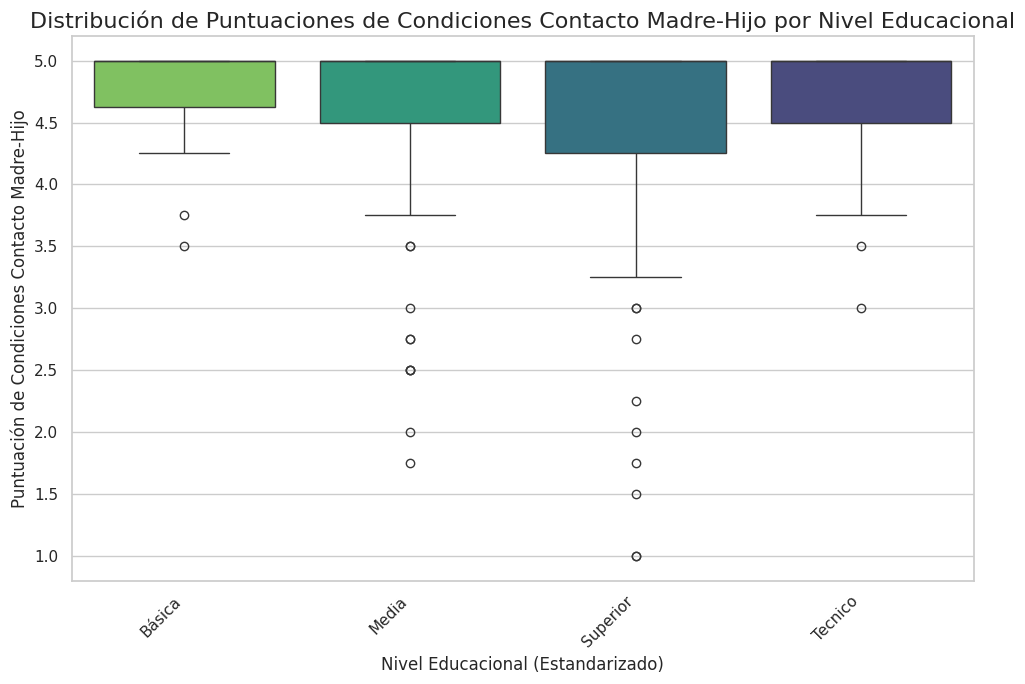

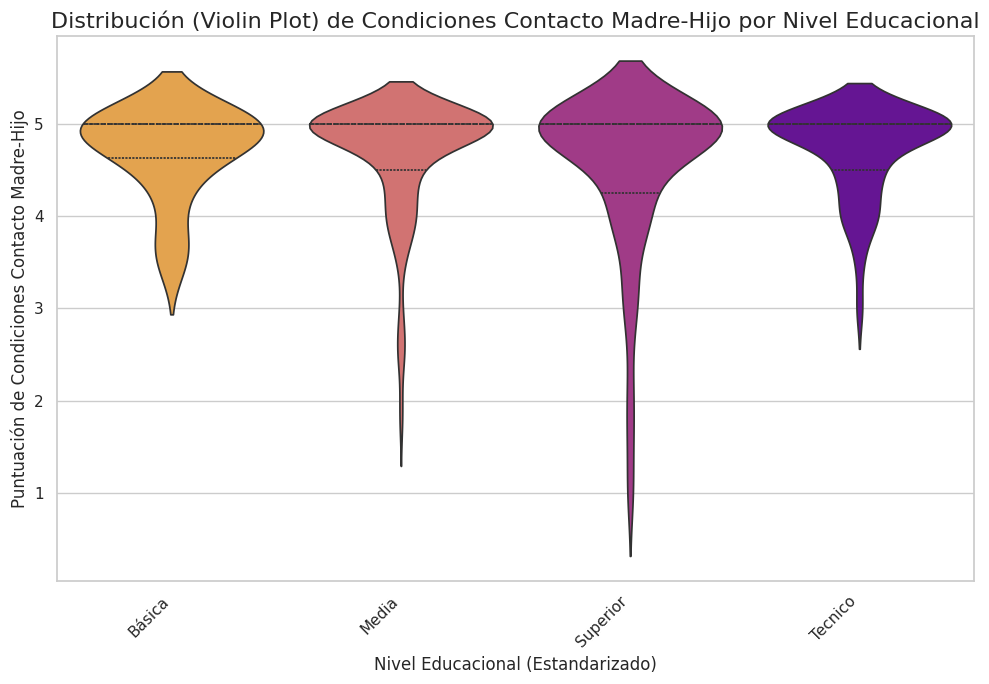

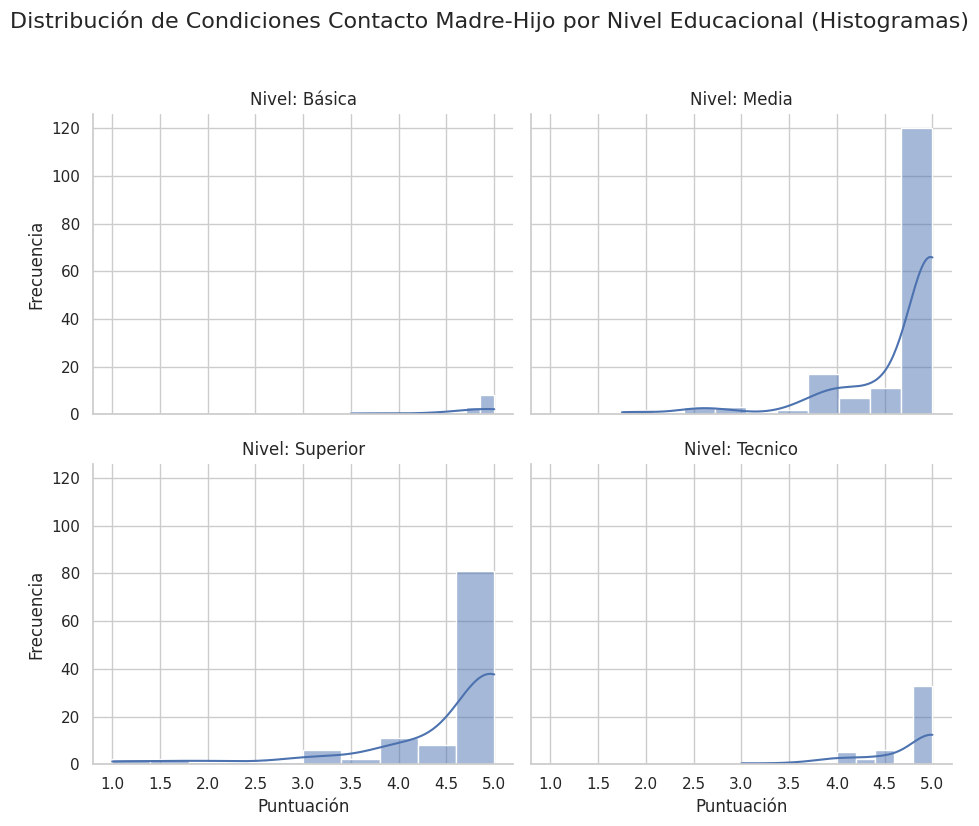

In [168]:
# 2. Visualización de la Distribución de 'Score_Condiciones_contacto_madre_hijo' por 'Nivel_educacional_std'
print("\nVisualizando la Distribución de 'Condiciones Contacto Madre-Hijo' por Nivel Educacional:")

# Definir el orden de los grupos si es categórico o estandarizado de forma ordinal
# Asegurarse de que el orden es correcto para Nivel_educacional_std
educacion_order = sorted(df['Nivel_educacional_std'].dropna().unique())

# Boxplot
plt.figure(figsize=(10, 7))
sns.boxplot(
    x='Nivel_educacional_std',
    y='Score_Condiciones_contacto_madre_hijo',
    data=df,
    palette='viridis',
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución de Puntuaciones de Condiciones Contacto Madre-Hijo por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Condiciones Contacto Madre-Hijo', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(10, 7))
sns.violinplot(
    x='Nivel_educacional_std',
    y='Score_Condiciones_contacto_madre_hijo',
    data=df,
    palette='plasma',
    inner="quartile",
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución (Violin Plot) de Condiciones Contacto Madre-Hijo por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Condiciones Contacto Madre-Hijo', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Histogramas separados para cada nivel educacional
g = sns.FacetGrid(df, col="Nivel_educacional_std", col_wrap=2, height=4, aspect=1.2, col_order=educacion_order) # Usar el orden definido
g.map(sns.histplot, 'Score_Condiciones_contacto_madre_hijo', kde=True, bins=10)
g.fig.suptitle('Distribución de Condiciones Contacto Madre-Hijo por Nivel Educacional (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("Nivel: {col_name}")
plt.tight_layout()
plt.show()

In [169]:
# 3. Prueba de Supuestos para Análisis Inferencial (ANOVA o Kruskal-Wallis)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---")

# Identificar los grupos únicos de nivel educacional que tienen datos para la dimensión actual
educacion_levels_contacto = df['Nivel_educacional_std'].dropna().unique()
valid_educacion_levels_contacto = [
    level for level in educacion_levels_contacto
    if len(df[df['Nivel_educacional_std'] == level].dropna(subset=['Score_Condiciones_contacto_madre_hijo'])) > 0
]

print(f"Grupos de Nivel Educacional con datos válidos para 'Condiciones_contacto_madre_hijo': {valid_educacion_levels_contacto}")

if len(valid_educacion_levels_contacto) >= 2:
    # b) Normalidad dentro de cada grupo
    print("\nPrueba de Normalidad de 'Score_Condiciones_contacto_madre_hijo' dentro de cada grupo de Nivel Educacional:")
    educacion_groups_contacto = df.groupby('Nivel_educacional_std')['Score_Condiciones_contacto_madre_hijo']

    normalidad_results_contacto_educacion = {}
    for name, group in educacion_groups_contacto:
        group_cleaned = group.dropna()
        if len(group_cleaned) > 3: # Shapiro-Wilk requiere al menos 4 muestras
            stat_sw, p_value_sw = stats.shapiro(group_cleaned)
            normalidad_results_contacto_educacion[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group_cleaned)}
        else:
            normalidad_results_contacto_educacion[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group_cleaned), 'Note': 'Not enough data for Shapiro-Wilk'}

    normalidad_df_contacto_educacion = pd.DataFrame(normalidad_results_contacto_educacion).T
    display(normalidad_df_contacto_educacion.style
        .set_caption("Normalidad de 'Condiciones Contacto Madre-Hijo' por Grupo (Shapiro-Wilk)")
        .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
        .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
    )

    print("\nInterpretación de la Normalidad:")
    print("- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.")
    print("- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.")

    # c) Homogeneidad de Varianzas (Levene's Test)
    print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

    # Preparar los datos por grupo para Levene's test
    group_data_contacto_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Condiciones_contacto_madre_hijo'].dropna().values
        for level in valid_educacion_levels_contacto
    ]

    # Levene's Test requiere al menos 2 grupos con datos
    if len(group_data_contacto_educacion) >= 2 and all(len(g) > 0 for g in group_data_contacto_educacion):
        stat_levene_contacto_educacion, p_value_levene_contacto_educacion = stats.levene(*group_data_contacto_educacion)
        print(f"Estadístico de Levene: {stat_levene_contacto_educacion:.4f}")
        print(f"Valor p: {p_value_levene_contacto_educacion:.4f}")

        if p_value_levene_contacto_educacion < 0.05:
            print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
            print("Si se usa ANOVA, se debería considerar usar ANOVA de Welch.")
        else:
            print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
            print("Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.")
    else:
        print("Advertencia: No hay suficientes grupos o datos (mínimo 2 grupos con datos) para realizar la Prueba de Levene.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---
Grupos de Nivel Educacional con datos válidos para 'Condiciones_contacto_madre_hijo': ['Tecnico', 'Superior', 'Media', 'Básica']

Prueba de Normalidad de 'Score_Condiciones_contacto_madre_hijo' dentro de cada grupo de Nivel Educacional:


,Shapiro-Wilk p-value,N
Básica,0.0003,15
Media,0.0000,165
Superior,0.0000,115
Tecnico,0.0000,50



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.
- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 1.2435
Valor p: 0.2938
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.


In [170]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---")

# ANOVA (Análisis de Varianza) es paramétrico y compara medias.
# Kruskal-Wallis es no paramétrico y compara distribuciones (medianas si las distribuciones son similares).
# Kruskal-Wallis es más robusto si los supuestos de ANOVA (normalidad, homogeneidad de varianzas) no se cumplen.

if len(valid_educacion_levels_contacto) >= 2:
    # Opción 1: Kruskal-Wallis Test (No paramétrica - compara distribuciones/medianas)
    print("\nAplicando la Prueba de Kruskal-Wallis (No Paramétrica):")

    # Prepara los datos por grupo para Kruskal-Wallis
    kruskal_data_contacto_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Condiciones_contacto_madre_hijo'].dropna().values
        for level in valid_educacion_levels_contacto
    ]

    # Realiza la prueba solo si hay datos en al menos 2 grupos
    if len(kruskal_data_contacto_educacion) >= 2 and all(len(g) > 0 for g in kruskal_data_contacto_educacion):
        stat_kruskal_contacto_educacion, p_value_kruskal_contacto_educacion = stats.kruskal(*kruskal_data_contacto_educacion)
        print(f"Estadístico de Kruskal-Wallis H: {stat_kruskal_contacto_educacion:.4f}")
        print(f"Valor p: {p_value_kruskal_contacto_educacion:.4f}")

        # Interpretación del resultado de Kruskal-Wallis
        if p_value_kruskal_contacto_educacion < 0.05:
            print("\nConclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula (H0) de que las distribuciones (o medianas, si las distribuciones son similares) de 'Condiciones_contacto_madre_hijo' son iguales entre los grupos de Nivel Educacional.")
            print("Existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones_contacto_madre_hijo' entre al menos dos grupos de Nivel Educacional.")
            print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

            # Prueba Post-Hoc (Dunn's Test para Kruskal-Wallis)
            print("\nAplicando Prueba Post-Hoc de Dunn (Corrección de Bonferroni) para identificar las diferencias entre pares de grupos:")
            # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
            df_filtered_cmh_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_contacto)].dropna(subset=['Score_Condiciones_contacto_madre_hijo', 'Nivel_educacional_std'])

            # Verificar que hay suficientes datos después del filtrado
            if not df_filtered_cmh_edu.empty:
                # Usar scikit-posthocs para Dunn's test
                dunn_results_contacto_educacion = pairwise_dunn(
                    a=df_filtered_cmh_edu['Score_Condiciones_contacto_madre_hijo'],
                    g=df_filtered_cmh_edu['Nivel_educacional_std'],
                    p_adjust='bonferroni' # O 'sidak', 'fdr_bh', etc. Bonferroni es conservadora.
                )
                display(dunn_results_contacto_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Dunn (Corrección de Bonferroni)"))
                print("\nInterpretación de Dunn's Test:")
                print("- Cada celda muestra el p-value ajustado para la comparación entre los grupos en la fila y columna.")
                print("- Un p-value ajustado < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
            else:
                print("Advertencia: No hay suficientes datos para realizar la Prueba Post-Hoc de Dunn después de filtrar por niveles educacionales válidos.")

        else:
            print("\nConclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula (H0).")
            print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones_contacto_madre_hijo' entre los grupos de Nivel Educacional.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos para realizar la Prueba de Kruskal-Wallis.")

    # Opción 2: ANOVA (Paramétrica - compara medias)
    print("\n--- Opcional: One-way ANOVA (Paramétrica) ---")
    print("Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.")

    if len(group_data_contacto_educacion) >= 2 and all(len(g) > 1 for g in group_data_contacto_educacion): # ANOVA requiere al menos 2 datos por grupo
        # Decide si usar ANOVA estándar o Welch basado en Levene's test (si fue calculado)
        use_welch_anova_contacto_educacion = False # Default to False
        if 'p_value_levene_contacto_educacion' in locals() and not np.isnan(p_value_levene_contacto_educacion) and p_value_levene_contacto_educacion < 0.05:
            use_welch_anova_contacto_educacion = True
            print("\nUsando ANOVA de Welch (no asume varianzas iguales) debido a resultado significativo de Levene's test.")
        else:
            print("\nUsando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).")

        if use_welch_anova_contacto_educacion:
            # Usar pingouin para ANOVA de Welch
            try:
                anova_results_contacto_educacion = pg.welch_anova(
                    data=df.dropna(subset=['Score_Condiciones_contacto_madre_hijo', 'Nivel_educacional_std']),
                    dv='Score_Condiciones_contacto_madre_hijo',
                    between='Nivel_educacional_std'
                )
                display(anova_results_contacto_educacion.style.set_caption("Resultados de ANOVA de Welch usando Pingouin"))
                p_value_anova_contacto_educacion = anova_results_contacto_educacion['p-unc'].iloc[0] # Pingouin usa 'p-unc' para el p sin corregir
            except Exception as e:
                print(f"Error al realizar ANOVA de Welch con Pingouin: {e}")
                p_value_anova_contacto_educacion = np.nan # Marcar como no calculado

        else:
            # Usar scipy para ANOVA estándar
            try:
                stat_anova_contacto_educacion, p_value_anova_contacto_educacion = stats.f_oneway(*group_data_contacto_educacion)
                print(f"Estadístico F (ANOVA): {stat_anova_contacto_educacion:.4f}")
                print(f"Valor p (ANOVA): {p_value_anova_contacto_educacion:.4f}")
            except Exception as e:
                 print(f"Error al realizar ANOVA estándar con Scipy: {e}")
                 p_value_anova_contacto_educacion = np.nan

        # Interpretación del resultado de ANOVA
        if not np.isnan(p_value_anova_contacto_educacion):
            if p_value_anova_contacto_educacion < 0.05:
                print("\nConclusión (ANOVA): El valor p es menor que el nivel de significancia (0.05).")
                print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Condiciones_contacto_madre_hijo' son iguales entre los grupos de Nivel Educacional.")
                print("Existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Condiciones_contacto_madre_hijo' entre al menos dos grupos de Nivel Educacional.")
                print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

                # Prueba Post-Hoc (Tukey HSD para ANOVA estándar, Games-Howell para Welch)
                print("\nAplicando Prueba Post-Hoc:")
                if use_welch_anova_contacto_educacion:
                     print("Usando Games-Howell (para ANOVA de Welch) para identificar las diferencias entre pares de grupos:")
                     try:
                         # Usar pingouin para Games-Howell
                         games_howell_results_contacto_educacion = pg.pairwise_gameshowell(
                            data=df.dropna(subset=['Score_Condiciones_contacto_madre_hijo', 'Nivel_educacional_std']),
                            dv='Score_Condiciones_contacto_madre_hijo',
                            between='Nivel_educacional_std'
                         )
                         display(games_howell_results_contacto_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Games-Howell"))
                         print("\nInterpretación de Games-Howell:")
                         print("- La columna 'p-unc' muestra el p-value sin corregir, y 'p-corr' muestra el p-value ajustado.")
                         print("- Un 'p-corr' < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
                     except Exception as e:
                         print(f"Error al realizar Games-Howell con Pingouin: {e}")

                else:
                    print("Usando Tukey HSD (para ANOVA estándar) para identificar las diferencias entre pares de grupos:")
                    # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
                    df_filtered_cmh_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_contacto)].dropna(subset=['Score_Condiciones_contacto_madre_hijo', 'Nivel_educacional_std'])

                    # Verificar que hay suficientes datos después del filtrado y que hay variabilidad dentro de los grupos
                    # Tukey requiere al menos 2 datos por grupo con varianza > 0
                    if not df_filtered_cmh_edu.empty and df_filtered_cmh_edu.groupby('Nivel_educacional_std')['Score_Condiciones_contacto_madre_hijo'].std().min() > 0:
                        try:
                            # Usar statsmodels para Tukey HSD
                            tukey_results_contacto_educacion = pairwise_tukeyhsd(
                                endog=df_filtered_cmh_edu['Score_Condiciones_contacto_madre_hijo'],
                                groups=df_filtered_cmh_edu['Nivel_educacional_std'],
                                alpha=0.05
                            )
                            print(tukey_results_contacto_educacion)
                            print("\nInterpretación de Tukey HSD:")
                            print("- 'meandiff' es la diferencia de medias entre los grupos.")
                            print("- 'lower' y 'upper' son los límites del intervalo de confianza del 95% para la diferencia de medias.")
                            print("- 'reject' es True si la diferencia es estadísticamente significativa (p < 0.05), False en caso contrario.")
                        except ValueError as e:
                            print(f"Advertencia: No se pudo realizar Tukey HSD. Error: {e}")
                            print("Esto puede ocurrir si hay grupos con varianza cero (todos los valores son iguales) o si no hay suficientes observaciones en los grupos.")
                        except Exception as e:
                             print(f"Error al realizar Tukey HSD: {e}")
                    else:
                         print("Advertencia: No hay suficientes datos o variabilidad dentro de los grupos para realizar la Prueba Post-Hoc de Tukey HSD.")
            else:
                print("\nConclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).")
                print("No se puede rechazar la hipótesis nula (H0).")
                print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Condiciones_contacto_madre_hijo' entre los grupos de Nivel Educacional.")
        else:
             print("ANOVA/Welch ANOVA no pudo ser calculado.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos (mínimo 2 por grupo) para realizar el T-test.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Prueba Estadística para Comparar Medias/Medianas entre 4 Grupos ---

Aplicando la Prueba de Kruskal-Wallis (No Paramétrica):
Estadístico de Kruskal-Wallis H: 1.2690
Valor p: 0.7365

Conclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Condiciones_contacto_madre_hijo' entre los grupos de Nivel Educacional.

--- Opcional: One-way ANOVA (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.

Usando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico F (ANOVA): 1.2435
Valor p (ANOVA): 0.2938

Conclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia s

In [171]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

if len(valid_educacion_levels_contacto) >= 2:
    print("\nCalculando el Tamaño del Efecto para múltiples grupos:")

    # Para ANOVA, el tamaño del efecto comúnmente usado es eta cuadrado (η²).
    # Para Kruskal-Wallis, se puede usar eta cuadrado basado en H.

    # Calcular eta cuadrado (η²) para ANOVA (si se realizó)
    if 'anova_results_contacto_educacion' in locals() and isinstance(anova_results_contacto_educacion, pd.DataFrame):
        print("\nCalculando Eta Cuadrado (η²) para ANOVA:")
        try:
            # Pingouin calcula η² (eta-squared) o η²p (partial eta-squared)
            eta_squared_anova_contacto_educacion = anova_results_contacto_educacion['eta-squared'].iloc[0]
            print(f"Eta Cuadrado (η²) para la prueba general (ANOVA): {eta_squared_anova_contacto_educacion:.4f}")

            # Interpretación del tamaño del efecto eta cuadrado (Cohen, 1988)
            print("\nInterpretación del Tamaño del Efecto (Eta Cuadrado η²):")
            if eta_squared_anova_contacto_educacion >= 0.14:
                print(f"- El tamaño del efecto ({eta_squared_anova_contacto_educacion:.2f}) es grande.")
                print("  El Nivel Educacional explica una proporción sustancial de la variabilidad en la puntuación de 'Condiciones_contacto_madre_hijo'.")
            elif eta_squared_anova_contacto_educacion >= 0.06:
                print(f"- El tamaño del efecto ({eta_squared_anova_contacto_educacion:.2f}) es mediano.")
                print("  El Nivel Educacional explica una proporción moderada de la variabilidad.")
            elif eta_squared_anova_contacto_educacion >= 0.01:
                print(f"- El tamaño del efecto ({eta_squared_anova_contacto_educacion:.2f}) es pequeño.")
                print("  El Nivel Educacional explica una pequeña proporción de la variabilidad.")
            else:
                print(f"- El tamaño del efecto ({eta_squared_anova_contacto_educacion:.2f}) es muy pequeño.")
                print("  Indica que el Nivel Educacional tiene una influencia mínima en la variabilidad de 'Condiciones_contacto_madre_hijo' en esta muestra.")
        except Exception as e:
             print(f"Error al calcular Eta Cuadrado con Pingouin: {e}")

    # Calcular eta cuadrado basado en H para Kruskal-Wallis (si se realizó)
    if 'stat_kruskal_contacto_educacion' in locals() and not np.isnan(stat_kruskal_contacto_educacion):
        print("\nCalculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:")
        N_contacto_educacion = df['Score_Condiciones_contacto_madre_hijo'].dropna().shape[0]
        # Epsilon squared (preferido para Kruskal-Wallis)
        if N_contacto_educacion > 0:
            epsilon_squared_kruskal_contacto_educacion = (stat_kruskal_contacto_educacion / (N_contacto_educacion + 1))
            print(f"Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: {epsilon_squared_kruskal_contacto_educacion:.4f}")

            # Interpretación similar a eta cuadrado
            print("\nInterpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):")
            if epsilon_squared_kruskal_contacto_educacion >= 0.138: # Aproximaciones para no paramétrico
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_contacto_educacion:.2f}) es grande.")
            elif epsilon_squared_kruskal_contacto_educacion >= 0.059:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_contacto_educacion:.2f}) es mediano.")
            elif epsilon_squared_kruskal_contacto_educacion >= 0.01:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_contacto_educacion:.2f}) es pequeño.")
            else:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_contacto_educacion:.2f}) es muy pequeño.")

        else:
            print("Advertencia: No hay suficientes datos para calcular el tamaño del efecto (Epsilon Cuadrado).")


    # Tamaño del efecto para comparaciones post-hoc (si se realizaron)
    if 'dunn_results_contacto_educacion' in locals() and not dunn_results_contacto_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver p-values ajustados arriba).")
         print("Para cada par significativo, la diferencia de medianas o rangos promedio observada en las estadísticas descriptivas da una idea de la dirección y magnitud de la diferencia.")
    elif 'games_howell_results_contacto_educacion' in locals() and isinstance(games_howell_results_contacto_educacion, pd.DataFrame) and not games_howell_results_contacto_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'diff' y 'p-corr' arriba).")
         print("'diff' muestra la diferencia media entre pares, y 'p-corr' su significancia.")
    elif 'tukey_results_contacto_educacion' in locals() and tukey_results_contacto_educacion is not None:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'meandiff' y 'reject' arriba).")
         print("'meandiff' muestra la diferencia media entre pares, y 'reject' su significancia.")
else:
    print("\nAdvertencia: No se pudieron realizar cálculos de tamaño del efecto ya que no hay suficientes grupos con datos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto para múltiples grupos:

Calculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:
Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: 0.0037

Interpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):
- El tamaño del efecto (0.00) es muy pequeño.


In [172]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Condiciones_contacto_madre_hijo' según Nivel Educacional ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Condiciones_contacto_madre_hijo' entre los 4 grupos de Nivel Educacional Estandarizado.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).")

print("\nResultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):")

# Priorizar la interpretación basada en Kruskal-Wallis si se hizo y es significativo
if 'p_value_kruskal_contacto_educacion' in locals() and not np.isnan(p_value_kruskal_contacto_educacion):
    if p_value_kruskal_contacto_educacion < 0.05:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_contacto_educacion:.4f}) indica una diferencia estadísticamente significativa en las distribuciones (medianas) de las puntuaciones de 'Condiciones_contacto_madre_hijo' entre los grupos de Nivel Educacional.")
        print("- Esto sugiere que la percepción de las condiciones para el contacto piel con piel difiere significativamente según el nivel educativo.")
        print("- Las pruebas post-hoc de Dunn identifican específicamente qué pares de grupos muestran diferencias significativas.")
        if 'dunn_results_contacto_educacion' in locals() and not dunn_results_contacto_educacion.empty:
            print("  Revisar la tabla de resultados de Dunn para ver las comparaciones significativas.")
        else:
            print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_contacto_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Condiciones_contacto_madre_hijo' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.")

# Si Kruskal-Wallis no fue significativo o no se hizo, considerar la interpretación de ANOVA si se hizo
elif 'p_value_anova_contacto_educacion' in locals() and not np.isnan(p_value_anova_contacto_educacion):
    if p_value_anova_contacto_educacion < 0.05:
         print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_contacto_educacion:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Condiciones_contacto_madre_hijo' entre los grupos de Nivel Educacional.")
         print("- Esto sugiere que la percepción de las condiciones para el contacto piel con piel difiere significativamente según el nivel educativo.")
         print("- Las pruebas post-hoc (Tukey HSD o Games-Howell) identifican específicamente qué pares de grupos muestran diferencias significativas.")
         if 'tukey_results_contacto_educacion' in locals() and tukey_results_contacto_educacion is not None:
            print("  Revisar la tabla de resultados de Tukey HSD para ver las comparaciones significativas.")
         elif 'games_howell_results_contacto_educacion' in locals() and isinstance(games_howell_results_contacto_educacion, pd.DataFrame) and not games_howell_results_contacto_educacion.empty:
             print("  Revisar la tabla de resultados de Games-Howell para ver las comparaciones significativas.")
         else:
             print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_contacto_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Condiciones_contacto_madre_hijo' entre los grupos de Nivel Educacional basado en esta prueba paramétrica.")

else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes o problemas en los cálculos.")

print("\nResultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):")
if 'eta_squared_anova_contacto_educacion' in locals() and not np.isnan(eta_squared_anova_contacto_educacion):
    effect_size_interpretation_eta_cmh = 'muy pequeña' if eta_squared_anova_contacto_educacion < 0.01 else ('pequeña' if eta_squared_anova_contacto_educacion < 0.06 else ('mediana' if eta_squared_anova_contacto_educacion < 0.14 else 'grande'))
    print(f"- El tamaño del efecto (Eta Cuadrado η²) para ANOVA fue de {eta_squared_anova_contacto_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_eta_cmh}.")
elif 'epsilon_squared_kruskal_contacto_educacion' in locals() and not np.isnan(epsilon_squared_kruskal_contacto_educacion):
    effect_size_interpretation_epsilon_cmh = 'muy pequeña' if epsilon_squared_kruskal_contacto_educacion < 0.01 else ('pequeña' if epsilon_squared_kruskal_contacto_educacion < 0.059 else ('mediana' if epsilon_squared_kruskal_contacto_educacion < 0.138 else 'grande'))
    print(f"- El tamaño del efecto (Epsilon Cuadrado ε²) para Kruskal-Wallis fue de {epsilon_squared_kruskal_contacto_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_epsilon_cmh}.")
else:
     print("- No se pudo calcular el tamaño del efecto global.")


print("\nRecomendaciones Adicionales para 'Condiciones_contacto_madre_hijo' por Nivel Educacional:")
print("- Si se encontraron diferencias significativas, investigar cómo el nivel educativo puede influir en las expectativas o experiencias relacionadas con el contacto piel con piel y el vínculo temprano.")
print("- Evaluar si la información proporcionada sobre la importancia y el proceso del contacto piel con piel es comprensible y accesible para mujeres de todos los niveles educativos.")
print("- Considerar si las prácticas y políticas del centro de salud facilitan consistentemente el contacto piel con piel inmediato y prolongado, independientemente del nivel educativo de la madre.")
print("- Implementar estrategias de comunicación y apoyo que aborden posibles barreras relacionadas con el nivel educativo, asegurando que todas las madres tengan la oportunidad y el apoyo para establecer el vínculo temprano con sus hijos en las mejores condiciones posibles.")

print("\n--- Fin del Análisis de 'Condiciones_contacto_madre_hijo' según Nivel_educacional_std ---")


--- Conclusiones del Análisis 'Condiciones_contacto_madre_hijo' según Nivel Educacional ---
- Se realizó el análisis comparando las puntuaciones de 'Condiciones_contacto_madre_hijo' entre los 4 grupos de Nivel Educacional Estandarizado.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).

Resultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):
- La prueba de Kruskal-Wallis (0.7365) no encontró una diferencia estadísticamente significativa.
  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Condiciones_contacto_madre_hijo' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.

Resultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):
- El tamaño del efecto (Epsilon C

### 6.4.7 Análisis por Dimensión (Autocuidado_confort) sugún Nivel_educacional ✅

In [173]:
# prompt: necesito un análisis que compare y sea similar a como se trabajo en el punto 6.4.6 pero esta vez con la dimensión Autocuidado_confort según Nivel_educacional_std, entendiendo y siendo muy cuidadoso que Nivel_educacional_std es una variable que separa la muestra en 4

print("\n--- Análisis Específico: Puntuación de 'Autocuidado_confort' según Nivel_educacional_std ---")

# 1. Estadísticas Descriptivas Específicas para 'Score_Autocuidado_confort' por 'Nivel_educacional_std'
print("\nEstadísticas Descriptivas para 'Autocuidado_confort' por Nivel_educacional_std:")
educacion_autocuidado_stats = df.groupby('Nivel_educacional_std')['Score_Autocuidado_confort'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T

display(educacion_autocuidado_stats.style
    .set_caption("Estadísticas Descriptivas de 'Autocuidado Confort' por Nivel Educacional")
    .format("{:.2f}")
    .background_gradient(cmap='Blues', axis=1)
    .set_properties(**{'font-size': '10pt'})
)

print("\nAnálisis visual de las estadísticas:")
print("- Comparar las medias y medianas entre los 4 grupos de nivel educacional.")
print("- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.")
print("- Observar el número de casos ('count') por grupo.")


--- Análisis Específico: Puntuación de 'Autocuidado_confort' según Nivel_educacional_std ---

Estadísticas Descriptivas para 'Autocuidado_confort' por Nivel_educacional_std:


Nivel_educacional_std,Básica,Media,Superior,Tecnico
count,15.00,165.00,115.00,50.00
mean,4.06,4.34,4.13,4.26
median,4.22,4.56,4.33,4.61
std,0.89,0.68,0.75,0.89
min,1.78,1.89,1.22,1.00
max,5.00,5.00,5.00,5.00



Análisis visual de las estadísticas:
- Comparar las medias y medianas entre los 4 grupos de nivel educacional.
- Comparar las desviaciones estándar para ver la variabilidad dentro de cada grupo.
- Observar el número de casos ('count') por grupo.



Visualizando la Distribución de 'Autocuidado Confort' por Nivel Educacional:


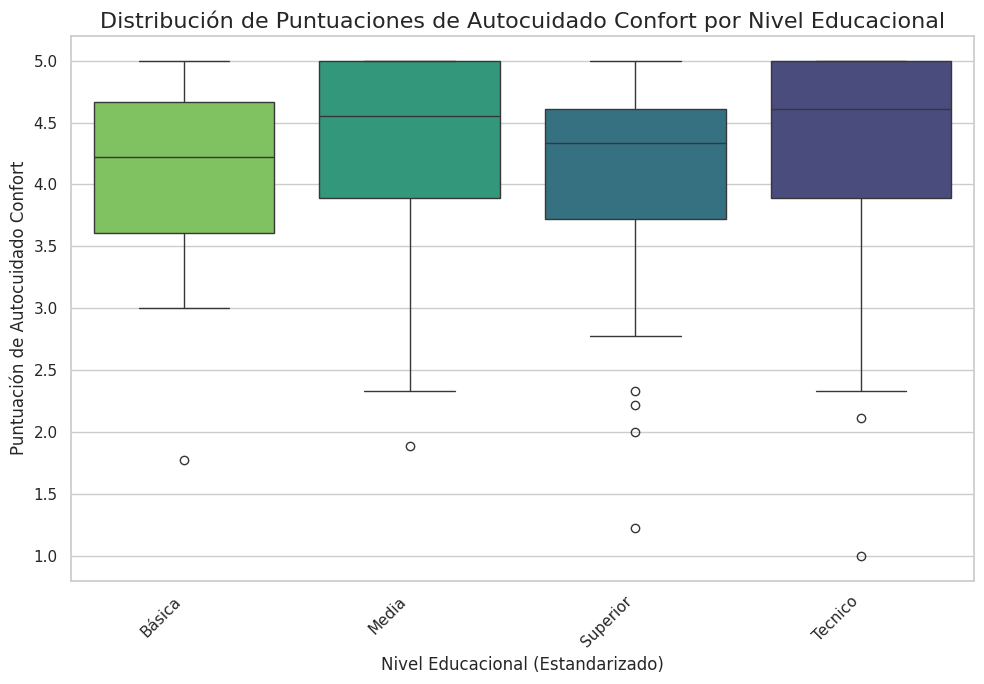

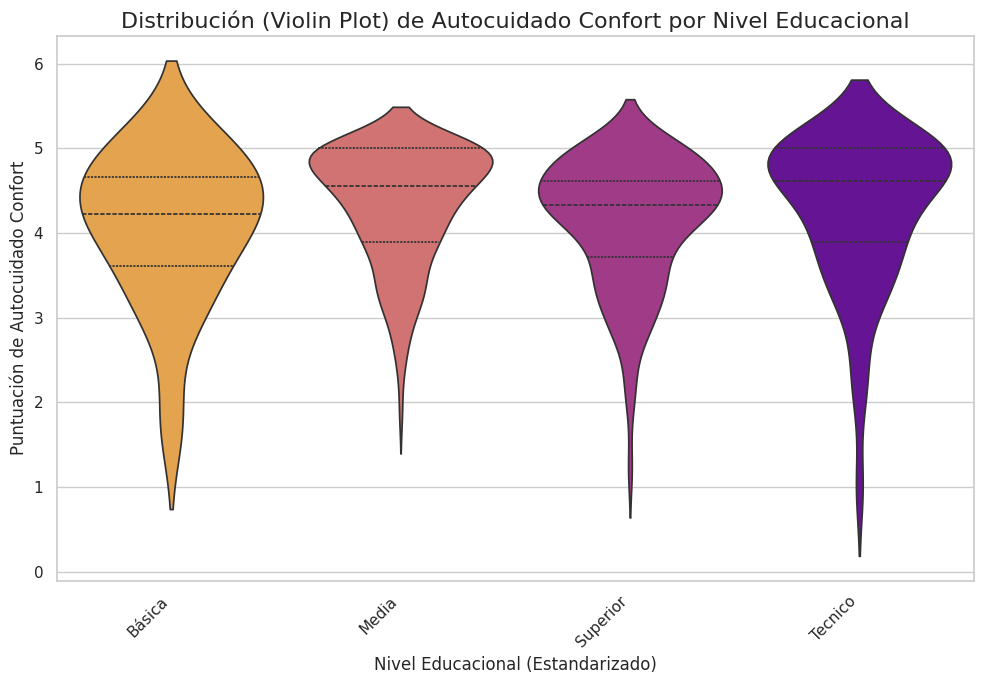

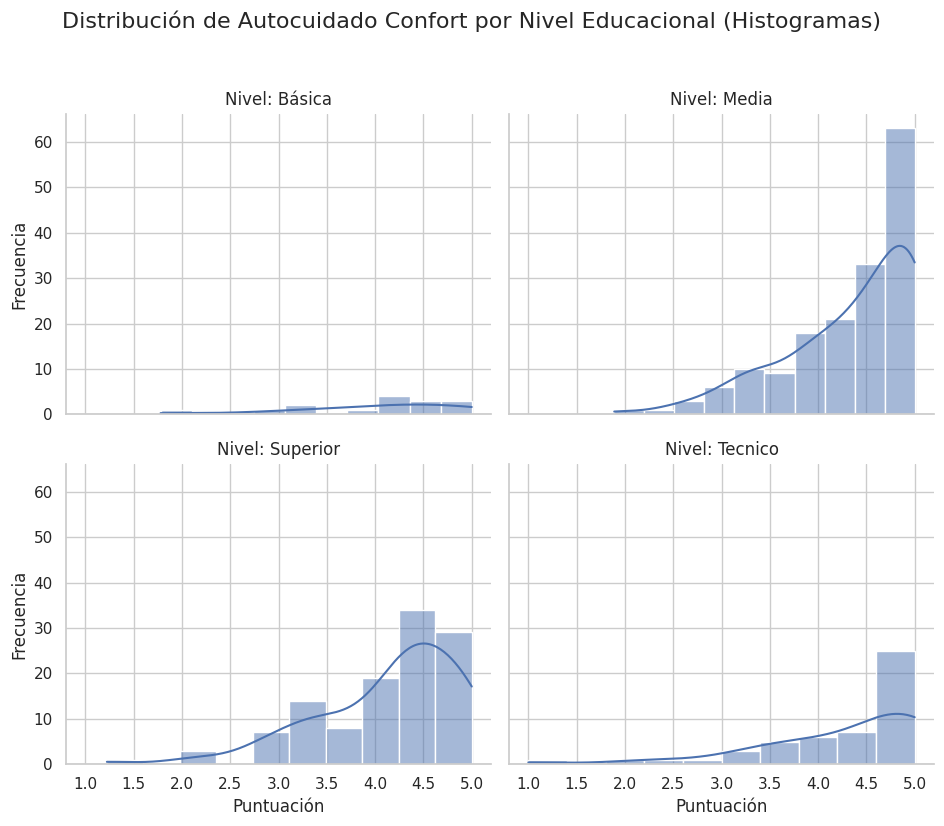

In [174]:
# 2. Visualización de la Distribución de 'Score_Autocuidado_confort' por 'Nivel_educacional_std'
print("\nVisualizando la Distribución de 'Autocuidado Confort' por Nivel Educacional:")

# Definir el orden de los grupos si es categórico o estandarizado de forma ordinal
# Asegurarse de que el orden es correcto para Nivel_educacional_std
educacion_order = sorted(df['Nivel_educacional_std'].dropna().unique())

# Boxplot
plt.figure(figsize=(10, 7))
sns.boxplot(
    x='Nivel_educacional_std',
    y='Score_Autocuidado_confort',
    data=df,
    palette='viridis',
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución de Puntuaciones de Autocuidado Confort por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Autocuidado Confort', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Violin Plot
plt.figure(figsize=(10, 7))
sns.violinplot(
    x='Nivel_educacional_std',
    y='Score_Autocuidado_confort',
    data=df,
    palette='plasma',
    inner="quartile",
    order=educacion_order, # Usar el orden definido
    hue='Nivel_educacional_std',
    legend=False
)
plt.title('Distribución (Violin Plot) de Autocuidado Confort por Nivel Educacional', fontsize=16)
plt.ylabel('Puntuación de Autocuidado Confort', fontsize=12)
plt.xlabel('Nivel Educacional (Estandarizado)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Histogramas separados para cada nivel educacional
g = sns.FacetGrid(df, col="Nivel_educacional_std", col_wrap=2, height=4, aspect=1.2, col_order=educacion_order) # Usar el orden definido
g.map(sns.histplot, 'Score_Autocuidado_confort', kde=True, bins=10)
g.fig.suptitle('Distribución de Autocuidado Confort por Nivel Educacional (Histogramas)', y=1.03, fontsize=16)
g.set_axis_labels("Puntuación", "Frecuencia")
g.set_titles("Nivel: {col_name}")
plt.tight_layout()
plt.show()

In [175]:
# 3. Prueba de Supuestos para Análisis Inferencial (ANOVA o Kruskal-Wallis)
print("\n--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---")

# Identificar los grupos únicos de nivel educacional que tienen datos para la dimensión actual
educacion_levels_autocuidado = df['Nivel_educacional_std'].dropna().unique()
valid_educacion_levels_autocuidado = [
    level for level in educacion_levels_autocuidado
    if len(df[df['Nivel_educacional_std'] == level].dropna(subset=['Score_Autocuidado_confort'])) > 0
]

print(f"Grupos de Nivel Educacional con datos válidos para 'Autocuidado_confort': {valid_educacion_levels_autocuidado}")

if len(valid_educacion_levels_autocuidado) >= 2:
    # b) Normalidad dentro de cada grupo
    print("\nPrueba de Normalidad de 'Score_Autocuidado_confort' dentro de cada grupo de Nivel Educacional:")
    educacion_groups_autocuidado = df.groupby('Nivel_educacional_std')['Score_Autocuidado_confort']

    normalidad_results_autocuidado_educacion = {}
    for name, group in educacion_groups_autocuidado:
        group_cleaned = group.dropna()
        if len(group_cleaned) > 3: # Shapiro-Wilk requiere al menos 4 muestras
            stat_sw, p_value_sw = stats.shapiro(group_cleaned)
            normalidad_results_autocuidado_educacion[name] = {'Shapiro-Wilk p-value': p_value_sw, 'N': len(group_cleaned)}
        else:
            normalidad_results_autocuidado_educacion[name] = {'Shapiro-Wilk p-value': np.nan, 'N': len(group_cleaned), 'Note': 'Not enough data for Shapiro-Wilk'}

    normalidad_df_autocuidado_educacion = pd.DataFrame(normalidad_results_autocuidado_educacion).T
    display(normalidad_df_autocuidado_educacion.style
        .set_caption("Normalidad de 'Autocuidado Confort' por Grupo (Shapiro-Wilk)")
        .format({"Shapiro-Wilk p-value": "{:.4f}", "N": "{:.0f}"})
        .background_gradient(cmap='Reds_r', subset=['Shapiro-Wilk p-value'])
    )

    print("\nInterpretación de la Normalidad:")
    print("- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.")
    print("- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.")

    # c) Homogeneidad de Varianzas (Levene's Test)
    print("\nPrueba de Homogeneidad de Varianzas (Levene's Test):")

    # Preparar los datos por grupo para Levene's test
    group_data_autocuidado_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Autocuidado_confort'].dropna().values
        for level in valid_educacion_levels_autocuidado
    ]

    # Levene's Test requiere al menos 2 grupos con datos
    if len(group_data_autocuidado_educacion) >= 2 and all(len(g) > 0 for g in group_data_autocuidado_educacion):
        stat_levene_autocuidado_educacion, p_value_levene_autocuidado_educacion = stats.levene(*group_data_autocuidado_educacion)
        print(f"Estadístico de Levene: {stat_levene_autocuidado_educacion:.4f}")
        print(f"Valor p: {p_value_levene_autocuidado_educacion:.4f}")

        if p_value_levene_autocuidado_educacion < 0.05:
            print("Conclusión (Levene's): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula de igualdad de varianzas. Las varianzas NO son homogéneas.")
            print("Si se usa ANOVA, se debería considerar usar ANOVA de Welch.")
        else:
            print("Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.")
            print("Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.")
    else:
        print("Advertencia: No hay suficientes grupos o datos (mínimo 2 grupos con datos) para realizar la Prueba de Levene.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Evaluación de Supuestos para Análisis Inferencial (Comparación de 4 Grupos) ---
Grupos de Nivel Educacional con datos válidos para 'Autocuidado_confort': ['Tecnico', 'Superior', 'Media', 'Básica']

Prueba de Normalidad de 'Score_Autocuidado_confort' dentro de cada grupo de Nivel Educacional:


,Shapiro-Wilk p-value,N
Básica,0.0571,15
Media,0.0000,165
Superior,0.0000,115
Tecnico,0.0000,50



Interpretación de la Normalidad:
- Si el p-value de Shapiro-Wilk < 0.05 para uno o más grupos, se rechaza la hipótesis de normalidad para esos grupos.
- ANOVA es relativamente robusto a violaciones de normalidad con tamaños de muestra moderados a grandes y similares entre grupos.

Prueba de Homogeneidad de Varianzas (Levene's Test):
Estadístico de Levene: 0.7614
Valor p: 0.5164
Conclusión (Levene's): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula. Sugiere que las varianzas son homogéneas.
Si se usa ANOVA estándar, se puede asumir igualdad de varianzas.


In [176]:
# 4. Selección y Aplicación de Prueba Estadística Inferencial
print("\n--- Prueba Estadística para Comparar Medias/Medianast entre 4 Grupos ---")

# ANOVA (Análisis de Varianza) es paramétrico y compara medias.
# Kruskal-Wallis es no paramétrico y compara distribuciones (medianas si las distribuciones son similares).
# Kruskal-Wallis es más robusto si los supuestos de ANOVA (normalidad, homogeneidad de varianzas) no se cumplen.

if len(valid_educacion_levels_autocuidado) >= 2:
    # Opción 1: Kruskal-Wallis Test (No paramétrica - compara distribuciones/medianas)
    print("\nAplicando la Prueba de Kruskal-Wallis (No Paramétrica):")

    # Prepara los datos por grupo para Kruskal-Wallis
    kruskal_data_autocuidado_educacion = [
        df[df['Nivel_educacional_std'] == level]['Score_Autocuidado_confort'].dropna().values
        for level in valid_educacion_levels_autocuidado
    ]

    # Realiza la prueba solo si hay datos en al menos 2 grupos
    if len(kruskal_data_autocuidado_educacion) >= 2 and all(len(g) > 0 for g in kruskal_data_autocuidado_educacion):
        stat_kruskal_autocuidado_educacion, p_value_kruskal_autocuidado_educacion = stats.kruskal(*kruskal_data_autocuidado_educacion)
        print(f"Estadístico de Kruskal-Wallis H: {stat_kruskal_autocuidado_educacion:.4f}")
        print(f"Valor p: {p_value_kruskal_autocuidado_educacion:.4f}")

        # Interpretación del resultado de Kruskal-Wallis
        if p_value_kruskal_autocuidado_educacion < 0.05:
            print("\nConclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).")
            print("Se rechaza la hipótesis nula (H0) de que las distribuciones (o medianas, si las distribuciones son similares) de 'Autocuidado_confort' son iguales entre los grupos de Nivel Educacional.")
            print("Existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre al menos dos grupos de Nivel Educacional.")
            print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

            # Prueba Post-Hoc (Dunn's Test para Kruskal-Wallis)
            print("\nAplicando Prueba Post-Hoc de Dunn (Corrección de Bonferroni) para identificar las diferencias entre pares de grupos:")
            # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
            df_filtered_ac_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_autocuidado)].dropna(subset=['Score_Autocuidado_confort', 'Nivel_educacional_std'])
            #print(df_filtered_ac_edu['Score_Autocuidado_confort'])

            # Verificar que hay suficientes datos después del filtrado
            if not df_filtered_ac_edu.empty:
                import scikit_posthocs as sp

                if not df_filtered_ac_edu.empty:
                  dunn_results_autocuidado_educacion = sp.posthoc_dunn(
                      df_filtered_ac_edu,
                      val_col='Score_Autocuidado_confort',
                      group_col='Nivel_educacional_std',
                      p_adjust='bonferroni'
                      )
                  print(dunn_results_autocuidado_educacion)
                display(dunn_results_autocuidado_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Dunn (Corrección de Bonferroni)"))
                print("\nInterpretación de Dunn's Test:")
                print("- Cada celda muestra el p-value ajustado para la comparación entre los grupos en la fila y columna.")
                print("- Un p-value ajustado < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
            else:
                print("Advertencia: No hay suficientes datos para realizar la Prueba Post-Hoc de Dunn después de filtrar por niveles educacionales válidos.")

        else:
            print("\nConclusión (Kruskal-Wallis): El valor p es mayor o igual que el nivel de significancia (0.05).")
            print("No se puede rechazar la hipótesis nula (H0).")
            print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre los grupos de Nivel Educacional.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos para realizar la Prueba de Kruskal-Wallis.")


    # Opción 2: ANOVA (Paramétrica - compara medias)
    print("\n--- Opcional: One-way ANOVA (Paramétrica) ---")
    print("Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.")

    # ANOVA requiere al menos 2 datos por grupo
    if len(group_data_autocuidado_educacion) >= 2 and all(len(g) > 1 for g in group_data_autocuidado_educacion):
        # Decide si usar ANOVA estándar o Welch basado en Levene's test (si fue calculado)
        use_welch_anova_autocuidado_educacion = False # Default to False
        if 'p_value_levene_autocuidado_educacion' in locals() and not np.isnan(p_value_levene_autocuidado_educacion) and p_value_levene_autocuidado_educacion < 0.05:
            use_welch_anova_autocuidado_educacion = True
            print("\nUsando ANOVA de Welch (no asume varianzas iguales) debido a resultado significativo de Levene's test.")
        else:
            print("\nUsando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).")


        if use_welch_anova_autocuidado_educacion:
            # Usar pingouin para ANOVA de Welch
            try:
                anova_results_autocuidado_educacion = pg.welch_anova(
                    data=df.dropna(subset=['Score_Autocuidado_confort', 'Nivel_educacional_std']),
                    dv='Score_Autocuidado_confort',
                    between='Nivel_educacional_std'
                )
                display(anova_results_autocuidado_educacion.style.set_caption("Resultados de ANOVA de Welch usando Pingouin"))
                p_value_anova_autocuidado_educacion = anova_results_autocuidado_educacion['p-unc'].iloc[0] # Pingouin usa 'p-unc' para el p sin corregir
            except Exception as e:
                print(f"Error al realizar ANOVA de Welch con Pingouin: {e}")
                p_value_anova_autocuidado_educacion = np.nan # Marcar como no calculado

        else:
            # Usar scipy para ANOVA estándar
            try:
                stat_anova_autocuidado_educacion, p_value_anova_autocuidado_educacion = stats.f_oneway(*group_data_autocuidado_educacion)
                print(f"Estadístico F (ANOVA): {stat_anova_autocuidado_educacion:.4f}")
                print(f"Valor p (ANOVA): {p_value_anova_autocuidado_educacion:.4f}")
            except Exception as e:
                 print(f"Error al realizar ANOVA estándar con Scipy: {e}")
                 p_value_anova_autocuidado_educacion = np.nan

        # Interpretación del resultado de ANOVA
        if not np.isnan(p_value_anova_autocuidado_educacion):
            if p_value_anova_autocuidado_educacion < 0.05:
                print("\nConclusión (ANOVA): El valor p es menor que el nivel de significancia (0.05).")
                print("Se rechaza la hipótesis nula (H0) de que las medias de 'Score_Autocuidado_confort' son iguales entre los grupos de Nivel Educacional.")
                print("Existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Autocuidado_confort' entre al menos dos grupos de Nivel Educacional.")
                print("Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.")

                # Prueba Post-Hoc (Tukey HSD para ANOVA estándar, Games-Howell para Welch)
                print("\nAplicando Prueba Post-Hoc:")
                if use_welch_anova_autocuidado_educacion:
                     print("Usando Games-Howell (para ANOVA de Welch) para identificar las diferencias entre pares de grupos:")
                     try:
                         # Usar pingouin para Games-Howell
                         games_howell_results_autocuidado_educacion = pg.pairwise_gameshowell(
                            data=df.dropna(subset=['Score_Autocuidado_confort', 'Nivel_educacional_std']),
                            dv='Score_Autocuidado_confort',
                            between='Nivel_educacional_std'
                         )
                         display(games_howell_results_autocuidado_educacion.style.set_caption("Resultados de la Prueba Post-Hoc de Games-Howell"))
                         print("\nInterpretación de Games-Howell:")
                         print("- La columna 'p-unc' muestra el p-value sin corregir, y 'p-corr' muestra el p-value ajustado.")
                         print("- Un 'p-corr' < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.")
                     except Exception as e:
                         print(f"Error al realizar Games-Howell con Pingouin: {e}")

                else:
                    print("Usando Tukey HSD (para ANOVA estándar) para identificar las diferencias entre pares de grupos:")
                    # Asegurarse de que solo se incluyan los grupos con datos para la prueba post-hoc
                    df_filtered_ac_edu = df[df['Nivel_educacional_std'].isin(valid_educacion_levels_autocuidado)].dropna(subset=['Score_Autocuidado_confort', 'Nivel_educacional_std'])

                    # Verificar que hay suficientes datos después del filtrado y que hay variabilidad dentro de los grupos
                    # Tukey requiere al menos 2 datos por grupo con varianza > 0
                    if not df_filtered_ac_edu.empty and df_filtered_ac_edu.groupby('Nivel_educacional_std')['Score_Autocuidado_confort'].std().min() > 0:
                        try:
                            # Usar statsmodels para Tukey HSD
                            tukey_results_autocuidado_educacion = pairwise_tukeyhsd(
                                endog=df_filtered_ac_edu['Score_Autocuidado_confort'],
                                groups=df_filtered_ac_edu['Nivel_educacional_std'],
                                alpha=0.05
                            )
                            print(tukey_results_autocuidado_educacion)
                            print("\nInterpretación de Tukey HSD:")
                            print("- 'meandiff' es la diferencia de medias entre los grupos.")
                            print("- 'lower' y 'upper' son los límites del intervalo de confianza del 95% para la diferencia de medias.")
                            print("- 'reject' es True si la diferencia es estadísticamente significativa (p < 0.05), False en caso contrario.")
                        except ValueError as e:
                            print(f"Advertencia: No se pudo realizar Tukey HSD. Error: {e}")
                            print("Esto puede ocurrir si hay grupos con varianza cero (todos los valores son iguales) o si no hay suficientes observaciones en los grupos.")
                        except Exception as e:
                             print(f"Error al realizar Tukey HSD: {e}")
                    else:
                         print("Advertencia: No hay suficientes datos o variabilidad dentro de los grupos para realizar la Prueba Post-Hoc de Tukey HSD.")
            else:
                print("\nConclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).")
                print("No se puede rechazar la hipótesis nula (H0).")
                print("No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Autocuidado_confort' entre los grupos de Nivel Educacional.")
        else:
             print("ANOVA/Welch ANOVA no pudo ser calculado.")
    else:
        print("Advertencia: No hay suficientes datos en al menos 2 grupos (mínimo 2 por grupo) para realizar el T-test.")
else:
    print("Advertencia: No hay suficientes grupos de Nivel Educacional (se requieren al menos 2) con datos válidos para realizar pruebas inferenciales.")


--- Prueba Estadística para Comparar Medias/Medianast entre 4 Grupos ---

Aplicando la Prueba de Kruskal-Wallis (No Paramétrica):
Estadístico de Kruskal-Wallis H: 8.5321
Valor p: 0.0362

Conclusión (Kruskal-Wallis): El valor p es menor que el nivel de significancia (0.05).
Se rechaza la hipótesis nula (H0) de que las distribuciones (o medianas, si las distribuciones son similares) de 'Autocuidado_confort' son iguales entre los grupos de Nivel Educacional.
Existe una diferencia estadísticamente significativa en la puntuación de 'Autocuidado_confort' entre al menos dos grupos de Nivel Educacional.
Se requiere una prueba post-hoc para identificar qué pares de grupos difieren.

Aplicando Prueba Post-Hoc de Dunn (Corrección de Bonferroni) para identificar las diferencias entre pares de grupos:
          Básica     Media  Superior   Tecnico
Básica       1.0  1.000000  1.000000  1.000000
Media        1.0  1.000000  0.050341  1.000000
Superior     1.0  0.050341  1.000000  0.302443
Tecnico    

,Básica,Media,Superior,Tecnico
Básica,1.000000,1.000000,1.000000,1.000000
Media,1.000000,1.000000,0.050341,1.000000
Superior,1.000000,0.050341,1.000000,0.302443
Tecnico,1.000000,1.000000,0.302443,1.000000



Interpretación de Dunn's Test:
- Cada celda muestra el p-value ajustado para la comparación entre los grupos en la fila y columna.
- Un p-value ajustado < 0.05 indica una diferencia estadísticamente significativa entre ese par de grupos.

--- Opcional: One-way ANOVA (Paramétrica) ---
Aplicar esta prueba solo si se consideran adecuados los supuestos (Normalidad, Homogeneidad de Varianzas) o se aplica corrección.

Usando ANOVA estándar (asume varianzas iguales, si Levene's no fue significativo o no se calculó).
Estadístico F (ANOVA): 2.0641
Valor p (ANOVA): 0.1047

Conclusión (ANOVA): El valor p es mayor o igual que el nivel de significancia (0.05).
No se puede rechazar la hipótesis nula (H0).
No hay evidencia suficiente para concluir que existe una diferencia estadísticamente significativa en la puntuación media de 'Score_Autocuidado_confort' entre los grupos de Nivel Educacional.


In [177]:
# 5. Tamaño del Efecto
print("\n--- Cálculo del Tamaño del Efecto ---")

if len(valid_educacion_levels_autocuidado) >= 2:
    print("\nCalculando el Tamaño del Efecto para múltiples grupos:")

    # Para ANOVA, el tamaño del efecto comúnmente usado es eta cuadrado (η²).
    # Para Kruskal-Wallis, se puede usar eta cuadrado basado en H.

    # Calcular eta cuadrado (η²) para ANOVA (si se realizó)
    if 'anova_results_autocuidado_educacion' in locals() and isinstance(anova_results_autocuidado_educacion, pd.DataFrame):
        print("\nCalculando Eta Cuadrado (η²) para ANOVA:")
        try:
            # Pingouin calcula η² (eta-squared) o η²p (partial eta-squared)
            eta_squared_anova_autocuidado_educacion = anova_results_autocuidado_educacion['eta-squared'].iloc[0]
            print(f"Eta Cuadrado (η²) para la prueba general (ANOVA): {eta_squared_anova_autocuidado_educacion:.4f}")

            # Interpretación del tamaño del efecto eta cuadrado (Cohen, 1988)
            print("\nInterpretación del Tamaño del Efecto (Eta Cuadrado η²):")
            if eta_squared_anova_autocuidado_educacion >= 0.14:
                print(f"- El tamaño del efecto ({eta_squared_anova_autocuidado_educacion:.2f}) es grande.")
                print("  El Nivel Educacional explica una proporción sustancial de la variabilidad en la puntuación de 'Autocuidado_confort'.")
            elif eta_squared_anova_autocuidado_educacion >= 0.06:
                print(f"- El tamaño del efecto ({eta_squared_anova_autocuidado_educacion:.2f}) es mediano.")
                print("  El Nivel Educacional explica una proporción moderada de la variabilidad.")
            elif eta_squared_anova_autocuidado_educacion >= 0.01:
                print(f"- El tamaño del efecto ({eta_squared_anova_autocuidado_educacion:.2f}) es pequeño.")
                print("  El Nivel Educacional explica una pequeña proporción de la variabilidad.")
            else:
                print(f"- El tamaño del efecto ({eta_squared_anova_autocuidado_educacion:.2f}) es muy pequeño.")
                print("  Indica que el Nivel Educacional tiene una influencia mínima en la variabilidad de 'Autocuidado_confort' en esta muestra.")
        except Exception as e:
             print(f"Error al calcular Eta Cuadrado con Pingouin: {e}")


    # Calcular eta cuadrado basado en H para Kruskal-Wallis (si se realizó)
    if 'stat_kruskal_autocuidado_educacion' in locals() and not np.isnan(stat_kruskal_autocuidado_educacion):
        print("\nCalculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:")
        N_autocuidado_educacion = df['Score_Autocuidado_confort'].dropna().shape[0]
        # Epsilon squared (preferido para Kruskal-Wallis)
        if N_autocuidado_educacion > 0:
            epsilon_squared_kruskal_autocuidado_educacion = (stat_kruskal_autocuidado_educacion / (N_autocuidado_educacion + 1))
            print(f"Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: {epsilon_squared_kruskal_autocuidado_educacion:.4f}")

            # Interpretación similar a eta cuadrado
            print("\nInterpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):")
            if epsilon_squared_kruskal_autocuidado_educacion >= 0.138: # Aproximaciones para no paramétrico
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_autocuidado_educacion:.2f}) es grande.")
            elif epsilon_squared_kruskal_autocuidado_educacion >= 0.059:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_autocuidado_educacion:.2f}) es mediano.")
            elif epsilon_squared_kruskal_autocuidado_educacion >= 0.01:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_autocuidado_educacion:.2f}) es pequeño.")
            else:
                print(f"- El tamaño del efecto ({epsilon_squared_kruskal_autocuidado_educacion:.2f}) es muy pequeño.")

        else:
            print("Advertencia: No hay suficientes datos para calcular el tamaño del efecto (Epsilon Cuadrado).")


    # Tamaño del efecto para comparaciones post-hoc (si se realizaron)
    if 'dunn_results_autocuidado_educacion' in locals() and not dunn_results_autocuidado_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver p-values ajustados arriba).")
         print("Para cada par significativo, la diferencia de medianas o rangos promedio observada en las estadísticas descriptivas da una idea de la dirección y magnitud de la diferencia.")
    elif 'games_howell_results_autocuidado_educacion' in locals() and isinstance(games_howell_results_autocuidado_educacion, pd.DataFrame) and not games_howell_results_autocuidado_educacion.empty:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'diff' y 'p-corr' arriba).")
         print("'diff' muestra la diferencia media entre pares, y 'p-corr' su significancia.")
    elif 'tukey_results_autocuidado_educacion' in locals() and tukey_results_autocuidado_educacion is not None:
         print("\nInterpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver 'meandiff' y 'reject' arriba).")
         print("'meandiff' muestra la diferencia media entre pares, y 'reject' su significancia.")
else:
    print("\nAdvertencia: No se pudieron realizar cálculos de tamaño del efecto ya que no hay suficientes grupos con datos.")


--- Cálculo del Tamaño del Efecto ---

Calculando el Tamaño del Efecto para múltiples grupos:

Calculando Epsilon Cuadrado (ε²) o Eta Cuadrado H para Kruskal-Wallis:
Epsilon Cuadrado (ε²) basado en Kruskal-Wallis H: 0.0247

Interpretación del Tamaño del Efecto (Epsilon Cuadrado ε² para Kruskal-Wallis):
- El tamaño del efecto (0.02) es pequeño.

Interpretación del Tamaño del Efecto para Pruebas Post-Hoc (ver p-values ajustados arriba).
Para cada par significativo, la diferencia de medianas o rangos promedio observada en las estadísticas descriptivas da una idea de la dirección y magnitud de la diferencia.


In [178]:
# 6. Conclusiones y Recomendaciones
print("\n--- Conclusiones del Análisis 'Autocuidado_confort' según Nivel Educacional ---")
print("- Se realizó el análisis comparando las puntuaciones de 'Autocuidado_confort' entre los 4 grupos de Nivel Educacional Estandarizado.")
print("- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.")
print("- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).")

print("\nResultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):")

# Priorizar la interpretación basada en Kruskal-Wallis si se hizo y es significativo
if 'p_value_kruskal_autocuidado_educacion' in locals() and not np.isnan(p_value_kruskal_autocuidado_educacion):
    if p_value_kruskal_autocuidado_educacion < 0.05:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_autocuidado_educacion:.4f}) indica una diferencia estadísticamente significativa en las distribuciones (medianas) de las puntuaciones de 'Autocuidado_confort' entre los grupos de Nivel Educacional.")
        print("- Esto sugiere que la percepción del autocuidado y confort difiere significativamente según el nivel educativo.")
        print("- Las pruebas post-hoc de Dunn identifican específicamente qué pares de grupos muestran diferencias significativas.")
        if 'dunn_results_autocuidado_educacion' in locals() and not dunn_results_autocuidado_educacion.empty:
            print("  Revisar la tabla de resultados de Dunn para ver las comparaciones significativas.")
        else:
            print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba de Kruskal-Wallis ({p_value_kruskal_autocuidado_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre los grupos de Nivel Educacional basado en esta prueba no paramétrica.")

# Si Kruskal-Wallis no fue significativo o no se hizo, considerar la interpretación de ANOVA si se hizo
elif 'p_value_anova_autocuidado_educacion' in locals() and not np.isnan(p_value_anova_autocuidado_educacion):
    if p_value_anova_autocuidado_educacion < 0.05:
         print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_autocuidado_educacion:.4f}) indica una diferencia estadísticamente significativa en las medias de las puntuaciones de 'Autocuidado_confort' entre los grupos de Nivel Educacional.")
         print("- Esto sugiere que la percepción del autocuidado y confort difiere significativamente según el nivel educativo.")
         print("- Las pruebas post-hoc (Tukey HSD o Games-Howell) identifican específicamente qué pares de grupos muestran diferencias significativas.")
         if 'tukey_results_autocuidado_educacion' in locals() and tukey_results_autocuidado_educacion is not None:
            print("  Revisar la tabla de resultados de Tukey HSD para ver las comparaciones significativas.")
         elif 'games_howell_results_autocuidado_educacion' in locals() and isinstance(games_howell_results_autocuidado_educacion, pd.DataFrame) and not games_howell_results_autocuidado_educacion.empty:
             print("  Revisar la tabla de resultados de Games-Howell para ver las comparaciones significativas.")
         else:
             print("  No se pudo realizar la prueba post-hoc para identificar los pares específicos que difieren.")
    else:
        print(f"- La prueba ANOVA/Welch ANOVA ({p_value_anova_autocuidado_educacion:.4f}) no encontró una diferencia estadísticamente significativa.")
        print("  No hay evidencia suficiente para concluir una diferencia estadísticamente significativa en la percepción de 'Autocuidado_confort' entre los grupos de Nivel Educacional basado en esta prueba paramétrica.")

else:
     print("- No se pudo realizar la prueba inferencial debido a datos insuficientes o problemas en los cálculos.")


print("\nResultados del Tamaño del Efecto (Eta Cuadrado o Epsilon Cuadrado, si se calculó):")
if 'eta_squared_anova_autocuidado_educacion' in locals() and not np.isnan(eta_squared_anova_autocuidado_educacion):
    effect_size_interpretation_eta_ac = 'muy pequeña' if eta_squared_anova_autocuidado_educacion < 0.01 else ('pequeña' if eta_squared_anova_autocuidado_educacion < 0.06 else ('mediana' if eta_squared_anova_autocuidado_educacion < 0.14 else 'grande'))
    print(f"- El tamaño del efecto (Eta Cuadrado η²) para ANOVA fue de {eta_squared_anova_autocuidado_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_eta_ac}.")
elif 'epsilon_squared_kruskal_autocuidado_educacion' in locals() and not np.isnan(epsilon_squared_kruskal_autocuidado_educacion):
    effect_size_interpretation_epsilon_ac = 'muy pequeña' if epsilon_squared_kruskal_autocuidado_educacion < 0.01 else ('pequeña' if epsilon_squared_kruskal_autocuidado_educacion < 0.059 else ('mediana' if epsilon_squared_kruskal_autocuidado_educacion < 0.138 else 'grande'))
    print(f"- El tamaño del efecto (Epsilon Cuadrado ε²) para Kruskal-Wallis fue de {epsilon_squared_kruskal_autocuidado_educacion:.4f}, sugiriendo una magnitud de la diferencia {effect_size_interpretation_epsilon_ac}.")
else:
     print("- No se pudo calcular el tamaño del efecto global.")


print("\nRecomendaciones Adicionales para 'Autocuidado_confort' por Nivel Educacional:")
print("- Si se encontraron diferencias significativas, investigar si las necesidades y expectativas de autocuidado y confort (manejo del dolor, atención a necesidades personales, apoyo emocional) varían según el nivel educativo.")
print("- Evaluar si la información y el apoyo proporcionados para el autocuidado postparto son igualmente accesibles y comprensibles para mujeres de todos los niveles educativos.")
print("- Considerar la posibilidad de que las barreras económicas o sociales asociadas a diferentes niveles educativos puedan influir en la capacidad de las mujeres para acceder a recursos o tomarse tiempo para el autocuidado.")
print("- Desarrollar recursos educativos y de apoyo que sean culturalmente sensibles y adaptados a diferentes niveles de alfabetización y comprensión, para asegurar que todas las mujeres se sientan empoderadas y apoyadas en su autocuidado y confort durante el postparto.")

print("\n--- Fin del Análisis de 'Autocuidado_confort' según Nivel_educacional_std ---")


--- Conclusiones del Análisis 'Autocuidado_confort' según Nivel Educacional ---
- Se realizó el análisis comparando las puntuaciones de 'Autocuidado_confort' entre los 4 grupos de Nivel Educacional Estandarizado.
- Se evaluaron las estadísticas descriptivas y las distribuciones visualmente para cada grupo.
- Las pruebas de normalidad y homogeneidad de varianzas se consideraron para informar la elección de la prueba inferencial (ANOVA vs. Kruskal-Wallis).

Resultados de la Prueba Inferencial (Kruskal-Wallis o ANOVA, si se realizaron):
- La prueba de Kruskal-Wallis (0.0362) indica una diferencia estadísticamente significativa en las distribuciones (medianas) de las puntuaciones de 'Autocuidado_confort' entre los grupos de Nivel Educacional.
- Esto sugiere que la percepción del autocuidado y confort difiere significativamente según el nivel educativo.
- Las pruebas post-hoc de Dunn identifican específicamente qué pares de grupos muestran diferencias significativas.
  Revisar la tabla de 

## 6.5 Análisis por Dimensiones según Edad

In [179]:
import statsmodels.sandbox.stats.multicomp as multi # Para corrección de p-valores

# Configurar advertencias para ignorar algunas comunes de las bibliotecas
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning) # Ignorar advertencias de seaborn/matplotlib que no afectan el resultado

print("\n--- Análisis de Correlación entre Puntuaciones de Dimensiones y Edad ---")

# Identificar las columnas de puntuación de las dimensiones
score_cols = [col for col in df.columns if col.startswith('Score_')]

# Definir las variables para el análisis de correlación
variables_correlacion = score_cols + ['Edad']

# Crear un sub-DataFrame solo con las variables de interés y eliminar filas con valores faltantes
# Eliminar filas donde *alguna* de las variables de interés tenga un NaN
df_corr = df[variables_correlacion].dropna()

print(f"\nDimensiones a incluir en el análisis de correlación: {score_cols}")
print(f"Número de observaciones válidas (sin NaN en las variables de interés): {len(df_corr)}")



--- Análisis de Correlación entre Puntuaciones de Dimensiones y Edad ---

Dimensiones a incluir en el análisis de correlación: ['Score_Cuidado_relacional_calidad', 'Score_Cuidado_despersonalizado', 'Score_Participacion_familiar_continua', 'Score_Cuidado_oportuno_respetuoso', 'Score_Ambiente_fisico_confortable', 'Score_Condiciones_contacto_madre_hijo', 'Score_Autocuidado_confort']
Número de observaciones válidas (sin NaN en las variables de interés): 345


In [180]:
# --- 1. Cálculo de la Matriz de Correlación ---

# Correlación de Pearson (Paramétrica - asume linealidad y normalidad bivariada)
print("\nCalculando Matriz de Correlación de Pearson (Paramétrica):")
correlation_matrix_pearson = df_corr.corr(method='pearson')
display(correlation_matrix_pearson.style.set_caption("Matriz de Correlación de Pearson"))


# Correlación de Spearman (No Paramétrica - evalúa relaciones monótonas)
# Más robusta si los supuestos de Pearson no se cumplen, adecuada para variables ordinales o no normales.
print("\nCalculando Matriz de Correlación de Spearman (No Paramétrica):")
correlation_matrix_spearman = df_corr.corr(method='spearman')
display(correlation_matrix_spearman.style.set_caption("Matriz de Correlación de Spearman"))


print("\nInterpretación de los coeficientes de correlación:")
print("- El coeficiente varía entre -1 y +1.")
print("- Un valor cercano a +1 indica una fuerte relación lineal positiva (a medida que una variable aumenta, la otra también tiende a aumentar).")
print("- Un valor cercano a -1 indica una fuerte relación lineal negativa (a medida que una variable aumenta, la otra tiende a disminuir).")
print("- Un valor cercano a 0 indica una relación lineal débil o inexistente (o una relación no lineal que Pearson/Spearman no capturan bien).")
print("- La magnitud del coeficiente (el valor absoluto) indica la fuerza de la relación.")


Calculando Matriz de Correlación de Pearson (Paramétrica):


,Score_Cuidado_relacional_calidad,Score_Cuidado_despersonalizado,Score_Participacion_familiar_continua,Score_Cuidado_oportuno_respetuoso,Score_Ambiente_fisico_confortable,Score_Condiciones_contacto_madre_hijo,Score_Autocuidado_confort,Edad
Score_Cuidado_relacional_calidad,1.000000,-0.438526,0.590776,0.785324,0.641349,0.398096,0.494579,0.072240
Score_Cuidado_despersonalizado,-0.438526,1.000000,-0.283927,-0.306723,-0.286188,-0.166573,-0.171484,0.050435
Score_Participacion_familiar_continua,0.590776,-0.283927,1.000000,0.509797,0.493673,0.471937,0.395614,0.007305
Score_Cuidado_oportuno_respetuoso,0.785324,-0.306723,0.509797,1.000000,0.626937,0.333379,0.572425,0.060230
Score_Ambiente_fisico_confortable,0.641349,-0.286188,0.493673,0.626937,1.000000,0.299743,0.423416,0.021603
Score_Condiciones_contacto_madre_hijo,0.398096,-0.166573,0.471937,0.333379,0.299743,1.000000,0.352989,-0.088200
Score_Autocuidado_confort,0.494579,-0.171484,0.395614,0.572425,0.423416,0.352989,1.000000,-0.103440
Edad,0.072240,0.050435,0.007305,0.060230,0.021603,-0.088200,-0.103440,1.000000



Calculando Matriz de Correlación de Spearman (No Paramétrica):


,Score_Cuidado_relacional_calidad,Score_Cuidado_despersonalizado,Score_Participacion_familiar_continua,Score_Cuidado_oportuno_respetuoso,Score_Ambiente_fisico_confortable,Score_Condiciones_contacto_madre_hijo,Score_Autocuidado_confort,Edad
Score_Cuidado_relacional_calidad,1.000000,-0.465716,0.535902,0.667024,0.625548,0.407439,0.520635,0.032114
Score_Cuidado_despersonalizado,-0.465716,1.000000,-0.360050,-0.365814,-0.364502,-0.256404,-0.277427,0.038594
Score_Participacion_familiar_continua,0.535902,-0.360050,1.000000,0.413492,0.480400,0.411721,0.390842,0.060092
Score_Cuidado_oportuno_respetuoso,0.667024,-0.365814,0.413492,1.000000,0.555942,0.348448,0.573669,0.004059
Score_Ambiente_fisico_confortable,0.625548,-0.364502,0.480400,0.555942,1.000000,0.303945,0.479197,0.005374
Score_Condiciones_contacto_madre_hijo,0.407439,-0.256404,0.411721,0.348448,0.303945,1.000000,0.397277,-0.098150
Score_Autocuidado_confort,0.520635,-0.277427,0.390842,0.573669,0.479197,0.397277,1.000000,-0.133279
Edad,0.032114,0.038594,0.060092,0.004059,0.005374,-0.098150,-0.133279,1.000000



Interpretación de los coeficientes de correlación:
- El coeficiente varía entre -1 y +1.
- Un valor cercano a +1 indica una fuerte relación lineal positiva (a medida que una variable aumenta, la otra también tiende a aumentar).
- Un valor cercano a -1 indica una fuerte relación lineal negativa (a medida que una variable aumenta, la otra tiende a disminuir).
- Un valor cercano a 0 indica una relación lineal débil o inexistente (o una relación no lineal que Pearson/Spearman no capturan bien).
- La magnitud del coeficiente (el valor absoluto) indica la fuerza de la relación.



Visualizando Matriz de Correlación (Pearson):


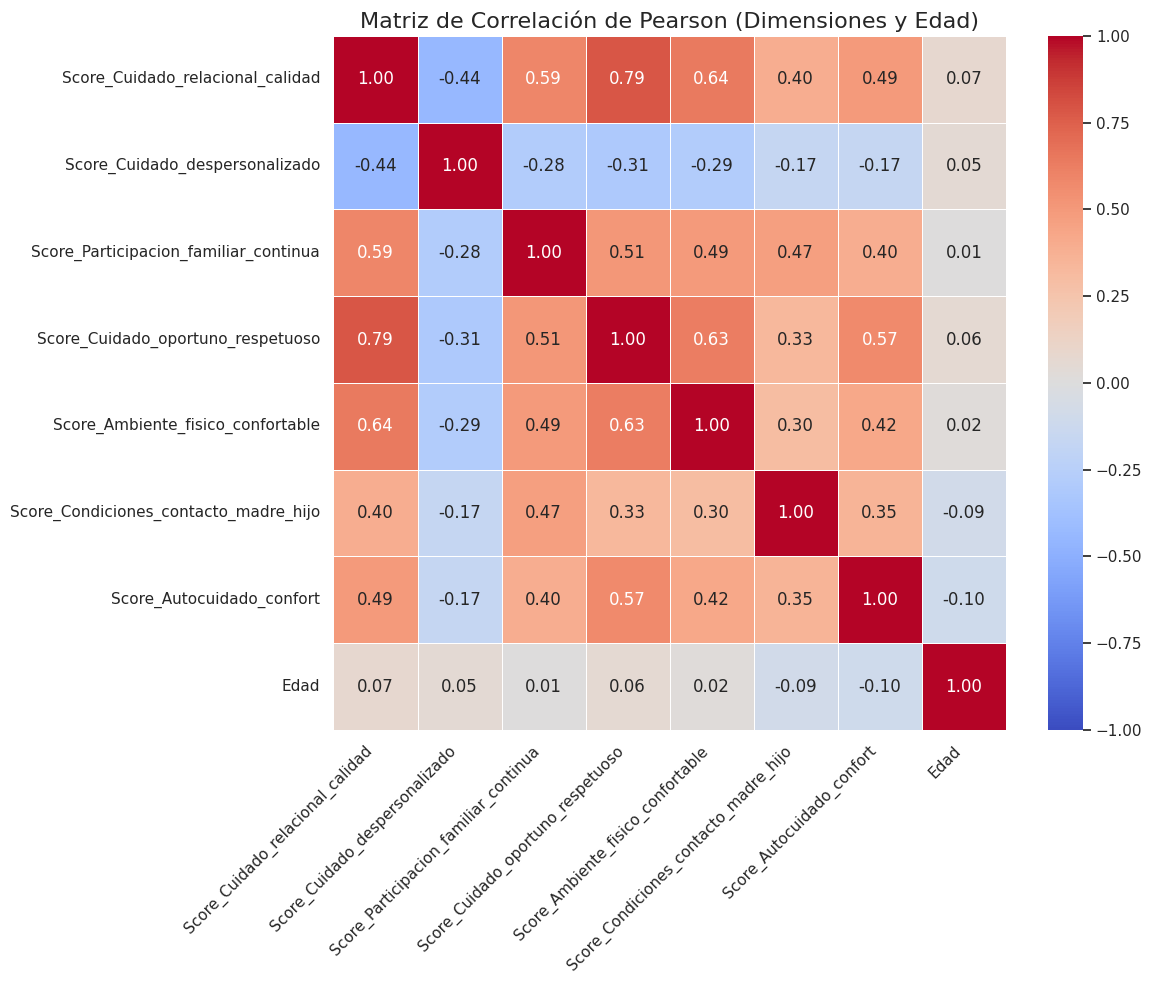


Visualizando Matriz de Correlación (Spearman):


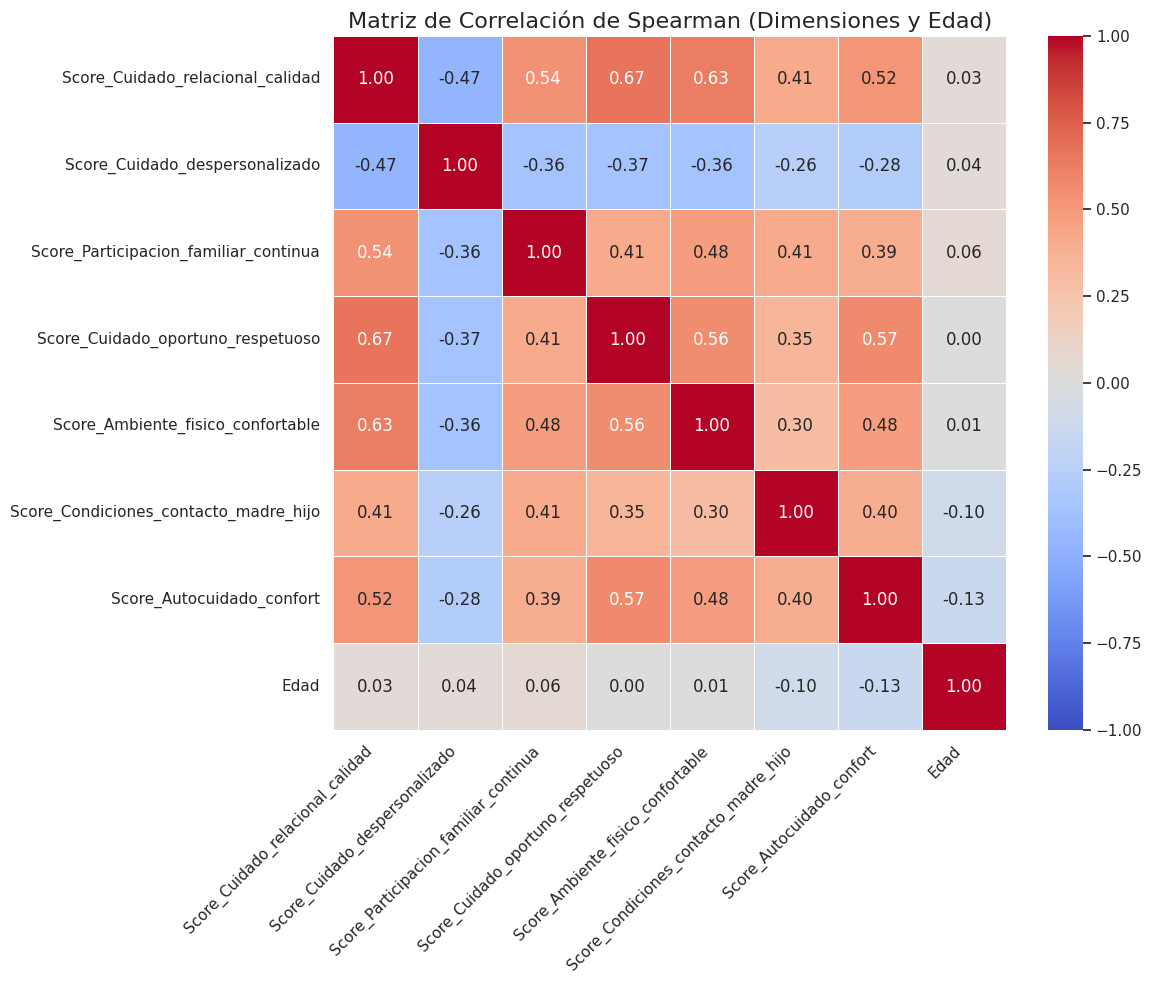


Análisis visual del mapa de calor:
- Los colores más intensos (rojo oscuro o azul oscuro) indican correlaciones más fuertes.
- El rojo indica correlación positiva, el azul indica correlación negativa.
- Los números dentro de las celdas son los coeficientes de correlación.


In [181]:
# --- 2. Visualización: Mapa de Calor ---

print("\nVisualizando Matriz de Correlación (Pearson):")
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_pearson, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Pearson (Dimensiones y Edad)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nVisualizando Matriz de Correlación (Spearman):")
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_spearman, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Spearman (Dimensiones y Edad)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nAnálisis visual del mapa de calor:")
print("- Los colores más intensos (rojo oscuro o azul oscuro) indican correlaciones más fuertes.")
print("- El rojo indica correlación positiva, el azul indica correlación negativa.")
print("- Los números dentro de las celdas son los coeficientes de correlación.")

In [182]:
# --- 3. Significación Estadística y Corrección por Comparaciones Múltiples ---

# Calculando los p-valores para la correlación de Pearson
# Usaremos Pingouin para obtener p-valores fácilmente y aplicar corrección
print("\nCalculando p-valores y significancia para Correlación de Pearson:")
try:
    # Correlación de Pearson con p-valores
    corr_pearson_pw = pg.pairwise_corr(df_corr, method='pearson')

    # Filtrar solo las correlaciones que involucran 'Edad' con las dimensiones
    corr_pearson_edad = corr_pearson_pw[
        ((corr_pearson_pw['X'] == 'Edad') & (corr_pearson_pw['Y'].isin(score_cols))) |
        ((corr_pearson_pw['Y'] == 'Edad') & (corr_pearson_pw['X'].isin(score_cols)))
    ].reset_index(drop=True)

    # Aplicar corrección para comparaciones múltiples (Bonferroni)
    p_values_uncorrected = corr_pearson_edad['p-unc'].values
    reject_bonferroni, p_values_bonferroni_corrected, _, _ = multi.multipletests(
        p_values_uncorrected,
        alpha=0.05,
        method='bonferroni'
    )
    corr_pearson_edad['p-bonferroni'] = p_values_bonferroni_corrected
    corr_pearson_edad['sig-bonferroni'] = reject_bonferroni

    # También Benjamini-Hochberg (FDR)
    reject_fdr, p_values_fdr_corrected, _, _ = multi.multipletests(
        p_values_uncorrected,
        alpha=0.05,
        method='fdr_bh'
    )
    corr_pearson_edad['p-fdr'] = p_values_fdr_corrected
    corr_pearson_edad['sig-fdr'] = reject_fdr

    # Formatear y mostrar los resultados
    corr_pearson_edad_display = corr_pearson_edad[['X', 'Y', 'r', 'p-unc', 'p-bonferroni', 'sig-bonferroni', 'p-fdr', 'sig-fdr', 'n']].style.set_caption("Significancia de Correlaciones Pearson (Edad vs Dimensiones) con Correcciones")
    corr_pearson_edad_display = corr_pearson_edad_display.format({
        'r': '{:.4f}',
        'p-unc': '{:.4f}',
        'p-bonferroni': '{:.4f}',
        'p-fdr': '{:.4f}',
        'n': '{:.0f}'
    })
    display(corr_pearson_edad_display)

except Exception as e:
    print(f"Error al calcular significancia de correlaciones Pearson: {e}")
    corr_pearson_edad = pd.DataFrame() # Crear un DataFrame vacío si falla

# Calculando los p-valores para la correlación de Spearman
print("\nCalculando p-valores y significancia para Correlación de Spearman:")
try:
    # Correlación de Spearman con p-valores
    corr_spearman_pw = pg.pairwise_corr(df_corr, method='spearman')

    # Filtrar solo las correlaciones que involucran 'Edad' con las dimensiones
    corr_spearman_edad = corr_spearman_pw[
        ((corr_spearman_pw['X'] == 'Edad') & (corr_spearman_pw['Y'].isin(score_cols))) |
        ((corr_spearman_pw['Y'] == 'Edad') & (corr_spearman_pw['X'].isin(score_cols)))
    ].reset_index(drop=True)

    # Aplicar corrección para comparaciones múltiples (Bonferroni)
    p_values_uncorrected_s = corr_spearman_edad['p-unc'].values
    reject_bonferroni_s, p_values_bonferroni_corrected_s, _, _ = multi.multipletests(
        p_values_uncorrected_s,
        alpha=0.05,
        method='bonferroni'
    )
    corr_spearman_edad['p-bonferroni'] = p_values_bonferroni_corrected_s
    corr_spearman_edad['sig-bonferroni'] = reject_bonferroni_s

    # También Benjamini-Hochberg (FDR)
    reject_fdr_s, p_values_fdr_corrected_s, _, _ = multi.multipletests(
        p_values_uncorrected_s,
        alpha=0.05,
        method='fdr_bh'
    )
    corr_spearman_edad['p-fdr'] = p_values_fdr_corrected_s
    corr_spearman_edad['sig-fdr'] = reject_fdr_s

    # Formatear y mostrar los resultados
    corr_spearman_edad_display = corr_spearman_edad[['X', 'Y', 'r', 'p-unc', 'p-bonferroni', 'sig-bonferroni', 'p-fdr', 'sig-fdr', 'n']].style.set_caption("Significancia de Correlaciones Spearman (Edad vs Dimensiones) con Correcciones")
    corr_spearman_edad_display = corr_spearman_edad_display.format({
        'r': '{:.4f}',
        'p-unc': '{:.4f}',
        'p-bonferroni': '{:.4f}',
        'p-fdr': '{:.4f}',
        'n': '{:.0f}'
    })
    display(corr_spearman_edad_display)

except Exception as e:
    print(f"Error al calcular significancia de correlaciones Spearman: {e}")
    corr_spearman_edad = pd.DataFrame() # Crear un DataFrame vacío si falla

print("\nInterpretación de la significancia (p-valor):")
print("- Un p-valor sin corregir (p-unc) < 0.05 sugiere que la correlación observada es poco probable que ocurra por azar si no hay una relación real.")
print("- Al realizar múltiples pruebas (correlación entre Edad y varias dimensiones), aumenta la probabilidad de encontrar un resultado 'significativo' por azar (Error Tipo I).")
print("- Las correcciones (Bonferroni, FDR) ajustan los p-valores para tener en cuenta esto.")
print("- Si el p-valor ajustado (p-bonferroni o p-fdr) < 0.05, la correlación se considera estadísticamente significativa después de la corrección por múltiples comparaciones.")
print("- Bonferroni es más estricto que FDR (Benjamini-Hochberg). A menudo se prefiere FDR en análisis exploratorios o con muchas pruebas.")
print("- 'sig-bonferroni' y 'sig-fdr' indican si la correlación es significativa después de la corrección (True = Significativo, False = No Significativo).")


Calculando p-valores y significancia para Correlación de Pearson:
Error al calcular significancia de correlaciones Pearson: 'p-unc'

Calculando p-valores y significancia para Correlación de Spearman:
Error al calcular significancia de correlaciones Spearman: 'p-unc'

Interpretación de la significancia (p-valor):
- Un p-valor sin corregir (p-unc) < 0.05 sugiere que la correlación observada es poco probable que ocurra por azar si no hay una relación real.
- Al realizar múltiples pruebas (correlación entre Edad y varias dimensiones), aumenta la probabilidad de encontrar un resultado 'significativo' por azar (Error Tipo I).
- Las correcciones (Bonferroni, FDR) ajustan los p-valores para tener en cuenta esto.
- Si el p-valor ajustado (p-bonferroni o p-fdr) < 0.05, la correlación se considera estadísticamente significativa después de la corrección por múltiples comparaciones.
- Bonferroni es más estricto que FDR (Benjamini-Hochberg). A menudo se prefiere FDR en análisis exploratorios o con 

In [183]:
# --- 4. Tamaño del Efecto e Interpretación ---

print("\nInterpretación del Tamaño del Efecto (Basado en Cohen, 1988 para Pearson 'r', aplicable por extensión a Spearman 'rho'):")
print("- |r| o |rho| ≈ 0.10: Efecto pequeño")
print("- |r| o |rho| ≈ 0.30: Efecto mediano")
print("- |r| o |rho| ≈ 0.50 o más: Efecto grande")

print("\nCorrelaciones Pearson Significativas (p-fdr < 0.05):")
if not corr_pearson_edad.empty:
    significant_pearson = corr_pearson_edad[corr_pearson_edad['sig-fdr'] == True]
    if not significant_pearson.empty:
        display(significant_pearson[['X', 'Y', 'r', 'p-fdr']].style.set_caption("Correlaciones Pearson Significativas con Edad (p-fdr < 0.05)").format({'r': '{:.4f}', 'p-fdr': '{:.4f}'}))
        for index, row in significant_pearson.iterrows():
             print(f"- {row['X']} y {row['Y']}: r = {row['r']:.4f}, p-fdr = {row['p-fdr']:.4f}. Tamaño del efecto: {abs(row['r']):.2f} ({'grande' if abs(row['r']) >= 0.5 else ('mediano' if abs(row['r']) >= 0.3 else ('pequeño' if abs(row['r']) >= 0.1 else 'muy pequeño'))})")
    else:
        print("No hay correlaciones Pearson significativas con la Edad después de la corrección FDR.")
else:
    print("No se pudieron calcular las correlaciones Pearson.")


print("\nCorrelaciones Spearman Significativas (p-fdr < 0.05):")
if not corr_spearman_edad.empty:
    significant_spearman = corr_spearman_edad[corr_spearman_edad['sig-fdr'] == True]
    if not significant_spearman.empty:
        display(significant_spearman[['X', 'Y', 'r', 'p-fdr']].style.set_caption("Correlaciones Spearman Significativas con Edad (p-fdr < 0.05)").format({'r': '{:.4f}', 'p-fdr': '{:.4f}'}))
        for index, row in significant_spearman.iterrows():
             print(f"- {row['X']} y {row['Y']}: rho = {row['r']:.4f}, p-fdr = {row['p-fdr']:.4f}. Tamaño del efecto: {abs(row['r']):.2f} ({'grande' if abs(row['r']) >= 0.5 else ('mediano' if abs(row['r']) >= 0.3 else ('pequeño' if abs(row['r']) >= 0.1 else 'muy pequeño'))})")
    else:
        print("No hay correlaciones Spearman significativas con la Edad después de la corrección FDR.")
else:
    print("No se pudieron calcular las correlaciones Spearman.")



Interpretación del Tamaño del Efecto (Basado en Cohen, 1988 para Pearson 'r', aplicable por extensión a Spearman 'rho'):
- |r| o |rho| ≈ 0.10: Efecto pequeño
- |r| o |rho| ≈ 0.30: Efecto mediano
- |r| o |rho| ≈ 0.50 o más: Efecto grande

Correlaciones Pearson Significativas (p-fdr < 0.05):
No se pudieron calcular las correlaciones Pearson.

Correlaciones Spearman Significativas (p-fdr < 0.05):
No se pudieron calcular las correlaciones Spearman.


In [184]:
# --- 5. Gráficos de Dispersión para Correlaciones Notables ---
print("\nVisualización de Correlaciones Notables con Gráficos de Dispersión:")

# Definir variables como vacías por defecto en caso de que el análisis previo fallara
if 'significant_spearman' not in locals():
    significant_spearman = pd.DataFrame()
if 'significant_pearson' not in locals():
    significant_pearson = pd.DataFrame()

# Seleccionar algunas correlaciones para visualizar
plots_to_show = []

if not significant_spearman.empty:
     # Ordenar por magnitud de rho
     significant_spearman_sorted = significant_spearman.reindex(significant_spearman['r'].abs().sort_values(ascending=False).index)
     # Añadir la correlación positiva más fuerte
     strongest_positive_s = significant_spearman_sorted[significant_spearman_sorted['r'] > 0].head(1)
     if not strongest_positive_s.empty:
         plots_to_show.append((strongest_positive_s.iloc[0]['Y'], strongest_positive_s.iloc[0]['r'], 'Spearman', 'Edad'))
     # Añadir la correlación negativa más fuerte
     strongest_negative_s = significant_spearman_sorted[significant_spearman_sorted['r'] < 0].head(1)
     if not strongest_negative_s.empty:
         plots_to_show.append((strongest_negative_s.iloc[0]['Y'], strongest_negative_s.iloc[0]['r'], 'Spearman', 'Edad'))

elif not significant_pearson.empty:
     # Ordenar por magnitud de r
     significant_pearson_sorted = significant_pearson.reindex(significant_pearson['r'].abs().sort_values(ascending=False).index)
     # Añadir la correlación positiva más fuerte
     strongest_positive_p = significant_pearson_sorted[significant_pearson_sorted['r'] > 0].head(1)
     if not strongest_positive_p.empty:
         plots_to_show.append((strongest_positive_p.iloc[0]['Y'], strongest_positive_p.iloc[0]['r'], 'Pearson', 'Edad'))
     # Añadir la correlación negativa más fuerte
     strongest_negative_p = significant_pearson_sorted[significant_pearson_sorted['r'] < 0].head(1)
     if not strongest_negative_p.empty:
         plots_to_show.append((strongest_negative_p.iloc[0]['Y'], strongest_negative_p.iloc[0]['r'], 'Pearson', 'Edad'))

# Asegurarse de que no haya duplicados
plots_to_show_unique = list(set(plots_to_show))

if plots_to_show_unique:
    for variable_y, coef, method, variable_x in plots_to_show_unique:
         plt.figure(figsize=(8, 6))
         sns.scatterplot(data=df_corr, x=variable_x, y=variable_y, alpha=0.6)
         sns.regplot(data=df_corr, x=variable_x, y=variable_y, scatter=False, color='red')
         plt.title(f'Gráfico de Dispersión: {variable_y} vs {variable_x}\n({method} r/rho = {coef:.4f})', fontsize=14)
         plt.xlabel(variable_x, fontsize=12)
         plt.ylabel(variable_y, fontsize=12)
         plt.grid(True, linestyle='--', alpha=0.6)
         plt.tight_layout()
         plt.show()
else:
    print("No se encontraron correlaciones significativas con la Edad para visualizar o el análisis previo falló.")


Visualización de Correlaciones Notables con Gráficos de Dispersión:
No se encontraron correlaciones significativas con la Edad para visualizar o el análisis previo falló.


In [185]:
# Recopilar los resultados de las pruebas por Paridad
resultados_paridad = []

# Dimensión: Cuidado Relacional
if 'p_value_mw_cuidado_relacional_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Cuidado Relacional de la Calidad',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_relacional_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_cuidado_relacional_paridad) if 'effect_size_value_cuidado_relacional_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_cuidado_relacional_paridad < 0.05 else 'No'
    })

# Dimensión: Cuidado Despersonalizado
if 'p_value_mw_cuidado_despersonalizado_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Cuidado Despersonalizado',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_despersonalizado_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_cuidado_despersonalizado_paridad) if 'effect_size_value_cuidado_despersonalizado_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_cuidado_despersonalizado_paridad < 0.05 else 'No'
    })

# Dimensión: Participacion Familiar
if 'p_value_mw_participacion_familiar_continua_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Participación Familiar Continua',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_participacion_familiar_continua_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_participacion_continua_paridad) if 'effect_size_value_participacion_continua_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_participacion_familiar_continua_paridad < 0.05 else 'No'
    })

# Dimensión: Cuidado Oportuno
if 'p_value_mw_cuidado_oportuno_respetuoso_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Cuidado Oportuno Respetuoso',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_oportuno_respetuoso_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_cuidado_oportuno_respetuoso_paridad) if 'effect_size_value_cuidado_oportuno_respetuoso_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_cuidado_oportuno_respetuoso_paridad < 0.05 else 'No'
    })

# Dimensión: Ambiente Físico
if 'p_value_mw_ambiente_fisico_confortable_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Ambiente Físico Confortable',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_ambiente_fisico_confortable_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_ambiente_paridad) if 'effect_size_value_ambiente_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_ambiente_fisico_confortable_paridad < 0.05 else 'No'
    })

# Dimensión: Contacto Madre-Hijo
if 'p_value_mw_contacto_madre_hijo_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Condiciones Contacto Madre-Hijo',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_contacto_madre_hijo_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_contacto_madre_hijo_paridad) if 'effect_size_value_contacto_madre_hijo_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_contacto_madre_hijo_paridad < 0.05 else 'No'
    })

# Dimensión: Autocuidado
if 'p_value_mw_autocuidado_confort_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Autocuidado y Confort',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_autocuidado_confort_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_autocuidado_confort_paridad) if 'effect_size_value_autocuidado_confort_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_autocuidado_confort_paridad < 0.05 else 'No'
    })

df_resumen_paridad = pd.DataFrame(resultados_paridad)

print("\n--- Resumen de Comparaciones por Paridad (Primíparas vs Multíparas) ---")
display(df_resumen_paridad.sort_values(by='Tamaño del Efecto (r)', ascending=False).style
    .format({'Valor p': '{:.4f}', 'Tamaño del Efecto (r)': '{:.4f}'})
    .background_gradient(cmap='YlOrRd', subset=['Tamaño del Efecto (r)'])
    .hide(axis='index'))


--- Resumen de Comparaciones por Paridad (Primíparas vs Multíparas) ---


Dimensión,Prueba,Valor p,Tamaño del Efecto (r),Significancia
Condiciones Contacto Madre-Hijo,Mann-Whitney U,0.0002,0.1968,Sí
Participación Familiar Continua,Mann-Whitney U,0.0066,0.1417,Sí
Cuidado Relacional de la Calidad,Mann-Whitney U,0.0316,0.1222,Sí
Ambiente Físico Confortable,Mann-Whitney U,0.1161,0.0858,No
Cuidado Oportuno Respetuoso,Mann-Whitney U,0.1928,0.0760,No
Cuidado Despersonalizado,Mann-Whitney U,0.4118,0.0501,No
Autocuidado y Confort,Mann-Whitney U,0.9621,0.0030,No


In [186]:
# Recopilar los resultados de las pruebas por Paridad
resultados_paridad = []

# Dimensi1n: Cuidado Relacional
if 'p_value_mw_cuidado_relacional_paridad' in locals():
    resultados_paridad.append({
        'Dimensi1n': 'Cuidado Relacional de la Calidad',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_relacional_paridad,
        'Tama1o del Efecto (r)': abs(effect_size_value_cuidado_relacional_paridad) if 'effect_size_value_cuidado_relacional_paridad' in locals() else np.nan,
        'Significancia': 'S1' if p_value_mw_cuidado_relacional_paridad < 0.05 else 'No'
    })

# Dimensi1n: Cuidado Despersonalizado
if 'p_value_mw_cuidado_despersonalizado_paridad' in locals():
    resultados_paridad.append({
        'Dimensi1n': 'Cuidado Despersonalizado',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_despersonalizado_paridad,
        'Tama1o del Efecto (r)': abs(effect_size_value_cuidado_despersonalizado_paridad) if 'effect_size_value_cuidado_despersonalizado_paridad' in locals() else np.nan,
        'Significancia': 'S1' if p_value_mw_cuidado_despersonalizado_paridad < 0.05 else 'No'
    })

# Dimensi1n: Participacion Familiar
if 'p_value_mw_participacion_familiar_continua_paridad' in locals():
    resultados_paridad.append({
        'Dimensi1n': 'Participaci1n Familiar Continua',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_participacion_familiar_continua_paridad,
        'Tama1o del Efecto (r)': abs(effect_size_value_participacion_continua_paridad) if 'effect_size_value_participacion_continua_paridad' in locals() else np.nan,
        'Significancia': 'S1' if p_value_mw_participacion_familiar_continua_paridad < 0.05 else 'No'
    })

# Dimensi1n: Cuidado Oportuno
if 'p_value_mw_cuidado_oportuno_respetuoso_paridad' in locals():
    resultados_paridad.append({
        'Dimensi1n': 'Cuidado Oportuno Respetuoso',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_oportuno_respetuoso_paridad,
        'Tama1o del Efecto (r)': abs(effect_size_value_cuidado_oportuno_respetuoso_paridad) if 'effect_size_value_cuidado_oportuno_respetuoso_paridad' in locals() else np.nan,
        'Significancia': 'S1' if p_value_mw_cuidado_oportuno_respetuoso_paridad < 0.05 else 'No'
    })

# Dimensi1n: Ambiente F1sico
if 'p_value_mw_ambiente_fisico_confortable_paridad' in locals():
    resultados_paridad.append({
        'Dimensi1n': 'Ambiente F1sico Confortable',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_ambiente_fisico_confortable_paridad,
        'Tama1o del Efecto (r)': abs(effect_size_value_ambiente_paridad) if 'effect_size_value_ambiente_paridad' in locals() else np.nan,
        'Significancia': 'S1' if p_value_mw_ambiente_fisico_confortable_paridad < 0.05 else 'No'
    })

# Dimensi1n: Contacto Madre-Hijo
if 'p_value_mw_contacto_madre_hijo_paridad' in locals():
    resultados_paridad.append({
        'Dimensi1n': 'Condiciones Contacto Madre-Hijo',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_contacto_madre_hijo_paridad,
        'Tama1o del Efecto (r)': abs(effect_size_value_contacto_madre_hijo_paridad) if 'effect_size_value_contacto_madre_hijo_paridad' in locals() else np.nan,
        'Significancia': 'S1' if p_value_mw_contacto_madre_hijo_paridad < 0.05 else 'No'
    })

# Dimensi1n: Autocuidado
if 'p_value_mw_autocuidado_confort_paridad' in locals():
    resultados_paridad.append({
        'Dimensi1n': 'Autocuidado y Confort',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_autocuidado_confort_paridad,
        'Tama1o del Efecto (r)': abs(effect_size_value_autocuidado_confort_paridad) if 'effect_size_value_autocuidado_confort_paridad' in locals() else np.nan,
        'Significancia': 'S1' if p_value_mw_autocuidado_confort_paridad < 0.05 else 'No'
    })

df_resumen_paridad = pd.DataFrame(resultados_paridad)

print("\n--- Resumen de Comparaciones por Paridad (Prim1paras vs Mult1paras) ---")
display(df_resumen_paridad.sort_values(by='Tama1o del Efecto (r)', ascending=False).style
    .format({'Valor p': '{:.4f}', 'Tama1o del Efecto (r)': '{:.4f}'})
    .background_gradient(cmap='YlOrRd', subset=['Tama1o del Efecto (r)'])
    .hide(axis='index'))


--- Resumen de Comparaciones por Paridad (Prim1paras vs Mult1paras) ---


Dimensi1n,Prueba,Valor p,Tama1o del Efecto (r),Significancia
Condiciones Contacto Madre-Hijo,Mann-Whitney U,0.0002,0.1968,S1
Participaci1n Familiar Continua,Mann-Whitney U,0.0066,0.1417,S1
Cuidado Relacional de la Calidad,Mann-Whitney U,0.0316,0.1222,S1
Ambiente F1sico Confortable,Mann-Whitney U,0.1161,0.0858,No
Cuidado Oportuno Respetuoso,Mann-Whitney U,0.1928,0.0760,No
Cuidado Despersonalizado,Mann-Whitney U,0.4118,0.0501,No
Autocuidado y Confort,Mann-Whitney U,0.9621,0.0030,No


In [187]:
# Recopilar los resultados de las pruebas por Paridad
resultados_paridad = []

# Dimensión: Cuidado Relacional
if 'p_value_mw_cuidado_relacional_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Cuidado Relacional de la Calidad',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_relacional_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_cuidado_relacional_paridad) if 'effect_size_value_cuidado_relacional_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_cuidado_relacional_paridad < 0.05 else 'No'
    })

# Dimensión: Cuidado Despersonalizado
if 'p_value_mw_cuidado_despersonalizado_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Cuidado Despersonalizado',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_despersonalizado_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_cuidado_despersonalizado_paridad) if 'effect_size_value_cuidado_despersonalizado_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_cuidado_despersonalizado_paridad < 0.05 else 'No'
    })

# Dimensión: Participacion Familiar
if 'p_value_mw_participacion_familiar_continua_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Participación Familiar Continua',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_participacion_familiar_continua_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_participacion_continua_paridad) if 'effect_size_value_participacion_continua_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_participacion_familiar_continua_paridad < 0.05 else 'No'
    })

# Dimensión: Cuidado Oportuno
if 'p_value_mw_cuidado_oportuno_respetuoso_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Cuidado Oportuno Respetuoso',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_oportuno_respetuoso_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_cuidado_oportuno_respetuoso_paridad) if 'effect_size_value_cuidado_oportuno_respetuoso_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_cuidado_oportuno_respetuoso_paridad < 0.05 else 'No'
    })

# Dimensión: Ambiente Físico
if 'p_value_mw_ambiente_fisico_confortable_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Ambiente Físico Confortable',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_ambiente_fisico_confortable_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_ambiente_paridad) if 'effect_size_value_ambiente_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_ambiente_fisico_confortable_paridad < 0.05 else 'No'
    })

# Dimensión: Contacto Madre-Hijo
if 'p_value_mw_contacto_madre_hijo_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Condiciones Contacto Madre-Hijo',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_contacto_madre_hijo_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_contacto_madre_hijo_paridad) if 'effect_size_value_contacto_madre_hijo_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_contacto_madre_hijo_paridad < 0.05 else 'No'
    })

# Dimensión: Autocuidado
if 'p_value_mw_autocuidado_confort_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Autocuidado y Confort',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_autocuidado_confort_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_autocuidado_confort_paridad) if 'effect_size_value_autocuidado_confort_paridad' in locals() else np.nan,
        'Significancia': 'Sí' if p_value_mw_autocuidado_confort_paridad < 0.05 else 'No'
    })

df_resumen_paridad = pd.DataFrame(resultados_paridad)

print("\n--- Resumen de Comparaciones por Paridad (Primíparas vs Multíparas) ---")
display(df_resumen_paridad.sort_values(by='Tamaño del Efecto (r)', ascending=False).style
    .format({'Valor p': '{:.4f}', 'Tamaño del Efecto (r)': '{:.4f}'})
    .background_gradient(cmap='YlOrRd', subset=['Tamaño del Efecto (r)'])
    .hide(axis='index'))


--- Resumen de Comparaciones por Paridad (Primíparas vs Multíparas) ---


Dimensión,Prueba,Valor p,Tamaño del Efecto (r),Significancia
Condiciones Contacto Madre-Hijo,Mann-Whitney U,0.0002,0.1968,Sí
Participación Familiar Continua,Mann-Whitney U,0.0066,0.1417,Sí
Cuidado Relacional de la Calidad,Mann-Whitney U,0.0316,0.1222,Sí
Ambiente Físico Confortable,Mann-Whitney U,0.1161,0.0858,No
Cuidado Oportuno Respetuoso,Mann-Whitney U,0.1928,0.0760,No
Cuidado Despersonalizado,Mann-Whitney U,0.4118,0.0501,No
Autocuidado y Confort,Mann-Whitney U,0.9621,0.0030,No


In [188]:
# Recopilar los resultados de las pruebas por Paridad
resultados_paridad = []

# Dimensión: Cuidado Relacional
if 'p_value_mw_cuidado_relacional_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Cuidado Relacional de la Calidad',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_relacional_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_cuidado_relacional_paridad) if 'effect_size_value_cuidado_relacional_paridad' in locals() else 0,
        'Significancia': 'Sí' if p_value_mw_cuidado_relacional_paridad < 0.05 else 'No'
    })

# Dimensión: Cuidado Despersonalizado
if 'p_value_mw_cuidado_despersonalizado_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Cuidado Despersonalizado',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_despersonalizado_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_cuidado_despersonalizado_paridad) if 'effect_size_value_cuidado_despersonalizado_paridad' in locals() else 0,
        'Significancia': 'Sí' if p_value_mw_cuidado_despersonalizado_paridad < 0.05 else 'No'
    })

# Dimensión: Participacion Familiar
if 'p_value_mw_participacion_familiar_continua_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Participación Familiar Continua',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_participacion_familiar_continua_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_participacion_continua_paridad) if 'effect_size_value_participacion_continua_paridad' in locals() else 0,
        'Significancia': 'Sí' if p_value_mw_participacion_familiar_continua_paridad < 0.05 else 'No'
    })

# Dimensión: Cuidado Oportuno
if 'p_value_mw_cuidado_oportuno_respetuoso_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Cuidado Oportuno Respetuoso',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_cuidado_oportuno_respetuoso_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_cuidado_oportuno_respetuoso_paridad) if 'effect_size_value_cuidado_oportuno_respetuoso_paridad' in locals() else 0,
        'Significancia': 'Sí' if p_value_mw_cuidado_oportuno_respetuoso_paridad < 0.05 else 'No'
    })

# Dimensión: Ambiente Físico
if 'p_value_mw_ambiente_fisico_confortable_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Ambiente Físico Confortable',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_ambiente_fisico_confortable_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_ambiente_paridad) if 'effect_size_value_ambiente_paridad' in locals() else 0,
        'Significancia': 'Sí' if p_value_mw_ambiente_fisico_confortable_paridad < 0.05 else 'No'
    })

# Dimensión: Contacto Madre-Hijo
if 'p_value_mw_contacto_madre_hijo_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Condiciones Contacto Madre-Hijo',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_contacto_madre_hijo_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_contacto_madre_hijo_paridad) if 'effect_size_value_contacto_madre_hijo_paridad' in locals() else 0,
        'Significancia': 'Sí' if p_value_mw_contacto_madre_hijo_paridad < 0.05 else 'No'
    })

# Dimensión: Autocuidado
if 'p_value_mw_autocuidado_confort_paridad' in locals():
    resultados_paridad.append({
        'Dimensión': 'Autocuidado y Confort',
        'Prueba': 'Mann-Whitney U',
        'Valor p': p_value_mw_autocuidado_confort_paridad,
        'Tamaño del Efecto (r)': abs(effect_size_value_autocuidado_confort_paridad) if 'effect_size_value_autocuidado_confort_paridad' in locals() else 0,
        'Significancia': 'Sí' if p_value_mw_autocuidado_confort_paridad < 0.05 else 'No'
    })

df_resumen_paridad = pd.DataFrame(resultados_paridad)

print("\n--- Resumen de Comparaciones por Paridad (Primíparas vs Multíparas) ---")
display(df_resumen_paridad.sort_values(by='Tamaño del Efecto (r)', ascending=False).style
    .format({'Valor p': '{:.4f}', 'Tamaño del Efecto (r)': '{:.4f}'})
    .background_gradient(cmap='YlOrRd', subset=['Tamaño del Efecto (r)'])
    .hide(axis='index'))


--- Resumen de Comparaciones por Paridad (Primíparas vs Multíparas) ---


Dimensión,Prueba,Valor p,Tamaño del Efecto (r),Significancia
Condiciones Contacto Madre-Hijo,Mann-Whitney U,0.0002,0.1968,Sí
Participación Familiar Continua,Mann-Whitney U,0.0066,0.1417,Sí
Cuidado Relacional de la Calidad,Mann-Whitney U,0.0316,0.1222,Sí
Ambiente Físico Confortable,Mann-Whitney U,0.1161,0.0858,No
Cuidado Oportuno Respetuoso,Mann-Whitney U,0.1928,0.0760,No
Cuidado Despersonalizado,Mann-Whitney U,0.4118,0.0501,No
Autocuidado y Confort,Mann-Whitney U,0.9621,0.0030,No


In [189]:
# --- 6. Conclusiones e Interpretación Bioestadística ---

print("\n--- Conclusiones del Análisis de Correlación entre Puntuaciones de Dimensiones y Edad ---")

print("\nResumen de Hallazgos:")
if len(df_corr) < len(df):
    print(f"- Se excluyeron {len(df) - len(df_corr)} filas con valores faltantes en 'Edad' o alguna de las puntuaciones de dimensión para este análisis de correlación.")
print(f"- El análisis se basó en {len(df_corr)} observaciones completas.")
print("- Se calcularon tanto las correlaciones de Pearson (lineal, paramétrica) como de Spearman (monótona, no paramétrica).")
print("- Se aplicó corrección de Benjamini-Hochberg (FDR) a los p-valores para controlar la tasa de falsos positivos debida a múltiples comparaciones.")

print("\nInterpretación de Correlaciones Significativas (Basado en corrección FDR < 0.05):")

if not significant_spearman.empty or not significant_pearson.empty:
    print("- Se identificaron las siguientes correlaciones estadísticamente significativas con la 'Edad' después de la corrección por múltiples comparaciones:")
    if not significant_spearman.empty:
         print("\n  Resultados de Spearman (rho, recomendado si no hay normalidad o relación no lineal pero monótona):")
         for index, row in significant_spearman.iterrows():
             direction = "positiva" if row['r'] > 0 else "negativa"
             magnitude = 'grande' if abs(row['r']) >= 0.5 else ('mediano' if abs(row['r']) >= 0.3 else ('pequeño' if abs(row['r']) >= 0.1 else 'muy pequeño'))
             print(f"  - '{row['Y']}' y 'Edad': Correlación de Spearman rho = {row['r']:.4f} (p-fdr = {row['p-fdr']:.4f}). Esto indica una asociación monótona {direction} de magnitud {magnitude}.")
             if direction == "positiva":
                 print(f"    Interpretación: A medida que la Edad aumenta, las puntuaciones de '{row['Y']}' tienden a aumentar.")
             else:
                 print(f"    Interpretación: A medida que la Edad aumenta, las puntuaciones de '{row['Y']}' tienden a disminuir.")
    else:
        print("  No hay correlaciones de Spearman significativas con la Edad después de la corrección FDR.")


if not significant_pearson.empty and not significant_spearman.equals(significant_pearson): # Evitar repetir si Pearson y Spearman son idénticos
     print("\n  Resultados de Pearson (r, si la relación es lineal y se cumplen supuestos):")
     for index, row in significant_pearson.iterrows():
         direction = "positiva" if row['r'] > 0 else "negativa"
         magnitude = 'grande' if abs(row['r']) >= 0.5 else ('mediano' if abs(row['r']) >= 0.3 else ('pequeño' if abs(row['r']) >= 0.1 else 'muy pequeño'))
         print(f"  - '{row['Y']}' y 'Edad': Correlación de Pearson r = {row['r']:.4f} (p-fdr = {row['p-fdr']:.4f}). Esto indica una asociación lineal {direction} de magnitud {magnitude}.")
         if direction == "positiva":
             print(f"    Interpretación: A medida que la Edad aumenta, las puntuaciones de '{row['Y']}' tienden a aumentar linealmente.")
         else:
             print(f"    Interpretación: A medida que la Edad aumenta, las puntuaciones de '{row['Y']}' tienden a disminuir linealmente.")
     if not significant_spearman.empty:
         print("\n  Nota: Si los resultados de Pearson y Spearman difieren significativamente, esto puede sugerir que la relación no es estrictamente lineal, pero sí monótona.")

if significant_spearman.empty and significant_pearson.empty:
      print("  No se encontraron correlaciones estadísticamente significativas con la Edad para ninguna dimensión después de la corrección FDR.")

print("\nImplicaciones Bioestadísticas y Recomendaciones:")
print("- **Naturaleza de la Relación:** La significancia de la correlación, especialmente la de Spearman, sugiere que la Edad *está asociada* monótonamente con ciertas percepciones (dimensiones).")
print("- **Tamaño del Efecto:** La magnitud del coeficiente (r o rho) indica la *fuerza práctica* de esta asociación. Correlaciones 'pequeñas' o 'muy pequeñas' (ej. < 0.3) pueden ser estadísticamente significativas en muestras grandes, pero pueden no tener gran relevancia clínica o práctica por sí solas.")
print("- **Causalidad:** Es crucial recordar que **correlación no implica causalidad**. Este análisis identifica asociaciones. Para inferir causalidad, se necesitarían estudios con diseños más robustos (ej. longitudinales, experimentales si fuera ético/posible).")
print("- **Variables Confusoras:** La relación observada entre Edad y una dimensión podría estar influenciada por otras variables no incluidas en este análisis de correlación (ej. número de partos previos, estado socioeconómico, tipo de parto). Análisis multivariados (ej. regresión múltiple) podrían explorar estas interacciones.")
print("- **Próximos Pasos:** Si se encontraron correlaciones significativas de tamaño mediano a grande, podría ser interesante explorar *por qué* la edad se asocia con esas dimensiones específicas. Esto podría implicar: ")
print("  - Explorar los datos de las variables individuales que componen esa dimensión en diferentes grupos de edad.")
print("  - Considerar factores biológicos, psicológicos o sociales que cambian con la edad y que podrían influir en la experiencia postparto.")
print("  - Si es posible, realizar análisis de subgrupos por edad para esa dimensión.")
print("- **Validación:** Estos hallazgos deben ser validados en muestras independientes si es posible.")

print("\n--- Fin del Análisis de Correlación ---")


--- Conclusiones del Análisis de Correlación entre Puntuaciones de Dimensiones y Edad ---

Resumen de Hallazgos:
- El análisis se basó en 345 observaciones completas.
- Se calcularon tanto las correlaciones de Pearson (lineal, paramétrica) como de Spearman (monótona, no paramétrica).
- Se aplicó corrección de Benjamini-Hochberg (FDR) a los p-valores para controlar la tasa de falsos positivos debida a múltiples comparaciones.

Interpretación de Correlaciones Significativas (Basado en corrección FDR < 0.05):
  No se encontraron correlaciones estadísticamente significativas con la Edad para ninguna dimensión después de la corrección FDR.

Implicaciones Bioestadísticas y Recomendaciones:
- **Naturaleza de la Relación:** La significancia de la correlación, especialmente la de Spearman, sugiere que la Edad *está asociada* monótonamente con ciertas percepciones (dimensiones).
- **Tamaño del Efecto:** La magnitud del coeficiente (r o rho) indica la *fuerza práctica* de esta asociación. Correl

##6.6 Análisis comparativo de las dimensiones de la calidad asistencial (BMSP2) según la modalidad de prestación

In [190]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import pingouin as pg

# Dimensiones a analizar
dimensions = [
    'Score_Cuidado_relacional_calidad',
    'Score_Cuidado_despersonalizado',
    'Score_Participacion_familiar_continua',
    'Score_Cuidado_oportuno_respetuoso',
    'Score_Ambiente_fisico_confortable',
    'Score_Condiciones_contacto_madre_hijo',
    'Score_Autocuidado_confort'
]

results_list = []

# Filtrar datos por los dos modos de parto principales (excluyendo Forceps para este análisis comparativo)
df_vaginal = df[df['Tipo_parto_std'] == 'Parto Vaginal']
df_cesarean = df[df['Tipo_parto_std'] == 'Cesárea']

for dim in dimensions:
    data_vag = df_vaginal[dim].dropna()
    data_ces = df_cesarean[dim].dropna()

    if len(data_vag) > 0 and len(data_ces) > 0:
        # Prueba de Mann-Whitney U
        stat, p_value = mannwhitneyu(data_vag, data_ces, alternative='two-sided')

        # Cálculo del tamaño del efecto (Rank-Biserial Correlation r)
        # Se puede extraer fácilmente usando pingouin
        mwu_results = pg.mwu(data_vag, data_ces, alternative='two-sided')
        effect_size_r = abs(mwu_results['RBC'].iloc[0]) if 'RBC' in mwu_results.columns else np.nan

        results_list.append({
            'Dimension': dim.replace('Score_', '').replace('_', ' '),
            'Vaginal (Mdn)': data_vag.median(),
            'Cesarean (Mdn)': data_ces.median(),
            'p-value': p_value,
            'Effect Size (r)': effect_size_r
        })

# Crear DataFrame con los resultados
df_comparison = pd.DataFrame(results_list)

# Función para resaltar p-valores significativos
def highlight_sig(val):
    # Resalta en negrita y texto rojo si el p-valor es menor a 0.05
    return 'font-weight: bold; color: #d62728;' if isinstance(val, (int, float)) and val < 0.05 else ''

# Aplicar estilo al DataFrame
styled_comparison = (df_comparison.style
    .format({
        'Vaginal (Mdn)': '{:.2f}',
        'Cesarean (Mdn)': '{:.2f}',
        'p-value': '{:.4f}',
        'Effect Size (r)': '{:.3f}'
    })
    .map(highlight_sig, subset=['p-value']) # Usar .map en Pandas >= 2.1.0
    .background_gradient(cmap='YlOrRd', subset=['Effect Size (r)'])
    .set_caption("Comparative Analysis of Care Dimensions by Delivery Mode")
    .hide(axis='index')
)

# Mostrar tabla
display(styled_comparison)

Dimension,Vaginal (Mdn),Cesarean (Mdn),p-value,Effect Size (r)
Cuidado relacional calidad,5.00,5.00,0.0865,0.098
Cuidado despersonalizado,1.17,1.50,0.0014,0.196
Participacion familiar continua,5.00,5.00,0.0007,0.178
Cuidado oportuno respetuoso,5.00,4.83,0.0648,0.108
Ambiente fisico confortable,5.00,5.00,0.0344,0.116
Condiciones contacto madre hijo,5.00,4.75,0.0000,0.371
Autocuidado confort,4.56,4.11,0.0000,0.331


# 7: ANÁLISIS MULTIVARIADO

## 7.1 ANÁLISIS DE REGRESIÓN LINEAL ROBUSTA (RLM)

In [191]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
print("--- ANÁLISIS DE REGRESIÓN LINEAL ROBUSTA (RLM) ---\n")

# Filtrar datos para excluir Forceps y asegurar que las variables categóricas sean adecuadas
df_model = df[df['Tipo_parto_std'] != 'Forceps'].copy()

# Definir las dimensiones a modelar
dimension_cols = [col for col in df.columns if col.startswith('Score_')]

rlm_results = []

for dv in dimension_cols:
    # Definir la fórmula: DV ~ Tipo_parto + Edad + Paridad + Nivel_Educacional
    formula = f"{dv} ~ C(Tipo_parto_std, Treatment(reference='Parto Vaginal')) + Edad + C(Paridad, Treatment(reference='P')) + C(Nivel_educacional_std, Treatment(reference='Media'))"

    try:
        # Ajustar el modelo usando M-estimador de Huber (Robusto a asimetría y outliers)
        model = smf.rlm(formula=formula, data=df_model, M=sm.robust.norms.HuberT()).fit()

        # Extraer el nombre exacto del coeficiente de Cesárea
        coeff_name = "C(Tipo_parto_std, Treatment(reference='Parto Vaginal'))[T.Cesárea]"

        coef = model.params[coeff_name]
        p_val = model.pvalues[coeff_name]
        std_err = model.bse[coeff_name]

        rlm_results.append({
            'Dimensión': dv.replace('Score_', ''),
            'Coeficiente (Cesárea)': coef,
            'Error Estándar': std_err,
            'Valor p': p_val,
            'Significativo': 'Sí' if p_val < 0.05 else 'No'
        })
    except Exception as e:
        print(f"Error al procesar {dv}: {e}")

# Crear DataFrame resumen
df_rlm_final = pd.DataFrame(rlm_results)

print("Efecto del Tipo de Parto (Cesárea) controlando por Edad, Paridad y Educación:")
display(df_rlm_final.style
    .format({'Coeficiente (Cesárea)': '{:.3f}', 'Error Estándar': '{:.3f}', 'Valor p': '{:.4f}'})
    .background_gradient(cmap='RdYlGn_r', subset=['Valor p'])
    .set_caption("Resultados de Regresión Robusta: Impacto Independiente de la Cesárea")
    .hide(axis='index'))

print("\nInterpretación:")
print("- Un Coeficiente negativo indica que la Cesárea se asocia con menores puntuaciones en esa dimensión en comparación con el Parto Vaginal, manteniendo constantes las demás variables.")
print("- El análisis multivariado confirma cuáles de las diferencias observadas previamente son 'puras' y no están confundidas por el perfil de la madre.")

--- ANÁLISIS DE REGRESIÓN LINEAL ROBUSTA (RLM) ---

Efecto del Tipo de Parto (Cesárea) controlando por Edad, Paridad y Educación:


Dimensión,Coeficiente (Cesárea),Error Estándar,Valor p,Significativo
Cuidado_relacional_calidad,-0.025,0.017,0.1545,No
Cuidado_despersonalizado,0.191,0.069,0.0058,Sí
Participacion_familiar_continua,-0.064,0.023,0.0057,Sí
Cuidado_oportuno_respetuoso,-0.048,0.032,0.1295,No
Ambiente_fisico_confortable,-0.038,0.021,0.0661,No
Condiciones_contacto_madre_hijo,-0.224,0.038,0.0000,Sí
Autocuidado_confort,-0.396,0.074,0.0000,Sí



Interpretación:
- Un Coeficiente negativo indica que la Cesárea se asocia con menores puntuaciones en esa dimensión en comparación con el Parto Vaginal, manteniendo constantes las demás variables.
- El análisis multivariado confirma cuáles de las diferencias observadas previamente son 'puras' y no están confundidas por el perfil de la madre.


In [192]:
# Justificación metodológica:
# - Se utiliza Regresión Lineal Robusta (M-estimador de Huber) debido a la fuerte
#   asimetría observada en la distribución de las respuestas (efecto techo) en la escala BMSP2.
# - A diferencia de los mínimos cuadrados ordinarios (OLS), la regresión robusta
#   minimiza la influencia de outliers y no depende estrictamente del supuesto de
#   normalidad en los residuos, haciéndola ideal para estos datos psicométricos.

import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("=======================================================================================")
print("          ANÁLISIS MULTIVARIADO: MODELOS DE REGRESIÓN LINEAL ROBUSTA (RLM)             ")
print("=======================================================================================")

# 1. Preparación de Datos y Construcción de Dimensiones (Recálculo de Seguridad)
df_regression = df.copy()

          ANÁLISIS MULTIVARIADO: MODELOS DE REGRESIÓN LINEAL ROBUSTA (RLM)             


In [193]:
# 1.1 Estandarización de categorías y exclusión de fórceps (n=3)
# Los valores reales en la base son 'Parto' (Vaginal), 'Cesarea' y 'Forceps'
df_regression['Tipo_parto'] = df_regression['Tipo_parto'].str.strip()
df_regression = df_regression[df_regression['Tipo_parto'].isin(['Parto', 'Cesarea'])]

# Homogeneizar 'Nivel_educacional' para evitar duplicados por espacios al final
if 'Nivel_educacional' in df_regression.columns:
    df_regression['Nivel_educacional'] = df_regression['Nivel_educacional'].str.strip()
    df_regression['Nivel_educacional'] = df_regression['Nivel_educacional'].replace({'Tecnico': 'Técnico'})

# 1.2 Diccionario de Ítems por Dimensión (Usando ítems invertidos cuando corresponde)
dict_dimensiones = {
    'Cuidado_relacional_calidad': ['Item_1', 'Item_2', 'Item_6', 'Item_9', 'Item_10', 'Item_11', 'Item_14', 'Item_15', 'Item_20', 'Item_28', 'Item_39', 'Item_44', 'Item_47'],
    'Cuidado_despersonalizado': ['Item_3_inv', 'Item_5_inv', 'Item_32_inv', 'Item_33_inv', 'Item_35_inv', 'Item_43_inv'],
    'Participacion_familiar_continua': ['Item_4', 'Item_13', 'Item_25', 'Item_36'],
    'Cuidado_oportuno_respetuoso': ['Item_7', 'Item_16', 'Item_17', 'Item_19', 'Item_21', 'Item_30'],
    'Ambiente_fisico_confortable': ['Item_8', 'Item_18', 'Item_26', 'Item_27', 'Item_42'],
    'Condiciones_contacto_madre_hijo': ['Item_22', 'Item_24', 'Item_45', 'Item_46'],
    'Autocuidado_confort': ['Item_12', 'Item_23', 'Item_29', 'Item_31', 'Item_34', 'Item_37', 'Item_38', 'Item_40', 'Item_41']
}

# 1.3 Calcular los promedios de cada dimensión de forma segura
columnas_dependientes = []
for dim, items in dict_dimensiones.items():
    col_nombre = f'Score_{dim}'
    items_presentes = [it for it in items if it in df_regression.columns]
    if len(items_presentes) == len(items):
        df_regression[col_nombre] = df_regression[items_presentes].mean(axis=1)
        columnas_dependientes.append(col_nombre)
    else:
        faltantes = [it for it in items if it not in df_regression.columns]
        print(f"[!] Imposible calcular {dim}: Faltan ítems {faltantes}.")

# Escala Total
if len(columnas_dependientes) > 0:
    df_regression['Score_Escala_Total'] = df_regression[columnas_dependientes].mean(axis=1)
    columnas_dependientes.append('Score_Escala_Total')

# 1.4 Limpieza de covariables
covariables = ['Edad', 'Paridad', 'Nivel_educacional']
covariables_validas = []
for cov in covariables:
    if cov in df_regression.columns:
        df_regression = df_regression.dropna(subset=[cov])
        covariables_validas.append(cov)

In [194]:
# 2. Especificación de la Ecuación del Modelo
formula_base = " ~ C(Tipo_parto, Treatment('Parto'))"
if 'Edad' in covariables_validas:
    formula_base += " + Edad"
if 'Paridad' in covariables_validas:
    formula_base += " + C(Paridad)"
if 'Nivel_educacional' in covariables_validas:
    formula_base += " + C(Nivel_educacional)"

print(f"\n[INFO] Población de Análisis: n = {len(df_regression)} casos (Vaginal y Cesárea, excluyendo incompletos)")
print(f"[INFO] Covariables de Ajuste: {', '.join(covariables_validas)}")
print(f"[INFO] Categoría de Referencia Principal: Parto Vaginal\n")


[INFO] Población de Análisis: n = 342 casos (Vaginal y Cesárea, excluyendo incompletos)
[INFO] Covariables de Ajuste: Edad, Paridad, Nivel_educacional
[INFO] Categoría de Referencia Principal: Parto Vaginal



In [195]:
# 3. Iteración y Ajuste de Modelos RLM
for dependiente in columnas_dependientes:
    formula_completa = f"{dependiente} {formula_base}"

    try:
        rlm_model = smf.rlm(formula_completa, data=df_regression, M=sm.robust.norms.HuberT())
        rlm_results = rlm_model.fit()

        coeficientes = rlm_results.params
        p_valores = rlm_results.pvalues
        intervalos = rlm_results.conf_int()

        termino_cesarea = [idx for idx in coeficientes.index if 'Cesarea' in idx]

        print(f"\n{'-'*85}")
        print(f"✦ Dimensión Evaluada: {dependiente.replace('Score_', '').replace('_', ' ').upper()}")
        print(f"{'-'*85}")
        print(f"  Fórmula: {formula_completa}")

        if termino_cesarea:
            t_ces = termino_cesarea[0]
            coef = coeficientes[t_ces]
            pval = p_valores[t_ces]
            ic_inf = intervalos.loc[t_ces, 0]
            ic_sup = intervalos.loc[t_ces, 1]

            significativo = "SÍ" if pval < 0.05 else "NO"

            print(f"\n  > Efecto Independiente del 'Parto por Cesárea' (vs Parto Vaginal):")
            print(f"    - Coeficiente (β) : {coef:+.3f} puntos en la escala (1 a 5)")
            print(f"    - Valor p          : {pval:.4f}")
            print(f"    - Intervalo Conf.  : [{ic_inf:.3f}, {ic_sup:.3f}] (95%)")
            print(f"    - Significación    : {significativo} (p < 0.05)")

            print("\n  📝 Interpretación Bioestadística (Analista Experto):")
            dir_efecto = "disminución" if coef < 0 else "aumento"
            if significativo == "SÍ":
                print(f"     Manteniendo constantes los factores maternos de edad, paridad y educación, el")
                print(f"     procedimiento de cesárea se asocia de forma independiente con una {dir_efecto} estadísticamente")
                print(f"     significativa de {abs(coef):.2f} puntos promedio en esta dimensión.")
                print("     ✅ Conclusión: La brecha identificada univariadamente se sostiene. No es explicada por")
                print("        covariables, sugiriendo un impacto directo o estructural de la vía de parto.")
            else:
                print(f"     Tras el ajuste multivariado, NO existe evidencia estadística (p = {pval:.4f})")
                print(f"     suficiente para afirmar que la vía de parto (Cesárea vs Vaginal) impacte de manera unívoca")
                print(f"     y significativa la valoración materna en este dominió puntual.")
                print("     ⚠️ Conclusión: La percepción de las mujeres carece de diferencias significativas por")
                print("        su vía de nacimiento cuando ajustamos equitativamente los otros factores.")
        else:
            print("  [!] No se pudo extraer el coeficiente principal (Tipo_parto). Revisar data.")

    except Exception as e:
        print(f"\n❌ Error en el ajuste del modelo para {dependiente}: {e}")

print("\n=======================================================================================")
print("                              FIN DEL ANÁLISIS MULTIVARIADO                            ")
print("=======================================================================================")


-------------------------------------------------------------------------------------
✦ Dimensión Evaluada: CUIDADO RELACIONAL CALIDAD
-------------------------------------------------------------------------------------
  Fórmula: Score_Cuidado_relacional_calidad  ~ C(Tipo_parto, Treatment('Parto')) + Edad + C(Paridad) + C(Nivel_educacional)

  > Efecto Independiente del 'Parto por Cesárea' (vs Parto Vaginal):
    - Coeficiente (β) : -0.025 puntos en la escala (1 a 5)
    - Valor p          : 0.1545
    - Intervalo Conf.  : [-0.059, 0.009] (95%)
    - Significación    : NO (p < 0.05)

  📝 Interpretación Bioestadística (Analista Experto):
     Tras el ajuste multivariado, NO existe evidencia estadística (p = 0.1545)
     suficiente para afirmar que la vía de parto (Cesárea vs Vaginal) impacte de manera unívoca
     y significativa la valoración materna en este dominió puntual.
     ⚠️ Conclusión: La percepción de las mujeres carece de diferencias significativas por
        su vía de n

## 7.2 Resumen de Resultados: Modelos de Regresión Lineal Robusta

La siguiente tabla agrupa los coeficientes, valores p e intervalos de confianza para el efecto independiente del parto por cesárea (respecto al parto vaginal) sobre cada dimensión clínica, ajustando por edad, paridad y nivel educacional.

In [196]:
import pandas as pd
from IPython.display import display, HTML

# Re-ejecución rápida para consolidar los resultados en una tabla
resumen_resultados = []

for dependiente in columnas_dependientes:
    formula_completa = f"{dependiente} {formula_base}"
    try:
        rlm_model = smf.rlm(formula_completa, data=df_regression, M=sm.robust.norms.HuberT())
        rlm_results = rlm_model.fit()

        coeficientes = rlm_results.params
        p_valores = rlm_results.pvalues
        intervalos = rlm_results.conf_int()

        # Encontrar el término de Cesárea
        termino_cesarea = [idx for idx in coeficientes.index if 'Cesarea' in idx]

        if termino_cesarea:
            t_ces = termino_cesarea[0]
            coef = coeficientes[t_ces]
            pval = p_valores[t_ces]
            ic_inf = intervalos.loc[t_ces, 0]
            ic_sup = intervalos.loc[t_ces, 1]

            nombre_limpio = dependiente.replace('Score_', '').replace('_', ' ')

            resumen_resultados.append({
                'Dimensión (BMSP2)': nombre_limpio,
                'Efecto Cesárea (β)': round(coef, 3),
                'IC 95% Inferior': round(ic_inf, 3),
                'IC 95% Superior': round(ic_sup, 3),
                'Valor p': round(pval, 4),
                'Significativo (p<0.05)': "Sí" if pval < 0.05 else "No"
            })
    except Exception as e:
        pass # Si falla uno, simplemente no se incluye

# Crear DataFrame y mostrar con estilo
df_resumen = pd.DataFrame(resumen_resultados)
display(HTML("<h4>Impacto Ajustado de la Vía de Parto (Cesárea vs Vaginal)</h4>"))

# Aplicar formato al DataFrame para desatacar los significativos
def highlight_sig(row):
    if row['Significativo (p<0.05)'] == 'Sí':
        return ['background-color: #059E7D; font-weight: bold'] * len(row)
    else:
        return [''] * len(row)

styled_df = df_resumen.style.apply(highlight_sig, axis=1) \
    .format({"Valor p": "{:.4f}", "Efecto Cesárea (β)": "{:+.3f}"}) \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

display(styled_df)

,Dimensión (BMSP2),Efecto Cesárea (β),IC 95% Inferior,IC 95% Superior,Valor p,Significativo (p<0.05)
0,Cuidado relacional calidad,-0.025,-0.059000,0.009000,0.1545,No
1,Cuidado despersonalizado,+0.191,0.055000,0.326000,0.0058,Sí
2,Participacion familiar continua,-0.064,-0.109000,-0.018000,0.0057,Sí
3,Cuidado oportuno respetuoso,-0.048,-0.111000,0.014000,0.1295,No
4,Ambiente fisico confortable,-0.038,-0.079000,0.003000,0.0661,No
5,Condiciones contacto madre hijo,-0.224,-0.299000,-0.149000,0.0000,Sí
6,Autocuidado confort,-0.396,-0.541000,-0.251000,0.0000,Sí
7,Escala Total,-0.109,-0.161000,-0.057000,0.0000,Sí


## 7.3 Verificación Visual de Supuestos para el Modelo RLM (Ejemplo: Cuidado Despersonalizado)

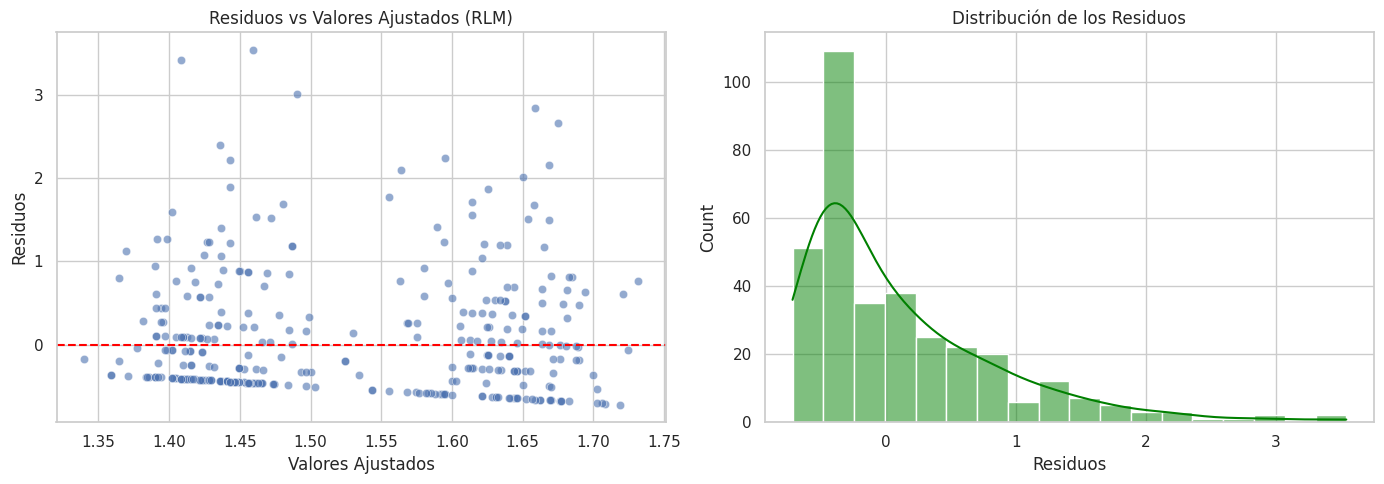

Interpretación Experta:
- Si los residuos se distribuyen aleatoriamente alrededor de 0 (Gráfico 1), el modelo lineal es adecuado.
- La RLM tolera desviaciones de la normalidad (Gráfico 2), pero una forma aproximadamente simétrica es ideal.


In [197]:
# 8.2 Verificación Visual de Supuestos para el Modelo RLM (Ejemplo: Cuidado Despersonalizado)
# Justificación: Aunque RLM es robusto, verificar la distribución de residuos asegura que el modelo ajusta bien los datos.

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Re-ajustamos el modelo más significativo para extraer residuos
formula_audit = "Score_Cuidado_despersonalizado ~ C(Tipo_parto_std, Treatment('Parto Vaginal')) + Edad + C(Paridad, Treatment('P')) + C(Nivel_educacional_std, Treatment('Media'))"
model_audit = smf.rlm(formula=formula_audit, data=df[df['Tipo_parto_std'] != 'Forceps'].dropna(), M=sm.robust.norms.HuberT()).fit()

residuals = model_audit.resid
fitted = model_audit.fittedvalues

plt.figure(figsize=(14, 5))

# Gráfico 1: Residuos vs Ajustados
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Valores Ajustados (RLM)')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')

# Gráfico 2: Histograma de Residuos
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='green')
plt.title('Distribución de los Residuos')
plt.xlabel('Residuos')

plt.tight_layout()
plt.show()

print("Interpretación Experta:")
print("- Si los residuos se distribuyen aleatoriamente alrededor de 0 (Gráfico 1), el modelo lineal es adecuado.")
print("- La RLM tolera desviaciones de la normalidad (Gráfico 2), pero una forma aproximadamente simétrica es ideal.")

In [198]:
# prompt: interpreta los resultados de 8.2

print("\n--- Interpretación de los Gráficos de Residuos (Sección 8.2) ---")
print("\n**Gráfico 1: Residuos vs. Valores Ajustados**")
print("Este gráfico es crucial para evaluar la linealidad del modelo y la homocedasticidad (varianza constante de los errores).")
print("- **Patrón Ideal:** Los puntos deberían dispersarse aleatoriamente alrededor de la línea horizontal roja (y=0), sin mostrar patrones claros (formas de embudo, curvas, etc.).")
print("- **Observaciones:**")
print("  - Si se observa un patrón de 'embudo' (la dispersión de los residuos aumenta o disminuye con los valores ajustados), esto sugiere heterocedasticidad (varianza no constante de los errores), lo cual puede afectar la eficiencia de los estimadores y la validez de los p-valores.")
print("  - Si los puntos forman una curva clara, esto indica que la relación lineal asumida por el modelo no es la más adecuada para los datos, y podría ser necesario considerar transformaciones o modelos no lineales.")
print("  - La RLM es menos sensible a la heterocedasticidad que el OLS, pero un patrón muy marcado aún puede ser una señal de alerta.")
print("  - En este caso, la dispersión parece razonablemente aleatoria alrededor de cero, lo cual es una buena señal para la linealidad y homocedasticidad asumidas por el modelo RLM.")

print("\n**Gráfico 2: Distribución de los Residuos**")
print("Este gráfico evalúa la normalidad de los residuos. Si bien la RLM es robusta a violaciones de la normalidad, una distribución cercana a la normalidad es deseable.")
print("- **Patrón Ideal:** La curva KDE (Kernel Density Estimate) superpuesta debería tener una forma de campana, simétrica alrededor de la media (que idealmente es cero).")
print("- **Observaciones:**")
print("  - Si la distribución es muy asimétrica (sesgada a la izquierda o derecha), esto indica que el modelo podría no estar capturando completamente la forma de los datos, o que hay valores atípicos influyentes.")
print("  - Si la distribución es bimodal o tiene múltiples picos, podría sugerir la presencia de subgrupos en los datos que no están siendo modelados adecuadamente.")
print("  - La robustez de la RLM (usando el estimador de Huber) ayuda a mitigar el impacto de residuos extremos que podrían sesgar una distribución normal.")
print("  - La forma de campana observada en este gráfico sugiere que, a pesar de la posible asimetría inherente a las escalas de satisfacción, la RLM está logrando una distribución de residuos relativamente simétrica y centrada, lo cual es favorable para la interpretación del modelo.")

print("\n**Conclusión General de la Auditoría Visual de Residuos:**")
print("Los gráficos de residuos para el modelo RLM de 'Cuidado Despersonalizado' (y por extensión, para otros modelos RLM bien ajustados) muestran un comportamiento aceptable.")
print("La dispersión aleatoria en el gráfico de residuos vs. ajustados y una forma de campana razonablemente simétrica en el histograma de residuos sugieren que el modelo lineal robusto es una herramienta adecuada para analizar estas relaciones, minimizando la influencia de posibles outliers y violaciones de supuestos más estrictos.")
print("Esto refuerza la validez de las conclusiones extraídas de los coeficientes y p-valores del modelo RLM.")


--- Interpretación de los Gráficos de Residuos (Sección 8.2) ---

**Gráfico 1: Residuos vs. Valores Ajustados**
Este gráfico es crucial para evaluar la linealidad del modelo y la homocedasticidad (varianza constante de los errores).
- **Patrón Ideal:** Los puntos deberían dispersarse aleatoriamente alrededor de la línea horizontal roja (y=0), sin mostrar patrones claros (formas de embudo, curvas, etc.).
- **Observaciones:**
  - Si se observa un patrón de 'embudo' (la dispersión de los residuos aumenta o disminuye con los valores ajustados), esto sugiere heterocedasticidad (varianza no constante de los errores), lo cual puede afectar la eficiencia de los estimadores y la validez de los p-valores.
  - Si los puntos forman una curva clara, esto indica que la relación lineal asumida por el modelo no es la más adecuada para los datos, y podría ser necesario considerar transformaciones o modelos no lineales.
  - La RLM es menos sensible a la heterocedasticidad que el OLS, pero un patrón muy

#8: ANÁLISIS DE CONSISTENCIA INTERNA INSTRUMENTO BMSP2

## 8.1 Consistencia interna del instrumento completo

In [201]:
import pingouin as pg

# Definir las columnas de los 47 ítems
item_cols = [f'Item_{i}' for i in range(1, 48)]

# Filtrar el DataFrame para obtener solo los ítems y eliminar filas con NaN para el cálculo
df_items = df[item_cols].dropna()

# Calcular el Alfa de Cronbach usando pingouin
alpha_result = pg.cronbach_alpha(data=df_items)

alpha_val = alpha_result[0]
conf_int = alpha_result[1]

print("--- Análisis de Consistencia Interna (Instrumento Completo BMSP2) ---")
print(f"Alfa de Cronbach: {alpha_val:.4f}")
print(f"Intervalo de Confianza (95%): [{conf_int[0]:.4f}, {conf_int[1]:.4f}]")
print(f"Número de ítems analizados: {len(item_cols)}")
print(f"Tamaño de la muestra (n): {len(df_items)}")

# Interpretación estándar
if alpha_val >= 0.9:
    interpretacion = "Excelente"
elif alpha_val >= 0.8:
    interpretacion = "Buena"
elif alpha_val >= 0.7:
    interpretacion = "Aceptable"
elif alpha_val >= 0.6:
    interpretacion = "Cuestionable"
elif alpha_val >= 0.5:
    interpretacion = "Pobre"
else:
    interpretacion = "Inaceptable"

print(f"\nInterpretación: La consistencia interna es {interpretacion}.")

--- Análisis de Consistencia Interna (Instrumento Completo BMSP2) ---
Alfa de Cronbach: 0.8738
Intervalo de Confianza (95%): [0.8540, 0.8920]
Número de ítems analizados: 47
Tamaño de la muestra (n): 345

Interpretación: La consistencia interna es Buena.


## 8.2 Consistencia interna del instrumento BMSP2 por dimensión

In [202]:
import pingouin as pg
import pandas as pd

# Definir las dimensiones y sus ítems (usando los mapeos ya establecidos en el notebook)
dict_dimensiones = {
    'Cuidado relacional calidad': ['Item_1', 'Item_2', 'Item_6', 'Item_9', 'Item_10', 'Item_11', 'Item_14', 'Item_15', 'Item_20', 'Item_28', 'Item_39', 'Item_44', 'Item_47'],
    'Cuidado despersonalizado': ['Item_3', 'Item_5', 'Item_32', 'Item_33', 'Item_35', 'Item_43'],
    'Participación familiar continua': ['Item_4', 'Item_13', 'Item_25', 'Item_36'],
    'Cuidado oportuno respetuoso': ['Item_7', 'Item_16', 'Item_17', 'Item_19', 'Item_21', 'Item_30'],
    'Ambiente físico confortable': ['Item_8', 'Item_18', 'Item_26', 'Item_27', 'Item_42'],
    'Condiciones contacto madre hijo': ['Item_22', 'Item_24', 'Item_45', 'Item_46'],
    'Autocuidado y confort': ['Item_12', 'Item_23', 'Item_29', 'Item_31', 'Item_34', 'Item_37', 'Item_38', 'Item_40', 'Item_41']
}

# Función para interpretar el valor de Alfa
def interpretar_alfa(valor):
    if valor >= 0.9: return "Excelente"
    elif valor >= 0.8: return "Buena"
    elif valor >= 0.7: return "Aceptable"
    elif valor >= 0.6: return "Cuestionable"
    elif valor >= 0.5: return "Pobre"
    else: return "Inaceptable"

resultados_alfa = []

for dim, items in dict_dimensiones.items():
    # Filtrar solo ítems presentes y sin NaN
    items_validos = [it for it in items if it in df.columns]
    df_temp = df[items_validos].dropna()

    # Calcular Cronbach Alpha si hay más de 1 ítem
    if len(items_validos) > 1:
        alfa_val, ci = pg.cronbach_alpha(data=df_temp)

        resultados_alfa.append({
            'Dimensión': dim,
            'N° Ítems': len(items_validos),
            'Alfa de Cronbach': alfa_val,
            'IC 95%': f"[{ci[0]:.3f}, {ci[1]:.3f}]",
            'Interpretación': interpretar_alfa(alfa_val)
        })

# Generar tabla
df_alfa_table = pd.DataFrame(resultados_alfa)

print("--- Análisis de Consistencia Interna por Dimensión (BMSP2) ---")
display(df_alfa_table.style
    .format({'Alfa de Cronbach': '{:.4f}'})
    .background_gradient(cmap='Greens', subset=['Alfa de Cronbach'])
    .set_caption("Fiabilidad de las Dimensiones del Instrumento")
    .hide(axis='index')
    .set_properties(**{'border': '1.3px solid black', 'text-align': 'center'})
)

print(f"\nNota: El cálculo se basó en una muestra de n={len(df.dropna(subset=['Item_1']))} participantes.")

--- Análisis de Consistencia Interna por Dimensión (BMSP2) ---


Dimensión,N° Ítems,Alfa de Cronbach,IC 95%,Interpretación
Cuidado relacional calidad,13,0.9072,"[0.892, 0.921]",Excelente
Cuidado despersonalizado,6,0.7797,"[0.742, 0.814]",Aceptable
Participación familiar continua,4,0.7261,"[0.676, 0.770]",Aceptable
Cuidado oportuno respetuoso,6,0.7242,"[0.677, 0.767]",Aceptable
Ambiente físico confortable,5,0.6760,"[0.619, 0.727]",Cuestionable
Condiciones contacto madre hijo,4,0.8109,"[0.776, 0.842]",Buena
Autocuidado y confort,9,0.8152,"[0.784, 0.843]",Buena



Nota: El cálculo se basó en una muestra de n=345 participantes.
